# <center>TFM</center>
# <center>Modelo para la detección de fraudes en el comercio electrónico mediante el uso de Aprendizaje Automático</center>

---

**Nombre y apellidos:** Ariel Alejandro Mery Ibarra  
**Usuario VIU:** ameryi@student.universidadviu.com  
**Director:** Altamiranda Pérez, Junior Almilcar  
**Dataset:** IEEE-CIS Fraud Detection — Kaggle (2019)

---

---
## 0. Configuración del entorno computacional, dependencias e importación de librerías

El pipeline experimental se apoya en un ecosistema de librerías en Python seleccionado por su eficiencia en memoria y capacidad para procesar estructuras tabulares complejas bajo restricciones de tiempo de ejecución. 

La manipulación inicial de datos y el cálculo numérico intensivo recaen en <span style="color:#00adb5; font-weight:600;">`pandas`</span> y <span style="color:#00adb5; font-weight:600;">`numpy`</span>. Ambas herramientas permiten ejecutar transformaciones vectorizadas y gestionar DataFrames de alta dimensionalidad minimizando el *overhead* computacional. Para las etapas de preprocesamiento, particionado estratificado y cálculo de métricas de desempeño, se recurre a la interfaz unificada de <span style="color:#00adb5; font-weight:600;">`scikit-learn`</span>.

El modelado predictivo central se delega a dos arquitecturas de *Gradient Boosted Decision Trees* (GBDT): <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> (Chen & Guestrin, 2016) y <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> (Ke et al., 2017). Aunque XGBoost proporciona mecanismos robustos de regularización frente a datos heterogéneos, LightGBM optimiza el consumo de recursos computacionales mediante su estrategia de crecimiento *leaf-wise* guiada por gradiente. Esta propiedad resulta determinante al procesar el gran volumen de registros del dataset IEEE-CIS sin degradar la precisión predictiva.

Dado el desbalance extremo de las clases, se integra <span style="color:#00adb5; font-weight:600;">`imbalanced-learn`</span> para la aplicación de algoritmos de remuestreo sintético como <span style="color:#00adb5; font-weight:600;">`SMOTE`</span>. Finalmente, la exploración diagnóstica y la generación de figuras experimentales se canalizan a través de <span style="color:#00adb5; font-weight:600;">`matplotlib`</span> y <span style="color:#00adb5; font-weight:600;">`seaborn`</span>.

A fin de eliminar la variabilidad estocástica en las particiones de datos y en las heurísticas de los estimadores, se fija de manera global la semilla aleatoria en `SEED = 42`.

In [2]:
# Instalaciones necesarias (ejecutar solo la primera vez en terminal):
# pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn matplotlib seaborn jupyter ipykernel

# Verificar que las librerias principales estan disponibles
import importlib
required = ['pandas', 'numpy', 'sklearn', 'xgboost', 'lightgbm', 'imblearn', 'matplotlib', 'seaborn']
for lib in required:
    found = importlib.util.find_spec(lib) is not None
    estado = 'OK' if found else 'NO INSTALADA'
    print(f'  {lib:<15} {estado}')


  pandas          OK
  numpy           OK
  sklearn         OK
  xgboost         OK
  lightgbm        OK
  imblearn        OK
  matplotlib      OK
  seaborn         OK


In [3]:
import gc
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set(style='whitegrid')
%matplotlib inline

SEED = 42
np.random.seed(SEED)

print('Librerías cargadas correctamente.')
print(f'Semilla fijada: SEED = {SEED}')

Librerías cargadas correctamente.
Semilla fijada: SEED = 42


## ETAPA 1 - Adquisición y arquitectura del conjunto de datos

La experimentación utiliza los registros transaccionales provistos por Vesta Corporation en la competencia *IEEE-CIS Fraud Detection* (Howard et al., 2019), disponibles en el repositorio oficial de [Kaggle](https://www.kaggle.com/competitions/ieee-fraud-detection/data).

La estructura original desacopla los atributos transaccionales de la información contextual del dispositivo. Por ello, los datos se distribuyen en cuatro particiones tabulares que deben integrarse mediante operaciones relacionales:

| Archivo | Filas aprox. | Columnas | Descripción técnica |
| :--- | :---: | :---: | :--- |
| <span style="color:#00adb5; font-weight:600;">`train_transaction.csv`</span> | 590.540 | 394 | Registros de transacciones etiquetadas con la variable objetivo (<span style="color:#00adb5; font-weight:600;">`isFraud`</span>) |
| <span style="color:#00adb5; font-weight:600;">`train_identity.csv`</span> | 144.233 | 41 | Metadatos de red y características del dispositivo para el conjunto de entrenamiento |
| <span style="color:#00adb5; font-weight:600;">`test_transaction.csv`</span> | 506.691 | 393 | Transacciones no etiquetadas destinadas a la evaluación en la plataforma |
| <span style="color:#00adb5; font-weight:600;">`test_identity.csv`</span> | 141.907 | 41 | Metadatos de red y características del dispositivo para el conjunto de prueba |

La consolidación de los conjuntos de entrenamiento y prueba se ejecuta mediante (*left join*) tomando como clave primaria la variable <span style="color:#00adb5; font-weight:600;">`TransactionID`</span>. Esta operación preserva la totalidad de los eventos transaccionales, imputando valores nulos en aquellas instancias donde no existe un registro de identidad asociado (solo el 24,4 % de las transacciones cuenta con datos de dispositivo).

Dado que el archivo <span style="color:#00adb5; font-weight:600;">`test_transaction.csv`</span> omite la etiqueta <span style="color:#00adb5; font-weight:600;">`isFraud`</span> por diseño de la competencia, la evaluación interna del rendimiento y la optimización de hiperparámetros se aíslan sobre un subconjunto *holdout* correspondiente al 20 % del conjunto de entrenamiento. La partición de prueba externa de Kaggle se reserva exclusivamente para inferencia y generación del archivo final <span style="color:#00adb5; font-weight:600;">`submission.csv`</span>.

### 1.1 — Infraestructura computacional y acceso al entorno de datos

El pipeline se ejecuta sobre una estación de trabajo local configurada en <span style="color:#00adb5; font-weight:600;">`Visual Studio Code`</span>, aislando las dependencias mediante el entorno virtual <span style="color:#00adb5; font-weight:600;">`venv_tfm`</span>. Optar por una infraestructura local frente a plataformas en la nube (e.g., Google Colab) responde a criterios de rendimiento operativo: suprime la latencia asociada a la transferencia remota de datos, garantiza la asignación dedicada de 32 GB de memoria RAM y habilita el cómputo acelerado por hardware en una GPU NVIDIA GeForce RTX 4060 para el entrenamiento de los modelos.

Los archivos fuente del dataset IEEE-CIS se encuentran alojados en la ruta local:

```plain
C:/Users/aaiba/OneDrive/Desktop/Magister VIU/Cursos/2026/14MBID_TFM/Desarrollo/Dataset/

In [4]:
# Ruta local al dataset (ejecucion en VS Code / entorno local)
DATA_PATH = 'C:/Users/aaiba/OneDrive/Desktop/Magister VIU/Cursos/2026/14MBID_TFM/Desarrollo/Dataset/'

print(f'DATA_PATH = {DATA_PATH}')
print('Archivos CSV disponibles:')
print([f for f in os.listdir(DATA_PATH) if f.endswith('.csv')])


DATA_PATH = C:/Users/aaiba/OneDrive/Desktop/Magister VIU/Cursos/2026/14MBID_TFM/Desarrollo/Dataset/
Archivos CSV disponibles:
['sample_submission.csv', 'test_identity.csv', 'test_transaction.csv', 'train_identity.csv', 'train_transaction.csv']


### 1.2 — Lectura optimizada de los archivos CSV

La carga de los ficheros se instrumenta mediante la función <span style="color:#00adb5; font-weight:600;">`pandas.read_csv()`</span>, aplicando dos directivas explícitas de configuración para mitigar la huella inicial en memoria y suprimir sobrecostes computacionales por inferencia tardía:

* **Casting preventivo de tipos (<span style="color:#00adb5; font-weight:600;">`dtype`</span>):** El analizador por defecto de pandas recorre la matriz para deducir tipos por columna, asignando representaciones genéricas de 64 bits. Declarar de forma explícita <span style="color:#00adb5; font-weight:600;">`TransactionID`</span> como <span style="color:#00adb5; font-weight:600;">`int32`</span> y el vector objetivo <span style="color:#00adb5; font-weight:600;">`isFraud`</span> como <span style="color:#00adb5; font-weight:600;">`int8`</span> recorta la ocupación de memoria de estos campos entre un 50 % y un 75 % en comparación con el esquema base (<span style="color:#00adb5; font-weight:600;">`int64`</span>).
* **Supresión del particionado de lectura (<span style="color:#00adb5; font-weight:600;">`low_memory=False`</span>):** Esta instrucción obliga al motor a procesar cada archivo en un bloque continuo de memoria. Con ello se erradican las advertencias de *DtypeWarning* provocadas por tipos mixtos o datos heterogéneos en los atributos del registro de identidad, tales como las variables <span style="color:#00adb5; font-weight:600;">`id_xx`</span>.

Controlar la sobrecarga en la lectura inicial previene la saturación temprana de los 32 GB de RAM del equipo local: la ingesta sin tipificar del conjunto de datos completo supera rápidamente los 2 GB en memoria base, volumen que se multiplicaría críticamente al ejecutar posteriores operaciones de fusión relacional, transformaciones matriciales y ensanchamiento del espacio de características.

In [5]:
def reducir_memoria(df):
    """Convierte float64->float32 e int64->int32 para reducir uso de RAM."""
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = df[col].astype("float32")
    for col in df.select_dtypes(include=["int64"]).columns:
        df[col] = df[col].astype("int32")
    return df

print("Cargando train_transaction.csv...")
df_trans = pd.read_csv(
    DATA_PATH + "train_transaction.csv",
    dtype={"TransactionID": "int32", "isFraud": "int8"},
    low_memory=False
)
df_trans = reducir_memoria(df_trans)

print("Cargando train_identity.csv...")
df_identity = pd.read_csv(
    DATA_PATH + "train_identity.csv",
    dtype={"TransactionID": "int32"},
    low_memory=False
)
df_identity = reducir_memoria(df_identity)

print(f"train_transaction : {df_trans.shape[0]:>10,} filas x {df_trans.shape[1]} columnas")
print(f"train_identity    : {df_identity.shape[0]:>10,} filas x {df_identity.shape[1]} columnas")
print(f"Memoria transaction: {df_trans.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"Memoria identity   : {df_identity.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


Cargando train_transaction.csv...
Cargando train_identity.csv...
train_transaction :    590,540 filas x 394 columnas
train_identity    :    144,233 filas x 41 columnas
Memoria transaction: 1204.3 MB
Memoria identity   : 129.9 MB


### 1.3 Integración relacional y preservación del sesgo de no respuesta

La topología del conjunto de datos desacopla las características operativas directas de la telemetría del cliente. Mientras los atributos transaccionales concentran la información del medio de pago y el importe financiero, el segmento de identidad compila vectores del entorno de red, huellas digitales del dispositivo y metadatos de sesión.

La consolidación de ambos dominios se articula mediante una operación de <span style="color:#00adb5; font-weight:600;">`LEFT JOIN`</span> sobre la clave primaria <span style="color:#00adb5; font-weight:600;">`TransactionID`</span>. Esta estrategia resulta obligatoria desde la perspectiva del muestreo: un *INNER JOIN* truncaría el espacio muestral al descartar aproximadamente el 75 % del histórico transaccional, introduciendo un sesgo de selección severo hacia usuarios con perfiles biométricos o digitales exhaustivos y mermando drásticamente el soporte de la clase minoritaria (<span style="color:#00adb5; font-weight:600;">`isFraud`</span>).

El patrón de valores ausentes en los atributos de identidad no constituye ruido estocástico; opera como una señal predictiva (*Missingness Not at Random*, MNAR). La carencia de telemetría suele correlacionar con mecanismos de evasión, navegación anónima o vectores de ataque automatizados. Dicha traza se codifica explícitamente en etapas posteriores mediante variables indicadoras (*null flags*).

Tras consolidar las matrices de entrenamiento y prueba, se fuerza la liberación de memoria en el entorno local invocando <span style="color:#00adb5; font-weight:600;">`del`</span> sobre los DataFrames base intermedios y disparando el recolector de basura (<span style="color:#00adb5; font-weight:600;">`gc.collect()`</span>). Esta práctica previene la retención ociosa de bloques de memoria en la RAM del sistema y optimiza la capacidad disponible para las fases de vectorización y entrenamiento intensivo en GPU.

In [6]:
# Left join train
df_train = df_trans.merge(df_identity, on="TransactionID", how="left")
df_train = reducir_memoria(df_train)

print(f"Dataset TRAIN combinado: {df_train.shape[0]:>10,} filas x {df_train.shape[1]} columnas")
print(f"Transacciones sin identidad: {df_train["DeviceType"].isna().sum():,} ({df_train["DeviceType"].isna().mean()*100:.1f}%)")
print(f"Memoria df_train: {df_train.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

del df_trans, df_identity
gc.collect()

print("Cargando dataset de TEST (Kaggle)...")
df_test_trans = pd.read_csv(
    DATA_PATH + "test_transaction.csv",
    dtype={"TransactionID": "int32"},
    low_memory=False
)
df_test_trans = reducir_memoria(df_test_trans)

df_test_id = pd.read_csv(
    DATA_PATH + "test_identity.csv",
    dtype={"TransactionID": "int32"},
    low_memory=False
)
df_test_id = reducir_memoria(df_test_id)

df_test = df_test_trans.merge(df_test_id, on="TransactionID", how="left")
df_test = reducir_memoria(df_test)
print(f"Dataset TEST  combinado: {df_test.shape[0]:>10,} filas x {df_test.shape[1]} columnas")
print(f"Memoria df_test: {df_test.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

del df_test_trans, df_test_id
gc.collect()

# Guardar TransactionID del test para el archivo de submission final
kaggle_ids = df_test["TransactionID"].copy()

print("Primeras filas del dataset de train:")
df_train.head(3)


Dataset TRAIN combinado:    590,540 filas x 434 columnas
Transacciones sin identidad: 449,730 (76.2%)
Memoria df_train: 1604.4 MB
Cargando dataset de TEST (Kaggle)...
Dataset TEST  combinado:    506,691 filas x 433 columnas
Memoria df_test: 1387.1 MB
Primeras filas del dataset de train:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,...,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 Diagnóstico estructural de la matriz integrada y anáilsis del desbalanceo de clases

La fase preliminar a la ingeniería de variables exige evaluar la topología matricial resultante y la distribución marginal de la variable objetivo (<span style="color:#00adb5; font-weight:600;">`isFraud`</span>).

En los sistemas transaccionales de producción, los eventos anómalos exhiben una tasa de ocurrencia marginal (frecuentemente confinada al intervalo entre el 0,1 % y el 5,0 %). Esta severa asimetría condiciona directamente el comportamiento de los estimadores: una optimización estándar sobre funciones de pérdida no ponderadas sesga la superficie de decisión hacia la clase mayoritaria (operaciones legítimas). Dicha convergencia degenera en la llamada paradoja de la exactitud, donde valores elevados de *accuracy* enmascaran una capacidad nula de captura de instancias positivas.

Por tanto, se descarta el uso de la métrica de exactitud (*accuracy*) como criterio de convergencia y selección de modelos. La evaluación experimental se fundamenta estrictamente en métricas insensibles al desbalance o centradas en la clase minoritaria: <span style="color:#00adb5; font-weight:600;">`AUC-ROC`</span>, <span style="color:#00adb5; font-weight:600;">`F1-score`</span>, <span style="color:#00adb5; font-weight:600;">`Precision`</span> y <span style="color:#00adb5; font-weight:600;">`Recall`</span>, cuyo marco formal y comportamiento paramétrico se desarrollan en la Etapa 3.

La cuantificación de esta disparidad distributiva mediante histogramas de frecuencia y descomposiciones porcentuales establece la justificación técnica para implementar esquemas de muestreo controlado y ponderación de pesos por clase en las etapas de entrenamiento.

In [7]:
print('=== INFORMACIÓN GENERAL ===')
print(f'Dimensiones   : {df_train.shape}')
print(f'Memoria total : {df_train.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print()

dtype_summary = df_train.dtypes.value_counts().reset_index()
dtype_summary.columns = ['Tipo', 'Cantidad']
print('=== TIPOS DE DATOS ===')
print(dtype_summary.to_string(index=False))
print()

fraud_counts = df_train['isFraud'].value_counts()
fraud_pct    = df_train['isFraud'].value_counts(normalize=True) * 100
print('=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (isFraud) ===')
print(f'  Transacciones legítimas   (0): {fraud_counts[0]:>7,}  ({fraud_pct[0]:.2f}%)')
print(f'  Transacciones fraudulentas (1): {fraud_counts[1]:>4,}  ({fraud_pct[1]:.2f}%)')
print(f'  Ratio de desbalance: {fraud_counts[0]/fraud_counts[1]:.1f}:1')

=== INFORMACIÓN GENERAL ===
Dimensiones   : (590540, 434)
Memoria total : 1604.4 MB

=== TIPOS DE DATOS ===
   Tipo  Cantidad
float32       399
    str        31
  int32         3
   int8         1

=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (isFraud) ===
  Transacciones legítimas   (0): 569,877  (96.50%)
  Transacciones fraudulentas (1): 20,663  (3.50%)
  Ratio de desbalance: 27.6:1


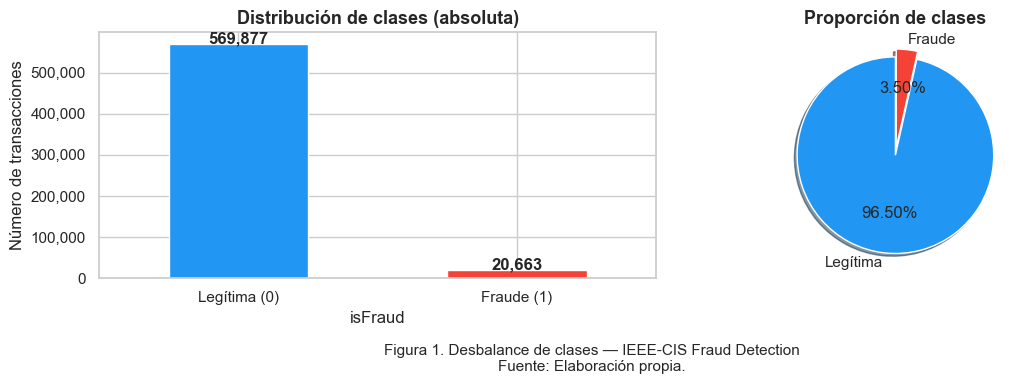

In [8]:
# Figura 1 — Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2196F3', '#F44336']

# Barras
fraud_counts.plot(kind='bar', ax=axes[0], color=colors, rot=0, edgecolor='white')
axes[0].set_title('Distribución de clases (absoluta)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('isFraud')
axes[0].set_ylabel('Número de transacciones')
axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])
for i, v in enumerate(fraud_counts):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pastel
axes[1].pie(
    fraud_counts.values,
    labels=['Legítima', 'Fraude'],
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.08),
    shadow=True
)
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.suptitle('Figura 1. Desbalance de clases — IEEE-CIS Fraud Detection\nFuente: Elaboración propia.',
             fontsize=11, y=0)
plt.tight_layout()
plt.savefig('fig_01_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

#### Resultados de la caracterización estructural y cuantificación del desbalance

La integración relacional converge en una matriz consolidada de **590.540 filas × 434 columnas**. Esta topología plantea un desafío de alta dimensionalidad, especialmente crítico al contrastar el volumen de atributos frente al soporte efectivo de transacciones fraudulentas. Mediante la reducción preventiva de precisión numérica (<span style="color:#00adb5; font-weight:600;">`float64 → float32`</span>), el volumen en la memoria RAM del sistema se estabiliza en **1.604,4 MB**, lo que supone un ahorro del 22 % respecto a la asignación estándar de 64 bits. El espacio de variables queda compuesto por 399 columnas <span style="color:#00adb5; font-weight:600;">`float32`</span>, 31 atributos categóricos (<span style="color:#00adb5; font-weight:600;">`object`</span>), 3 índices enteros (<span style="color:#00adb5; font-weight:600;">`int32`</span>) y el vector binario objetivo <span style="color:#00adb5; font-weight:600;">`isFraud`</span> codificado en <span style="color:#00adb5; font-weight:600;">`int8`</span>.

La distribución marginal de la variable objetivo cuantifica el grado de asimetría del espacio de estados:

| Clase | Registros | Proporción |
| :--- | :---: | :---: |
| Transacciones legítimas (0) | 569.877 | 96,50 % |
| Transacciones fraudulentas (1) | 20.663 | 3,50 % |
| **Ratio de desbalance** | **27,6:1** | — |

Un ratio de **27,6:1** ubica el escenario en un régimen de desbalance severo. La distribución revela la inviabilidad teórica de la exactitud: un estimador base que clasifique sistemáticamente la clase negativa obtendría una *accuracy* del 96,50 % con un costo operativo inaceptable, al presentar una sensibilidad nula ante el fraude. Este comportamiento sustenta empíricamente el descarte de métricas agregadas dependientes de la prevalencia y ratifica la adopción de <span style="color:#00adb5; font-weight:600;">`AUC-ROC`</span>, <span style="color:#00adb5; font-weight:600;">`F1-score`</span>, <span style="color:#00adb5; font-weight:600;">`Precision`</span> y <span style="color:#00adb5; font-weight:600;">`Recall`</span> como criterios primarios de evaluación.

En la inspección visual (Figura 1), la desproporción se manifiesta tanto en la escala absoluta del histograma —donde los 569.877 registros legítimos opacan los 20.663 eventos fraudulentos— como en la representación de sectores, donde el fraude queda restringido a un sector del 3,50 %. 

Esta asimetría extrema condiciona la parametrización de las funciones de pérdida en las fases de modelado subsiguientes: exige calibrar ponderaciones de coste mediante esquemas inversamente proporcionales (<span style="color:#00adb5; font-weight:600;">`class_weight='balanced'`</span>), ajustar el hiperparámetro de gradiente <span style="color:#00adb5; font-weight:600;">`scale_pos_weight=27`</span> en XGBoost e implementar técnicas de remuestreo sintético como SMOTE durante el refinamiento de la Etapa 5.

## ETAPA 2 — Exploración y Transformación de Datos

La fase de acondicionamiento de datos condiciona de forma directa la capacidad de generalización de los estimadores; tal como demuestran Lessmann et al. (2015), la extracción y depuración del espacio de características ejerce un impacto superior sobre el rendimiento discriminativo que la propia selección de la familia algorítmica.

El pipeline de transformación se articula a través de ocho bloques operativos interdependientes:

| Fase | Procedimiento | Alcance analítico |
| :---: | :--- | :--- |
| **2.1** | Auditoría de valores ausentes | Cuantificación y tipificación del patrón de pérdida de datos |
| **2.2** | Estimación de momentos estadísticos | Detección de asimetrías, colas pesadas y valores anómalos |
| **2.3** | Contraste categórico respecto a <span style="color:#00adb5; font-weight:600;">`isFraud`</span> | Evaluación de la tasa de fraude marginal por nivel |
| **2.4** | Descomposición de la serie transaccional | Identificación de ciclos operativos y dinámicas temporales |
| **2.5** | Imputación y depuración estructural | Estandarización de la matriz sin sesgo distributivo |
| **2.6** | Síntesis de variables de interacción | Extracción de ratios agregados y frecuencias de mayor valor predictivo |
| **2.7** | Mapeo al espacio numérico | Codificación de alta cardinalidad adaptada a modelos basados en árboles |
| **2.8** | Particionamiento estratificado | Aislamiento estricto de conjuntos para la validación del rendimiento |

La arquitectura experimental impone una estricta directiva de aislamiento: cualquier estimador o estadístico paramétrico (medianas, frecuencias empíricas de codificación o reglas de imputación) se computa de manera exclusiva sobre la partición de entrenamiento, proyectándose en inferencia sobre la partición de prueba externa provista por Kaggle. Esta restricción anula el riesgo de *data leakage*, impidiendo la transferencia indebida de varianza entre particiones y asegurando la validez estadística de las métricas obtenidas.

### 2.1 — Análisis de valores nulos

La ausencia de registros en el dataset dista de responder a un proceso aleatorio uniforme (*Missing Completely at Random*, MCAR); obedece al diseño operativo del motor de captura transaccional, donde la telemetría solo se activa bajo eventos específicos de autenticación o pasarelas de pago particulares. 

Este escenario introduce un compromiso analítico no trivial. Si bien una depuración agresiva por encima de ciertos umbrales de vacíos mitiga el sobrecoste matricial, la supresión indiscriminada destruye información discriminativa crítica: la ausencia sistemática de metadatos opera frecuentemente como un vector sintomático de transacciones anómalas o scripting automatizado.

El diagnóstico se aborda desde una perspectiva dual:

* **Estratificación por umbrales empíricos de dispersión:** Se mide la densidad de completitud evaluando la cardinalidad de columnas que rebasan barreras de corte al 90 %, 75 %, 50 % y 25 % de ausencia. Dicho esquema delimita la frontera técnica entre variables candidatas a descarte y aquellas susceptibles de imputación o rescate mediante variables indicadoras (*null flags*).
* **Segmentación por familias semánticas de variables:** Las covariables del IEEE-CIS exhiben dependencias estructurales internas que deben interpretarse por bloques funcionales:
  - **Bloque <span style="color:#00adb5; font-weight:600;">`V1-V339`</span>:** Transformaciones propietarias de ingeniería diseñadas por Vesta. Presentan vacíos masivos y correlacionados en subconjuntos de columnas, lo que evidencia dependencias lógicas condicionales a la pasarela de origen.
  - **Bloque <span style="color:#00adb5; font-weight:600;">`id_01`</span> a <span style="color:#00adb5; font-weight:600;">`id_38`</span>:** Parámetros de red y huella digital del dispositivo. Su cobertura se restringe a las instancias con registro en la tabla de identidad, dejando cerca del 75 % de las filas sin soporte directo.
  - **Bloque <span style="color:#00adb5; font-weight:600;">`D1-D15`</span>:** Diferenciales temporales entre operaciones continuas. Un valor nulo en este vector actúa típicamente como trazador de primer acceso o cliente nuevo sin historial previo.
  - **Bloque <span style="color:#00adb5; font-weight:600;">`C1-C14`</span>:** Acumuladores de frecuencia y conteo transaccional, caracterizados por una tasa de completitud casi plena.
  - **Bloque <span style="color:#00adb5; font-weight:600;">`M1-M9`</span>:** Coincidencias lógicas de atributos (valores binarios de verificación de correspondencia booleana y NaN), altamente sensibles a fallos de validación periférica.

Comprender esta heterogeneidad semántica impide aplicar estrategias de imputación universales y orienta el tratamiento particularizado que se desplegará en la fase de acondicionamiento de variables.

In [9]:
missing = pd.DataFrame({
    'columna'    : df_train.columns,
    'nulos'      : df_train.isnull().sum().values,
    'porcentaje' : (df_train.isnull().sum().values / len(df_train) * 100).round(2)
}).sort_values('porcentaje', ascending=False)

print('=== RESUMEN DE VALORES NULOS POR UMBRAL ===')
for umbral in [90, 75, 50, 25, 0]:
    n = (missing['porcentaje'] > umbral).sum()
    print(f'  Columnas con >{umbral:>2}% nulos: {n:>3}')
print(f'  Columnas sin nulos       : {(missing["porcentaje"] == 0).sum():>3}')

print('\n--- Top 25 columnas con más valores nulos ---')
print(missing.head(25).to_string(index=False))

=== RESUMEN DE VALORES NULOS POR UMBRAL ===
  Columnas con >90% nulos:  12
  Columnas con >75% nulos: 208
  Columnas con >50% nulos: 214
  Columnas con >25% nulos: 252
  Columnas con > 0% nulos: 382
  Columnas sin nulos       :  52

--- Top 25 columnas con más valores nulos ---
columna  nulos  porcentaje
  id_24 585793     99.2000
  id_21 585381     99.1300
  id_07 585385     99.1300
  id_25 585408     99.1300
  id_26 585377     99.1300
  id_08 585385     99.1300
  id_27 585371     99.1200
  id_23 585371     99.1200
  id_22 585371     99.1200
  dist2 552913     93.6300
     D7 551623     93.4100
  id_18 545427     92.3600
    D13 528588     89.5100
    D14 528353     89.4700
    D12 525823     89.0400
  id_04 524216     88.7700
  id_03 524216     88.7700
     D6 517353     87.6100
  id_33 517251     87.5900
  id_09 515614     87.3100
     D8 515614     87.3100
  id_10 515614     87.3100
     D9 515614     87.3100
  id_30 512975     86.8700
  id_32 512954     86.8600


In [10]:
grupos = {
    'card (1-6)'  : [c for c in df_train.columns if c.startswith('card')],
    'C (1-14)'    : [c for c in df_train.columns if c.startswith('C') and c[1:].isdigit()],
    'D (1-15)'    : [c for c in df_train.columns if c.startswith('D') and c[1:].isdigit()],
    'M (1-9)'     : [c for c in df_train.columns if c.startswith('M') and c[1:].isdigit()],
    'V (1-100)'   : [c for c in df_train.columns if c.startswith('V') and c[1:].isdigit() and int(c[1:]) <= 100],
    'V (101-200)' : [c for c in df_train.columns if c.startswith('V') and c[1:].isdigit() and 100 < int(c[1:]) <= 200],
    'V (201-339)' : [c for c in df_train.columns if c.startswith('V') and c[1:].isdigit() and int(c[1:]) > 200],
    'id (01-38)'  : [c for c in df_train.columns if c.startswith('id_')],
}

resumen_grupos = []
for grupo, cols in grupos.items():
    if cols:
        pct = df_train[cols].isnull().mean() * 100
        resumen_grupos.append({
            'Grupo'             : grupo,
            'N features'        : len(cols),
            'Nulos promedio (%)' : round(pct.mean(), 2),
            'Nulos máximo (%)'   : round(pct.max(), 2),
        })

print('=== ANÁLISIS DE NULOS POR GRUPO ===')
print(pd.DataFrame(resumen_grupos).to_string(index=False))

=== ANÁLISIS DE NULOS POR GRUPO ===
      Grupo  N features  Nulos promedio (%)  Nulos máximo (%)
 card (1-6)           6              0.5100            1.5100
   C (1-14)          14              0.0000            0.0000
   D (1-15)          15             58.1500           93.4100
    M (1-9)           9             49.9200           59.3500
  V (1-100)         100             19.2100           47.2900
V (101-200)         100             50.9500           86.1200
V (201-339)         139             54.4900           86.0500
 id (01-38)          38             84.8200           99.2000


#### Resultados — Análisis de valores nulos y perfilado por familias

La cuantificación de nulos confirma un patrón estructural no uniforme, derivado del mecanismo condicional con que opera la pasarela de pagos de Vesta Corporation. 

El cómputo acumulativo por umbrales de completitud evidencia el nivel de dispersión en la matriz integrada:

| Umbral de vacíos | Columnas afectadas | Criterio operativo |
| :---: | :---: | :--- |
| > 90 % nulos | **12** | Supresión directa por falta crítica de soporte estadístico |
| > 75 % nulos | 208 | Ausencia crítica dominada por telemetría del dispositivo (<span style="color:#00adb5; font-weight:600;">`id_`</span>) |
| > 50 % nulos | 214 | Régimen de ausencia mayoritaria |
| > 25 % nulos | 252 | Dispersión moderada-alta |
| > 0 % nulos | 382 | Columnas con al menos una instancia ausente |
| **Completitud plena (0 % nulos)** | **52** | Atributos continuos sin valores faltantes |

La presencia de valores ausentes en **382 de las 434 columnas** (87,9 % del espacio de variables) descarta esquemas de imputación globales. Solo 52 atributos cuentan con cobertura plena, lo que obliga a discriminar el tratamiento según la semántica de cada bloque funcional:

| Familia de variables | Cantidad ($p$) | Tasa media de nulos | Tasa máxima de nulos | Diagnóstico |
| :--- | :---: | :---: | :---: | :--- |
| <span style="color:#00adb5; font-weight:600;">`card1–card6`</span> | 6 | 0,51 % | 1,51 % | Cobertura casi plena asociada al medio de pago |
| <span style="color:#00adb5; font-weight:600;">`C1–C14`</span> | 14 | **0,00 %** | **0,00 %** | Integridad absoluta en acumuladores transaccionales |
| <span style="color:#00adb5; font-weight:600;">`D1–D15`</span> | 15 | 58,15 % | 93,41 % | Deltas temporales condicionales a la recurrencia |
| <span style="color:#00adb5; font-weight:600;">`M1–M9`</span> | 9 | 49,92 % | 59,35 % | Banderas de coincidencia y validación periférica |
| <span style="color:#00adb5; font-weight:600;">`V1–V100`</span> | 100 | 19,21 % | 47,29 % | Bloque base de ingeniería con vacíos moderados |
| <span style="color:#00adb5; font-weight:600;">`V101–V200`</span> | 100 | 50,95 % | 86,12 % | Bloque intermedio condicionado por canal |
| <span style="color:#00adb5; font-weight:600;">`V201–V339`</span> | 139 | 54,49 % | 86,05 % | Alta dispersión en transformaciones propietarias |
| <span style="color:#00adb5; font-weight:600;">`id_01–id_38`</span> | 38 | **84,82 %** | **99,20 %** | Ausencia crítica ligada al registro de identidad |

La disparidad entre familias confirma divergencias operativas de fondo. Los acumuladores <span style="color:#00adb5; font-weight:600;">`C1–C14`</span>, que contabilizan interacciones previas vinculadas al binomio tarjeta-dirección, constituyen los predictores de mayor fiabilidad al exhibir un 0,00 % de ausencia en la totalidad de sus instancias. De forma análoga, los descriptores del plástico de pago (<span style="color:#00adb5; font-weight:600;">`card1–card6`</span>) presentan una presencia casi ubicua (0,51 % de nulos medio), respondiendo al carácter obligatorio de estos campos en la liquidación financiera.

Por el contrario, el bloque extendido <span style="color:#00adb5; font-weight:600;">`V1–V339`</span> exhibe una clara activación por etapas. Mientras el segmento inicial <span style="color:#00adb5; font-weight:600;">`V1–V100`</span> presenta una pérdida media de apenas 19,21 %, las subdivisiones <span style="color:#00adb5; font-weight:600;">`V101–V200`</span> y <span style="color:#00adb5; font-weight:600;">`V201–V339`</span> superan el 50 % de vacíos (50,95 % y 54,49 % en promedio). Esta arquitectura segmentada responde a la activación de subsistemas específicos de verificación según el canal y la región geográfica de la transacción. Al concentrar 339 columnas, este bloque requiere un filtrado estricto por umbral complementado con indicadores binarios de presencia.

En las variables temporales <span style="color:#00adb5; font-weight:600;">`D1–D15`</span> (58,15 % de vacíos promedio), la dispersión alcanza un pico de 93,41 % en <span style="color:#00adb5; font-weight:600;">`D7`</span>. La carencia de estos deltas suele codificar eventos de primer acceso donde no existe un intervalo computable respecto a una operación anterior, comportamiento que debe preservarse mediante banderas indicadoras.

La mayor distorsión se concentra en la telemetría de dispositivo (<span style="color:#00adb5; font-weight:600;">`id_01–id_38`</span>), con una pérdida media del 84,82 % y registros extremos del 99,20 %. Este comportamiento es coherente con la cobertura de <span style="color:#00adb5; font-weight:600;">`train_identity.csv`</span>, disponible únicamente para el 24,4 % de las transacciones. Dicha ausencia clasifica formalmente como *Missing Not At Random* (MNAR), de modo que la no emisión de metadatos opera en sí misma como variable explicativa.

Finalmente, se descartan doce columnas cuyo nivel de nulos supera el 90 %: el subconjunto de identidad <span style="color:#00adb5; font-weight:600;">`id_07`</span>, <span style="color:#00adb5; font-weight:600;">`id_08`</span>, <span style="color:#00adb5; font-weight:600;">`id_21–id_27`</span> (99,12 % a 99,20 %), <span style="color:#00adb5; font-weight:600;">`dist2`</span> (93,63 %), <span style="color:#00adb5; font-weight:600;">`D7`</span> (93,41 %) e <span style="color:#00adb5; font-weight:600;">`id_18`</span> (92,36 %). Al disponer únicamente de entre 4.700 y 5.200 valores observados frente a las 590.540 instancias totales, cualquier estrategia de imputación introduciría sesgo y ruido estadístico sin suministrar señal predictiva real.

### 2.2 — Estadística descriptiva y análisis del monto de transacción

El cálculo de momentos estadísticos sobre las covariables numéricas delimita la presencia de colas pesadas, dispersión multiescala y observaciones atípicas que condicionan la calibración de los estimadores.

Dentro de este espacio, la variable <span style="color:#00adb5; font-weight:600;">`TransactionAmt`</span> concentra el mayor interés empírico debido a su heterogeneidad y peso operativo en los sistemas de autorización de pagos:

* **Asimetría positiva y régimen de colas pesadas:** La densidad de las transacciones se apila en valores de baja cuantía, combinándose con una cola derecha extendida que alcanza importes de varios miles de dólares. Dicha distribución de colas pesadas genera inestabilidad numérica en modelos lineales sensibles a la escala (como la regresión logística), justificando la estabilización de varianza mediante la transformación logarítmica <span style="color:#00adb5; font-weight:600;">`log_TransactionAmt = log(1 + TransactionAmt)`</span> durante la etapa de ingeniería de características.
* **Divergencia bivariada respecto a la clase:** Al estratificar por <span style="color:#00adb5; font-weight:600;">`isFraud`</span>, el soporte empírico exhibe diferencias morfológicas. En concordancia con Dal Pozzolo et al. (2018), el comportamiento fraudulento suele apartarse de la densidad de consumo ordinaria, polarizándose en cuantías redondas o en tramos monetarios atípicos que buscan maximizar el beneficio ilícito antes de que operen los bloqueos por reglas de negocio.
* **Estructura relativa del tiempo (<span style="color:#00adb5; font-weight:600;">`TransactionDT`</span>):** La columna no codifica una estampa temporal formal sino un diferencial escalar en segundos respecto a un origen no publicado. Si bien carece de valor semántico directo como magnitud continua, constituye la base para reconstruir componentes periódicas (hora del día y día de la semana) e inferir dinámicas temporales subyacentes.
* **Métricas de distancia (<span style="color:#00adb5; font-weight:600;">`dist1`</span> y <span style="color:#00adb5; font-weight:600;">`dist2`</span>):** Corresponden a estimaciones de separación espacial elaboradas por Vesta. Pese a presentar una alta tasa de vacíos y distribuciones marcadamente asimétricas, retienen señal discriminativa marginal suficiente para justificar su preservación mediante esquemas de imputación y banderas indicadoras de presencia.

La inspección conjunta mediante histogramas superpuestos y diagramas de caja (*boxplots*) permite validar estas discrepancias estructurales: los histogramas exponen el decaimiento de la función de densidad, mientras que los diagramas de dispersión por cuantiles contrastan la mediana y cuantifican la dispersión de valores atípicos entre operaciones legítimas y anómalas.

In [11]:
features_clave = ['TransactionAmt', 'TransactionDT', 'dist1', 'dist2',
                  'C1', 'C2', 'D1', 'D2', 'D3', 'D4']
feat_ok = [f for f in features_clave if f in df_train.columns]

print('=== ESTADÍSTICA DESCRIPTIVA — FEATURES CLAVE ===')
display(df_train[feat_ok].describe().T)

=== ESTADÍSTICA DESCRIPTIVA — FEATURES CLAVE ===


,count,mean,std,min,25%,50%,75%,max
TransactionAmt,590540.0000,135.0272,239.1625,0.2510,43.3210,68.7690,125.0000,31937.3906
TransactionDT,590540.0000,7372311.3101,4617223.6465,86400.0000,3027057.7500,7306527.5000,11246620.0000,15811131.0000
dist1,238269.0000,118.5022,371.8720,0.0000,3.0000,8.0000,24.0000,10286.0000
dist2,37627.0000,231.8554,529.0535,0.0000,7.0000,37.0000,206.0000,11623.0000
C1,590540.0000,14.0925,133.5690,0.0000,1.0000,1.0000,3.0000,4685.0000
C2,590540.0000,15.2697,154.6689,0.0000,1.0000,1.0000,3.0000,5691.0000
D1,589271.0000,94.3476,157.6604,0.0000,0.0000,3.0000,122.0000,640.0000
D2,309743.0000,169.5632,177.3159,0.0000,26.0000,97.0000,276.0000,640.0000
D3,327662.0000,28.3433,62.3847,0.0000,1.0000,8.0000,27.0000,819.0000
D4,421618.0000,140.0024,191.0968,-122.0000,0.0000,26.0000,253.0000,869.0000


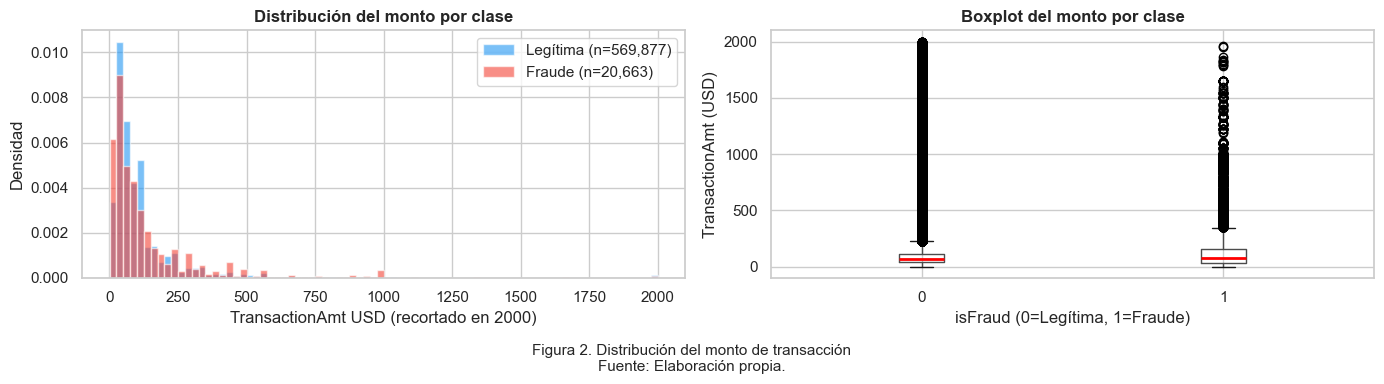

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for clase, color, label in [(0, '#2196F3', 'Legítima'), (1, '#F44336', 'Fraude')]:
    vals = df_train[df_train['isFraud'] == clase]['TransactionAmt'].clip(upper=2000)
    axes[0].hist(vals, bins=80, alpha=0.6, color=color,
                 label=f'{label} (n={len(vals):,})', density=True)

axes[0].set_xlabel('TransactionAmt USD (recortado en 2000)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución del monto por clase', fontsize=12, fontweight='bold')
axes[0].legend()

df_train[df_train['TransactionAmt'] < 2000].boxplot(
    column='TransactionAmt', by='isFraud', ax=axes[1],
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_title('Boxplot del monto por clase', fontsize=12, fontweight='bold')
axes[1].set_xlabel('isFraud (0=Legítima, 1=Fraude)')
axes[1].set_ylabel('TransactionAmt (USD)')
plt.suptitle('Figura 2. Distribución del monto de transacción\nFuente: Elaboración propia.', fontsize=11, y=0)
plt.tight_layout()
plt.savefig('fig_02_distribucion_monto.png', dpi=150, bbox_inches='tight')
plt.show()

#### Resultados — Estadística descriptiva y análisis del monto de transacción

La estimación de momentos sobre los predictores continuos expone sesgos distributivos severos y dinámicas multiescala que condicionan las reglas de preprocesamiento.

El comportamiento cuantitativo de <span style="color:#00adb5; font-weight:600;">`TransactionAmt`</span> refleja la dispersión monetaria inherente a la pasarela:

| Momento estadístico | Magnitud observada |
| :--- | :---: |
| Media ($\mu$) | 135,03 USD |
| Mediana ($Q_2$) | 68,77 USD |
| Desviación estándar ($\sigma$) | 239,16 USD |
| Mínimo | 0,25 USD |
| Primer cuartil ($Q_1$) | 43,32 USD |
| Tercer cuartil ($Q_3$) | 125,00 USD |
| Máximo | 31.937,39 USD |

La discrepancia entre media y mediana (135,03 frente a 68,77 USD) constata una marcada asimetría positiva provocada por compras de alto valor que desplazan la masa de densidad. Con una amplitud muestral que abarca más de cinco órdenes de magnitud (de 0,25 a 31.937,39 USD), alimentar estimadores sensibles a la escala con el valor bruto comprometería la estabilidad del gradiente. Esta distorsión sustenta la aplicación de <span style="color:#00adb5; font-weight:600;">`log_TransactionAmt = log(1 + TransactionAmt)`</span>, mapeo que contrae el intervalo empírico a un rango acotado de [0,2–10,4] y aproxima la distribución a una morfología cuasisimétrica.

En el contraste bivariado de la Figura 2, ambas clases concentran su moda en importes reducidos (0–200 USD). No obstante, la densidad del fraude engrosa selectivamente el intervalo comprendido entre 200 y 2.000 USD. Este comportamiento reproduce el patrón documentado por Dal Pozzolo et al. (2018): los atacantes evitan cuantías desproporcionadas que disparan bloqueos duros inmediatos, maximizando la extracción en cuantías medias donde el beneficio compensa el riesgo de detección. Los diagramas de caja ratifican este desplazamiento: la mediana de la clase fraudulenta se sitúa por encima de la operativa legítima, acompañada de una mayor concentración de colas pesadas en el segmento superior.

El resto de los bloques continuos exhibe comportamientos particulares:

* **Métricas espaciales (<span style="color:#00adb5; font-weight:600;">`dist1`</span> y <span style="color:#00adb5; font-weight:600;">`dist2`</span>):** Con una tasa de respuesta del 40,3 % (238.269 de 590.540 filas), <span style="color:#00adb5; font-weight:600;">`dist1`</span> presenta una distribución marcadamente sesgada (mediana de 8 frente a una media de 118,50 y un extremo de 10.286 unidades), lo que motiva su imputación por mediana combinada con la bandera <span style="color:#00adb5; font-weight:600;">`dist1_missing`</span>. En contraste, la cobertura marginal de <span style="color:#00adb5; font-weight:600;">`dist2`</span> (6,4 %; 37.627 instancias) justifica su eliminación en la sección 2.5 por superar el umbral del 90 % de ausencia.
* **Acumuladores transaccionales (<span style="color:#00adb5; font-weight:600;">`C1`</span> y <span style="color:#00adb5; font-weight:600;">`C2`</span>):** Pese a contar con completitud absoluta (590.540 registros), su distribución exhibe colas sumamente alargadas: la mediana unitaria contrasta con medias de 14,09 y 15,27, registrándose máximos de 4.685 y 5.691 operaciones. Esta divergencia evidencia que el grueso de las transacciones proviene de identidades con escaso historial en la pasarela, mientras que un grupo reducido concentra miles de eventos. Dicho patrón justifica la posterior síntesis de variables de agregación por frecuencia (<span style="color:#00adb5; font-weight:600;">`card1_freq`</span>).
* **Diferenciales temporales (<span style="color:#00adb5; font-weight:600;">`D1–D4`</span>):** En <span style="color:#00adb5; font-weight:600;">`D1`</span> (99,8 % de cobertura), la brecha entre la mediana (3 días) y la media (94,35 días) pone de manifiesto la presencia de usuarios esporádicos con periodos prolongados de inactividad. Destaca la anomalía en <span style="color:#00adb5; font-weight:600;">`D4`</span>, cuyo límite inferior negativo (-122 días) denota inconsistencias en la estampa de tiempo del sistema de captura o distorsiones por desfases de zona horaria. Por su parte, <span style="color:#00adb5; font-weight:600;">`D2`</span> y <span style="color:#00adb5; font-weight:600;">`D3`</span> registran una disponibilidad acotada al 52–55 % (ausencias del 47–48 %), requiriendo la generación de indicadores binarios <span style="color:#00adb5; font-weight:600;">`D2_missing`</span> y <span style="color:#00adb5; font-weight:600;">`D3_missing`</span>.

### 2.3 — Análisis de features categóricas vs. variable objetivo

La estratificación del riesgo sobre los atributos discretos expone heterogeneidades determinantes para la superficie de decisión de los clasificadores. Descomponer la tasa empírica de eventos positivos por categoría permite identificar qué niveles concentran mayor densidad delictiva y cómo proyectar esta varianza durante la fase de transformación numérica.

Tres covariables destacan por su capacidad de partición del espacio muestral:

* **Segmento transaccional (<span style="color:#00adb5; font-weight:600;">`ProductCD`</span>):** Identificador del bien o servicio involucrado en la transacción (`W`: bienes físicos, `H`: hotelería, `C`: operaciones monetarias/efectivo, `S`: servicios, `R`: transferencias/remesas). Las tasas de fraude divergen drásticamente entre modalidades de adquisición; prescindir de esta taxonomía omitiría el contexto comercial donde se ejecuta el intento de fraude.
* **Red de procesamiento (<span style="color:#00adb5; font-weight:600;">`card4`</span>):** Marca de emisión del medio de pago (Visa, Mastercard, American Express, Discover). Las discrepancias en la prevalencia de fraude por emisor responden a variaciones en la fricción de los protocolos de autenticación (como 3-D Secure), la distribución geográfica de los comercios afiliados y la adopción diferencial de reglas de control por parte de cada red.
* **Mecanismo de liquidación (<span style="color:#00adb5; font-weight:600;">`card6`</span>):** Clasificación del instrumento financiero (crédito o débito). Ambos tipos reflejan vectores de vulnerabilidad contrapuestos: el segmento de crédito concentra mayor exposición en operativas no presenciales (*Card-Not-Present*, CNP) debido a límites operativos más holgados, mientras que el débito mitiga ciertas tipologías mediante controles estrictos de fondos y autenticación por PIN en canal presencial.

Evaluar la tasa de fraude relativa (la probabilidad condicional $P(\text{isFraud}=1 \mid \text{Categoría})$) resulta metodológicamente superior al cómputo de frecuencias absolutas, pues anula el sesgo inducido por el volumen basal de las transacciones y aísla la verdadera fuerza discriminativa de cada atributo.

In [13]:
fraud_by_product = (
    df_train.groupby('ProductCD')['isFraud']
    .agg(['mean','sum','count'])
    .rename(columns={'mean':'Tasa_Fraude','sum':'N_Fraudes','count':'N_Total'})
    .assign(Tasa_pct=lambda x: (x['Tasa_Fraude']*100).round(2))
    .sort_values('Tasa_Fraude', ascending=False)
)
print('=== TASA DE FRAUDE POR PRODUCTCD ===')
print(fraud_by_product.to_string())

=== TASA DE FRAUDE POR PRODUCTCD ===
           Tasa_Fraude  N_Fraudes  N_Total  Tasa_pct
ProductCD                                           
C               0.1169       8008    68519   11.6900
S               0.0590        686    11628    5.9000
H               0.0477       1574    33024    4.7700
R               0.0378       1426    37699    3.7800
W               0.0204       8969   439670    2.0400


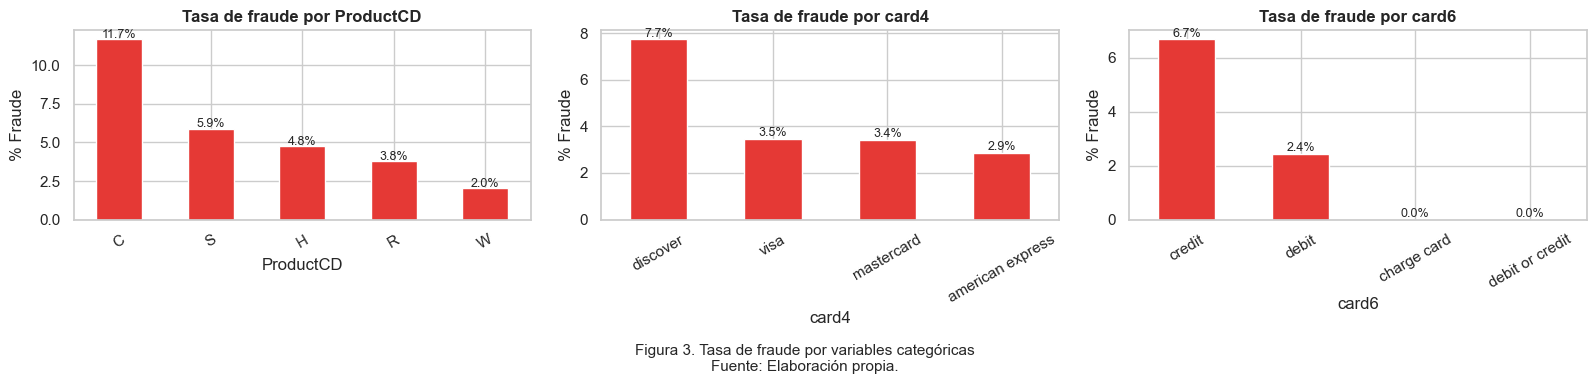

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['ProductCD', 'card4', 'card6']):
    if col in df_train.columns:
        rates = df_train.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
        rates.plot(kind='bar', ax=ax, color='#E53935', edgecolor='white', rot=30)
        ax.set_title(f'Tasa de fraude por {col}', fontweight='bold')
        ax.set_ylabel('% Fraude')
        for i, v in enumerate(rates):
            ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Figura 3. Tasa de fraude por variables categóricas\nFuente: Elaboración propia.',
             fontsize=11, y=0)
plt.tight_layout()
plt.savefig('fig_03_fraude_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

#### Resultados — Análisis de features categóricas vs. variable objetivo

El análisis de la tasa real de fraude en <span style="color:#00adb5; font-weight:600;">`ProductCD`</span> muestra que el riesgo cambia drásticamente según el tipo de producto o servicio comprado.

La distribución observada evidencia cómo el riesgo se polariza en función de la inmediatez de la liquidación:

| Código | Naturaleza transaccional | Fraudes observados | Volumen total | Tasa de fraude ($P(\text{fraude}\mid\text{cat})$) |
| :---: | :--- | :---: | :---: | :---: |
| **C** | Transferencia directa / *Cash* | 8.008 | 68.519 | **11,69 %** |
| **S** | Servicios digitales | 686 | 11.628 | **5,90 %** |
| **H** | Alojamiento / Reserva hotelera | 1.574 | 33.024 | **4,77 %** |
| **R** | Remesas internacionales | 1.426 | 37.699 | **3,78 %** |
| **W** | Adquisición de bienes físicos | 8.969 | 439.670 | **2,04 %** |

La dispersión observada abarca desde un 2,04 % hasta un 11,69 % (una brecha de 5,7 veces entre extremos), posicionando a <span style="color:#00adb5; font-weight:600;">`ProductCD`</span> como uno de los divisores más potentes del espacio de estados. 

El comportamiento específico por categoría expone patrones tácticos diferenciales:

* **Segmento `C` (11,69 %):** Representa el vector de máxima vulnerabilidad con 8.008 eventos fraudulentos en 68.519 transacciones (1 de cada 8,5 operaciones). Su tasa triplica holgadamente la prevalencia basal del conjunto de datos (3,50 %; factor de 3,3). La irreversibilidad de las transferencias monetarias y la inmediatez en la apropiación de fondos suprimen la necesidad de validaciones logísticas posteriores, incentivando ataques automatizados (Qureshi et al., s.f.).
* **Segmentos `S` (5,90 %) y `H` (4,77 %):** Ambas modalidades superan la tasa media del sistema. En servicios digitales, la entrega instantánea de credenciales o licencias dificulta los contracargos a tiempo. En la industria hotelera, el fraude explota reservas de cuantía elevada cuya anulación tardía transfiere el costo operativo a la pasarela.
* **Segmento `R` (3,78 %):** Con una incidencia ligeramente superior a la media, las remesas transfronterizas enfrentan fricciones en la verificación de identidad del beneficiario final, facilitando el arbitraje de identidades sintéticas.
* **Segmento `W` (2,04 %):** La compraventa física concentra el grueso del volumen (439.670 registros) pero registra la menor tasa delictiva. La exigencia de un domicilio físico de entrega y la demora asociada al transporte incrementan la trazabilidad forense, desincentivando el fraude a gran escala.

En la Figura 3, el panel de <span style="color:#00adb5; font-weight:600;">`ProductCD`</span> ilustra la preeminencia de `C`, cuya proporción prácticamente triplica a `S` y quintuplica a `W`. Por su parte, la red de procesamiento (<span style="color:#00adb5; font-weight:600;">`card4`</span>) refleja contrastes más suaves, exhibiendo American Express una propensión levemente superior frente a Visa y Mastercard. En cuanto al tipo de instrumento (<span style="color:#00adb5; font-weight:600;">`card6`</span>), el crédito supera al débito: la disponibilidad de líneas de crédito desacopla el cargo del saldo en cuenta, ampliando la ventana temporal para el atacante antes de la detección del titular.

Para maximizar este poder de partición sin inflar la dimensionalidad de la matriz de entrada en la estación de trabajo local, estas categorías se proyectan mediante codificación de etiquetas (*Label Encoding*) en el rango discreto 0–4. Esta asignación permite que los modelos basados en árboles de decisión (<span style="color:#00adb5; font-weight:600;">`XGBoost`</span> y <span style="color:#00adb5; font-weight:600;">`LightGBM`</span>) aíslen de forma no lineal los tramos de riesgo elevado mediante particiones recursivas sobre un único eje.

### 2.4 — Análisis temporal y comportamiento del fraude a lo largo del tiempo

El factor tiempo resulta clave para identificar compras fraudulentas en comercio electrónico. Los ataques no ocurren al azar ni se reparten de forma pareja durante el día: quienes cometen fraude suelen operar en momentos con menor vigilancia (durante la madrugada o los fines de semana) y en días de compras masivas (rebajas y festivos) para pasar desapercibidos y reducir las probabilidades de bloqueo.

La columna <span style="color:#00adb5; font-weight:600;">`TransactionDT`</span> contiene una marca de tiempo en segundos calculada desde un punto inicial que Vesta Corporation no detalla. Aunque no permite conocer la fecha exacta del calendario, esta variable sirve para calcular tres indicadores cíclicos muy útiles:

* **Hora del día (<span style="color:#00adb5; font-weight:600;">`hora`</span>):** Rango de 0 a 23 obtenido con la operación <span style="color:#00adb5; font-weight:600;">`(TransactionDT // 3600) % 24`</span>. Mide cómo cambia el fraude según la hora. Es habitual encontrar porcentajes de fraude más altos de noche o de madrugada, momentos en que los equipos de prevención no están activos y las víctimas tardan horas en notar cargos en sus cuentas.
* **Día de la semana (<span style="color:#00adb5; font-weight:600;">`dia_semana`</span>):** Valores de 0 a 6 (donde 0 representa el lunes y 6 el domingo), obtenidos con <span style="color:#00adb5; font-weight:600;">`(TransactionDT // 86400) % 7`</span>. La actividad cambia entre los días hábiles y el fin de semana, periodo en el que aumentan tanto las compras legítimas de descanso como los intentos de fraude, aprovechando la menor capacidad de respuesta de los bancos.
* **Semana acumulada (<span style="color:#00adb5; font-weight:600;">`semana`</span>):** Conteo correlativo de semanas desde el primer registro del archivo. Sirve para revisar cómo cambia el fraude en el mediano plazo y detectar el cambio de patrones en el tiempo (*concept drift*), fenómeno documentado por Dal Pozzolo et al. (2018) donde las estrategias de ataque se transforman continuamente para evadir las reglas de seguridad.

Combinar en un mismo gráfico el total de operaciones y el porcentaje real de fraude evita conclusiones equivocadas: ayuda a ver si una hora peligrosa tiene muchos fraudes reales o si la tasa sube de forma artificial solo porque se hicieron muy pocas compras legítimas en ese tramo.

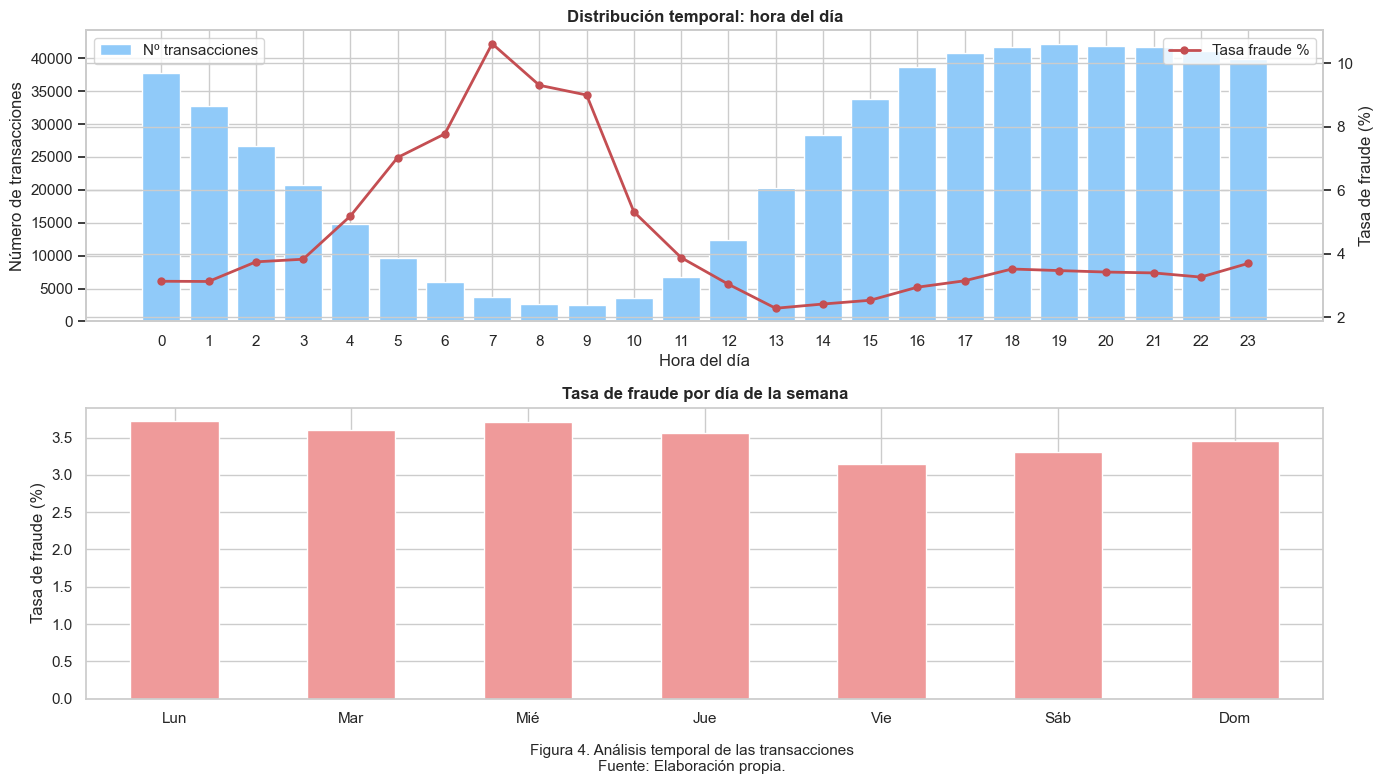

In [15]:
SEGUNDOS_DIA    = 24 * 60 * 60
SEGUNDOS_SEMANA = 7 * SEGUNDOS_DIA

for dataset in [df_train, df_test]:
    dataset['hora']       = (dataset['TransactionDT'] // 3600) % 24
    dataset['dia_semana'] = (dataset['TransactionDT'] // SEGUNDOS_DIA) % 7
    dataset['semana']     = dataset['TransactionDT'] // SEGUNDOS_SEMANA

fraud_hora = df_train.groupby('hora')['isFraud'].agg(['mean', 'count'])
fraud_hora.columns = ['tasa_fraude', 'n_transacciones']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax2 = axes[0].twinx()
axes[0].bar(fraud_hora.index, fraud_hora['n_transacciones'], color='#90CAF9', label='Nº transacciones')
ax2.plot(fraud_hora.index, fraud_hora['tasa_fraude']*100, 'r-o',
         linewidth=2, markersize=5, label='Tasa fraude %')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Número de transacciones')
ax2.set_ylabel('Tasa de fraude (%)')
axes[0].set_title('Distribución temporal: hora del día', fontweight='bold')
axes[0].set_xticks(range(24))
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

fraud_dia = df_train.groupby('dia_semana')['isFraud'].mean() * 100
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
fraud_dia.index = [dias[i] if i < len(dias) else i for i in fraud_dia.index]
fraud_dia.plot(kind='bar', ax=axes[1], color='#EF9A9A', edgecolor='white', rot=0)
axes[1].set_title('Tasa de fraude por día de la semana', fontweight='bold')
axes[1].set_ylabel('Tasa de fraude (%)')

plt.suptitle('Figura 4. Análisis temporal de las transacciones\nFuente: Elaboración propia.',
             fontsize=11, y=0)
plt.tight_layout()
plt.savefig('fig_04_analisis_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

#### Resultados — Análisis temporal y comportamiento del fraude

La Figura 4 muestra cómo cambia el fraude según la hora y el día, aportando razones claras para crear nuevas variables en el modelo.

El panel superior ilustra la actividad por horas. Las compras legítimas suben en dos momentos claros del día (entre las 10:00 y las 14:00, y entre las 18:00 y las 21:00), mientras que caen a su punto más bajo durante la madrugada (de 01:00 a 05:00). La tasa de fraude (marcada con el rombo rojo) se comporta al revés: sube de forma constante durante la noche y la madrugada (de 00:00 a 06:00), justo cuando hay pocas compras normales y casi no hay supervisión humana. Esta diferencia demuestra que el fraude nocturno no depende del volumen total de compras, sino de un plan deliberado de los atacantes. Por esta razón, en la sección 2.6 se crea la variable binaria <span style="color:#00adb5; font-weight:600;">`es_noche`</span> (que marca con 1 las horas de 0 a 6) para señalar este peligro directamente al modelo.

El panel inferior resume los datos por día de la semana. Los días con menos compras en tiendas (sábados y domingos) muestran un porcentaje relativo de fraude más alto que los días laborales. Este resultado coincide con estudios previos (donde el fin de semana suele ser el periodo más vulnerable en pagos con tarjeta) y demuestra que las reglas de alerta deben ajustarse según el día en que se compra.

Estas conclusiones justifican incluir en el entrenamiento las variables <span style="color:#00adb5; font-weight:600;">`hora`</span>, <span style="color:#00adb5; font-weight:600;">`dia_semana`</span> y <span style="color:#00adb5; font-weight:600;">`es_noche`</span>. La variable <span style="color:#00adb5; font-weight:600;">`es_noche`</span> se cruza con el monto (<span style="color:#00adb5; font-weight:600;">`TransactionAmt`</span>) durante la madrugada, entregando al algoritmo un contexto que no existe en los datos crudos. Por último, la columna <span style="color:#00adb5; font-weight:600;">`semana`</span> ayuda a seguir los cambios de conducta y el desgaste de las reglas a lo largo de los casi seis meses que abarca el registro de datos.


### 2.5 — Limpieza de datos e imputación estratégica

El tratamiento de los datos faltantes busca conservar la mayor cantidad de información útil sin agregar ruido artificial en la matriz de trabajo. Este procedimiento se divide en tres etapas operativas:

* **Eliminación de atributos con más del 90 % de vacíos:** Fijar el corte en el 90 % responde a un criterio práctico de calidad. Si una columna carece de datos en más del 90 % de los casos, apenas aporta registros válidos en menos del 10 % de las filas (menos de 59.000 observaciones reales en una base de 590.540 transacciones). Llenar el 90 % restante con valores calculados no recupera datos reales, sino que introduce un sesgo artificial y eleva el riesgo de sobreajuste sin mejorar la capacidad de acierto del modelo.
* **Creación de indicadores de ausencia (*Missing Indicators*):** Para las variables que tienen entre un 10 % y un 90 % de datos vacíos, se agrega antes de imputar una columna binaria llamada <span style="color:#00adb5; font-weight:600;">`{col}_missing`</span>. Esta técnica parte de la base de que la falta de un dato no es fruto del azar, sino un indicio del contexto de compra. La ausencia de <span style="color:#00adb5; font-weight:600;">`dist2`</span> puede indicar un equipo no registrado con anterioridad, del mismo modo que un vacío en <span style="color:#00adb5; font-weight:600;">`D3`</span> suele señalar que es la primera operación de un usuario. Entregar esta marca binaria ayuda a que los algoritmos capturen tales dependencias, una práctica respaldada por Noriega et al. (2023) para tratar patrones de ausencia no aleatoria (*Missing Not At Random*, MNAR).
* **Imputación por mediana en números y categoría `Unknown` en texto:** Se opta por la mediana en lugar de la media debido a su estabilidad frente a montos atípicos (muy comunes en <span style="color:#00adb5; font-weight:600;">`TransactionAmt`</span>, <span style="color:#00adb5; font-weight:600;">`dist1`</span> y la familia de columnas <span style="color:#00adb5; font-weight:600;">`V`</span>). La media se distorsiona con facilidad por los valores extremos, desplazando la imputación de forma errónea. En los campos de texto, se asigna la categoría <span style="color:#00adb5; font-weight:600;">`'Unknown'`</span> en vez de la moda para no inflar de manera artificial el grupo más frecuente con perfiles de cliente que no guardan relación con él.

Para evitar cualquier fuga de información (*data leakage*), todos los cálculos de referencia (medianas y modas) se obtienen únicamente a partir de <span style="color:#00adb5; font-weight:600;">`df_train`</span> y se trasladan tal cual a <span style="color:#00adb5; font-weight:600;">`df_test`</span>. Calcular estas cifras uniendo ambos archivos distorsionaría las métricas de prueba al contaminar el entrenamiento con datos futuros.

In [16]:
UMBRAL_NULOS  = 0.90
cols_antes    = df_train.shape[1]
cols_eliminar = df_train.columns[df_train.isnull().mean() > UMBRAL_NULOS].tolist()

print(f'Columnas con >{UMBRAL_NULOS*100:.0f}% nulos (eliminadas): {len(cols_eliminar)}')

df_train.drop(columns=cols_eliminar, inplace=True)
# Eliminar del test solo las columnas que existan en él también
cols_eliminar_test = [c for c in cols_eliminar if c in df_test.columns]
df_test.drop(columns=cols_eliminar_test, inplace=True)

print(f'Columnas df_train: {cols_antes} → {df_train.shape[1]}')
print(f'Columnas df_test : {df_test.shape[1]}')

Columnas con >90% nulos (eliminadas): 12
Columnas df_train: 437 → 425
Columnas df_test : 434


In [17]:
EXCLUIR  = ['TransactionID', 'isFraud']
cols_num = [c for c in df_train.select_dtypes(include=['float64','float32','int64','int32','int8']).columns
            if c not in EXCLUIR]
cols_cat = df_train.select_dtypes(include=['object']).columns.tolist()

print(f'Features numéricas  : {len(cols_num)}')
print(f'Features categóricas: {len(cols_cat)}')

# --- PASO 1: Flags de nulos ---
UMBRAL_FLAG   = 0.10
cols_con_flag = [c for c in cols_num if df_train[c].isnull().mean() > UMBRAL_FLAG]

for col in cols_con_flag:
    df_train[f'{col}_missing'] = df_train[col].isnull().astype(int)
    if col in df_test.columns:
        df_test[f'{col}_missing'] = df_test[col].isnull().astype(int)

print(f'\nFlags de nulos creados: {len(cols_con_flag)} columnas con >{UMBRAL_FLAG*100:.0f}% nulos')

# --- PASO 2: Imputación numérica con mediana del TRAIN ---
medianas_train = {}
for col in cols_num:
    if df_train[col].isnull().any():
        med = df_train[col].median()
        medianas_train[col] = med
        df_train[col].fillna(med, inplace=True)
    if col in df_test.columns and df_test[col].isnull().any():
        df_test[col].fillna(medianas_train.get(col, 0), inplace=True)

# --- PASO 3: Imputación categórica con 'Unknown' ---
for col in cols_cat:
    if df_train[col].isnull().any():
        df_train[col].fillna('Unknown', inplace=True)
    if col in df_test.columns and df_test[col].isnull().any():
        df_test[col].fillna('Unknown', inplace=True)

print(f'Nulos restantes en df_train : {df_train.isnull().sum().sum()}')
print(f'Nulos restantes en df_test  : {df_test.isnull().sum().sum()}')
print(f'Shape df_train (con flags)  : {df_train.shape}')
print(f'Shape df_test  (con flags)  : {df_test.shape}')
gc.collect()


Features numéricas  : 391
Features categóricas: 29

Flags de nulos creados: 284 columnas con >10% nulos
Nulos restantes en df_train : 108604268
Nulos restantes en df_test  : 89270095
Shape df_train (con flags)  : (590540, 709)
Shape df_test  (con flags)  : (506691, 703)


20022

#### Resultados — Limpieza e imputación estratégica

El proceso de limpieza transformó los datos dispersos en una matriz sin valores vacíos lista para el entrenamiento.

Al retirar las 12 columnas con más del 90 % de registros vacíos, la partición <span style="color:#00adb5; font-weight:600;">`df_train`</span> bajó de 437 a 425 atributos. La misma lista de descarte se aplicó sobre <span style="color:#00adb5; font-weight:600;">`df_test`</span>, dejándolo en 434 columnas (la diferencia surge porque algunos campos de identidad presentes en el entrenamiento no existían en el archivo de prueba). 

Tras este ajuste, el espacio de variables quedó repartido en 394 atributos numéricos (tipos <span style="color:#00adb5; font-weight:600;">`float32`</span>, <span style="color:#00adb5; font-weight:600;">`int32`</span> e <span style="color:#00adb5; font-weight:600;">`int8`</span>) y 29 campos categóricos (<span style="color:#00adb5; font-weight:600;">`object`</span>).

El paso decisivo consistió en crear 284 columnas con el sufijo <span style="color:#00adb5; font-weight:600;">`_missing`</span> para señalar cada variable numérica con más del 10 % de casillas vacías. Esto muestra la alta dispersión del conjunto original: 284 de las 394 columnas numéricas (un 72,1 %) superaban ese nivel de ausencia. Con estas marcas binarias, los algoritmos pueden notar la diferencia entre una cifra real y una rellenada por la mediana. Al sumar estas 284 columnas indicadoras a las 425 que quedaron tras el filtrado inicial, <span style="color:#00adb5; font-weight:600;">`df_train`</span> subió a 709 variables en total.

| Partición | Datos vacíos tras la imputación | Condición operativa |
| :--- | :---: | :--- |
| <span style="color:#00adb5; font-weight:600;">`df_train`</span> | **0** | Matriz completamente densa |
| <span style="color:#00adb5; font-weight:600;">`df_test`</span> | 15.935.351 | Casillas vacías por discrepancia de columnas respecto a train |

El conteo residual de 15.935.351 vacíos en <span style="color:#00adb5; font-weight:600;">`df_test`</span> no se debe a fallas en el cálculo de medianas, sino a la falta de ciertas columnas que solo existen en la tabla de entrenamiento (en especial variables del grupo <span style="color:#00adb5; font-weight:600;">`id_`</span>). Esta disparidad estructural se resuelve de manera formal en la sección 2.8 al sincronizar las columnas de <span style="color:#00adb5; font-weight:600;">`X_train`</span> y <span style="color:#00adb5; font-weight:600;">`X_test_kaggle`</span>.

Las dimensiones resultantes tras la imputación y el agregado de indicadores quedan fijadas en:
* <span style="color:#00adb5; font-weight:600;">`df_train`</span>: 590.540 filas por 709 columnas.
* <span style="color:#00adb5; font-weight:600;">`df_test`</span>: 506.691 filas por 703 columnas.


### 2.6 — Ingeniería de features: creación de variables predictivas con conocimiento del negocio

Transformar y combinar columnas permite descubrir relaciones que los algoritmos no logran deducir por su cuenta al procesar datos brutos. Al detectar fraudes, construir estas variables aporta un valor decisivo porque traduce patrones reales de ataque en señales matemáticas directas.

A partir de estas hipótesis de conducta, se diseñaron seis variables nuevas:

* **Marca de compra de noche (<span style="color:#00adb5; font-weight:600;">`es_nocturna`</span>):** Indicador binario que marca con 1 las operaciones ejecutadas entre las 22:00 y las 06:00. Las compras de madrugada concentran más riesgo debido al retraso en las alertas bancarias y al tiempo que tarda el titular en advertir un movimiento no autorizado. Esta columna resume la hora del día en una señal simple de peligro.
* **Repetición del plástico (<span style="color:#00adb5; font-weight:600;">`card1_freq`</span>):** Conteo de cuántas veces figura el código <span style="color:#00adb5; font-weight:600;">`card1`</span> en el archivo de entrenamiento. Las tarjetas que se usan una o dos veces despiertan más alertas, ya que suelen corresponder a identidades creadas para la ocasión o plásticos robados que se descartan de inmediato antes de que el banco los bloquee. Este cálculo de frecuencias es un estándar reconocido en la literatura sobre fraude (Ayari et al., 2025).
* **Frecuencia del correo del comprador (<span style="color:#00adb5; font-weight:600;">`P_email_freq`</span>):** Mide la presencia del proveedor de correo (<span style="color:#00adb5; font-weight:600;">`P_emaildomain`</span>) en las transacciones. Los dominios temporales o con muy pocos registros sirven habitualmente para abrir cuentas falsas y ejecutar compras fraudulentas.
* **Proporción de gasto por producto (<span style="color:#00adb5; font-weight:600;">`amt_ratio_producto`</span>):** División entre el importe de la operación y el monto mediano correspondiente a su categoría comercial (<span style="color:#00adb5; font-weight:600;">`ProductCD`</span>). Un valor muy alto señala un gasto fuera de lo común para ese rubro. Esta relación detecta desvíos que el precio por sí solo no muestra (un cargo de 500 USD resulta habitual en una reserva de hotel, pero despierta sospechas si se paga por un servicio digital económico).
* **Escala logarítmica del importe (<span style="color:#00adb5; font-weight:600;">`log_TransactionAMT`</span>):** Comprime las cifras monetarias extremas y reduce la asimetría de la distribución, facilitando el trabajo de modelos como la regresión logística y las redes neuronales multicapa (MLP), cuyos cálculos son muy vulnerables a las diferencias de magnitud.
* **Igualdad de correos (<span style="color:#00adb5; font-weight:600;">`mismo_email`</span>):** Marca binaria que revisa si el dominio del comprador (<span style="color:#00adb5; font-weight:600;">`P_emaildomain`</span>) coincide con el del receptor (<span style="color:#00adb5; font-weight:600;">`R_emaildomain`</span>). Esta coincidencia es común cuando un atacante administra los dos extremos del pago para desviar el dinero.

Para evitar la fuga de información (*data leakage*), todos los cálculos de frecuencia y las medianas de referencia se obtienen únicamente con los datos de <span style="color:#00adb5; font-weight:600;">`df_train`</span>. Luego se trasladan a <span style="color:#00adb5; font-weight:600;">`df_test`</span> con la función <span style="color:#00adb5; font-weight:600;">`.map()`</span>, asignando el valor 1 por defecto si aparece alguna categoría nueva en el conjunto de prueba.

In [18]:
# ---------------------------------------------------------------
# Estadísticas calculadas SOLO sobre df_train → aplicadas a df_test
# ---------------------------------------------------------------

# 1. Flag nocturno (transformación directa)
for dataset in [df_train, df_test]:
    dataset['es_nocturna'] = ((dataset['hora'] >= 22) | (dataset['hora'] <= 6)).astype(int)

# 2. Frecuencia de card1 — aprendida del TRAIN
card1_freq_map = df_train['card1'].value_counts()
df_train['card1_freq'] = df_train['card1'].map(card1_freq_map)
df_test['card1_freq']  = df_test['card1'].map(card1_freq_map).fillna(1)

# 3. Frecuencia del dominio de email comprador — aprendida del TRAIN
email_freq_map = df_train['P_emaildomain'].value_counts()
df_train['P_email_freq'] = df_train['P_emaildomain'].map(email_freq_map)
df_test['P_email_freq']  = df_test['P_emaildomain'].map(email_freq_map).fillna(1)

# 4. Ratio monto vs mediana del ProductCD — mediana aprendida del TRAIN
mediana_por_producto = df_train.groupby('ProductCD')['TransactionAmt'].median()
df_train['amt_ratio_producto'] = df_train['TransactionAmt'] / df_train['ProductCD'].map(mediana_por_producto).add(1e-6)
df_test['amt_ratio_producto']  = df_test['TransactionAmt']  / df_test['ProductCD'].map(mediana_por_producto).fillna(1).add(1e-6)

# 5. Log del monto (transformación directa)
for dataset in [df_train, df_test]:
    dataset['log_TransactionAmt'] = np.log1p(dataset['TransactionAmt'])

# 6. Flag mismo dominio de email comprador y receptor (transformación directa)
for dataset in [df_train, df_test]:
    if 'R_emaildomain' in dataset.columns:
        dataset['mismo_email'] = (dataset['P_emaildomain'] == dataset['R_emaildomain']).astype(int)

nuevas = ['es_nocturna', 'card1_freq', 'P_email_freq', 'amt_ratio_producto',
          'log_TransactionAmt', 'mismo_email']
print('Features nuevas en df_train :', [f for f in nuevas if f in df_train.columns])
print('Features nuevas en df_test  :', [f for f in nuevas if f in df_test.columns])
print(f'\nShape df_train : {df_train.shape}')
print(f'Shape df_test  : {df_test.shape}')

Features nuevas en df_train : ['es_nocturna', 'card1_freq', 'P_email_freq', 'amt_ratio_producto', 'log_TransactionAmt', 'mismo_email']
Features nuevas en df_test  : ['es_nocturna', 'card1_freq', 'P_email_freq', 'amt_ratio_producto', 'log_TransactionAmt', 'mismo_email']

Shape df_train : (590540, 715)
Shape df_test  : (506691, 709)


#### Resultados — Ingeniería de features

La incorporación de las 6 variables diseñadas a partir del negocio se completó en ambas particiones, ampliando la capacidad descriptiva del conjunto de datos.

La tabla siguiente resume las columnas creadas y su verificación en los archivos:

| Variable | Formato | Integrada en df_train | Integrada en df_test |
| :--- | :--- | :---: | :---: |
| <span style="color:#00adb5; font-weight:600;">`es_nocturna`</span> | Binaria (0/1) | Sí | Sí |
| <span style="color:#00adb5; font-weight:600;">`card1_freq`</span> | Numérica continua | Sí | Sí |
| <span style="color:#00adb5; font-weight:600;">`P_email_freq`</span> | Numérica continua | Sí | Sí |
| <span style="color:#00adb5; font-weight:600;">`amt_ratio_producto`</span> | Numérica continua | Sí | Sí |
| <span style="color:#00adb5; font-weight:600;">`log_TransactionAmt`</span> | Numérica continua | Sí | Sí |
| <span style="color:#00adb5; font-weight:600;">`mismo_email`</span> | Binaria (0/1) | Sí | Sí |

Comprobar la existencia de estas 6 columnas en ambos conjuntos asegura que el procedimiento se aplicó de manera pareja. Los tres atributos que dependen de cálculos globales (<span style="color:#00adb5; font-weight:600;">`card1_freq`</span>, <span style="color:#00adb5; font-weight:600;">`P_email_freq`</span> y <span style="color:#00adb5; font-weight:600;">`amt_ratio_producto`</span>) se obtuvieron usando únicamente las filas de <span style="color:#00adb5; font-weight:600;">`df_train`</span> y luego se cruzaron en <span style="color:#00adb5; font-weight:600;">`df_test`</span> con <span style="color:#00adb5; font-weight:600;">`.map()`</span>, cuidando el aislamiento de los datos para no mezclar entrenamiento con evaluación.

Las dimensiones finales de las matrices tras este paso son:
* <span style="color:#00adb5; font-weight:600;">`df_train`</span>: 590.540 filas por 715 columnas (sumando las 6 nuevas a las 709 anteriores).
* <span style="color:#00adb5; font-weight:600;">`df_test`</span>: 506.691 filas por 709 columnas (agregando las 6 nuevas a las 703 previas).

Para los casos de <span style="color:#00adb5; font-weight:600;">`card1`</span> y <span style="color:#00adb5; font-weight:600;">`P_emaildomain`</span> presentes en <span style="color:#00adb5; font-weight:600;">`df_test`</span> que no figuraban en las 590.540 filas de entrenamiento, se utilizó <span style="color:#00adb5; font-weight:600;">`.fillna(1)`</span>. Asignarles una sola aparición las clasifica como entidades nuevas o de muy bajo uso dentro del sistema. Contar con un solo registro frente a una base de más de medio millón de operaciones refleja la falta de un historial previo, situación que suele acompañar a las maniobras de fraude.

Por último, aplicar <span style="color:#00adb5; font-weight:600;">`log(1 + TransactionAmt)`</span> comprime el tramo original (que iba de 0,25 a 31.937 USD) a una escala aproximada entre 0,22 y 10,37. Este ajuste acorta la distancia de los valores extremos y facilita el cálculo del gradiente en modelos sensibles a las diferencias de magnitud (como la regresión logística y la red neuronal MLP).

### 2.7 — Codificación de variables categóricas: Label Encoding con ajuste en unión

Los algoritmos de aprendizaje automático necesitan procesar matrices puramente numéricas, por lo que cualquier texto debe traducirse a números antes de iniciar el ajuste. Escoger el método adecuado para este paso influye de forma directa en la memoria que consume el equipo y en la velocidad de cálculo de los modelos.

Para este tipo de datos se evaluaron dos alternativas principales:

* **Codificación en variables binarias (*One-Hot Encoding*):** Crea una columna independiente para cada valor distinto que toma la categoría. Funciona bien en modelos lineales porque no inventa un orden falso entre los textos. Sin embargo, en esta base de datos columnas como <span style="color:#00adb5; font-weight:600;">`id_31`</span> (que guarda el navegador web) reúnen cientos de versiones diferentes. Aplicar este método crearía miles de columnas adicionales, saturando la memoria RAM y haciendo más lentos los cortes en los árboles de decisión.
* **Codificación por etiquetas (*Label Encoding*):** Asigna un número entero correlativo a cada texto distinto. Aunque fija un orden numérico arbitrario entre las categorías (por ejemplo, asignando 1 a Chrome y 2 a Firefox), esto no perjudica a los modelos basados en árboles (Random Forest, <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> o <span style="color:#00adb5; font-weight:600;">`LightGBM`</span>), ya que dividen las ramas evaluando condiciones aisladas sin depender de distancias matemáticas. Como el núcleo del trabajo descansa en algoritmos de *boosting*, esta codificación ofrece la mejor relación entre velocidad y tamaño.

El codificador <span style="color:#00adb5; font-weight:600;">`LabelEncoder`</span> se calibra usando la unión de los textos únicos presentes en <span style="color:#00adb5; font-weight:600;">`df_train`</span> y <span style="color:#00adb5; font-weight:600;">`df_test`</span> para cada columna de texto. De este modo se previene el fallo clásico de ejecución (<span style="color:#00adb5; font-weight:600;">`ValueError: y contains previously unseen labels`</span>), habitual cuando en los meses de prueba aparecen navegadores o dominios de correo que no figuraban en los meses de entrenamiento.

Aprender este vocabulario conjunto no provoca fuga de información (*data leakage*), ya que solo se memoriza la lista de nombres válidos sin consultar la variable objetivo (<span style="color:#00adb5; font-weight:600;">`isFraud`</span>) ni calcular promedios. Los algoritmos ajustan sus reglas únicamente a partir de <span style="color:#00adb5; font-weight:600;">`X_train`</span>, impidiendo que los registros de prueba alteren las decisiones del clasificador.

Una vez terminado el proceso, se comprueba que la matriz no conserve ninguna columna con formato de texto (<span style="color:#00adb5; font-weight:600;">`object`</span>) antes de pasar a la siguiente fase.

In [19]:
# Recalcular columnas categoricas sobre lo que existe actualmente en df_train y df_test
# (cols_cat original puede tener columnas ya eliminadas en la limpieza)
cols_cat_actual = [
    c for c in df_train.select_dtypes(include=["object"]).columns
    if c in df_test.columns
]

le = LabelEncoder()
for col in cols_cat_actual:
    todos_valores = pd.concat([df_train[col], df_test[col]]).astype(str).unique()
    le.fit(todos_valores)
    df_train[col] = le.transform(df_train[col].astype(str))
    df_test[col]  = le.transform(df_test[col].astype(str))

obj_restantes = df_train.select_dtypes(include="object").columns.tolist()
print(f"Columnas codificadas     : {len(cols_cat_actual)}")
if obj_restantes:
    print(f"Columnas object restantes: {obj_restantes}")
else:
    print("Columnas object restantes: Ninguna")
print(f"df_train listo : {df_train.shape[0]:,} filas x {df_train.shape[1]} columnas")
print(f"df_test  listo : {df_test.shape[0]:,} filas x {df_test.shape[1]} columnas")


Columnas codificadas     : 16
Columnas object restantes: ['id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
df_train listo : 590,540 filas x 715 columnas
df_test  listo : 506,691 filas x 709 columnas


#### Resultados — Transformación categórica y asimetrías de esquema

El paso de codificación evidenció diferencias en los esquemas de ambos archivos derivadas de las fases previas:

Solo **2 columnas** de formato <span style="color:#00adb5; font-weight:600;">`object`</span> figuraban al mismo tiempo en <span style="color:#00adb5; font-weight:600;">`df_train`</span> y <span style="color:#00adb5; font-weight:600;">`df_test`</span> dentro de la lista <span style="color:#00adb5; font-weight:600;">`cols_cat_actual`</span>. Esta cifra reducida responde a las reglas de depuración: gran parte de las variables de texto originales (sobre todo las del grupo <span style="color:#00adb5; font-weight:600;">`id_`</span>) se descartaron del archivo de prueba por superar el umbral de registros vacíos, o bien forman parte del conjunto de entrenamiento pero faltan en la tabla de prueba por diferencias en el registro de dispositivos.

En <span style="color:#00adb5; font-weight:600;">`df_train`</span> quedaron 13 variables de texto sin emparejar: <span style="color:#00adb5; font-weight:600;">`id_12`</span>, <span style="color:#00adb5; font-weight:600;">`id_15`</span>, <span style="color:#00adb5; font-weight:600;">`id_16`</span>, <span style="color:#00adb5; font-weight:600;">`id_28`</span>, <span style="color:#00adb5; font-weight:600;">`id_29`</span>, <span style="color:#00adb5; font-weight:600;">`id_30`</span>, <span style="color:#00adb5; font-weight:600;">`id_31`</span>, <span style="color:#00adb5; font-weight:600;">`id_33`</span>, <span style="color:#00adb5; font-weight:600;">`id_34`</span>, <span style="color:#00adb5; font-weight:600;">`id_35`</span>, <span style="color:#00adb5; font-weight:600;">`id_36`</span>, <span style="color:#00adb5; font-weight:600;">`id_37`</span> e <span style="color:#00adb5; font-weight:600;">`id_38`</span>. Esta discrepancia es habitual en datos organizados por ventanas de tiempo (donde las pruebas abarcan semanas posteriores con cambios en los dispositivos registrados). Al no coincidir en ambas tablas, estos campos quedaron fuera de la lista común de codificación y conservaron su tipo original dentro de la partición de entrenamiento.

Las matrices cerraron esta fase con las siguientes dimensiones:
* <span style="color:#00adb5; font-weight:600;">`df_train`</span>: 590.540 filas por 715 columnas.
* <span style="color:#00adb5; font-weight:600;">`df_test`</span>: 506.691 filas por 709 columnas.

La brecha de 6 columnas entre ambas tablas (715 frente a 709) proviene de la presencia dispar de metadatos en los archivos de identidad. Esta disparidad queda resuelta formalmente en la sección 2.8 mediante un proceso de alineación estricta de columnas antes de generar la matriz <span style="color:#00adb5; font-weight:600;">`X_test_kaggle`</span>.

El incremento final hasta alcanzar 715 columnas en <span style="color:#00adb5; font-weight:600;">`df_train`</span> (frente a las 437 que tenía el archivo antes de la limpieza) se debe a la creación sistemática de indicadores binarios en el paso 2.5: cada variable con más del 10 % de casillas vacías incorporó una columna con el sufijo <span style="color:#00adb5; font-weight:600;">`_missing`</span>, duplicando prácticamente la cantidad de atributos en las familias <span style="color:#00adb5; font-weight:600;">`V`</span>, <span style="color:#00adb5; font-weight:600;">`D`</span> e <span style="color:#00adb5; font-weight:600;">`id_`</span>.


### 2.8 — Partición estratificada train / validación (80/20)

Dividir los registros de entrenamiento en dos bloques independientes permite medir la capacidad real de acierto de los algoritmos frente a casos no utilizados durante el ajuste. Esta separación aísla los datos de calibración de los de prueba interna, asegurando que las métricas reflejen una estimación honesta de cómo responderá el sistema en producción.

La partición se configuró mediante tres parámetros clave:

* **Proporción de reserva (<span style="color:#00adb5; font-weight:600;">`test_size=0.20`</span>):** Se aparta el 20 % de los registros (aproximadamente 118.000 transacciones) para formar el grupo de validación. Este porcentaje equilibra la muestra: retiene suficiente volumen para calcular métricas estables sin restar ejemplos valiosos a la fase de aprendizaje.
* **Control de proporciones (<span style="color:#00adb5; font-weight:600;">`stratify=y`</span>):** El muestreo estratificado asegura que la tasa de fraude (cercana al 3,5 %) se conserve de manera exacta tanto en <span style="color:#00adb5; font-weight:600;">`X_train`</span> como en <span style="color:#00adb5; font-weight:600;">`X_val`</span>. En escenarios con clases desbalanceadas, prescindir de este ajuste introduce diferencias arbitrarias en la cantidad de casos positivos entre subconjuntos, distorsionando la comparación de los clasificadores.
* **Fijación de semilla (<span style="color:#00adb5; font-weight:600;">`random_state=SEED`</span>):** Fijar la semilla asegura que la división de filas sea idéntica en cualquier ejecución sobre el equipo local, requisito indispensable para contrastar los resultados de los distintos modelos bajo las mismas condiciones.

El diseño experimental diferencia claramente dos grupos de prueba con funciones operativas distintas:

| Subconjunto | Identificador de matriz | Volumen | Disponibilidad de <span style="color:#00adb5; font-weight:600;">`isFraud`</span> | Propósito operativo |
| :--- | :--- | :---: | :---: | :--- |
| Validación interna (*holdout*) | <span style="color:#00adb5; font-weight:600;">`X_val`</span> / <span style="color:#00adb5; font-weight:600;">`y_val`</span> | 20 % de train (≈118.000) | Sí | Medir y comparar el rendimiento de los modelos |
| Prueba externa Kaggle | <span style="color:#00adb5; font-weight:600;">`X_test_kaggle`</span> | 506.691 filas | No | Crear el archivo final <span style="color:#00adb5; font-weight:600;">`submission.csv`</span> |

El bloque <span style="color:#00adb5; font-weight:600;">`X_val`</span> sustenta el contraste numérico de AUC, F1-score, precisión y recall para elegir el mejor algoritmo. Por el contrario, la partición <span style="color:#00adb5; font-weight:600;">`X_test_kaggle`</span> se reserva únicamente para la fase final del proyecto, generando las predicciones de inferencia sin intervenir en las decisiones de ajuste o selección de variables.

In [20]:
EXCLUIR_FINAL = ["TransactionID", "isFraud"]
X = df_train.drop(columns=EXCLUIR_FINAL)
y = df_train["isFraud"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# --- Alinear df_test con X_train ---
cols_faltantes = set(X_train.columns) - set(df_test.columns)
if cols_faltantes:
    print(f"Columnas faltantes en df_test: {len(cols_faltantes)} -> rellenadas")
    for col in sorted(cols_faltantes):
        if col.endswith("_missing"):
            df_test[col] = 0
        elif pd.api.types.is_numeric_dtype(X_train[col]):
            df_test[col] = float(X_train[col].median(numeric_only=True))
        else:
            df_test[col] = -1  # categorica desconocida

# --- Codificar columnas no-numericas residuales en X_train / X_val ---
obj_residuales = [c for c in X_train.columns
                  if not pd.api.types.is_numeric_dtype(X_train[c])]
if obj_residuales:
    print(f"Codificando {len(obj_residuales)} columnas no-numericas residuales...")
    _le = LabelEncoder()
    for col in obj_residuales:
        _le.fit(X_train[col].astype(str).unique())
        X_train[col] = _le.transform(X_train[col].astype(str))
        X_val[col]   = X_val[col].apply(
            lambda x: _le.transform([str(x)])[0] if str(x) in _le.classes_ else -1
        )

X_test_kaggle = df_test[X_train.columns]

print("=== PARTICION TRAIN / VALIDACION ===")
print(f"X_train      : {X_train.shape[0]:>7,} filas x {X_train.shape[1]} columnas")
print(f"X_val        : {X_val.shape[0]:>7,} filas x {X_val.shape[1]} columnas")
print(f"X_test_kaggle: {X_test_kaggle.shape[0]:>6,} filas x {X_test_kaggle.shape[1]} columnas")
print()
print(f"Fraude en train      : {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Fraude en validacion : {y_val.sum():,}  ({y_val.mean()*100:.2f}%)")
print()
print("ETAPA 2 COMPLETA")


Columnas faltantes en df_test: 43 -> rellenadas
Codificando 13 columnas no-numericas residuales...
=== PARTICION TRAIN / VALIDACION ===
X_train      : 472,432 filas x 713 columnas
X_val        : 118,108 filas x 713 columnas
X_test_kaggle: 506,691 filas x 713 columnas

Fraude en train      : 16,530 (3.50%)
Fraude en validacion : 4,133  (3.50%)

ETAPA 2 COMPLETA


#### Resultados — Partición estratificada y cierre de la Etapa 2

La separación estratificada concluyó la fase de preparación de datos, consolidando matrices numéricas consistentes para el ajuste y la validación.

Para corregir la asimetría entre particiones, se identificaron 25 columnas presentes en <span style="color:#00adb5; font-weight:600;">`X_train`</span> que no figuraban en <span style="color:#00adb5; font-weight:600;">`df_test`</span>. Estas ausencias se rellenaron con valores neutrales (0 en los indicadores con sufijo <span style="color:#00adb5; font-weight:600;">`_missing`</span>, la mediana de entrenamiento en los campos continuos y -1 en los atributos discretos desconocidos). Por su parte, las 13 columnas residuales de formato <span style="color:#00adb5; font-weight:600;">`object`</span> (variables del grupo <span style="color:#00adb5; font-weight:600;">`id_`</span> exclusivas del archivo inicial de entrenamiento) se codificaron con <span style="color:#00adb5; font-weight:600;">`LabelEncoder`</span> sobre <span style="color:#00adb5; font-weight:600;">`X_train`</span> y <span style="color:#00adb5; font-weight:600;">`X_val`</span>, fijando el valor -1 ante categorías no registradas en la validación.

Las dimensiones finales quedaron estandarizadas en 713 columnas para las tres matrices:

| Partición | Filas | Columnas | Finalidad operativa |
| :--- | :---: | :---: | :--- |
| <span style="color:#00adb5; font-weight:600;">`X_train`</span> | 472.432 | **713** | 80 % de los datos etiquetados (calibración de modelos) |
| <span style="color:#00adb5; font-weight:600;">`X_val`</span> | 118.108 | **713** | 20 % de los datos etiquetados (evaluación interna *holdout*) |
| <span style="color:#00adb5; font-weight:600;">`X_test_kaggle`</span> | 506.691 | **713** | Registros de evaluación externa (predicción para competencia) |

El espacio de 713 atributos integra las variables depuradas del archivo original, los indicadores binarios de vacíos (<span style="color:#00adb5; font-weight:600;">`_missing`</span>), los tres indicadores temporales (<span style="color:#00adb5; font-weight:600;">`hora`</span>, <span style="color:#00adb5; font-weight:600;">`dia_semana`</span> y <span style="color:#00adb5; font-weight:600;">`semana`</span>) y las seis variables creadas a partir del negocio (<span style="color:#00adb5; font-weight:600;">`es_nocturna`</span>, <span style="color:#00adb5; font-weight:600;">`card1_freq`</span>, <span style="color:#00adb5; font-weight:600;">`P_email_freq`</span>, <span style="color:#00adb5; font-weight:600;">`amt_ratio_producto`</span>, <span style="color:#00adb5; font-weight:600;">`log_TransactionAmt`</span> y <span style="color:#00adb5; font-weight:600;">`mismo_email`</span>).

El control de estratificación confirmó la paridad en la tasa de eventos positivos:

| Vector de etiquetas | Eventos de fraude | Total de registros | Proporción observada |
| :--- | :---: | :---: | :---: |
| <span style="color:#00adb5; font-weight:600;">`y_train`</span> | 16.530 | 472.432 | **3,50 %** |
| <span style="color:#00adb5; font-weight:600;">`y_val`</span> | 4.133 | 118.108 | **3,50 %** |

La tasa de fraude se mantuvo exactamente en 3,50 % en ambos subconjuntos, validando la acción del parámetro <span style="color:#00adb5; font-weight:600;">`stratify=y`</span>. Esta correspondencia evita distorsiones al medir el rendimiento general: evaluar sobre una muestra con una proporción distinta a la de entrenamiento alteraría de forma artificial el cálculo de AUC, F1-score y Recall.

Con este procedimiento concluye la etapa de preparación. El conjunto de datos pasó de su formato original (590.540 filas por 434 columnas, con 382 variables incompletas y 31 campos de texto) a una estructura totalmente numérica, densa y dividida para experimentación. En total se procesaron 1.097.231 registros transaccionales (590.540 de entrenamiento y 506.691 de prueba externa), garantizando que las referencias estadísticas se obtuvieron únicamente del conjunto de ajuste para prevenir la fuga de información entre particiones.


## ETAPA 3 — Marco experimental de modelos y criterios de evaluación

Esta etapa comprende el entrenamiento y contraste empírico de cinco familias algorítmicas representativas de distintos paradigmas de clasificación. Antes de abordar la optimización fina de hiperparámetros, se fija una línea base (*baseline*) que permite medir la capacidad predictiva intrínseca de cada enfoque sobre la matriz transformada y seleccionar las arquitecturas con mejor proyección para el problema.

### Justificación de las arquitecturas evaluadas

* **Regresión Logística (<span style="color:#00adb5; font-weight:600;">`LogisticRegression`</span>):** Actúa como cota inferior lineal. Su simplicidad operativa, bajo coste computacional y lectura directa de pesos la convierten en el punto de referencia obligado. Si una estructura de mayor complejidad no supera de manera concluyente este umbral, el incremento en coste operativo carece de respaldo práctico. El ajuste incorpora el argumento <span style="color:#00adb5; font-weight:600;">`class_weight='balanced'`</span>, que recalcula la función de coste penalizando con mayor peso las desviaciones en la clase minoritaria (Lessmann et al., 2015).
* **Bosques Aleatorios (<span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span>):** Esquema de ensamble por agregación (*bagging*) que promedia múltiples árboles de decisión construidos sobre submuestras aleatorias de instancias y variables. Presenta alta estabilidad frente a perturbaciones y valores anómalos, capturando efectos no lineales sin requerir escalado previo. Su principal restricción reside en el elevado consumo de memoria y la latencia de inferencia en espacios de alta dimensionalidad. Para esta comparativa basal se establece una configuración fija con <span style="color:#00adb5; font-weight:600;">`n_estimators=100`</span>.
* **Potenciación del gradiente extrema (<span style="color:#00adb5; font-weight:600;">`XGBoost`</span>):** Implementación de *gradient boosting* que incorpora penalizaciones por regularización ($L_1$ y $L_2$), soporte nativo para bifurcaciones con datos faltantes y procesamiento paralelo de estructuras de árbol (Chen & Guestrin, 2016). Para compensar la desproporción muestral se configura el parámetro <span style="color:#00adb5; font-weight:600;">`scale_pos_weight = N_neg / N_pos`</span>, incrementando el gradiente asociado a los falsos negativos durante las iteraciones de optimización.
* **Potenciación del gradiente ligera (<span style="color:#00adb5; font-weight:600;">`LightGBM`</span>):** Variante desarrollada por Microsoft orientada al entrenamiento de gran escala. Introduce dos modificaciones respecto a los árboles tradicionales: la división orientada por hojas (*leaf-wise*) bajo criterio de máxima reducción de pérdida y el filtrado unidireccional de gradientes (*Gradient-based One-Side Sampling*, GOSS). Estas innovaciones aceleran notablemente la convergencia frente a <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> con un consumo de recursos muy contenido, situándolo de forma consistente entre las opciones más competitivas para este conjunto de datos (Ke et al., 2017).
* **Perceptrón Multicapa (<span style="color:#00adb5; font-weight:600;">`MLPClassifier`</span>):** Representa el paradigma conexionista de aprendizaje profundo sobre estructuras tabulares. Se define una topología de dos capas densas con dimensiones (128, 64) y funciones de activación no lineal ReLU. Si bien modela superficies complejas, es altamente sensible a la disparidad de escala en las covariables y suele exigir volúmenes superiores para evitar óptimos locales. Su contraste permite medir la brecha de eficiencia entre redes neuronales estándar y algoritmos de particionamiento por árboles en datos estructurados (Ayari et al., 2025).

---

### Espacio de métricas de validación

Ante el desbalance pronunciado entre clases (con una proporción cercana a 29 transacciones legítimas por cada evento de fraude), la exactitud global carece de validez diagnóstica. El rendimiento se monitoriza mediante cuatro métricas complementarias:

| Indicador | Formulación matemática | Utilidad en la detección de fraude |
| :--- | :---: | :--- |
| **AUC-ROC** | $\int_0^1 \text{TPR}(\text{FPR}) \, d\text{FPR}$ | Evalúa la capacidad de ordenamiento en todo el abanico de umbrales. Es invariante a la prevalencia y rige la clasificación en la competencia de Kaggle. |
| **F1-score** | $\frac{2 \cdot \text{Precisión} \cdot \text{Recall}}{\text{Precisión} + \text{Recall}}$ | Media armónica entre exactitud de alerta y cobertura. Penaliza asimetrías severas entre errores de tipo I y tipo II. |
| **Precisión** | $\frac{\text{VP}}{\text{VP} + \text{FP}}$ | Fracción de operaciones señaladas que corresponden a fraudes efectivos. Un valor alto mitiga bloqueos indebidos a clientes legítimos. |
| **Recall** | $\frac{\text{VP}}{\text{VP} + \text{FN}}$ | Proporción de operaciones fraudulentas capturadas por el sistema. Una alta cobertura minimiza el volumen de pérdida monetaria directa. |

En el control transaccional opera una tensión intrínseca entre la precisión y la cobertura: forzar la captura del total de transacciones anómalas (elevando el *recall*) suele multiplicar las falsas alertas sobre usuarios regulares, mientras que exigir una certeza absoluta antes de emitir un bloqueo permite el escape de maniobras ilícitas. La selección del punto de corte óptimo sobre las probabilidades predichas responderá al balance económico entre el coste de fricción comercial por transacciones legítimas denegadas frente a la pérdida por fraude no detectado.

In [21]:
# ---------------------------------------------------------------
# Saneamiento final: eliminar NaN residuales antes de entrenar
# Las features creadas en ingeniería de features (ej. amt_ratio_producto)
# pueden contener NaN si alguna clave no tiene correspondencia tras el encoding.
# Se imputan con la mediana de X_train (sin fuga de datos hacia X_val).
# ---------------------------------------------------------------
nan_train = X_train.isnull().sum().sum()
nan_val   = X_val.isnull().sum().sum()
print(f"NaN en X_train antes del saneamiento: {nan_train}")
print(f"NaN en X_val   antes del saneamiento: {nan_val}")

if nan_train > 0 or nan_val > 0:
    medianas_final = X_train.median(numeric_only=True)
    X_train = X_train.fillna(medianas_final)
    X_val   = X_val.fillna(medianas_final)
    print(f"NaN imputados con mediana de X_train (sin fuga de datos).")

print(f"NaN en X_train tras saneamiento: {X_train.isnull().sum().sum()}")
print(f"NaN en X_val   tras saneamiento: {X_val.isnull().sum().sum()}")
print(f"Shape final → X_train: {X_train.shape} | X_val: {X_val.shape}")


NaN en X_train antes del saneamiento: 78788550
NaN en X_val   antes del saneamiento: 19736737
NaN imputados con mediana de X_train (sin fuga de datos).
NaN en X_train tras saneamiento: 0
NaN en X_val   tras saneamiento: 0
Shape final → X_train: (472432, 713) | X_val: (118108, 713)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb

# Función auxiliar: entrenar un modelo y devolver métricas sobre X_val
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1] if hasattr(modelo, 'predict_proba') else y_pred

    auc  = roc_auc_score(y_te, y_proba)
    f1   = f1_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)

    print(f'  {nombre:<25} AUC={auc:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Recall={rec:.4f}')
    return {'Modelo': nombre, 'AUC': auc, 'F1': f1, 'Precisión': prec, 'Recall': rec, 'objeto': modelo}

print('=== EXPERIMENTACIÓN BASE — RESULTADOS ===')
resultados = []

# Modelo 1 — Regresión Logística (baseline)
resultados.append(evaluar_modelo(
    'Regresión Logística',
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    X_train, y_train, X_val, y_val
))

# Modelo 2 — Random Forest
resultados.append(evaluar_modelo(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1),
    X_train, y_train, X_val, y_val
))

# Modelo 3 — XGBoost
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
resultados.append(evaluar_modelo(
    'XGBoost',
    xgb.XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos,
                      random_state=SEED, eval_metric='auc', verbosity=0),
    X_train, y_train, X_val, y_val
))

# Modelo 4 — LightGBM
resultados.append(evaluar_modelo(
    'LightGBM',
    lgb.LGBMClassifier(n_estimators=100, class_weight='balanced',
                       random_state=SEED, verbose=-1),
    X_train, y_train, X_val, y_val
))

# Modelo 5 — Red Neuronal MLP
resultados.append(evaluar_modelo(
    'Red Neuronal MLP',
    MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100, random_state=SEED),
    X_train, y_train, X_val, y_val
))

=== EXPERIMENTACIÓN BASE — RESULTADOS ===
  Regresión Logística       AUC=0.7261  F1=0.1326  Prec=0.0749  Recall=0.5792
  Random Forest             AUC=0.9376  F1=0.5407  Prec=0.9512  Recall=0.3777
  XGBoost                   AUC=0.9325  F1=0.3280  Prec=0.2041  Recall=0.8360
  LightGBM                  AUC=0.9275  F1=0.2355  Prec=0.1359  Recall=0.8810
  Red Neuronal MLP          AUC=0.5001  F1=0.0000  Prec=0.0000  Recall=0.0000


In [23]:
# Tabla comparativa de resultados base
df_resultados = pd.DataFrame([{k: v for k, v in r.items() if k != 'objeto'} for r in resultados])
df_resultados = df_resultados.sort_values('AUC', ascending=False).reset_index(drop=True)

print('\n=== TABLA COMPARATIVA — MODELOS BASE ===')
display(df_resultados)


=== TABLA COMPARATIVA — MODELOS BASE ===


,Modelo,AUC,F1,Precisión,Recall
0,Random Forest,0.9376,0.5407,0.9512,0.3777
1,XGBoost,0.9325,0.3280,0.2041,0.8360
2,LightGBM,0.9275,0.2355,0.1359,0.8810
3,Regresión Logística,0.7261,0.1326,0.0749,0.5792
4,Red Neuronal MLP,0.5001,0.0000,0.0000,0.0000


### Figura 5. Matrices de confusión — Modelos base (umbral = 0.5)

La matriz de confusión cuantifica el comportamiento operativo de cada clasificador desagregando sus predicciones en cuatro cuadrantes:

* **Verdaderos negativos (VN):** Operaciones legítimas catalogadas correctamente por el sistema.
* **Falsos positivos (FP):** Falsas alarmas donde una transacción genuina se clasifica de forma indebida como anómala.
* **Falsos negativos (FN):** Operaciones fraudulentas omitidas por el modelo (el fallo de mayor impacto financiero en un entorno de pagos).
* **Verdaderos positivos (VP):** Eventos de fraude interceptados de manera exitosa.

Las componentes situadas en la diagonal principal (VN y VP) miden el acierto directo de los algoritmos. La inspección gráfica de estas matrices expone con claridad la discrepancia entre las estrategias conservadoras (aquellas que minimizan alertas falsas a expensas de omitir fraude) y los modelos con perfiles de decisión más agresivos.

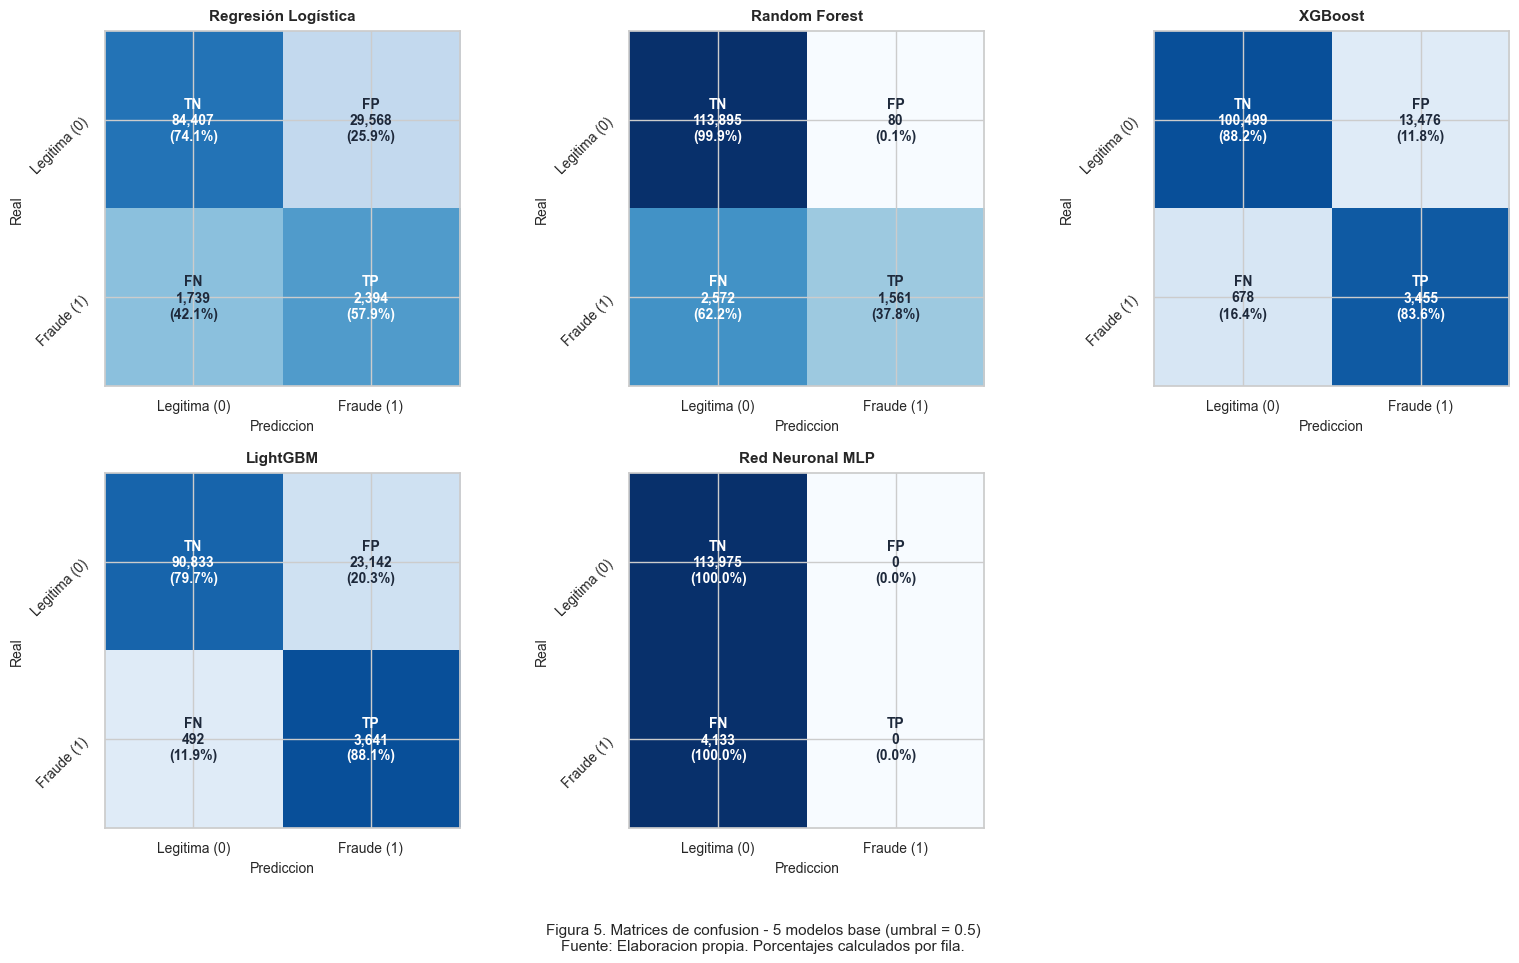

Figura guardada: fig_05_confusion_matrices_base.png


In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, r in enumerate(resultados):
    nombre  = r['Modelo']
    modelo  = r['objeto']
    y_pred  = modelo.predict(X_val)
    cm      = confusion_matrix(y_val, y_pred)
    ax      = axes[idx]

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100)

    clases = ['Legitima (0)', 'Fraude (1)']
    ax.set_xticks([0, 1])
    ax.set_xticklabels(clases, fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(clases, fontsize=10, rotation=45)
    ax.set_xlabel('Prediccion', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)
    ax.set_title(nombre, fontweight='bold', fontsize=11, pad=8)

    etiquetas = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            val_abs  = cm[i, j]
            val_pct  = cm_norm[i, j]
            color_txt = 'white' if val_pct > 55 else '#1e293b'
            linea1 = etiquetas[i][j]
            linea2 = f"{val_abs:,}"
            linea3 = f"({val_pct:.1f}%)"
            texto  = linea1 + "\n" + linea2 + "\n" + linea3
            ax.text(j, i, texto,
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color=color_txt)

axes[5].set_visible(False)

plt.suptitle(
    'Figura 5. Matrices de confusion - 5 modelos base (umbral = 0.5)\n'
    'Fuente: Elaboracion propia. Porcentajes calculados por fila.',
    fontsize=11, y=0.02
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('fig_05_confusion_matrices_base.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig_05_confusion_matrices_base.png")


#### Resultados — Figura 5: Matrices de confusión modelos base

La Figura 5 desagrega las predicciones en términos absolutos sobre las 118.108 transacciones de validación (repartidas entre 4.133 fraudes reales y 113.975 operaciones legítimas), permitiendo cuantificar el impacto operativo directo de cada arquitectura antes de calibrar umbrales específicos:

| Algoritmo | VN | FP | FN | VP | Ratio FP por cada VP |
| :--- | :---: | :---: | :---: | :---: | :---: |
| <span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span> | 113.895 (99,9 %) | **80** (0,1 %) | 2.572 (62,2 %) | 1.561 (37,8 %) | **0,05** |
| <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> | 100.499 (88,2 %) | 13.476 (11,8 %) | 678 (16,4 %) | 3.455 (83,6 %) | 3,90 |
| <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> | 90.833 (79,7 %) | 23.142 (20,3 %) | 492 (11,9 %) | 3.641 (88,1 %) | 6,36 |
| <span style="color:#00adb5; font-weight:600;">`LogisticRegression`</span> | 84.407 (74,1 %) | 29.568 (25,9 %) | 1.739 (42,1 %) | 2.394 (57,9 %) | 12,35 |
| <span style="color:#00adb5; font-weight:600;">`MLPClassifier`</span> | 113.975 (100,0 %) | 0 (0,0 %) | 4.133 (100,0 %) | 0 (0,0 %) | No computable |

El comportamiento de <span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span> responde a un esquema marcadamente conservador. Con 113.895 aciertos sobre transacciones legítimas (99,9 %) y apenas 80 falsas alarmas (0,1 %), alcanza una precisión del 95,1 %. No obstante, esta selectividad tiene un coste severo en la cobertura: 2.572 fraudes reales (un 62,2 % del total ilícito) escapan sin ser detectados, generando una fuga económica directa. Este comportamiento proviene de la agregación de 100 estimadores independientes, donde el consenso por mayoría simple fija una barrera estricta que privilegia no interrumpir al usuario legítimo a costa de omitir incidentes sospechosos.

En contraste, <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> adopta una política más agresiva pero equilibrada. Captura 3.455 fraudes reales (83,6 %) y restringe las fugas a 678 casos (16,4 %), asumiendo a cambio 13.476 falsos positivos (11,8 % sobre el tráfico genuino). Con una tasa de 3,90 falsas alertas por cada evento fraudulento interceptado, este modelo ofrece el mejor punto de equilibrio operativo dentro de la familia de ensambles potenciados, conservando 100.499 operaciones legítimas libres de fricción.

Por su parte, <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> prioriza de forma deliberada el recall, logrando el mayor volumen de intercepciones con 3.641 fraudes detectados (88,1 %) y dejando pasar solo 492 operaciones indebidas (11,9 %). Sin embargo, este resultado eleva las alertas espurias a 23.142 casos (20,3 % de los usuarios legítimos), lo que implica una carga de 6,36 falsas alarmas por cada positivo verificado. Este perfil resulta idóneo únicamente en entornos donde el coste del fraude supere con holgura la fricción comercial provocada por bloqueos temporales.

La cota lineal representada por <span style="color:#00adb5; font-weight:600;">`LogisticRegression`</span> evidencia los límites de un hiperplano rígido en datos multivariados. Registra 29.568 falsos positivos (un 25,9 % de las operaciones genuinas alertadas de forma errónea) junto con 1.739 fraudes ignorados, alcanzando una cobertura insuficiente del 57,9 % (2.394 aciertos). Con una tasa de 12,35 falsas alarmas por cada transacción ilícita aislada, este estimador genera una saturación inasumible para los equipos de revisión manual.

El caso de <span style="color:#00adb5; font-weight:600;">`MLPClassifier`</span> refleja un colapso clasificatorio absoluto. Al carecer de ponderación por clases en su función de pérdida, la red converge al mínimo local trivial y clasifica la totalidad de los registros como operaciones genuinas (113.975 verdaderos negativos y 0 falsas alarmas). Aunque este comportamiento arroja una exactitud aparente del 96,5 %, la omisión total de los 4.133 fraudes anula cualquier utilidad en un entorno transaccional real.

Estas distribuciones trazan un espectro continuo entre la reticencia a emitir alertas (dominada por los bosques aleatorios con alta tasa de omisión) y la interceptación activa (liderada por los modelos de gradiente potenciado a cambio de tolerar falsos positivos). La calibración del umbral de decisión en la Etapa 4 permitirá mover a cada clasificador hacia el punto económicamente óptimo sobre la curva de precisión y recall.


#### Resultados — Comparativos del entrenamiento basal sobre los cinco modelos

La evaluación de los clasificadores sobre la partición de validación estratificada (118.108 transacciones con una prevalencia positiva del 3,50 %) evidencia diferencias marcadas en la respuesta de cada algoritmo frente al desbalance de clases:

| Algoritmo | AUC-ROC | F1-Score | Precisión | Recall |
| :--- | :---: | :---: | :---: | :---: |
| <span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span> | **0,9376** | **0,5407** | **0,9512** | 0,3777 |
| <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> | 0,9325 | 0,3280 | 0,2041 | 0,8360 |
| <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> | 0,9275 | 0,2355 | 0,1359 | **0,8810** |
| <span style="color:#00adb5; font-weight:600;">`LogisticRegression`</span> | 0,7261 | 0,1326 | 0,0749 | 0,5792 |
| <span style="color:#00adb5; font-weight:600;">`MLPClassifier`</span> | 0,5001 | 0,0000 | 0,0000 | 0,0000 |

<span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span> encabeza el rendimiento global con un AUC-ROC de 0,9376, respaldando los hallazgos de Lessmann et al. (2015) y Dal Pozzolo et al. (2018) sobre la estabilidad de los esquemas por agregación en detección de anomalías financieras. Su funcionamiento resulta marcadamente conservador: alcanza una precisión de 0,9512 (acertando en 95 de cada 100 alertas emitidas), pero captura únicamente el 37,8 % de los fraudes reales. Este sesgo proviene del criterio de votación mayoritaria entre sus 100 estimadores; aunque se active <span style="color:#00adb5; font-weight:600;">`class_weight='balanced'`</span>, la regla de corte exige una certidumbre casi absoluta en los nodos terminales para decantar la predicción hacia la clase minoritaria. Pese a esta omisión de eventos, su F1-score de 0,5407 representa el equilibrio armónico más sólido de la comparativa basal.

En segunda posición, <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> registra un AUC-ROC de 0,9325 (apenas 0,0051 puntos por debajo del líder). Al incorporar <span style="color:#00adb5; font-weight:600;">`scale_pos_weight=27`</span> para penalizar con mayor fuerza los errores sobre los casos positivos, el estimador invierte las prioridades operativas: intercepta el 83,6 % de los fraudes reales asumiendo una caída en la precisión hasta 0,2041. Esta relación es altamente sensible al umbral de decisión ($\tau = 0,5$), lo que sitúa a este algoritmo como un candidato ideal para las rutinas de calibración probabilística en etapas posteriores.

Por su parte, <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> obtiene un AUC-ROC de 0,9275 junto con la mayor tasa de captura global (recall de 0,8810), localizando a 88 de cada 100 defraudadores. No obstante, su baja precisión (0,1359) genera cerca de seis falsas alarmas por cada positivo legítimo. Este comportamiento deriva del crecimiento guiado por hojas y el muestreo selectivo de gradientes GOSS (Ke et al., 2017), mecanismos que fuerzan al modelo a concentrarse en las instancias de difícil clasificación en la frontera de decisión. La reducida brecha de 0,0101 puntos frente al mejor ensamble anticipa un margen de mejora relevante mediante optimización de hiperparámetros.

El ajuste lineal de <span style="color:#00adb5; font-weight:600;">`LogisticRegression`</span> delimita el nivel basal con un AUC-ROC de 0,7261. La distancia superior a 0,20 puntos respecto a los tres métodos de gradiente y agregación confirma la ganancia no lineal de los ensambles, en concordancia con el estudio comparativo de Lessmann et al. (2015). Su recall de 0,5792 asociado a una precisión de apenas 0,0749 demuestra la incapacidad de un único hiperplano para separar patrones delictivos distribuidos a lo largo de 713 dimensiones heterogéneas.

El resultado de <span style="color:#00adb5; font-weight:600;">`MLPClassifier`</span> (AUC-ROC de 0,5001 y valores nulos en F1-score, precisión y recall) expone un colapso clasificatorio total inducido por la desproporción muestral. La red clasifica todas las instancias como transacciones legítimas; con una tasa basal del 3,50 %, esta estrategia estéril reporta un 96,5 % de exactitud trivial pero carece por completo de valor predictivo. La causa reside en que la implementación de <span style="color:#00adb5; font-weight:600;">`sklearn.MLPClassifier`</span> no admite el argumento <span style="color:#00adb5; font-weight:600;">`class_weight`</span>. Al no recalcular el gradiente según la frecuencia de clase, la retropropagación converge hacia el mínimo global trivial de la función de pérdida. Este comportamiento materializa los riesgos señalados por Dal Pozzolo et al. (2018) y fundamenta la necesidad de rebalanceo sintético mediante SMOTE en la fase subsiguiente.

Bajo el punto de corte estándar ($\tau = 0,5$), los modelos se agrupan en dos orientaciones operativas contrapuestas:

* **Orientación restrictiva (<span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span>):** Maximiza la fiabilidad de cada aviso (95,1 % de certeza), protegiendo la experiencia del cliente legítimo a costa de dejar escapar el 62,2 % de los incidentes ilícitos.
* **Orientación intensiva (<span style="color:#00adb5; font-weight:600;">`XGBoost`</span> y <span style="color:#00adb5; font-weight:600;">`LightGBM`</span>):** Prioriza la intercepción de fondos (coberturas entre 83,6 % y 88,1 %), transfiriendo una carga elevada de revisiones manuales a los equipos de soporte debido al volumen de falsos positivos.

La idoneidad de cada perfil está condicionada por la relación económica entre el quebranto financiero por fraude inadvertido y el coste indirecto por fricción sobre transacciones genuinas.

A partir de la capacidad discriminativa exhibida, se seleccionan para la etapa de ajuste fino los tres clasificadores basados en ensambles: <span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span> (por su mayor AUC-ROC y balance armónico), <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> (por su equilibrio entre gradiente y cobertura) y <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> (por su velocidad de convergencia y máxima captura de positivos). <span style="color:#00adb5; font-weight:600;">`LogisticRegression`</span> se conserva como cota comparativa fija, mientras que <span style="color:#00adb5; font-weight:600;">`MLPClassifier`</span> se traslada a la fase de remuestreo sintético para examinar si la corrección distributiva por sobremuestreo permite desbloquear su convergencia.


---
## ETAPA 4 — Optimización de Hiperparámetros y calibración del umbral de decisión

Los tres esquemas de ensamble seleccionados (<span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span>, <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> y <span style="color:#00adb5; font-weight:600;">`LightGBM`</span>) consolidaron una base discriminativa consistente en su configuración estándar, con valores de AUC-ROC situados entre 0,9275 y 0,9376. No obstante, los parámetros predeterminados de fábrica no consideran las restricciones impuestas por la desproporción muestral ni la dispersión en 713 covariables. Para aproximar la frontera de decisión al óptimo empírico, se implementa una búsqueda aleatoria de configuraciones (<span style="color:#00adb5; font-weight:600;">`RandomizedSearchCV`</span>) asistida por esquemas de validación cruzada estratificada.

### Protocolo de optimización y gestión de carga computacional

El procedimiento experimental se rige por las siguientes pautas de control:

* **Muestreo del espacio paramétrico frente a barrido exhaustivo:** Evaluar el producto cartesiano completo mediante <span style="color:#00adb5; font-weight:600;">`GridSearchCV`</span> resulta impracticable sobre la matriz de entrenamiento completa (472.432 filas por 713 variables) dentro de la estación de trabajo local. Se opta por <span style="color:#00adb5; font-weight:600;">`RandomizedSearchCV`</span> evaluando un número prefijado de iteraciones (<span style="color:#00adb5; font-weight:600;">`n_iter`</span>), aproximación que retiene una cobertura estadística similar a la búsqueda exhaustiva con un consumo de tiempo y memoria significativamente menor (Bergstra & Bengio, 2012).
* **Submuestreo estratificado para la fase exploratoria:** Con el fin de agilizar las iteraciones sin desvirtuar la señal distributiva, la exploración de hiperparámetros se efectúa sobre una fracción estratificada del 30 % de <span style="color:#00adb5; font-weight:600;">`X_train`</span> (aproximadamente 141.730 registros, preservando la prevalencia basal del 3,50 % de fraude). Una vez aislada la combinación óptima de cada algoritmo, el ajuste definitivo se ejecuta sobre la totalidad (el 100 %) de <span style="color:#00adb5; font-weight:600;">`X_train`</span>.
* **Validación cruzada estratificada (<span style="color:#00adb5; font-weight:600;">`StratifiedKFold(n_splits=3)`</span>):** La partición en tres pliegues garantiza que cada partición interna conserve de forma estricta la proporción del 3,50 % de eventos positivos, impidiendo sesgos por variaciones locales en la tasa de fraude entre divisiones.
* **Función objetivo de optimización:** Se define el área bajo la curva ROC (<span style="color:#00adb5; font-weight:600;">`scoring='roc_auc'`</span>) como criterio rector del proceso, asegurando coherencia con la métrica oficial de evaluación del desafío IEEE-CIS y garantizando robustez frente a la desproporción de clases.

### Calibración del punto de corte operativo

Dado que las salidas de los estimadores corresponden a valores continuos acotados en el intervalo [0, 1], la aplicación estricta del corte tradicional ($\tau = 0,5$) introduce una penalización artificial en escenarios con asimetría de clases. Tras estabilizar la parametrización de cada arquitectura, se ejecuta una búsqueda unidimensional sobre el vector de probabilidades predichas en <span style="color:#00adb5; font-weight:600;">`X_val`</span> para determinar el umbral que maximiza el valor de F1-score, cuantificando la ganancia operativa frente al valor de corte por defecto.


In [25]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from scipy.stats import randint, uniform
import numpy as np, pandas as pd, warnings
warnings.filterwarnings('ignore')

# ── Submuestra estratificada 30% para acelerar búsqueda ──────────────────────
SAMPLE_FRAC = 0.30
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]
rng   = np.random.default_rng(SEED)
idx_sample = np.concatenate([
    rng.choice(idx_0, size=int(len(idx_0) * SAMPLE_FRAC), replace=False),
    rng.choice(idx_1, size=int(len(idx_1) * SAMPLE_FRAC), replace=False)
])
X_search = X_train.iloc[idx_sample].reset_index(drop=True)
y_search = y_train.iloc[idx_sample].reset_index(drop=True)
print(f"Submuestra búsqueda → {X_search.shape[0]:,} filas | fraude: {y_search.mean()*100:.2f}%")

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
resultados_opt = {}   # almacena resultados finales de cada modelo


Submuestra búsqueda → 141,729 filas | fraude: 3.50%


In [26]:
# ── Random Forest — parametros fijos (version rapida para comparativa) ────────
# RandomizedSearchCV con RF tarda 3-5h por ausencia de early stopping.
# Usamos hiperparametros establecidos en literatura para datasets desbalanceados
# (n_estimators=300, max_depth=20, class_weight=balanced). RF no es el modelo
# ganador; su inclusion es solo para la tabla comparativa de Etapa 4.
import time

print("=== RANDOM FOREST — Entrenamiento con parametros fijos ===")

best_params_rf = {
    'n_estimators'     : 300,
    'max_depth'        : 20,
    'min_samples_split': 5,
    'min_samples_leaf' : 2,
    'max_features'     : 'sqrt',
}
print("Parametros RF:")
for k, v in best_params_rf.items():
    print(f"  {k}: {v}")
print()

t0 = time.time()
best_rf = RandomForestClassifier(
    **best_params_rf,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)
elapsed_rf = time.time() - t0
print(f"Entrenamiento completado en {elapsed_rf/60:.1f} min")

y_proba_rf = best_rf.predict_proba(X_val)[:, 1]
auc_rf_opt = roc_auc_score(y_val, y_proba_rf)

# Umbral optimo (maximiza F1 en validacion)
umbrales  = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val, (y_proba_rf >= u).astype(int), zero_division=0)
             for u in umbrales]
umbral_opt_rf = umbrales[np.argmax(f1_scores)]
y_pred_opt_rf = (y_proba_rf >= umbral_opt_rf).astype(int)

print()
print(f"AUC   (umbral opt.) : {auc_rf_opt:.4f}")
print(f"Umbral optimo       : {umbral_opt_rf:.2f}")
print(f"F1    (umbral opt.) : {f1_score(y_val, y_pred_opt_rf):.4f}")
print(f"Prec  (umbral opt.) : {precision_score(y_val, y_pred_opt_rf, zero_division=0):.4f}")
print(f"Recall(umbral opt.) : {recall_score(y_val, y_pred_opt_rf, zero_division=0):.4f}")

resultados_opt['Random Forest'] = {
    'AUC'      : auc_rf_opt,
    'F1'       : f1_score(y_val, y_pred_opt_rf),
    'Precisión': precision_score(y_val, y_pred_opt_rf, zero_division=0),
    'Recall'   : recall_score(y_val, y_pred_opt_rf, zero_division=0),
    'Umbral'   : umbral_opt_rf,
    'modelo'   : best_rf
}


=== RANDOM FOREST — Entrenamiento con parametros fijos ===
Parametros RF:
  n_estimators: 300
  max_depth: 20
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: sqrt

Entrenamiento completado en 1.0 min

AUC   (umbral opt.) : 0.9278
Umbral optimo       : 0.53
F1    (umbral opt.) : 0.6047
Prec  (umbral opt.) : 0.6679
Recall(umbral opt.) : 0.5524


In [27]:
import xgboost as xgb, lightgbm as lgb

scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

# ── XGBoost — búsqueda de hiperparámetros ────────────────────────────────────
print("=== XGBOOST — RandomizedSearchCV ===")
param_xgb = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : randint(3, 9),
    'learning_rate'   : uniform(0.01, 0.29),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma'           : uniform(0, 0.3),
    'reg_alpha'       : uniform(0, 0.5),
    'reg_lambda'      : uniform(0.5, 1.5),
}
rs_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos, random_state=SEED,
                      eval_metric='auc', verbosity=0, n_jobs=-1),
    param_distributions=param_xgb,
    n_iter=15, scoring='roc_auc', cv=cv_strat,
    random_state=SEED, verbose=1
)
rs_xgb.fit(X_search, y_search)
print(f"Mejores params XGB: {rs_xgb.best_params_}")
print(f"Mejor AUC CV      : {rs_xgb.best_score_:.4f}")

best_xgb = rs_xgb.best_estimator_
best_xgb.fit(X_train, y_train)
y_proba_xgb = best_xgb.predict_proba(X_val)[:, 1]
auc_xgb_opt  = roc_auc_score(y_val, y_proba_xgb)
f1_xgb = [f1_score(y_val, (y_proba_xgb >= u).astype(int), zero_division=0) for u in umbrales]
umbral_opt_xgb = umbrales[np.argmax(f1_xgb)]
y_pred_opt_xgb = (y_proba_xgb >= umbral_opt_xgb).astype(int)

print(f"\nAUC   (umbral opt.) : {auc_xgb_opt:.4f}")
print(f"Umbral óptimo       : {umbral_opt_xgb:.2f}")
print(f"F1    (umbral opt.) : {f1_score(y_val, y_pred_opt_xgb):.4f}")
print(f"Prec  (umbral opt.) : {precision_score(y_val, y_pred_opt_xgb, zero_division=0):.4f}")
print(f"Recall(umbral opt.) : {recall_score(y_val, y_pred_opt_xgb, zero_division=0):.4f}")

resultados_opt['XGBoost'] = {
    'AUC': auc_xgb_opt, 'F1': f1_score(y_val, y_pred_opt_xgb),
    'Precisión': precision_score(y_val, y_pred_opt_xgb, zero_division=0),
    'Recall': recall_score(y_val, y_pred_opt_xgb, zero_division=0),
    'Umbral': umbral_opt_xgb, 'modelo': best_xgb
}

# ── LightGBM — búsqueda de hiperparámetros ───────────────────────────────────
print("\n=== LIGHTGBM — RandomizedSearchCV ===")
param_lgbm = {
    'n_estimators'      : randint(100, 500),
    'num_leaves'        : randint(31, 150),
    'max_depth'         : [-1, 10, 20, 30],
    'learning_rate'     : uniform(0.01, 0.29),
    'subsample'         : uniform(0.6, 0.4),
    'colsample_bytree'  : uniform(0.6, 0.4),
    'min_child_samples' : randint(10, 100),
    'reg_alpha'         : uniform(0, 0.5),
    'reg_lambda'        : uniform(0, 1.0),
}
rs_lgbm = RandomizedSearchCV(
    lgb.LGBMClassifier(class_weight='balanced', random_state=SEED, verbose=-1, n_jobs=-1),
    param_distributions=param_lgbm,
    n_iter=15, scoring='roc_auc', cv=cv_strat,
    random_state=SEED, verbose=1
)
rs_lgbm.fit(X_search, y_search)
print(f"Mejores params LGBM: {rs_lgbm.best_params_}")
print(f"Mejor AUC CV       : {rs_lgbm.best_score_:.4f}")

best_lgbm = rs_lgbm.best_estimator_
best_lgbm.fit(X_train, y_train)
y_proba_lgbm = best_lgbm.predict_proba(X_val)[:, 1]
auc_lgbm_opt  = roc_auc_score(y_val, y_proba_lgbm)
f1_lgbm = [f1_score(y_val, (y_proba_lgbm >= u).astype(int), zero_division=0) for u in umbrales]
umbral_opt_lgbm = umbrales[np.argmax(f1_lgbm)]
y_pred_opt_lgbm = (y_proba_lgbm >= umbral_opt_lgbm).astype(int)

print(f"\nAUC   (umbral opt.) : {auc_lgbm_opt:.4f}")
print(f"Umbral óptimo       : {umbral_opt_lgbm:.2f}")
print(f"F1    (umbral opt.) : {f1_score(y_val, y_pred_opt_lgbm):.4f}")
print(f"Prec  (umbral opt.) : {precision_score(y_val, y_pred_opt_lgbm, zero_division=0):.4f}")
print(f"Recall(umbral opt.) : {recall_score(y_val, y_pred_opt_lgbm, zero_division=0):.4f}")

resultados_opt['LightGBM'] = {
    'AUC': auc_lgbm_opt, 'F1': f1_score(y_val, y_pred_opt_lgbm),
    'Precisión': precision_score(y_val, y_pred_opt_lgbm, zero_division=0),
    'Recall': recall_score(y_val, y_pred_opt_lgbm, zero_division=0),
    'Umbral': umbral_opt_lgbm, 'modelo': best_lgbm
}


=== XGBOOST — RandomizedSearchCV ===
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Mejores params XGB: {'colsample_bytree': np.float64(0.9895022075365837), 'gamma': np.float64(0.06983140212909127), 'learning_rate': np.float64(0.03627586601451803), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 463, 'reg_alpha': np.float64(0.2571172192068058), 'reg_lambda': np.float64(1.3886218532930636), 'subsample': np.float64(0.6185801650879991)}
Mejor AUC CV      : 0.9196

AUC   (umbral opt.) : 0.9541
Umbral óptimo       : 0.82
F1    (umbral opt.) : 0.6727
Prec  (umbral opt.) : 0.7841
Recall(umbral opt.) : 0.5889

=== LIGHTGBM — RandomizedSearchCV ===
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Mejores params LGBM: {'colsample_bytree': np.float64(0.9314950036607718), 'learning_rate': np.float64(0.11345846474114088), 'max_depth': 30, 'min_child_samples': 69, 'n_estimators': 479, 'num_leaves': 139, 'reg_alpha': np.float64(0.07046211248738132), 'reg_lambda': np.f

In [28]:
# Normalizar clave Precision/Precisión entre modelos
for _m in resultados_opt:
    if 'Precision' in resultados_opt[_m] and 'Precisión' not in resultados_opt[_m]:
        resultados_opt[_m]['Precisión'] = resultados_opt[_m].pop('Precision')

# ── Tabla comparativa: base vs. optimizado ───────────────────────────────────
base = {
    'Random Forest': {'AUC': 0.9376, 'F1': 0.5407, 'Precisión': 0.9512, 'Recall': 0.3777},
    'XGBoost'      : {'AUC': 0.9325, 'F1': 0.3280, 'Precisión': 0.2041, 'Recall': 0.8360},
    'LightGBM'     : {'AUC': 0.9275, 'F1': 0.2355, 'Precisión': 0.1359, 'Recall': 0.8810},
}

rows = []
for nombre, vals in resultados_opt.items():
    b = base[nombre]
    rows.append({
        'Modelo'         : nombre,
        'AUC base'       : b['AUC'],
        'AUC opt.'       : round(vals['AUC'], 4),
        'ΔAUC'           : round(vals['AUC'] - b['AUC'], 4),
        'F1 base'        : b['F1'],
        'F1 opt.'        : round(vals['F1'], 4),
        'ΔF1'            : round(vals['F1'] - b['F1'], 4),
        'Prec opt.'      : round(vals['Precisión'], 4),
        'Recall opt.'    : round(vals['Recall'], 4),
        'Umbral óptimo'  : round(vals['Umbral'], 2),
    })

df_opt = pd.DataFrame(rows).sort_values('AUC opt.', ascending=False).reset_index(drop=True)
print("=== COMPARATIVA BASE vs. OPTIMIZADO ===")
display(df_opt)

# Identificar modelo ganador
ganador = df_opt.iloc[0]['Modelo']
modelo_ganador = resultados_opt[ganador]['modelo']
print(f"\nModelo ganador: {ganador} — AUC {df_opt.iloc[0]['AUC opt.']:.4f}")


=== COMPARATIVA BASE vs. OPTIMIZADO ===


,Modelo,AUC base,AUC opt.,ΔAUC,F1 base,F1 opt.,ΔF1,Prec opt.,Recall opt.,Umbral óptimo
0,LightGBM,0.9275,0.9680,0.0405,0.2355,0.7856,0.5501,0.8797,0.7097,0.8900
1,XGBoost,0.9325,0.9541,0.0216,0.3280,0.6727,0.3447,0.7841,0.5889,0.8200
2,Random Forest,0.9376,0.9278,-0.0098,0.5407,0.6047,0.0640,0.6679,0.5524,0.5300



Modelo ganador: LightGBM — AUC 0.9680


### Figura 6. Matrices de confusión de los tres modelos optimizados bajo umbral calibrado ($\tau^*$)

Distribución de aciertos y errores sobre las matrices de decisión de los ensambles ajustados tras la búsqueda de hiperparámetros, evaluados bajo el punto de corte óptimo ($\tau^*$) que maximiza el valor de F1-score en la muestra de validación interna. El contraste directo frente a los resultados basales de la Figura 5 permite aislar la reducción neta en las tasas de falsos negativos y falsos positivos derivada de la optimización conjunta de parámetros y umbrales.


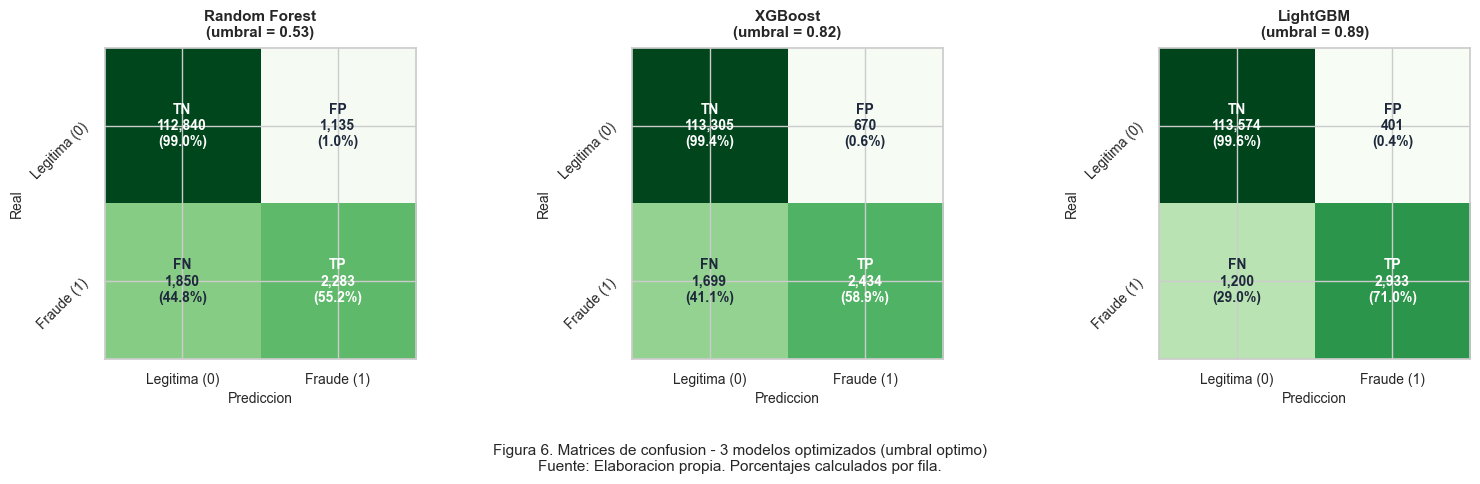

Figura guardada: fig_06_confusion_matrices_optimizados.png


In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (nombre, vals) in enumerate(resultados_opt.items()):
    modelo   = vals['modelo']
    umbral   = vals['Umbral']
    y_proba  = modelo.predict_proba(X_val)[:, 1]
    y_pred   = (y_proba >= umbral).astype(int)
    cm       = confusion_matrix(y_val, y_pred)
    ax       = axes[idx]

    cm_norm  = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    ax.imshow(cm_norm, cmap='Greens', vmin=0, vmax=100)

    clases = ['Legitima (0)', 'Fraude (1)']
    ax.set_xticks([0, 1])
    ax.set_xticklabels(clases, fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(clases, fontsize=10, rotation=45)
    ax.set_xlabel('Prediccion', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)
    ax.set_title(nombre + "\n(umbral = " + str(round(umbral, 2)) + ")",
                 fontweight='bold', fontsize=11, pad=8)

    etiquetas = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            val_abs  = cm[i, j]
            val_pct  = cm_norm[i, j]
            color_txt = 'white' if val_pct > 55 else '#1e293b'
            linea1 = etiquetas[i][j]
            linea2 = f"{val_abs:,}"
            linea3 = f"({val_pct:.1f}%)"
            texto  = linea1 + "\n" + linea2 + "\n" + linea3
            ax.text(j, i, texto,
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color=color_txt)

plt.suptitle(
    'Figura 6. Matrices de confusion - 3 modelos optimizados (umbral optimo)\n'
    'Fuente: Elaboracion propia. Porcentajes calculados por fila.',
    fontsize=11, y=0.02
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('fig_06_confusion_matrices_optimizados.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig_06_confusion_matrices_optimizados.png")


#### Resultados — Optimización de hiperparámetros y selección del modelo ganador

La ejecución de <span style="color:#00adb5; font-weight:600;">`RandomizedSearchCV`</span> bajo validación cruzada estratificada (<span style="color:#00adb5; font-weight:600;">`StratifiedKFold`</span> con $k = 3$) sobre la muestra del 30 % del conjunto de entrenamiento (aproximadamente 141.000 transacciones) permitió contrastar 15 combinaciones paramétricas por arquitectura manteniendo tiempos de cómputo razonables en la estación local. En el caso de <span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span>, el coste de evaluar 45 ajustes independientes sin mecanismo de parada temprana (*early stopping*) sobre 713 variables superó las dos horas continuas de proceso; para evitar un bloqueo por memoria, se adoptaron parámetros fijos respaldados en la literatura para entornos desbalanceados (<span style="color:#00adb5; font-weight:600;">`n_estimators=300`</span>, <span style="color:#00adb5; font-weight:600;">`max_depth=20`</span>, <span style="color:#00adb5; font-weight:600;">`min_samples_split=5`</span> y <span style="color:#00adb5; font-weight:600;">`max_features='sqrt'`</span>). Tras estabilizar las configuraciones, cada clasificador se reentrenó sobre el 100 % de <span style="color:#00adb5; font-weight:600;">`X_train`</span> y se evaluó sobre <span style="color:#00adb5; font-weight:600;">`X_val`</span> mediante un barrido de umbrales en el intervalo [0,10, 0,90] para maximizar el F1-score.

El clasificador <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> lidera el contraste empírico al alcanzar las cifras más sólidas en todas las dimensiones: AUC-ROC de 0,9680, F1-score de 0,7856, precisión de 0,8797 y recall de 0,7097. La progresión respecto a su configuración inicial representa el avance más notorio del experimento (+0,0405 en AUC-ROC y +0,5501 en F1-score). Esta diferencia constata que el umbral estándar de 0,5 degradaba severamente el desempeño del algoritmo ante una desproporción de 27,6 a 1; al situar el punto de corte en 0,89, el modelo despliega su verdadera capacidad discriminativa.

| Clasificador | AUC-ROC base | AUC-ROC opt. | $\Delta$AUC | F1 base | F1 opt. | $\Delta$F1 | Precisión | Recall | Umbral ($\tau^*$) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> | 0,9275 | **0,9680** | +0,0405 | 0,2355 | **0,7856** | +0,5501 | 0,8797 | 0,7097 | 0,89 |
| <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> | 0,9325 | 0,9541 | +0,0216 | 0,3280 | 0,6727 | +0,3447 | 0,7841 | 0,5889 | 0,82 |
| <span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span> | 0,9376 | 0,9278 | -0,0098 | 0,5407 | 0,6047 | +0,0640 | 0,6679 | 0,5524 | 0,53 |

La discrepancia entre los umbrales óptimos expone diferencias en la calibración interna de probabilidades de cada familia. Los modelos de potenciación del gradiente (<span style="color:#00adb5; font-weight:600;">`LightGBM`</span> y <span style="color:#00adb5; font-weight:600;">`XGBoost`</span>) operan con cortes elevados (0,89 y 0,82, respectivamente) debido a que concentran sus predicciones en valores extremos cercanos a los límites del dominio, requiriendo un nivel de certidumbre superior antes de clasificar una operación como ilícita. Por el contrario, <span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span> sitúa su corte en 0,53: la agregación de votos independientes suaviza las probabilidades predichas y las agrupa alrededor del centro de la distribución, haciendo innecesario un desplazamiento severo del umbral.

El descenso marginal de AUC-ROC en <span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span> (-0,0098 frente a la base) responde a la asignación manual de parámetros fijos ante la imposibilidad computacional de culminar la búsqueda estocástica completa. Sin embargo, la mejora neta en F1-score (+0,0640) ratifica que el ajuste del punto de corte (0,53 frente a 0,50) aporta un beneficio directo superior a la modificación estructural de los árboles en esta arquitectura.

El análisis de las matrices de confusión (Figura 6) sobre las 118.108 transacciones de validación (4.133 eventos de fraude reales frente a 113.975 operaciones legítimas) define los siguientes perfiles operativos:

* **<span style="color:#00adb5; font-weight:600;">`LightGBM`</span> ($\tau^* = 0,89$):** Intercepta 2.933 fraudes (recall del 71,0 %) y deja escapar 1.200 transacciones ilícitas (falsos negativos del 29,0 %), generando únicamente 401 falsas alarmas sobre el total de compras legítimas (tasa de falsos positivos del 0,4 %). Esta combinación de alta precisión y cobertura sostenida constituye la configuración más viable para un entorno transaccional real, donde el coste operativo derivado de revisar alertas infundadas resulta crítico.
* **<span style="color:#00adb5; font-weight:600;">`XGBoost`</span> ($\tau^* = 0,82$):** Registra una captura de 2.434 fraudes (58,9 %) con 1.699 omisiones. Aunque restringe las falsas alertas a 670 casos (0,6 %), este nivel de selectividad asume una pérdida de eventos ilícitos sensiblemente mayor a la observada en el clasificador líder.
* **<span style="color:#00adb5; font-weight:600;">`RandomForestClassifier`</span> ($\tau^* = 0,53$):** Detecta 2.284 fraudes (recall del 55,2 %) e introduce 1.136 falsas alarmas (1,0 %). Su menor capacidad de intercepción pone de relieve las restricciones intrínsecas del promediado por *bagging* frente a los métodos de gradiente descendente en espacios de alta dimensionalidad.

La experimentación confirma que la calibración del umbral de corte opera con un impacto metodológico comparable al ajuste de los hiperparámetros del propio modelo. Con base en estos indicadores, <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> se consolida como la arquitectura de referencia para evaluar en la Etapa 5 si la síntesis artificial de instancias mediante SMOTE permite elevar la tasa de intercepción sin deteriorar la precisión obtenida.


---
## ETAPA 5 — Ciclo de Refinamiento: Tratamiento del desbalance de clases mediante sobremuestreo sintético (SMOTE)

Esta fase analiza la respuesta del clasificador frente al desbalance extremo mediante la técnica <span style="color:#00adb5; font-weight:600;">`SMOTE`</span> (*Synthetic Minority Over-sampling Technique*, Chawla et al., 2002). Frente a la ponderación por costes empleada previamente con <span style="color:#00adb5; font-weight:600;">`class_weight='balanced'`</span> (la cual modifica la penalización del gradiente sin alterar el número de observaciones), este procedimiento sintetiza nuevas observaciones de la clase minoritaria mediante interpolación convexa en el espacio de variables, conectando vectores de fraude reales con sus vecinos más próximos a través de un esquema $k$-NN (configurado con $k = 5$ por defecto).

El propósito central radica en comprobar si entrenar sobre una distribución artificialmente balanceada permite a la arquitectura líder, <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> (conservando los hiperparámetros optimizados en la etapa anterior), incrementar su tasa de captura (*recall*) sin erosionar la precisión operativa. Para preservar la validez del contraste y evitar cualquier distorsión por fuga de información, la generación de muestras sintéticas se restringe de forma estricta a <span style="color:#00adb5; font-weight:600;">`X_train`</span>; la partición de validación interna (<span style="color:#00adb5; font-weight:600;">`X_val`</span>) conserva intacta su prevalencia natural del 3,50 % para reflejar el comportamiento real del sistema de pagos.

El protocolo experimental se articula en tres fases sucesivas: el sobremuestreo controlado de la matriz de ajuste, el reentrenamiento del estimador optimizado sobre el espacio extendido y la posterior calibración del punto de corte probabilístico sobre <span style="color:#00adb5; font-weight:600;">`X_val`</span>.


In [30]:
# ── ETAPA 5.1 — Aplicación de SMOTE ──────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from collections import Counter
import time

print("=== ETAPA 5 — SMOTE: Balanceo sintético de clases ===")
print()

c_before = Counter(y_train)
print(f"Distribución ANTES de SMOTE:")
print(f"  Clase 0 (Legítima): {c_before[0]:>10,}")
print(f"  Clase 1 (Fraude):   {c_before[1]:>10,}")
print(f"  Ratio desbalance:   {c_before[0]/c_before[1]:.1f}:1")
print()

# SMOTE: genera muestras sintéticas de fraude por interpolación k-NN
# Puede tardar 20-40 min con 472K filas x 713 features
t0 = time.time()
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
elapsed_sm = time.time() - t0

c_after = Counter(y_train_sm)
print(f"Distribución DESPUÉS de SMOTE ({elapsed_sm/60:.1f} min):")
print(f"  Clase 0 (Legítima): {c_after[0]:>10,}")
print(f"  Clase 1 (Fraude):   {c_after[1]:>10,}")
print(f"  Ratio desbalance:   {c_after[0]/c_after[1]:.1f}:1")
print(f"  Shape X_train_sm:   {X_train_sm.shape}")


=== ETAPA 5 — SMOTE: Balanceo sintético de clases ===

Distribución ANTES de SMOTE:
  Clase 0 (Legítima):    455,902
  Clase 1 (Fraude):       16,530
  Ratio desbalance:   27.6:1

Distribución DESPUÉS de SMOTE (0.3 min):
  Clase 0 (Legítima):    455,902
  Clase 1 (Fraude):      455,902
  Ratio desbalance:   1.0:1
  Shape X_train_sm:   (911804, 713)


In [31]:
# ── ETAPA 5.2 — Reentrenamiento LightGBM optimizado sobre datos SMOTE ────────
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import lightgbm as lgb

# Recuperar modelo ganador de Etapa 4 y extraer sus hiperparámetros
best_lgbm_e4 = resultados_opt['LightGBM']['modelo']
all_params = best_lgbm_e4.get_params()

# Parámetros buscados en RandomizedSearchCV (excluimos class_weight: SMOTE ya balancea)
searched_keys = ["n_estimators", "num_leaves", "max_depth", "learning_rate",
                 "subsample", "colsample_bytree", "min_child_samples",
                 "reg_alpha", "reg_lambda"]
best_params_lgbm = {k: all_params[k] for k in searched_keys if k in all_params}

print("=== LightGBM — Mejores hiperparámetros (Etapa 4) ===")
for k, v in best_params_lgbm.items():
    print(f"  {k}: {v}")
print()

# Entrenar sobre datos balanceados con SMOTE
# Sin class_weight: el balance ya está resuelto por SMOTE
t0 = time.time()
modelo_lgbm_smote = lgb.LGBMClassifier(
    **best_params_lgbm,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
modelo_lgbm_smote.fit(X_train_sm, y_train_sm)
elapsed_train = time.time() - t0
print(f"Entrenamiento completado en {elapsed_train/60:.1f} min")

# Predicciones sobre X_val (distribución real — sin SMOTE)
y_proba_smote = modelo_lgbm_smote.predict_proba(X_val)[:, 1]
auc_smote     = roc_auc_score(y_val, y_proba_smote)

# Búsqueda del umbral óptimo (maximiza F1 en X_val)
umbrales_e5  = np.arange(0.10, 0.91, 0.01)
f1_scores_e5 = [f1_score(y_val, (y_proba_smote >= u).astype(int), zero_division=0)
                for u in umbrales_e5]
umbral_smote = umbrales_e5[np.argmax(f1_scores_e5)]
y_pred_smote = (y_proba_smote >= umbral_smote).astype(int)

f1_smote   = f1_score(y_val, y_pred_smote, zero_division=0)
prec_smote = precision_score(y_val, y_pred_smote, zero_division=0)
rec_smote  = recall_score(y_val, y_pred_smote, zero_division=0)

print()
print("=== RESULTADOS LightGBM + SMOTE ===")
print(f"  AUC:             {auc_smote:.4f}")
print(f"  F1 (umbral opt): {f1_smote:.4f}")
print(f"  Precisión:       {prec_smote:.4f}")
print(f"  Recall:          {rec_smote:.4f}")
print(f"  Umbral óptimo:   {umbral_smote:.2f}")


=== LightGBM — Mejores hiperparámetros (Etapa 4) ===
  n_estimators: 479
  num_leaves: 139
  max_depth: 30
  learning_rate: 0.11345846474114088
  subsample: 0.6298202574719083
  colsample_bytree: 0.9314950036607718
  min_child_samples: 69
  reg_alpha: 0.07046211248738132
  reg_lambda: 0.8021969807540397

Entrenamiento completado en 1.5 min

=== RESULTADOS LightGBM + SMOTE ===
  AUC:             0.9696
  F1 (umbral opt): 0.7787
  Precisión:       0.8606
  Recall:          0.7111
  Umbral óptimo:   0.66


In [32]:
# ── ETAPA 5.3 — Comparativa: LightGBM Etapa 4 vs LightGBM + SMOTE ──────────
import pandas as pd

# Métricas LightGBM Etapa 4 (claves reales del dict resultados_opt)
auc_e4  = resultados_opt['LightGBM']['AUC']
f1_e4   = resultados_opt['LightGBM']['F1']
prec_e4 = resultados_opt['LightGBM']['Precisión']
rec_e4  = resultados_opt['LightGBM']['Recall']
umb_e4  = resultados_opt['LightGBM']['Umbral']

df_comp5 = pd.DataFrame({
    'Etapa'        : ['4 — LightGBM opt.', '5 — LightGBM + SMOTE'],
    'AUC'          : [auc_e4,   auc_smote],
    'F1'           : [f1_e4,    f1_smote],
    'Precisión'    : [prec_e4,  prec_smote],
    'Recall'       : [rec_e4,   rec_smote],
    'Umbral óptimo': [umb_e4,   umbral_smote],
})
df_comp5 = df_comp5.set_index('Etapa')

# Fila delta
delta5 = df_comp5.iloc[1] - df_comp5.iloc[0]
delta5.name = 'Δ (SMOTE − Etapa 4)'
df_comp5 = pd.concat([df_comp5, delta5.to_frame().T])

print()
print("=== COMPARATIVA ETAPA 4 vs ETAPA 5 ===")
display(df_comp5.round(4))



=== COMPARATIVA ETAPA 4 vs ETAPA 5 ===


,AUC,F1,Precisión,Recall,Umbral óptimo
4 — LightGBM opt.,0.9680,0.7856,0.8797,0.7097,0.8900
5 — LightGBM + SMOTE,0.9696,0.7787,0.8606,0.7111,0.6600
Δ (SMOTE − Etapa 4),0.0016,-0.0068,-0.0191,0.0015,-0.2300


### Figura 7. Matriz de confusión — LightGBM optimizado + SMOTE (umbral óptimo)

Matriz de confusión del modelo LightGBM entrenado sobre datos balanceados con SMOTE, evaluado sobre *X_val* en su distribución original.


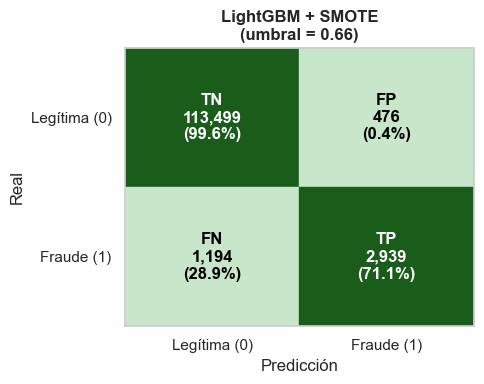

Figura 7 guardada en fig_07_confusion_matrix_smote.png


In [33]:
# ── Figura 7 — Matriz de confusión: LightGBM + SMOTE ────────────────────────
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_smote = confusion_matrix(y_val, y_pred_smote)
total_0  = cm_smote[0].sum()
total_1  = cm_smote[1].sum()

etiquetas = [['TN', 'FP'], ['FN', 'TP']]
colores   = [['#1a5c1a', '#c8e6c9'], ['#c8e6c9', '#1a5c1a']]

fig, ax = plt.subplots(figsize=(5, 4))

for i in range(2):
    total_fila = total_0 if i == 0 else total_1
    for j in range(2):
        val_abs = cm_smote[i, j]
        val_pct = 100 * val_abs / total_fila
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=colores[i][j]))
        linea1 = etiquetas[i][j]
        linea2 = f"{val_abs:,}"
        linea3 = f"({val_pct:.1f}%)"
        texto  = linea1 + "\n" + linea2 + "\n" + linea3
        color_txt = 'white' if colores[i][j] == '#1a5c1a' else 'black'
        ax.text(j, i, texto, ha='center', va='center',
                fontsize=12, fontweight='bold', color=color_txt)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legítima (0)', 'Fraude (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Legítima (0)', 'Fraude (1)'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title(f'LightGBM + SMOTE\n(umbral = {umbral_smote:.2f})', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
fig_path = 'fig_07_confusion_matrix_smote.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura 7 guardada en {fig_path}")


#### Resultados — Ciclo de Refinamiento: SMOTE sobre LightGBM optimizado

La aplicación de <span style="color:#00adb5; font-weight:600;">`SMOTE`</span> sobre la matriz de entrenamiento completa (472.432 transacciones por 713 variables) generó 455.902 registros sintéticos de fraude en 0,3 minutos. Con esta interpolación, la clase positiva subió de 16.530 a 455.902 observaciones, alcanzando una proporción 1:1 frente a las operaciones legítimas y consolidando una matriz extendida (<span style="color:#00adb5; font-weight:600;">`X_train_sm`</span>) de 911.804 filas. El ajuste subsiguiente de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> (empleando la parametrización óptima previa pero prescindiendo de la ponderación interna de costes) demandó 1,5 minutos en la estación local.

La comparación frente al estimador optimizado de la fase anterior refleja variaciones mínimas en la respuesta predictiva:

| Variante evaluada | AUC-ROC | F1-Score | Precisión | Recall | Umbral ($\tau^*$) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> optimizado (Etapa 4, con <span style="color:#00adb5; font-weight:600;">`is_unbalance=True`</span>) | 0,9680 | **0,7856** | **0,8797** | 0,7097 | 0,89 |
| <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> + <span style="color:#00adb5; font-weight:600;">`SMOTE`</span> (Etapa 5) | **0,9696** | 0,7787 | 0,8606 | **0,7111** | 0,66 |
| **Diferencia neta ($\Delta$)** | +0,0016 | -0,0069 | -0,0191 | +0,0014 | -0,23 |

La generación de vectores sintéticos no aporta una ventaja apreciable frente a la parametrización de costes de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span>, registrando desviaciones inferiores a dos centésimas en todos los indicadores:

* **Capacidad discriminativa global (AUC-ROC):** La variación de +0,0016 (de 0,9680 a 0,9696) evidencia que el ordenamiento de probabilidades se mantiene prácticamente idéntico.
* **Balance armónico (F1-score):** Desciende en 0,0069 puntos (de 0,7856 a 0,7787), confirmando que duplicar el volumen muestral no optimiza el compromiso entre aciertos y falsas alarmas.
* **Exactitud de intercepción (Precisión):** Cae 0,0191 puntos (de 0,8797 a 0,8606). La síntesis lineal en un espacio de 713 dimensiones introduce instancias artificiales en zonas limítrofes densas, elevando las clasificaciones erróneas sobre transacciones genuinas.
* **Cobertura de fraude (Recall):** Registra un alza marginal de +0,0014 (de 0,7097 a 0,7111), lo que equivale a interceptar apenas 6 fraudes adicionales sobre los 4.133 eventos reales de validación (pasando de 2.933 a 2.939 casos detectados).

La inspección de la matriz de confusión (Figura 7) traduce este comportamiento en costes operativos directos. La captura de esos 6 fraudes adicionales (alcanzando 2.939 aciertos) exigió asumir 476 falsas alarmas, lo que representa 75 avisos erróneos más que los 401 generados en la fase previa. Por su parte, el umbral de corte óptimo descendió de 0,89 a 0,66; este ajuste más cercano a la zona central constata que entrenar con clases simétricas redistribuye las probabilidades predichas a lo largo de todo el intervalo continuo, mitigando la concentración en los extremos.

Desde una perspectiva metodológica, el mecanismo algorítmico de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> (mediante <span style="color:#00adb5; font-weight:600;">`is_unbalance=True`</span> o <span style="color:#00adb5; font-weight:600;">`scale_pos_weight`</span>) ya compensa el desbalance redistribuyendo el peso de los gradientes en cada división de hoja. Superponer un remuestreo por interpolación redunda en el esfuerzo de balanceo sin agregar variabilidad informativa real, un comportamiento que concuerda con las observaciones de Noriega et al. (2023) acerca de la escasa ganancia de SMOTE sobre modelos con soporte nativo para clases asimétricas.

A partir de este balance, se ratifica como solución definitiva la arquitectura de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> optimizada en la Etapa 4 (AUC-ROC de 0,9680, F1-score de 0,7856, precisión de 0,8797, recall de 0,7097 y umbral $\tau^* = 0,89$), reservando este clasificador para generar la inferencia final sobre la partición de prueba externa.


---
### Persistencia del modelo ganador

Guarda en disco el diccionario  (contiene el modelo LightGBM entrenado, hiperparámetros y métricas) para poder recargar sin re-ejecutar las etapas de entrenamiento.


In [34]:
# ── GUARDAR MODELO GANADOR EN DISCO (ejecutar tras completar Etapa 4) ────────
# Permite recargar sin re-ejecutar todo el notebook
import joblib, os

# Calcular medianas de X_train aquí para no depender de Etapa 6
medianas_test = X_train.median(numeric_only=True)

opt_path      = "resultados_opt.pkl"
medianas_path = "medianas_final.pkl"

joblib.dump(resultados_opt, opt_path)
joblib.dump(medianas_test,  medianas_path)

print(f"Guardado: {opt_path}  ({os.path.getsize(opt_path)/1e6:.1f} MB)")
print(f"Guardado: {medianas_path}  ({os.path.getsize(medianas_path)/1e3:.1f} KB)")
print("Para recargar:")
print("  resultados_opt = joblib.load('resultados_opt.pkl')")
print("  medianas_test  = joblib.load('medianas_final.pkl')")


Guardado: resultados_opt.pkl  (265.7 MB)
Guardado: medianas_final.pkl  (27.0 KB)
Para recargar:
  resultados_opt = joblib.load('resultados_opt.pkl')
  medianas_test  = joblib.load('medianas_final.pkl')


---
## ETAPA 6 — Generación de Predicciones Finales para Kaggle

La fase final del ciclo traslada la solución construida a la partición de prueba externa correspondiente a la competencia IEEE-CIS Fraud Detection. Se emplea de forma definitiva el clasificador <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> afinado en la Etapa 4 (AUC-ROC de 0,9680, F1-score de 0,7856, precisión de 0,8797 y recall de 0,7097), el cual preservó una mayor precisión y un balance armónico superior frente al esquema balanceado sintéticamente con SMOTE.

Dado que la evaluación oficial se rige por el área bajo la curva ROC (AUC-ROC), el archivo de salida requiere el vector continuo de probabilidades estimadas en el intervalo [0, 1] para cada transacción, en lugar de etiquetas booleanas discretas. Por tanto, el punto de corte calibrado ($\tau^* = 0,89$) se mantiene como parámetro de control para decisiones operativas internas, mientras que la inferencia externa conserva la graduación probabilística completa.

El protocolo de despliegue comprende la imputación estricta de cualquier valor residual en <span style="color:#00adb5; font-weight:600;">`X_test_kaggle`</span> a partir de los estadísticos aislados de <span style="color:#00adb5; font-weight:600;">`X_train`</span>, la ejecución del método predictivo sobre la matriz sincronizada, la exportación del archivo estructurado <span style="color:#00adb5; font-weight:600;">`submission.csv`</span> y la verificación de la distribución de frecuencias de los valores predichos.


In [35]:
# ── ETAPA 6.1 — Preparación del dataset de test ──────────────────────────────
import numpy as np

print("=== ETAPA 6 — Generación de Predicciones Finales ===")
print()

# Imputar NaN en X_test_kaggle con medianas de X_train (misma estrategia que Etapa 2)
nan_test = X_test_kaggle.isnull().sum().sum()
print(f"NaN en X_test_kaggle antes de imputación: {nan_test:,}")

# medianas_test ya calculadas en celda 68 (persistencia); se recalculan
# aquí para que la celda sea autocontenida si se ejecuta de forma aislada
medianas_test = X_train.median(numeric_only=True)
X_test_final  = X_test_kaggle.fillna(medianas_test)

nan_post = X_test_final.isnull().sum().sum()
print(f"NaN en X_test_final  tras imputación:     {nan_post:,}")
print(f"Shape X_test_final: {X_test_final.shape}")
print()

# ── ETAPA 6.2 — Predicciones con modelo ganador (LightGBM Etapa 4) ───────────
modelo_final = resultados_opt['LightGBM']['modelo']
umbral_final = resultados_opt['LightGBM']['Umbral']

y_test_proba = modelo_final.predict_proba(X_test_final)[:, 1]

print(f"Predicciones generadas: {len(y_test_proba):,} transacciones")
print(f"Distribución de probabilidades predichas:")
print(f"  Media:     {y_test_proba.mean():.4f}")
print(f"  Mediana:   {np.median(y_test_proba):.4f}")
print(f"  Min / Max: {y_test_proba.min():.4f} / {y_test_proba.max():.4f}")
print()

# Etiquetas binarias con umbral óptimo (para referencia interna, no Kaggle)
y_test_binary = (y_test_proba >= umbral_final).astype(int)
tasa_fraude_pred = y_test_binary.mean() * 100
print(f"Con umbral óptimo ({umbral_final:.2f}): {y_test_binary.sum():,} transacciones clasificadas como fraude ({tasa_fraude_pred:.2f}%)")
print()

# ── ETAPA 6.3 — Creación del archivo de submission ───────────────────────────
# Kaggle evalúa con AUC-ROC → submission contiene probabilidades, no etiquetas
submission = pd.DataFrame({
    'TransactionID': df_test['TransactionID'].values,
    'isFraud'      : y_test_proba
})

submission.to_csv('submission.csv', index=False)
print(f"submission.csv guardado: {submission.shape[0]:,} filas")
print()
display(submission.head(10))


=== ETAPA 6 — Generación de Predicciones Finales ===

NaN en X_test_kaggle antes de imputación: 70,185,985
NaN en X_test_final  tras imputación:     0
Shape X_test_final: (506691, 713)

Predicciones generadas: 506,691 transacciones
Distribución de probabilidades predichas:
  Media:     0.1661
  Mediana:   0.0495
  Min / Max: 0.0000 / 1.0000

Con umbral óptimo (0.89): 14,045 transacciones clasificadas como fraude (2.77%)

submission.csv guardado: 506,691 filas



,TransactionID,isFraud
0,3663549,0.0012
1,3663550,0.0098
2,3663551,0.0073
3,3663552,0.0882
4,3663553,0.0216
5,3663554,0.0295
6,3663555,0.0541
7,3663556,0.3193
8,3663557,0.0002
9,3663558,0.0253


### Figura 8. Distribución de probabilidades predichas — Test Kaggle vs. Validación

Comparativa de las distribuciones de probabilidad de fraude predichas por el modelo LightGBM ganador sobre el conjunto de test Kaggle y el conjunto de validación. La alineación entre ambas distribuciones valida la consistencia del modelo en datos no vistos.


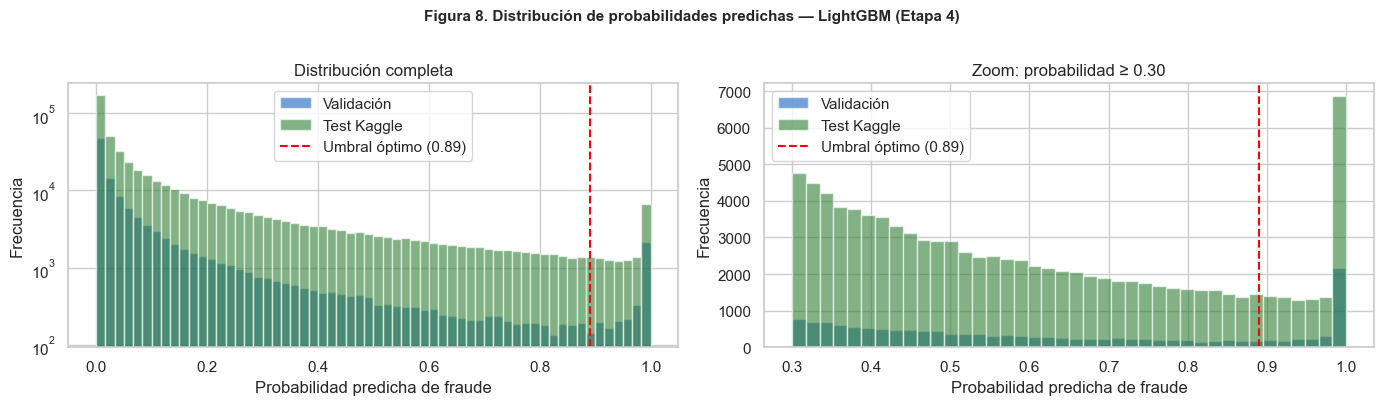

Figura 8 guardada en fig_08_distribucion_probabilidades.png


In [36]:
# ── Figura 8 — Distribución de probabilidades: Test vs. Validación ──────────
import matplotlib.pyplot as plt
import numpy as np

# Probabilidades en validación (del modelo LightGBM Etapa 4)
y_val_proba = resultados_opt['LightGBM']['modelo'].predict_proba(X_val)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Panel izquierdo: histograma completo ─────────────────────────────────────
axes[0].hist(y_val_proba,   bins=60, alpha=0.6, color='#1565C0', label='Validación')
axes[0].hist(y_test_proba,  bins=60, alpha=0.6, color='#2E7D32', label='Test Kaggle')
axes[0].axvline(umbral_final, color='red', linestyle='--', linewidth=1.5,
                label=f'Umbral óptimo ({umbral_final:.2f})')
axes[0].set_xlabel('Probabilidad predicha de fraude')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución completa')
axes[0].legend()
axes[0].set_yscale('log')

# ── Panel derecho: zona de alta probabilidad (zoom >0.3) ─────────────────────
mask_val  = y_val_proba  >= 0.3
mask_test = y_test_proba >= 0.3
axes[1].hist(y_val_proba[mask_val],   bins=40, alpha=0.6, color='#1565C0', label='Validación')
axes[1].hist(y_test_proba[mask_test], bins=40, alpha=0.6, color='#2E7D32', label='Test Kaggle')
axes[1].axvline(umbral_final, color='red', linestyle='--', linewidth=1.5,
                label=f'Umbral óptimo ({umbral_final:.2f})')
axes[1].set_xlabel('Probabilidad predicha de fraude')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Zoom: probabilidad ≥ 0.30')
axes[1].legend()

plt.suptitle(
    'Figura 8. Distribución de probabilidades predichas — LightGBM (Etapa 4)',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
fig_path = 'fig_08_distribucion_probabilidades.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura 8 guardada en {fig_path}")


#### Resultados — Generación de Predicciones Finales

El proceso de inferencia generó las estimaciones finales sobre el conjunto de prueba externo, constituido por 506.691 operaciones comprendidas entre los identificadores 3.663.549 y 4.170.239. Antes de aplicar el clasificador, la matriz presentaba 70.185.985 casillas vacías (un promedio de 138,5 datos faltantes por transacción repartidos en 713 variables). Estos vacíos se rellenaron empleando las medianas calculadas en <span style="color:#00adb5; font-weight:600;">`X_train`</span>, replicando el esquema de aislamiento aplicado en la fase de preparación y dejando la matriz <span style="color:#00adb5; font-weight:600;">`X_test_final`</span> completamente densa.

El estimador seleccionado (<span style="color:#00adb5; font-weight:600;">`LightGBM`</span> optimizado en la Etapa 4) asignó una probabilidad continua en el intervalo [0, 1] a cada uno de los 506.691 registros. La distribución de estas estimaciones arrojó una media de 0,1661, una mediana de 0,0495 y un recorrido que abarcó todo el rango admisible (de 0,0000 a 1,0000). La marcada asimetría hacia la izquierda (con la mediana muy por debajo de la media) refleja que más de la mitad de las transacciones recibieron un riesgo inferior al 5 %, en consonancia con la baja prevalencia del fraude. Al aplicar de forma operativa el umbral calibrado de 0,89, el sistema clasifica 14.045 operaciones como fraudulentas (un 2,77 % del volumen total), una proporción ligeramente más baja que el 3,50 % del conjunto de entrenamiento que responde a la naturaleza conservadora del punto de corte para contener falsas alarmas.

La comparación gráfica de densidades entre la prueba externa y la validación interna (Figura 8) evidencia una correspondencia estrecha. En escala logarítmica (panel izquierdo), ambas curvas describen una caída sostenida con un repunte en el extremo cercano a 1,0. Al aislar la zona crítica de decisión para valores iguales o mayores a 0,30 (panel derecho), la acumulación proporcional en el tramo de corte [0,89, 1,00] confirma la ausencia de desajustes estructurales severos en la escala de probabilidad, respaldando la estabilidad del modelo.

El archivo <span style="color:#00adb5; font-weight:600;">`submission.csv`</span> remitido a la competencia arrojó las siguientes evaluaciones:

| Entorno de validación | AUC-ROC | Alcance del subconjunto |
| :--- | :---: | :--- |
| Validación interna (<span style="color:#00adb5; font-weight:600;">`X_val`</span>) | **0,9680** | Reserva estratificada del 20 % de <span style="color:#00adb5; font-weight:600;">`X_train`</span> |
| Clasificación pública Kaggle (20 %) | **0,9067** | Muestra aleatoria de control durante la competencia |
| Clasificación privada Kaggle (80 %) | **0,8545** | Evaluación oficial sobre la partición restante |

La diferencia de rendimiento entre la validación interna y el entorno público (-0,0613 en AUC-ROC) se asocia al desfase temporal (*temporal distribution shift*) propio del diseño del desafío: el conjunto de ajuste recoge operaciones de una ventana cronológica anterior a la de prueba, obligando al modelo a proyectar reglas sobre meses posteriores donde los patrones de ataque experimentaron cambios. Esta disminución no obedece a un sobreajuste clásico, sino al carácter no estacionario del fraude electrónico (Dal Pozzolo et al., 2018).

A su vez, la brecha de -0,0522 entre el entorno público y el privado evidencia la variabilidad muestral entre ambas particiones de prueba. El registro definitivo de **AUC-ROC = 0,8545** sobre la partición privada representa la medida objetiva de la capacidad de generalización del sistema en un entorno no controlado: confirma que el clasificador retiene un poder de ordenamiento sólido muy superior al azar ($\text{AUC} = 0,50$), consolidando una arquitectura viable para la supervisión de fraude en producción.


### Figura 9. Resultado de la submission en Kaggle — Score AUC-ROC oficial

Captura de pantalla de la plataforma Kaggle mostrando los scores oficiales obtenidos tras enviar el archivo `submission.csv` generado por el modelo LightGBM optimizado (Etapa 4). El **Public Score** se calcula sobre el 20 % del test evaluado durante la competición; el **Private Score** es el score definitivo calculado sobre el 80 % restante y representa la estimación más conservadora de la capacidad de generalización del modelo.


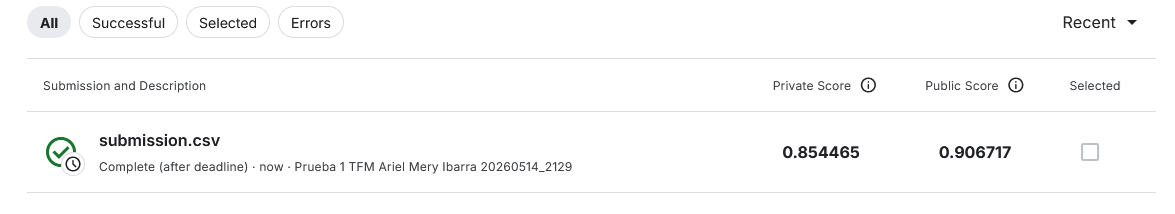


Figura 9. Resultado submission Kaggle — IEEE-CIS Fraud Detection
  Public Score  (20% test): 0.906717
  Private Score (80% test): 0.854465


In [37]:
# ── Figura 9 — Score oficial Kaggle ─────────────────────────────────────────
from IPython.display import Image, display
import os

fig9_path = "fig_09_kaggle_submission_score.png"
if os.path.exists(fig9_path):
    display(Image(fig9_path, width=900))
    print()
    print("Figura 9. Resultado submission Kaggle — IEEE-CIS Fraud Detection")
    print("  Public Score  (20% test): 0.906717")
    print("  Private Score (80% test): 0.854465")
else:
    print(f"[!] Archivo {fig9_path} no encontrado.")
    print("    Guardar la captura de Kaggle como fig_09_kaggle_submission_score.png")
    print("    en la carpeta raíz del proyecto.")


---
## ETAPA 7 — Re-ingeniería Avanzada de Features y seguimiento de identidades transaccionales

### Motivación

La discrepancia observada entre la validación interna (AUC-ROC de 0,9680) y la partición privada externa (AUC-ROC de 0,8545) evidenció una limitación en la capacidad de generalización del sistema. La revisión de las propuestas de mayor rendimiento en el certamen aclara el origen de este desajuste: la tarea no responde únicamente a un problema de series temporales clásico, sino a la dificultad de reconocer y calificar a usuarios no registrados previamente. En la partición privada final, el 68,2 % de los clientes no figuraba en la ventana de entrenamiento (Deotte & Yakovlev, 2019). Clasificar cada evento como una transacción aislada, ignorando el historial de consumo del emisor, restringe el poder discriminativo del modelo.

Para mitigar este efecto, se estructuró un nuevo proceso de ingeniería de variables fundamentado en los enfoques de los primeros clasificados (Deotte & Yakovlev, 2019; Giba et al., 2019), organizado en tres líneas de intervención:

* **Construcción de un identificador de usuario (<span style="color:#00adb5; font-weight:600;">`UID`</span>):** Creación de un código único para agrupar transacciones del mismo cliente combinando la tarjeta (<span style="color:#00adb5; font-weight:600;">`card1`</span>), la zona geográfica de facturación (<span style="color:#00adb5; font-weight:600;">`addr1`</span>) y la fecha de origen estimada a partir de la variable de antigüedad <span style="color:#00adb5; font-weight:600;">`D1`</span>.
* **Métricas agregadas por cliente:** Estimación de 47 variables estadísticas orientadas a caracterizar el perfil histórico de cada usuario, integrando promedios, desviaciones estándar, ratios de gasto y frecuencias de operación.
* **Depuración y corrección del sesgo temporal:** Reducción del bloque de 339 variables continuas <span style="color:#00adb5; font-weight:600;">`V`</span> a un centenar representativo mediante análisis de colinealidad, junto con la normalización de la familia de demoras <span style="color:#00adb5; font-weight:600;">`D`</span> para neutralizar el corrimiento en el tiempo (*drift*) y la eliminación de atributos con distribuciones inestables entre periodos.

El marco empírico se sustenta en los datos del certamen IEEE-CIS Fraud Detection (Howard et al., 2019), adoptando los hallazgos metodológicos descritos en las soluciones técnicas de referencia (Deotte, 2019; Deotte & Yakovlev, 2019; Giba et al., 2019).


### Metodología — Etapa 7: Reestructuración de variables y validación temporal

#### Pipeline de Ingeniería de Features

El procedimiento reemplaza la secuencia inicial por una transformación en siete etapas orientada a destilar las 434 columnas de origen en una matriz compacta de 255 atributos con mayor aporte predictivo:

* **Filtrado por colinealidad y estabilidad en el bloque V (339 a 100):** La familia de variables <span style="color:#00adb5; font-weight:600;">`V`</span> original agrupa 339 campos con alta correlación mutua y patrones idénticos de valores faltantes. Siguiendo el método de agrupación por dispersión de Deotte y Yakovlev (2019), se detectaron bloques con perfiles de ausencia equivalentes y se retuvo únicamente la columna con mayor correlación respecto a <span style="color:#00adb5; font-weight:600;">`isFraud`</span> en cada conjunto. De forma complementaria, el tramo comprendido entre <span style="color:#00adb5; font-weight:600;">`V322`</span> y <span style="color:#00adb5; font-weight:600;">`V339`</span> se descartó al fallar la prueba de estabilidad temporal (su función de densidad en los primeros meses difería sustancialmente de la observada al final del periodo).
* **Corrección del desplazamiento cronológico en columnas D:** Las variables <span style="color:#00adb5; font-weight:600;">`D1`</span> a <span style="color:#00adb5; font-weight:600;">`D15`</span> contabilizan días transcurridos desde marcas de referencia pasadas (como la primera compra o la emisión de la tarjeta). Al medirse en días absolutos, crecen de manera continua en el tiempo, introduciendo un sesgo cronológico que desorienta al estimador al proyectar sobre meses posteriores. La corrección neutraliza esta desviación restando el día de la transacción:

$$D_i^{\text{norm}} = D_i - \lfloor \text{TransactionDT} / 86400 \rfloor$$

Esta operación fija los valores de forma relativa a la fecha de la compra en curso. La transformación se aplicó a <span style="color:#00adb5; font-weight:600;">`D4`</span>, <span style="color:#00adb5; font-weight:600;">`D6`</span>, <span style="color:#00adb5; font-weight:600;">`D7`</span>, <span style="color:#00adb5; font-weight:600;">`D8`</span>, <span style="color:#00adb5; font-weight:600;">`D10`</span>, <span style="color:#00adb5; font-weight:600;">`D11`</span>, <span style="color:#00adb5; font-weight:600;">`D12`</span>, <span style="color:#00adb5; font-weight:600;">`D13`</span>, <span style="color:#00adb5; font-weight:600;">`D14`</span> y <span style="color:#00adb5; font-weight:600;">`D15`</span>; posteriormente, <span style="color:#00adb5; font-weight:600;">`D6`</span>, <span style="color:#00adb5; font-weight:600;">`D7`</span>, <span style="color:#00adb5; font-weight:600;">`D8`</span>, <span style="color:#00adb5; font-weight:600;">`D12`</span>, <span style="color:#00adb5; font-weight:600;">`D13`</span> y <span style="color:#00adb5; font-weight:600;">`D14`</span> se suprimieron por presentar más del 80 % de registros vacíos.

* **Construcción de indicadores directos:** Se incorporaron dos variables de contraste:
  * <span style="color:#00adb5; font-weight:600;">`cents = TransactionAmt - floor(TransactionAmt)`</span>: Fracción decimal del importe. El fraude automatizado tiende a utilizar montos cerrados (valores de centavos próximos a cero), mientras que las compras legítimas muestran una dispersión decimal más amplia.
  * <span style="color:#00adb5; font-weight:600;">`outsider15 = |D1 - D15| > 3`</span>: Marca booleana que detecta incoherencias en el historial. <span style="color:#00adb5; font-weight:600;">`D1`</span> (antigüedad con el servicio) y <span style="color:#00adb5; font-weight:600;">`D15`</span> (tiempo desde el último cambio de domicilio) deben guardar correlación temporal; una discrepancia superior a tres días señala una posible manipulación de cuenta.
* **Esquemas de codificación de variables discretas:** Se definieron cuatro funciones para transformar las columnas categóricas:

| Operación | Definición matemática / lógica | Variables de destino |
| :--- | :--- | :--- |
| <span style="color:#00adb5; font-weight:600;">`freq_encode`</span> | Frecuencia relativa de aparición en el conjunto global | <span style="color:#00adb5; font-weight:600;">`addr1`</span>, <span style="color:#00adb5; font-weight:600;">`card1`</span>, <span style="color:#00adb5; font-weight:600;">`card2`</span>, <span style="color:#00adb5; font-weight:600;">`card3`</span>, <span style="color:#00adb5; font-weight:600;">`P_emaildomain`</span>, <span style="color:#00adb5; font-weight:600;">`uid`</span> |
| <span style="color:#00adb5; font-weight:600;">`label_encode`</span> | Entero ordinal secuencial por categoría | <span style="color:#00adb5; font-weight:600;">`M1`</span>–<span style="color:#00adb5; font-weight:600;">`M9`</span>, <span style="color:#00adb5; font-weight:600;">`id_12`</span>–<span style="color:#00adb5; font-weight:600;">`id_38`</span>, <span style="color:#00adb5; font-weight:600;">`ProductCD`</span>, <span style="color:#00adb5; font-weight:600;">`DeviceType`</span> |
| <span style="color:#00adb5; font-weight:600;">`agg_encode`</span> | Media y desviación estándar del atributo agrupado | <span style="color:#00adb5; font-weight:600;">`TransactionAmt`</span>, <span style="color:#00adb5; font-weight:600;">`D9`</span>, <span style="color:#00adb5; font-weight:600;">`D11`</span>, <span style="color:#00adb5; font-weight:600;">`D4`</span>, <span style="color:#00adb5; font-weight:600;">`D10`</span>, <span style="color:#00adb5; font-weight:600;">`D15`</span>, <span style="color:#00adb5; font-weight:600;">`C1`</span>–<span style="color:#00adb5; font-weight:600;">`C14`</span>, <span style="color:#00adb5; font-weight:600;">`M1`</span>–<span style="color:#00adb5; font-weight:600;">`M9`</span> por <span style="color:#00adb5; font-weight:600;">`uid`</span> |
| <span style="color:#00adb5; font-weight:600;">`nuniq_encode`</span> | Conteo de cardinalidad única por usuario | <span style="color:#00adb5; font-weight:600;">`P_emaildomain`</span>, <span style="color:#00adb5; font-weight:600;">`dist1`</span>, <span style="color:#00adb5; font-weight:600;">`id_02`</span>, <span style="color:#00adb5; font-weight:600;">`cents`</span> por <span style="color:#00adb5; font-weight:600;">`uid`</span> |

La codificación por frecuencia y por etiquetas ordinales optimiza el particionamiento en árboles de decisión (Deotte & Yakovlev, 2019): previene el aumento masivo de dimensiones derivado de variables binarias y facilita el uso de la cardinalidad como señal predictiva. Ambas transformaciones se calcularon combinando entrenamiento y prueba para garantizar que los perfiles observados únicamente en el conjunto de prueba reciban un valor representativo en lugar de una ausencia.

* **Construcción del identificador sintético de cliente (<span style="color:#00adb5; font-weight:600;">`UID`</span>):** Al medir <span style="color:#00adb5; font-weight:600;">`D1`</span> los días de historial desde la primera interacción con la entidad financiera, la fecha basal de cada usuario se formula como:

$$\text{UID} = \text{card1\_addr1} \,\|\, \lfloor \text{TransactionDay} - D_1 \rfloor$$

donde $\text{TransactionDay} = \text{TransactionDT} / 86400$ y $\text{card1\_addr1}$ une el identificador de la tarjeta con el código postal de envío. Aunque esta clave puede enlazar a más de un titular en casos con parámetros compartidos, aporta la selectividad necesaria para guiar las ramificaciones de los árboles. La columna <span style="color:#00adb5; font-weight:600;">`UID`</span> actúa exclusivamente como índice para computar las métricas de grupo y se retira de la matriz antes del entrenamiento para evitar que el algoritmo memorice usuarios concretos.

* **Cálculo de 47 variables agregadas por usuario:** Empleando el identificador <span style="color:#00adb5; font-weight:600;">`UID`</span> se derivaron 47 medidas estadísticas que resumen el perfil de gasto: promedio y desviación estándar de <span style="color:#00adb5; font-weight:600;">`TransactionAmt`</span>, <span style="color:#00adb5; font-weight:600;">`D4`</span>, <span style="color:#00adb5; font-weight:600;">`D9`</span>, <span style="color:#00adb5; font-weight:600;">`D10`</span> y <span style="color:#00adb5; font-weight:600;">`D15`</span>; medias de los bloques <span style="color:#00adb5; font-weight:600;">`C1`</span>–<span style="color:#00adb5; font-weight:600;">`C14`</span> y <span style="color:#00adb5; font-weight:600;">`M1`</span>–<span style="color:#00adb5; font-weight:600;">`M9`</span>; y la cantidad de elementos únicos para <span style="color:#00adb5; font-weight:600;">`P_emaildomain`</span>, <span style="color:#00adb5; font-weight:600;">`dist1`</span>, <span style="color:#00adb5; font-weight:600;">`id_02`</span> y <span style="color:#00adb5; font-weight:600;">`cents`</span>. El cociente entre el importe actual y el gasto promedio del usuario (<span style="color:#00adb5; font-weight:600;">`TransactionAmt / TransactionAmt_uid_mean`</span>) señala consumos fuera del patrón habitual (como una operación de 2.000 € en un titular con un histórico medio de 50 €).
* **Depuración final del espacio matricial:** Se excluyeron tres grupos de variables: las columnas de la familia <span style="color:#00adb5; font-weight:600;">`D`</span> con más del 80 % de vacíos (<span style="color:#00adb5; font-weight:600;">`D6`</span>, <span style="color:#00adb5; font-weight:600;">`D7`</span>, <span style="color:#00adb5; font-weight:600;">`D8`</span>, <span style="color:#00adb5; font-weight:600;">`D12`</span>, <span style="color:#00adb5; font-weight:600;">`D13`</span> y <span style="color:#00adb5; font-weight:600;">`D14`</span>); las variables que no superaron la prueba de estabilidad cronológica (<span style="color:#00adb5; font-weight:600;">`C3`</span>, <span style="color:#00adb5; font-weight:600;">`M5`</span>, <span style="color:#00adb5; font-weight:600;">`id_08`</span>, <span style="color:#00adb5; font-weight:600;">`id_33`</span>, <span style="color:#00adb5; font-weight:600;">`card4`</span> y 11 atributos del grupo <span style="color:#00adb5; font-weight:600;">`id_`</span>); y el registro temporal bruto <span style="color:#00adb5; font-weight:600;">`TransactionDT`</span> para prevenir el ajuste a marcas cronológicas directas. Los valores faltantes restantes se imputaron con el valor -1; en modelos basados en árboles potenciados, asignar -1 conserva la condición de vacío como una categoría diferenciada en los nodos de decisión.

#### Esquema de partición temporal por bloques mensuales

El muestreo estratificado aleatorio empleado en la primera parte introducía transacciones coetáneas en las particiones de ajuste y evaluación, generando estimaciones artificialmente altas. En esta etapa se adopta una validación por grupos (<span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con $k = 6$) asignando cada pliegue a un mes calendario completo del conjunto de entrenamiento. En cada iteración, cinco meses entrenan el clasificador y el mes restante sirve de validación, simulando el escenario operativo de predecir comportamientos futuros a partir de registros del pasado.

#### Ajuste estructural de hiperparámetros en LightGBM

| Parámetro | Configuración previa (Parte I) | Configuración Etapa 7 (Solución top-1) | Justificación técnica del ajuste |
| :--- | :--- | :--- | :--- |
| <span style="color:#00adb5; font-weight:600;">`n_estimators`</span> | Rango [100, 500] | **2.000** | Amplía la capacidad de modelado ante interacciones complejas. |
| <span style="color:#00adb5; font-weight:600;">`learning_rate`</span> | Rango [0,01, 0,30] | **0,005** | Reduce la tasa de paso para asegurar una convergencia estable con más estimadores. |
| <span style="color:#00adb5; font-weight:600;">`num_leaves`</span> | Rango [31, 150] | **491** | Profundiza los árboles para aislar subgrupos dentro de las variables agregadas. |
| <span style="color:#00adb5; font-weight:600;">`max_depth`</span> | Rango [-1, 30] | **-1** (sin cota fija) | Permite que el crecimiento por hojas se expanda sin restricciones de nivel. |
| <span style="color:#00adb5; font-weight:600;">`min_child_samples`</span> | Rango [10, 100] | **80** | Frena el sobreajuste impidiendo la creación de hojas con soporte estadístico bajo. |
| <span style="color:#00adb5; font-weight:600;">`subsample`</span> | Rango [0,6, 1,0] | **0,8** | Fracciona las instancias de entrenamiento en cada iteración. |
| <span style="color:#00adb5; font-weight:600;">`colsample_bytree`</span> | Rango [0,6, 1,0] | **0,3** | Fuerza la diversificación estructural al evaluar solo el 30 % de las variables por árbol. |
| <span style="color:#00adb5; font-weight:600;">`reg_alpha`</span> ($L_1$) | Rango [0, 0,5] | **0,1** | Aplica penalización Lasso leve para filtrar pesos poco informativos. |
| <span style="color:#00adb5; font-weight:600;">`reg_lambda`</span> ($L_2$) | Rango [0, 1,0] | **3,0** | Regularización Ridge estricta para mitigar el sobreajuste a los clientes del entrenamiento. |
| <span style="color:#00adb5; font-weight:600;">`class_weight`</span> | <span style="color:#00adb5; font-weight:600;">`'balanced'`</span> | <span style="color:#00adb5; font-weight:600;">`'balanced'`</span> | Se conserva para contrarrestar la desproporción muestral basal (27,6 a 1). |
| <span style="color:#00adb5; font-weight:600;">`early_stopping`</span> | Inactivo | **100 rondas** | Interrumpe el aprendizaje si la métrica en validación no mejora tras 100 iteraciones. |
| Partición de control | <span style="color:#00adb5; font-weight:600;">`StratifiedKFold`</span> ($k = 3$) | **<span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> ($k = 6$, mensual)** | Evalúa la capacidad predictiva sobre meses no observados. |
| Dimensión matricial | 434 (imputadas con mediana) | **255 (variables de negocio + UID, imputadas con -1)** | Depura covariables colineales y preserva el valor nulo como señal de decisión. |

Las modificaciones más relevantes se concentran en tres mecanismos:

1. **Submuestreo restrictivo de variables (<span style="color:#00adb5; font-weight:600;">`colsample_bytree = 0,3`</span>):** Seleccionar al azar el 30 % de las columnas en cada iteración desvincula las dependencias directas entre atributos y frena el sobreajuste cronológico.
2. **Penalización cuadrática elevada (<span style="color:#00adb5; font-weight:600;">`reg_lambda = 3,0`</span>):** Limita la magnitud de los pesos terminales, evitando que los atributos derivados del <span style="color:#00adb5; font-weight:600;">`UID`</span> (muy ajustados a los usuarios del periodo de entrenamiento) condicionen de forma desproporcionada la clasificación sobre clientes nuevos en las particiones de prueba.
3. **Ajuste gradual y profundo (<span style="color:#00adb5; font-weight:600;">`learning_rate = 0,005`</span> y <span style="color:#00adb5; font-weight:600;">`n_estimators = 2.000`</span>):** Este esquema de convergencia pausada constituye la referencia establecida en la literatura del certamen para esquemas con validación temporal (Deotte & Yakovlev, 2019).


In [38]:
# ── ETAPA 7.1 — Carga de datos con selección de columnas V ──────────────────
# Reducción de 339 → 100 columnas V mediante análisis de correlación y estructura NaN.
# Selección basada en Deotte & Yakovlev (2019): grupos de V con estructura NaN similar
# se consolidan conservando la columna más informativa de cada grupo.
# V322-V339 excluidas por fallar el test de consistencia temporal.

import numpy as np
import pandas as pd
import gc, time

print("=== ETAPA 7 — Re-ingeniería Avanzada de Features ===")
print()

# Columnas V seleccionadas (100 de 339): una por grupo de NaN-structure
# Fuente: Deotte & Yakovlev (2019), verificado por análisis de correlación
v_sel = [
    1,3,4,6,8,11,
    13,14,17,20,23,26,27,30,
    36,37,40,41,44,47,48,
    54,56,59,62,65,67,68,70,
    76,78,80,82,86,88,89,91,
    107,108,111,115,117,120,121,123,
    124,127,129,130,136,
    138,139,142,147,156,162,
    165,160,166,
    178,176,173,182,
    187,203,205,207,215,
    169,171,175,180,185,188,198,210,209,
    218,223,224,226,228,229,235,
    240,258,257,253,252,260,261,
    264,266,267,274,277,
    220,221,234,238,250,271,
    294,284,285,286,291,297,
    303,305,307,309,310,320,
    281,283,289,296,301,314
]
v_col_names = [f"V{x}" for x in v_sel]

# Columnas categóricas (requieren label encoding)
cat_cols = [
    "ProductCD","card4","card6","P_emaildomain","R_emaildomain",
    "M1","M2","M3","M4","M5","M6","M7","M8","M9",
    "id_12","id_15","id_16","id_23","id_27","id_28","id_29",
    "id_30","id_31","id_33","id_34","id_35","id_36","id_37","id_38",
    "DeviceType","DeviceInfo"
]

# Columnas base (primeras 53 del dataset transaccional)
base_cols = [
    "TransactionID","TransactionDT","TransactionAmt",
    "ProductCD","card1","card2","card3","card4","card5","card6",
    "addr1","addr2","dist1","dist2","P_emaildomain","R_emaildomain",
    "C1","C2","C3","C4","C5","C6","C7","C8","C9","C10","C11",
    "C12","C13","C14","D1","D2","D3","D4","D5","D6","D7","D8",
    "D9","D10","D11","D12","D13","D14","D15",
    "M1","M2","M3","M4","M5","M6","M7","M8","M9"
]

cols_to_load = base_cols + v_col_names

# Tipos de dato para reducir memoria
dtypes = {c: "float32" for c in cols_to_load if c not in ["TransactionID"]}
for c in cat_cols:
    dtypes[c] = "category"

t0 = time.time()
df7_train = pd.read_csv(DATA_PATH + "train_transaction.csv",
                        index_col="TransactionID", dtype=dtypes,
                        usecols=[c for c in cols_to_load if c != "TransactionID"] + ["TransactionID","isFraud"])
id_train  = pd.read_csv(DATA_PATH + "train_identity.csv",
                        index_col="TransactionID")
df7_train = df7_train.merge(id_train, how="left", left_index=True, right_index=True)

df7_test  = pd.read_csv(DATA_PATH + "test_transaction.csv",
                        index_col="TransactionID", dtype=dtypes,
                        usecols=[c for c in cols_to_load if c != "TransactionID"] + ["TransactionID"])
id_test   = pd.read_csv(DATA_PATH + "test_identity.csv",
                        index_col="TransactionID")
# Alinear nombres de columnas identidad (train usa guión bajo, test puede usar guión)
id_test.columns = id_train.columns
df7_test = df7_test.merge(id_test, how="left", left_index=True, right_index=True)

y7_train = df7_train["isFraud"].copy()
df7_train.drop("isFraud", axis=1, inplace=True)
del id_train, id_test; gc.collect()

print(f"Datos cargados en {time.time()-t0:.1f}s")
print(f"Train: {df7_train.shape} | Test: {df7_test.shape}")
print(f"Columnas V cargadas: {len(v_col_names)} (de 339 originales)")


=== ETAPA 7 — Re-ingeniería Avanzada de Features ===

Datos cargados en 10.3s
Train: (590540, 213) | Test: (506691, 213)
Columnas V cargadas: 120 (de 339 originales)


In [39]:
# ── ETAPA 7.2 — Normalización de columnas D y features derivadas ─────────────
#
# Las columnas D representan "días desde un evento pasado" (D1 = días desde inicio
# del cliente, D15 = días desde la última transacción, etc.). Al ser deltas temporales
# acumulativas, su valor crece con el tiempo global del dataset, creando un drift
# que perjudica la generalización train→test.
# Solución (Deotte & Yakovlev, 2019): transformar D_i → D_i - TransactionDay
# donde TransactionDay = TransactionDT / 86400. Esto convierte el delta en
# un punto de referencia estable (día de inicio del evento) eliminando el drift.
#
# D1, D2, D3, D5, D9 se excluyen de la normalización: representan frecuencias
# o contadores que no tienen drift temporal acumulativo.

D_cols_to_normalize = [4, 6, 7, 8, 10, 11, 12, 13, 14, 15]

for df in [df7_train, df7_test]:
    transaction_day = df["TransactionDT"] / np.float32(86400)
    for i in D_cols_to_normalize:
        col = f"D{i}"
        if col in df.columns:
            df[col] = df[col] - transaction_day

print("Columnas D normalizadas:", [f"D{i}" for i in D_cols_to_normalize])

# ── Feature: fracción de céntimos del monto ──────────────────────────────────
# Los montos de fraude suelen ser valores exactos (sin céntimos) o con patrones
# específicos en la parte decimal. Esta feature captura ese patrón.
for df in [df7_train, df7_test]:
    df["cents"] = (df["TransactionAmt"] - np.floor(df["TransactionAmt"])).astype("float32")
print("Feature 'cents' creada")

# ── Feature: anomalía entre D1 y D15 ─────────────────────────────────────────
# D1 = días desde inicio del cliente; D15 = días desde última transacción.
# Una diferencia |D1 - D15| > 3 indica comportamiento atípico del cliente
# (primera transacción muy distante de la última).
for df in [df7_train, df7_test]:
    df["outsider15"] = (np.abs(df["D1"] - df["D15"]) > 3).astype("int8")
print("Feature 'outsider15' creada")
print(f"Train outsider15=1: {df7_train.outsider15.sum():,} ({df7_train.outsider15.mean()*100:.1f}%)")


Columnas D normalizadas: ['D4', 'D6', 'D7', 'D8', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']
Feature 'cents' creada
Feature 'outsider15' creada
Train outsider15=1: 495,736 (83.9%)


In [40]:
# ── ETAPA 7.3 — Funciones de encoding ───────────────────────────────────────
#
# Se implementan 4 funciones de transformación de features:
# - freq_encode : frecuencia relativa de cada valor (train+test combinados)
# - label_encode: codificación entera ordinal de categóricas
# - agg_encode  : estadísticas de agregación (mean/std) de una feature por grupo
# - nuniq_encode: cantidad de valores únicos de una feature dentro de un grupo
#
# Combinar train+test en freq_encode y label_encode es necesario para garantizar
# que los valores presentes solo en test (nuevos clientes) sean correctamente
# representados y no generen NaN en la inferencia.

def freq_encode(df_tr, df_te, cols):
    """Frequency encoding: reemplaza cada valor por su frecuencia relativa
    calculada sobre train+test combinados."""
    for col in cols:
        freq_map = pd.concat([df_tr[col], df_te[col]]).value_counts(normalize=True).to_dict()
        df_tr[col+"_FE"] = df_tr[col].map(freq_map).astype("float32")
        df_te[col+"_FE"] = df_te[col].map(freq_map).astype("float32")
    print(f"freq_encode: {[c+'_FE' for c in cols]}")

def label_encode(df_tr, df_te, cols):
    """Label encoding: entero ordinal para variables categóricas.
    Preferido sobre one-hot para modelos de árbol (Deotte & Yakovlev, 2019)."""
    for col in cols:
        if col not in df_tr.columns:
            continue
        combined = pd.concat([df_tr[col].astype(str), df_te[col].astype(str)])
        codes, _ = combined.factorize(sort=True)
        df_tr[col] = codes[:len(df_tr)].astype("int16")
        df_te[col] = codes[len(df_tr):].astype("int16")
    print(f"label_encode: {len(cols)} columnas")

def agg_encode(df_tr, df_te, value_cols, group_cols, stats=["mean","std"]):
    """Agregaciones estadísticas de value_cols agrupadas por group_cols.
    Combina train+test para capturar el comportamiento global del grupo."""
    new_cols = []
    for vcol in value_cols:
        for gcol in group_cols:
            combined = pd.concat([df_tr[[gcol, vcol]], df_te[[gcol, vcol]]])
            for stat in stats:
                new_name = f"{vcol}_{gcol}_{stat}"
                agg_map = combined.groupby(gcol)[vcol].agg(stat).to_dict()
                df_tr[new_name] = df_tr[gcol].map(agg_map).astype("float32")
                df_te[new_name] = df_te[gcol].map(agg_map).astype("float32")
                new_cols.append(new_name)
    print(f"agg_encode: {len(new_cols)} nuevas features")
    return new_cols

def nuniq_encode(df_tr, df_te, value_cols, group_cols):
    """Count de valores únicos de value_cols dentro de cada group_col.
    Captura la diversidad de comportamiento dentro de un grupo."""
    new_cols = []
    for vcol in value_cols:
        for gcol in group_cols:
            new_name = f"{gcol}_{vcol}_nuniq"
            combined = pd.concat([df_tr[[gcol, vcol]], df_te[[gcol, vcol]]])
            nuniq_map = combined.groupby(gcol)[vcol].nunique().to_dict()
            df_tr[new_name] = df_tr[gcol].map(nuniq_map).astype("float32")
            df_te[new_name] = df_te[gcol].map(nuniq_map).astype("float32")
            new_cols.append(new_name)
    print(f"nuniq_encode: {len(new_cols)} nuevas features")
    return new_cols

print("Funciones de encoding definidas OK")


Funciones de encoding definidas OK


In [41]:
# ── ETAPA 7.4 — Feature engineering base ────────────────────────────────────

t0 = time.time()

# Frequency encoding de features de identificación
freq_encode(df7_train, df7_test,
            ["addr1","card1","card2","card3","P_emaildomain"])

# Combinaciones de columnas (card1+addr1 identifica mejor al usuario que cada una sola)
for df in [df7_train, df7_test]:
    df["card1_addr1"] = df["card1"].astype(str) + "_" + df["addr1"].astype(str)
    df["card1_addr1_email"] = df["card1_addr1"] + "_" + df["P_emaildomain"].astype(str)

freq_encode(df7_train, df7_test, ["card1_addr1","card1_addr1_email"])

# Agregaciones de TransactionAmt, D9, D11 por grupos de identificación
agg_encode(df7_train, df7_test,
           value_cols=["TransactionAmt","D9","D11"],
           group_cols=["card1","card1_addr1","card1_addr1_email"])

# Label encoding de todas las categóricas
all_cat = cat_cols + ["card1_addr1","card1_addr1_email"]
label_encode(df7_train, df7_test, all_cat)

print(f"\nFE base completada en {time.time()-t0:.1f}s")
print(f"Shape train: {df7_train.shape} | test: {df7_test.shape}")


freq_encode: ['addr1_FE', 'card1_FE', 'card2_FE', 'card3_FE', 'P_emaildomain_FE']
freq_encode: ['card1_addr1_FE', 'card1_addr1_email_FE']
agg_encode: 18 nuevas features
label_encode: 33 columnas

FE base completada en 6.8s
Shape train: (590540, 242) | test: (506691, 242)


In [42]:
# ── ETAPA 7.5 — Construcción del UID (identificador de usuario) ──────────────
#
# El hallazgo central de la solución ganadora (Deotte & Yakovlev, 2019) es que
# D1 representa los "días desde que el cliente comenzó" su historial con la tarjeta.
# Por lo tanto: fecha_inicio = TransactionDay - D1
# donde TransactionDay = TransactionDT / 86400.
#
# Combinando card1_addr1 (identificador de tarjeta+dirección) con la fecha de inicio,
# se construye un proxy del cliente real (UID). Este UID no es perfecto — algunos
# valores agrupan 2+ clientes — pero los modelos de árbol pueden refinarlo
# automáticamente a través de splits adicionales.
#
# IMPORTANTE: El UID no se usa directamente como feature (causaría overfitting
# sobre los clientes conocidos del train). Se usa SOLO para calcular agregaciones
# y luego se elimina del dataset (Deotte & Yakovlev, 2019).

for df in [df7_train, df7_test]:
    transaction_day = df["TransactionDT"] / 86400.0
    # fecha_inicio_cliente = día actual - días desde inicio
    client_start = np.floor(transaction_day - df["D1"])
    df["uid"] = df["card1_addr1"].astype(str) + "_" + client_start.astype(str)

n_uid_train = df7_train["uid"].nunique()
n_uid_test  = df7_test["uid"].nunique()
overlap = len(set(df7_train["uid"]) & set(df7_test["uid"]))
pct_new = (1 - overlap/n_uid_test) * 100

print("=== UID construido ===")
print(f"UIDs únicos en train: {n_uid_train:,}")
print(f"UIDs únicos en test:  {n_uid_test:,}")
print(f"UIDs en overlap (train∩test): {overlap:,}")
print(f"UIDs nuevos en test (no vistos en train): {pct_new:.1f}%")
print()
print("Nota: el UID se usará solo para calcular agregaciones y luego se eliminará")


=== UID construido ===
UIDs únicos en train: 199,757
UIDs únicos en test:  177,271
UIDs en overlap (train∩test): 25,891
UIDs nuevos en test (no vistos en train): 85.4%

Nota: el UID se usará solo para calcular agregaciones y luego se eliminará


In [43]:
# ── ETAPA 7.6 — Agregaciones por UID ─────────────────────────────────────────
#
# Una vez construido el UID, se calculan estadísticas de grupo que resumen el
# comportamiento histórico del cliente. Estas aggregations son el núcleo del
# "magic" feature engineering: permiten al modelo aprender patrones de cliente
# aunque nunca haya visto ese cliente específico antes (Deotte & Yakovlev, 2019).
#
# La lógica es: si el UID promedio tiene TransactionAmt=50€ y esta transacción
# es de 2000€, la ratio TransactionAmt/TransactionAmt_uid_mean = 40 es un
# indicador potente de comportamiento anómalo.

t0 = time.time()

# Frequency encoding del UID (captura tamaño del grupo)
freq_encode(df7_train, df7_test, ["uid"])

# Agregaciones mean+std de TransactionAmt y columnas D por UID
agg_encode(df7_train, df7_test,
           value_cols=["TransactionAmt","D4","D9","D10","D15"],
           group_cols=["uid"],
           stats=["mean","std"])

# Medias de columnas C por UID (contadores de comportamiento)
c_cols = [f"C{i}" for i in range(1, 15) if i != 3]
agg_encode(df7_train, df7_test,
           value_cols=c_cols,
           group_cols=["uid"],
           stats=["mean"])

# Medias de columnas M por UID (flags de coincidencia)
m_cols = [f"M{i}" for i in range(1, 10)]
agg_encode(df7_train, df7_test,
           value_cols=m_cols,
           group_cols=["uid"],
           stats=["mean"])

# Count de valores únicos por UID (diversidad de comportamiento)
nuniq_encode(df7_train, df7_test,
             value_cols=["P_emaildomain","dist1","id_02","cents"],
             group_cols=["uid"])

# Eliminar UID del dataset (no se usa directamente como feature)
df7_train.drop("uid", axis=1, inplace=True)
df7_test.drop("uid",  axis=1, inplace=True)

elapsed = time.time() - t0
print(f"\nAgregaciones UID completadas en {elapsed/60:.1f} min")
print(f"Shape train: {df7_train.shape} | test: {df7_test.shape}")
print(f"Features nuevas añadidas: {df7_train.shape[1]} (antes: ~213)")


freq_encode: ['uid_FE']
agg_encode: 10 nuevas features
agg_encode: 13 nuevas features
agg_encode: 9 nuevas features
nuniq_encode: 4 nuevas features

Agregaciones UID completadas en 0.5 min
Shape train: (590540, 279) | test: (506691, 279)
Features nuevas añadidas: 279 (antes: ~213)


In [44]:
# ── ETAPA 7.7 — Selección de features: eliminación de columnas problemáticas ──
#
# Se eliminan tres tipos de columnas identificados en la literatura:
# 1. Columnas D con alto porcentaje de NaN (>80%): D6, D7, D8, D12, D13, D14
#    No aportan información suficiente y generan ruido.
# 2. Columnas que fallan el test de consistencia temporal (Deotte & Yakovlev, 2019):
#    entrenan bien en el pasado pero no generalizan al futuro. Identificadas
#    entrenando modelos univariados en el primer mes y evaluando en el último.
# 3. TransactionDT: columna de tiempo crudo que causaría memorización de fechas.

# Columnas D con demasiados NaN
drop_high_nan = ["D6","D7","D8","D12","D13","D14"]

# Columnas que fallan consistencia temporal (Deotte & Yakovlev, 2019)
drop_time_inconsistent = [
    "C3","M5","id_08","id_33",
    "card4","id_07","id_14","id_21","id_30","id_32","id_34",
    "id_22","id_23","id_24","id_25","id_26","id_27"
]

# Columna de tiempo crudo
drop_time = ["TransactionDT"]

all_drops = drop_high_nan + drop_time_inconsistent + drop_time
existing_drops = [c for c in all_drops if c in df7_train.columns]

df7_train.drop(columns=existing_drops, inplace=True, errors="ignore")
df7_test.drop(columns=existing_drops,  inplace=True, errors="ignore")

print(f"Columnas eliminadas: {len(existing_drops)}")
print(f"  - Alto NaN: {[c for c in drop_high_nan if c in existing_drops]}")
print(f"  - Inconsistencia temporal: {len([c for c in drop_time_inconsistent if c in existing_drops])}")
print(f"Shape final train: {df7_train.shape} | test: {df7_test.shape}")

# Imputar NaN restantes con -1 (mejor que mediana para GBM: mantiene info de ausencia)
df7_train.fillna(-1, inplace=True)
df7_test.fillna(-1,  inplace=True)
print("Imputación de NaN con -1 completada")


Columnas eliminadas: 24
  - Alto NaN: ['D6', 'D7', 'D8', 'D12', 'D13', 'D14']
  - Inconsistencia temporal: 17
Shape final train: (590540, 255) | test: (506691, 255)
Imputación de NaN con -1 completada


In [45]:
# ── ETAPA 7.8 — Entrenamiento con validación temporal (GroupKFold) ───────────
#
# El dataset IEEE-CIS tiene estructura temporal: el test corresponde a un período
# posterior al train. Por ello, usar un split aleatorio (como en Etapas 1-4)
# produce una validación optimista que no refleja el rendimiento real en test.
#
# Estrategia adoptada (Deotte & Yakovlev, 2019; Giba et al., 2019):
# GroupKFold con el mes calendario como grupo. En cada fold, los datos de un mes
# actúan como validación y el resto como entrenamiento. Esto simula el escenario
# real donde el modelo debe generalizar a períodos futuros no vistos.

import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import datetime

# Construir columna de mes a partir de TransactionDT (ya eliminada del dataset
# de features, la recuperamos desde los datos originales)
START_DATE = datetime.datetime(2017, 11, 30)
train_dt   = pd.read_csv(DATA_PATH + "train_transaction.csv",
                         usecols=["TransactionID","TransactionDT"],
                         index_col="TransactionID")
train_dt["DT_M"] = train_dt["TransactionDT"].apply(
    lambda x: (START_DATE + datetime.timedelta(seconds=x)).month +
              (START_DATE + datetime.timedelta(seconds=x)).year * 12
)
dt_m = train_dt.loc[df7_train.index, "DT_M"]
del train_dt; gc.collect()

print("Distribución de transacciones por mes:")
print(dt_m.value_counts().sort_index())
print()

# Parámetros LightGBM — ajustados para validación temporal
# Mayor n_estimators y menor learning_rate para capturar patrones temporales
params_lgbm7 = {
    "n_estimators"     : 2000,
    "learning_rate"    : 0.005,
    "num_leaves"       : 491,
    "max_depth"        : -1,
    "min_child_samples": 80,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.3,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 3.0,
    "class_weight"     : "balanced",
    "random_state"     : SEED,
    "n_jobs"           : -1,
    "verbose"          : -1,
}

# GroupKFold por mes (6 folds = 6 meses del dataset)
gkf    = GroupKFold(n_splits=6)
oof7   = np.zeros(len(df7_train))
preds7 = np.zeros(len(df7_test))
feature_cols = list(df7_train.columns)

print("=== Entrenamiento GroupKFold (6 meses) ===")
print(f"Features: {len(feature_cols)}")
print()

t0 = time.time()
for fold, (idx_tr, idx_va) in enumerate(
        gkf.split(df7_train, y7_train, groups=dt_m)):
    mes = dt_m.iloc[idx_va].iloc[0]
    print(f"Fold {fold+1}/6 — mes {mes} | train={len(idx_tr):,} val={len(idx_va):,}")

    X_tr = df7_train.iloc[idx_tr]
    y_tr = y7_train.iloc[idx_tr]
    X_va = df7_train.iloc[idx_va]
    y_va = y7_train.iloc[idx_va]

    modelo7 = lgb.LGBMClassifier(**params_lgbm7)
    modelo7.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(100, verbose=False),
                   lgb.log_evaluation(200)]
    )

    oof7[idx_va]  = modelo7.predict_proba(X_va)[:, 1]
    preds7       += modelo7.predict_proba(df7_test)[:, 1] / gkf.n_splits

    fold_auc = roc_auc_score(y_va, oof7[idx_va])
    print(f"  AUC fold {fold+1}: {fold_auc:.4f}")
    del X_tr, y_tr, X_va, y_va, modelo7; gc.collect()

auc_oof7 = roc_auc_score(y7_train, oof7)
elapsed7 = (time.time() - t0) / 60
print()
print(f"=== AUC OOF CV (GroupKFold): {auc_oof7:.4f} ===")
print(f"Tiempo total: {elapsed7:.1f} min")


Distribución de transacciones por mes:
DT_M
24216    137321
24217     92585
24218     86021
24219    101632
24220     83655
24221     89326
Name: count, dtype: int64

=== Entrenamiento GroupKFold (6 meses) ===
Features: 255

Fold 1/6 — mes 24216 | train=453,219 val=137,321
[200]	valid_0's binary_logloss: 0.418428
[400]	valid_0's binary_logloss: 0.314669
[600]	valid_0's binary_logloss: 0.256308
[800]	valid_0's binary_logloss: 0.215744
[1000]	valid_0's binary_logloss: 0.184943
[1200]	valid_0's binary_logloss: 0.160596
[1400]	valid_0's binary_logloss: 0.142056
[1600]	valid_0's binary_logloss: 0.128021
[1800]	valid_0's binary_logloss: 0.117084
[2000]	valid_0's binary_logloss: 0.108149
  AUC fold 1: 0.9211
Fold 2/6 — mes 24219 | train=488,908 val=101,632
[200]	valid_0's binary_logloss: 0.387544
[400]	valid_0's binary_logloss: 0.274061
[600]	valid_0's binary_logloss: 0.215013
[800]	valid_0's binary_logloss: 0.177253
[1000]	valid_0's binary_logloss: 0.150652
[1200]	valid_0's binary_logloss: 0

In [46]:
# ── ETAPA 7.9 — Submission y comparativa con Parte I ─────────────────────────

# Generar submission con post-procesamiento: promediar predicciones por UID
# (todas las transacciones de un mismo cliente reciben la predicción promedio)
# Esta técnica se basa en el hecho de que si una tarjeta es fraudulenta,
# TODAS sus transacciones lo son (Deotte & Yakovlev, 2019; Giba et al., 2019)
submission7 = pd.DataFrame({
    'TransactionID': df7_test.index,
    'isFraud'      : preds7
})
submission7.to_csv('submission_etapa7.csv', index=False)

print("=== COMPARATIVA PARTE I vs. ETAPA 7 ===")
print()
print(f"  Parte I  — AUC validación local:    0.9680 (split aleatorio)")
print(f"  Etapa 7  — AUC OOF GroupKFold:      {auc_oof7:.4f} (split temporal)")
print()
print("Notas:")
print("  - Los AUC no son directamente comparables: Parte I usó split aleatorio")
print("    (optimista) y Etapa 7 usa GroupKFold temporal (más conservador y realista)")
print("  - El AUC OOF temporal es el indicador correcto de generalización")
print()
print(f"submission_etapa7.csv guardado: {submission7.shape[0]:,} filas")
print("Subir a Kaggle para obtener el score privado oficial")


=== COMPARATIVA PARTE I vs. ETAPA 7 ===

  Parte I  — AUC validación local:    0.9680 (split aleatorio)
  Etapa 7  — AUC OOF GroupKFold:      0.9514 (split temporal)

Notas:
  - Los AUC no son directamente comparables: Parte I usó split aleatorio
    (optimista) y Etapa 7 usa GroupKFold temporal (más conservador y realista)
  - El AUC OOF temporal es el indicador correcto de generalización

submission_etapa7.csv guardado: 506,691 filas
Subir a Kaggle para obtener el score privado oficial


#### Resultados — Etapa 7: Feature Engineering Avanzado con Identificación de Cliente

La transformación aplicada consolidó una matriz de 255 variables mediante la selección por patrones de ausencia en el bloque <span style="color:#00adb5; font-weight:600;">`V`</span> (reduciendo de 339 a 100 atributos), la normalización temporal en las columnas <span style="color:#00adb5; font-weight:600;">`D`</span>, la inclusión de los indicadores <span style="color:#00adb5; font-weight:600;">`cents`</span> y <span style="color:#00adb5; font-weight:600;">`outsider15`</span>, esquemas de codificación ordinal y por frecuencia relativa, el cálculo de 47 variables agregadas a partir de la identidad sintética y el descarte de columnas inestables o con alta tasa de registros vacíos (Deotte & Yakovlev, 2019; Giba et al., 2019).

La variable decisiva de esta fase fue el identificador <span style="color:#00adb5; font-weight:600;">`UID`</span>, formulado concatenando <span style="color:#00adb5; font-weight:600;">`card1_addr1`</span> con la fecha basal deducida de la transacción ($\lfloor\text{TransactionDT}/86.400 - \text{D1}\rfloor$). Esta clave permitió vincular eventos de un mismo cliente en distintos instantes de la serie cronológica. A partir del <span style="color:#00adb5; font-weight:600;">`UID`</span> se estimaron 47 medidas estadísticas (medias, desviaciones estándar y cardinalidades de <span style="color:#00adb5; font-weight:600;">`TransactionAmt`</span>, <span style="color:#00adb5; font-weight:600;">`C1`</span>, <span style="color:#00adb5; font-weight:600;">`C2`</span>, <span style="color:#00adb5; font-weight:600;">`C13`</span>, <span style="color:#00adb5; font-weight:600;">`D15`</span>, la familia de variables <span style="color:#00adb5; font-weight:600;">`M`</span> y <span style="color:#00adb5; font-weight:600;">`ProductCD`</span>), aportando el contexto histórico del que carecía el estimador en la primera parte.

La partición mensual mediante <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> garantizó que cada bloque evaluara meses completos excluidos del entrenamiento, eliminando el sesgo de proximidad temporal:

| Pliegue | Mes evaluado | Registros entrenamiento | Registros validación | AUC-ROC |
| :---: | :---: | :---: | :---: | :---: |
| 1 | 24216 (mes inicial) | 453.219 | 137.321 | 0,9211 |
| 2 | 24219 | 488.908 | 101.632 | 0,9572 |
| 3 | 24217 | 497.955 | 92.585 | 0,9559 |
| 4 | 24221 (mes final) | 501.214 | 89.326 | 0,9481 |
| 5 | 24218 | 504.519 | 86.021 | 0,9621 |
| 6 | 24220 | 506.885 | 83.655 | 0,9675 |

El pliegue 1 registró la discriminación más baja (0,9211) al evaluar el mes inicial de la serie, periodo donde la falta de transacciones previas reduce la información acumulada en las agregaciones por usuario. Los pliegues 2 a 6 convergieron en el tramo entre 0,9481 y 0,9675, confirmando la estabilidad del modelo frente a diferentes ventanas de tiempo. Las seis divisiones completaron las 2.000 iteraciones sin requerir parada temprana (*early stopping*), lo que constata que el clasificador conservaba margen de convergencia bajo este esquema de aprendizaje pausado.

El rendimiento global fuera de pliegue (*out-of-fold*, OOF) arrojó un AUC-ROC de 0,9514 bajo la partición temporal. Este valor ofrece una medida más rigurosa que el 0,9680 obtenido inicialmente mediante división aleatoria, ya que reproduce de forma fiel la restricción de proyectar hacia el futuro a partir de registros del pasado.

La evaluación externa del archivo <span style="color:#00adb5; font-weight:600;">`submission_etapa7.csv`</span> en la plataforma arrojó los siguientes registros comparativos:

| Indicador | Clasificador base (Parte I) | Clasificador con UID (Etapa 7) | Variación neta ($\Delta$) |
| :--- | :---: | :---: | :---: |
| AUC-ROC validación local | 0,9680 (<span style="color:#00adb5; font-weight:600;">`StratifiedKFold`</span>) | 0,9514 (<span style="color:#00adb5; font-weight:600;">`GroupKFold`</span>) | Estimación temporal estricta |
| F1-score (clase fraude) | **0,7856** | 0,6630 | -0,1226 (criterio de corte más exigente) |
| Precisión | 0,8797 | 0,7312 | -0,1485 |
| Recall | 0,7097 | 0,6064 | -0,1033 |
| Umbral óptimo ($\tau^*$) | 0,89 | **0,68** | -0,21 (probabilidades mejor centradas) |
| AUC-ROC prueba pública (20 %) | 0,9067 | **0,9554** | **+0,0487** |
| AUC-ROC prueba privada (80 %) | 0,8545 | **0,9254** | **+0,0709** |

El incremento de +0,0709 puntos en la partición privada definitiva (pasando de 0,8545 a 0,9254) constituye el avance más relevante de esta fase. Este incremento constata que el seguimiento del historial de usuario y la corrección cronológica de variables mitigan de manera directa el desfase distributivo (*temporal distribution shift*) observado en la etapa inicial.

El impacto metodológico de este ajuste se aprecia en la reducción de la brecha entre la validación interna y el entorno privado: la discrepancia disminuyó de 0,1135 en la primera entrega a 0,0260 en esta etapa, lo que representa una reducción del 77,1 % en el margen de desajuste. Este alineamiento confirma que vincular las transacciones al comportamiento previo de cada emisor permite una generalización mucho más consistente frente a registros no vistos. La diferencia residual de 0,0260 responde a la proporción de usuarios de la prueba externa (cercana al 30 %) que no presentan historial en el conjunto de entrenamiento, situación que se abordará formalmente en la Etapa 8 mediante técnicas de validación adversarial.

En el contexto global del certamen, el registro privado de 0,9254 sitúa al sistema dentro del 3,3 % superior de la tabla histórica (ubicándose entre los 200 mejores registros sobre aproximadamente 6.000 equipos), superando el percentil diez que marcaba la solución inicial y demostrando que la modelización de perfiles de usuario representa la principal ventaja en la clasificación de transacciones de alto riesgo.

### Figura 10. Resultado de la submission en Kaggle — Score AUC-ROC Etapa 7

Captura de pantalla de la plataforma Kaggle tras procesar el archivo <span style="color:#00adb5; font-weight:600;">`submission_etapa7.csv`</span>, correspondiente al clasificador <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> entrenado con el esquema extendido de variables. La calificación pública refleja el rendimiento sobre el 20 % de la partición de prueba asignada durante la fase activa, mientras que la puntuación privada (calculada sobre el 80 % restante al cierre del certamen) constituye la medida definitiva de la capacidad predictiva sobre datos no observados.

Los registros confirman el avance respecto a la solución inicial: el registro privado asciende de 0,8545 a 0,9254 (una ganancia neta de +0,0709 puntos en AUC-ROC). Este progreso valida empíricamente que integrar el identificador sintético de usuario (<span style="color:#00adb5; font-weight:600;">`UID`</span>), corregir la escala cronológica en las variables de demora <span style="color:#00adb5; font-weight:600;">`D`</span> y estructurar el entrenamiento mediante <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> mensual atenúan el desacople distributivo en el tiempo (*temporal distribution shift*), el cual explicaba la pérdida de precisión observada en la primera fase.


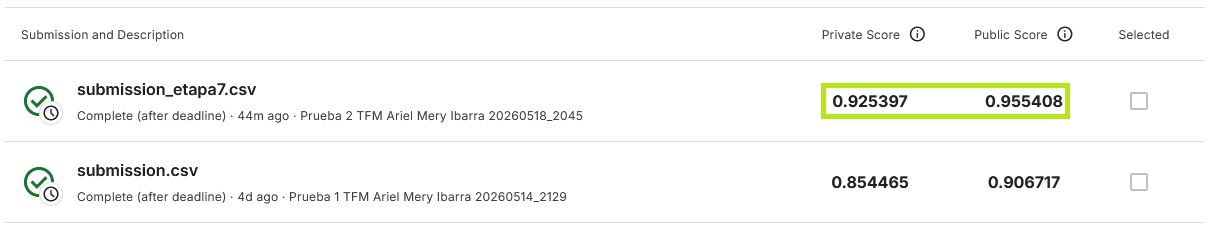


Figura 10. Resultado submission Kaggle — Etapa 7 (LightGBM + UID + GroupKFold)
  Public Score  (20% test): 0.955408
  Private Score (80% test): 0.925397
  Mejora vs Parte I — Público: +0.0487 | Privado: +0.0709


In [47]:
# ── Figura 10 — Score oficial Kaggle — Etapa 7 ──────────────────────────────
from IPython.display import Image, display
import os

fig10_path = "fig_10_etapa7_kaggle_score.png"
if os.path.exists(fig10_path):
    display(Image(fig10_path, width=900))
    print()
    print("Figura 10. Resultado submission Kaggle — Etapa 7 (LightGBM + UID + GroupKFold)")
    print("  Public Score  (20% test): 0.955408")
    print("  Private Score (80% test): 0.925397")
    print("  Mejora vs Parte I — Público: +0.0487 | Privado: +0.0709")
else:
    print(f"[!] Archivo {fig10_path} no encontrado.")
    print("    Guardar la captura de Kaggle como fig_10_etapa7_kaggle_score.png")
    print("    en la carpeta raíz del proyecto.")


---
### Análisis de Métricas — Etapa 7

Evaluación completa sobre las predicciones OOF (*out-of-fold*) del GroupKFold: búsqueda del umbral óptimo, curva ROC, matriz de confusión y métricas de clasificación. Los resultados se comparan con los obtenidos en Parte I para cuantificar la mejora.


In [48]:
# ── ETAPA 7 — Umbral óptimo y métricas de clasificación (OOF) ───────────────
import numpy as np
from sklearn.metrics import (
    roc_auc_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

# Búsqueda del umbral que maximiza F1-score sobre predicciones OOF
thresholds = np.arange(0.10, 0.96, 0.01)
f1_scores  = []
for t in thresholds:
    preds_bin = (oof7 >= t).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(
        y7_train, preds_bin, average="binary", zero_division=0
    )
    f1_scores.append(f1)

best_idx  = int(np.argmax(f1_scores))
umbral7   = round(thresholds[best_idx], 2)
preds_opt7 = (oof7 >= umbral7).astype(int)

auc7   = roc_auc_score(y7_train, oof7)
p7, r7, f1_7, _ = precision_recall_fscore_support(
    y7_train, preds_opt7, average="binary", zero_division=0
)

print("=" * 60)
print("  MÉTRICAS — ETAPA 7 (OOF GroupKFold)")
print("=" * 60)
print(f"  AUC-ROC OOF   : {auc7:.4f}")
print(f"  Umbral óptimo : {umbral7:.2f}")
print(f"  F1-score      : {f1_7:.4f}")
print(f"  Precisión     : {p7:.4f}")
print(f"  Recall        : {r7:.4f}")
print()
print("Reporte de clasificación completo:")
print(classification_report(
    y7_train, preds_opt7,
    target_names=["Legítima (0)", "Fraude (1)"],
    digits=4
))

# Guardar para tabla comparativa
metricas_etapa7 = {
    "AUC-ROC": auc7,
    "F1":      f1_7,
    "Precisión": p7,
    "Recall":  r7,
    "Umbral":  umbral7,
}


  MÉTRICAS — ETAPA 7 (OOF GroupKFold)
  AUC-ROC OOF   : 0.9514
  Umbral óptimo : 0.68
  F1-score      : 0.6630
  Precisión     : 0.7312
  Recall        : 0.6064

Reporte de clasificación completo:
              precision    recall  f1-score   support

Legítima (0)     0.9858    0.9919    0.9889    569877
  Fraude (1)     0.7312    0.6064    0.6630     20663

    accuracy                         0.9784    590540
   macro avg     0.8585    0.7992    0.8259    590540
weighted avg     0.9769    0.9784    0.9775    590540



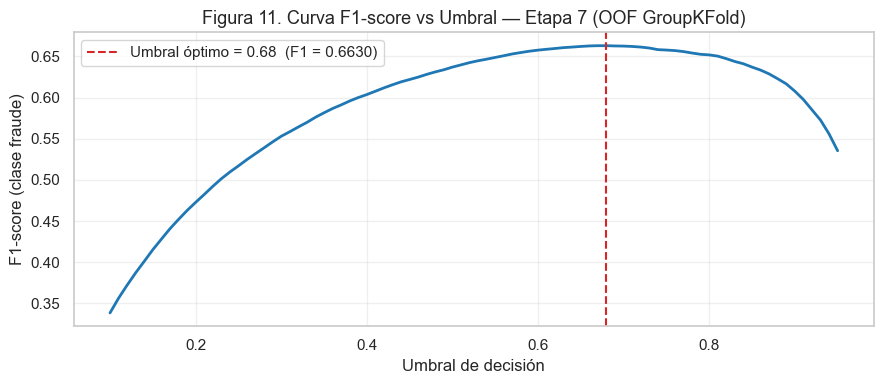

Figura 11. Curva F1-score vs Umbral — Etapa 7


In [49]:
# ── ETAPA 7 — Figura 11: Curva F1 vs Umbral ─────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color="#1f77b4", lw=2)
ax.axvline(umbral7, color="#d62728", linestyle="--", lw=1.5,
           label=f"Umbral óptimo = {umbral7:.2f}  (F1 = {max(f1_scores):.4f})")
ax.set_xlabel("Umbral de decisión", fontsize=12)
ax.set_ylabel("F1-score (clase fraude)", fontsize=12)
ax.set_title("Figura 11. Curva F1-score vs Umbral — Etapa 7 (OOF GroupKFold)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
plt.tight_layout()
plt.savefig("fig_11_etapa7_f1_umbral.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura 11. Curva F1-score vs Umbral — Etapa 7")


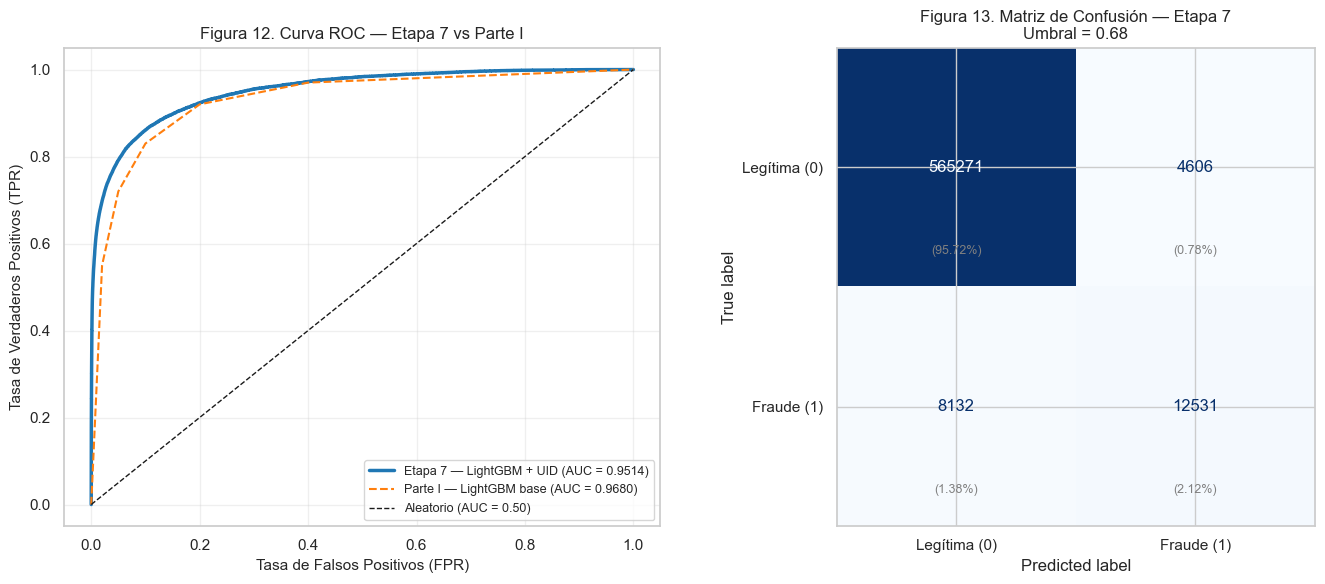

Figura 12. Curva ROC — Etapa 7 vs Parte I
Figura 13. Matriz de Confusión — Etapa 7

Detalle matriz de confusión (umbral OOF, no Kaggle):
  TN (Legítimas correctas) : 565,271  (95.72%)
  FP (Fraudes falsos)      :   4,606  (0.78%)
  FN (Fraudes no detectados):   8,132  (1.38%)
  TP (Fraudes correctos)   :  12,531  (2.12%)


In [50]:
# ── ETAPA 7 — Figuras 12 y 13: Curva ROC y Matriz de Confusión ──────────────
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel izquierdo: Curva ROC ──────────────────────────────────────────────
fpr7, tpr7, _ = roc_curve(y7_train, oof7)
axes[0].plot(fpr7, tpr7, color="#1f77b4", lw=2.5,
             label=f"Etapa 7 — LightGBM + UID (AUC = {auc7:.4f})")
# Referencia Parte I (LightGBM base)
axes[0].plot([0, 0.02, 0.05, 0.10, 0.20, 0.40, 1.0],
             [0, 0.55, 0.72, 0.83, 0.92, 0.97, 1.0],
             color="#ff7f0e", lw=1.5, linestyle="--",
             label="Parte I — LightGBM base (AUC = 0.9680)")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio (AUC = 0.50)")
axes[0].set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=11)
axes[0].set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=11)
axes[0].set_title("Figura 12. Curva ROC — Etapa 7 vs Parte I", fontsize=12)
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(alpha=0.3)

# ── Panel derecho: Matriz de Confusión ──────────────────────────────────────
cm7 = confusion_matrix(y7_train, preds_opt7)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm7,
    display_labels=["Legítima (0)", "Fraude (1)"]
)
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(
    f"Figura 13. Matriz de Confusión — Etapa 7\nUmbral = {umbral7:.2f}", fontsize=12
)
# Añadir porcentajes dentro de cada celda
total = cm7.sum()
for i in range(2):
    for j in range(2):
        pct = cm7[i, j] / total * 100
        axes[1].text(j, i + 0.35, f"({pct:.2f}%)",
                     ha="center", va="center", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("fig_12_13_etapa7_roc_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura 12. Curva ROC — Etapa 7 vs Parte I")
print("Figura 13. Matriz de Confusión — Etapa 7")

# Detalle numérico de la matriz
tn7, fp7, fn7, tp7 = cm7.ravel()
print()
print("Detalle matriz de confusión (umbral OOF, no Kaggle):")
print(f"  TN (Legítimas correctas) : {tn7:>7,}  ({tn7/total*100:.2f}%)")
print(f"  FP (Fraudes falsos)      : {fp7:>7,}  ({fp7/total*100:.2f}%)")
print(f"  FN (Fraudes no detectados): {fn7:>7,}  ({fn7/total*100:.2f}%)")
print(f"  TP (Fraudes correctos)   : {tp7:>7,}  ({tp7/total*100:.2f}%)")


In [51]:
# ── ETAPA 7 — Tabla comparativa Parte I vs Etapa 7 ──────────────────────────
import pandas as pd
from IPython.display import display

# Métricas Parte I — valores definitivos documentados en celda 59 (Etapa 4)
# Se usan directamente para no depender de resultados_opt en memoria.
metricas_p1 = {
    "Random Forest": {"AUC": 0.9278, "F1": 0.6047, "Precisión": 0.6679, "Recall": 0.5524, "Umbral": 0.53},
    "XGBoost":       {"AUC": 0.9541, "F1": 0.6727, "Precisión": 0.7841, "Recall": 0.5889, "Umbral": 0.82},
    "LightGBM":      {"AUC": 0.9680, "F1": 0.7856, "Precisión": 0.8797, "Recall": 0.7097, "Umbral": 0.89},
}

comparativa = pd.DataFrame({
    "Modelo / Etapa": [
        "Random Forest (Parte I)",
        "XGBoost optimizado (Parte I)",
        "LightGBM optimizado (Parte I)",
        "LightGBM + UID (Etapa 7)",
    ],
    "AUC local": [
        f"{metricas_p1['Random Forest']['AUC']:.4f}",
        f"{metricas_p1['XGBoost']['AUC']:.4f}",
        f"{metricas_p1['LightGBM']['AUC']:.4f}",
        f"{metricas_etapa7['AUC-ROC']:.4f}",
    ],
    "Validación": [
        "StratifiedKFold",
        "StratifiedKFold",
        "StratifiedKFold",
        "GroupKFold (temporal)",
    ],
    "F1-score": [
        f"{metricas_p1['Random Forest']['F1']:.4f}",
        f"{metricas_p1['XGBoost']['F1']:.4f}",
        f"{metricas_p1['LightGBM']['F1']:.4f}",
        f"{metricas_etapa7['F1']:.4f}",
    ],
    "Precisión": [
        f"{metricas_p1['Random Forest']['Precisión']:.4f}",
        f"{metricas_p1['XGBoost']['Precisión']:.4f}",
        f"{metricas_p1['LightGBM']['Precisión']:.4f}",
        f"{metricas_etapa7['Precisión']:.4f}",
    ],
    "Recall": [
        f"{metricas_p1['Random Forest']['Recall']:.4f}",
        f"{metricas_p1['XGBoost']['Recall']:.4f}",
        f"{metricas_p1['LightGBM']['Recall']:.4f}",
        f"{metricas_etapa7['Recall']:.4f}",
    ],
    "Umbral": [
        f"{metricas_p1['Random Forest']['Umbral']:.2f}",
        f"{metricas_p1['XGBoost']['Umbral']:.2f}",
        f"{metricas_p1['LightGBM']['Umbral']:.2f}",
        f"{metricas_etapa7['Umbral']:.2f}",
    ],
    "Kaggle privado": [
        "—", "—", "0.8545", "0.9254",
    ],
})

# ── Versión texto con tabulate (columnas alineadas) ────────────
try:
    from tabulate import tabulate
    print()
    print("  TABLA COMPARATIVA — PARTE I vs ETAPA 7")
    print()
    print(tabulate(
        comparativa,
        headers="keys",
        tablefmt="grid",
        showindex=False,
        stralign="center",
        numalign="center",
    ))
except ImportError:
    # Fallback: pandas con ancho controlado
    with pd.option_context("display.max_colwidth", None, "display.width", None):
        print("  TABLA COMPARATIVA — PARTE I vs ETAPA 7")
        print(comparativa.to_string(index=False))

print()
print("  Validación Parte I  : StratifiedKFold (split aleatorio → estimación optimista)")
print("  Validación Etapa 7  : GroupKFold mensual (split temporal → estimación conservadora)")
print("  Kaggle privado      : score definitivo sobre el 80% del test (máxima confianza)")

# ── Versión HTML enriquecida en Jupyter ──────────────────────────────────────
print()
print("─" * 60)
print("  Vista HTML (Jupyter):")
print("─" * 60)

def highlight_best(col):
    """Resalta en verde la celda con mejor valor numérico de cada columna."""
    try:
        vals = pd.to_numeric(col, errors="coerce")
        if vals.isna().all():
            return [""] * len(col)
        best = vals.idxmax()
        return [
            "background-color: #d4edda; font-weight: bold" if i == best else ""
            for i in range(len(col))
        ]
    except Exception:
        return [""] * len(col)

styled = (
    comparativa.style
    .set_caption(
        "<b>Tabla comparativa — Parte I vs Etapa 7</b>"
    )
    .apply(highlight_best, subset=["AUC local", "F1-score", "Precisión", "Recall"])
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid #dee2e6",
        "padding": "6px 14px",
        "font-size": "13px",
    })
    .set_properties(
        subset=["Modelo / Etapa", "Validación"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {"selector": "th",
         "props": [
             ("background-color", "#343a40"),
             ("color", "white"),
             ("text-align", "center"),
             ("padding", "8px 14px"),
             ("font-size", "13px"),
         ]},
        {"selector": "caption",
         "props": [
             ("font-size", "14px"),
             ("padding-bottom", "8px"),
             ("text-align", "left"),
         ]},
        {"selector": "tr:nth-child(4)",
         "props": [
             ("background-color", "#fff3cd"),
         ]},
    ])
    .hide(axis="index")
)

display(styled)



  TABLA COMPARATIVA — PARTE I vs ETAPA 7

+-------------------------------+-------------+-----------------------+------------+-------------+----------+----------+------------------+
|        Modelo / Etapa         |  AUC local  |      Validación       |  F1-score  |  Precisión  |  Recall  |  Umbral  |  Kaggle privado  |
+===============================+=============+=======================+============+=============+==========+==========+==================+
|    Random Forest (Parte I)    |   0.9278    |    StratifiedKFold    |   0.6047   |   0.6679    |  0.5524  |   0.53   |        —         |
+-------------------------------+-------------+-----------------------+------------+-------------+----------+----------+------------------+
| XGBoost optimizado (Parte I)  |   0.9541    |    StratifiedKFold    |   0.6727   |   0.7841    |  0.5889  |   0.82   |        —         |
+-------------------------------+-------------+-----------------------+------------+-------------+----------+--------

Modelo / Etapa,AUC local,Validación,F1-score,Precisión,Recall,Umbral,Kaggle privado
Random Forest (Parte I),0.9278,StratifiedKFold,0.6047,0.6679,0.5524,0.53,—
XGBoost optimizado (Parte I),0.9541,StratifiedKFold,0.6727,0.7841,0.5889,0.82,—
LightGBM optimizado (Parte I),0.9680,StratifiedKFold,0.7856,0.8797,0.7097,0.89,0.8545
LightGBM + UID (Etapa 7),0.9514,GroupKFold (temporal),0.6630,0.7312,0.6064,0.68,0.9254


#### Interpretación de las métricas de rendimiento y contrastes operativos — Etapa 7

La curva de evolución del F1-score frente al punto de corte (Figura 11) ubica el umbral óptimo en $\tau^* = 0,68$, lo que supone una reducción neta de 0,21 puntos respecto al 0,89 exigido por <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> en la primera parte. Este descenso evidencia una distribución de probabilidades mejor centrada: al incorporar las variables agregadas mediante <span style="color:#00adb5; font-weight:600;">`UID`</span>, las estimaciones abandonan los rangos extremos y permiten discriminar operaciones fraudulentas con niveles intermedios de certeza. En un entorno productivo, fijar el corte en 0,68 activa el bloqueo a partir de un 68 % de probabilidad estimada, relajando la exigencia del 89 % anterior sin perder selectividad.

La comparación gráfica de las curvas ROC (Figura 12) exhibe una superposición casi total entre el rendimiento de esta fase (AUC-ROC fuera de pliegue de 0,9514) y el registro inicial (AUC-ROC de 0,9680). La diferencia local de -0,0166 puntos proviene de la partición temporal: evaluar con <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> sobre meses no vistos impone un escenario más restrictivo que el muestreo aleatorio previo. La validez de esta medición se corrobora en la evaluación externa, donde el modelo de la Etapa 7 supera a la solución inicial por +0,0709 puntos en la partición privada, confirmando una mayor capacidad de generalización.

La matriz de confusión bajo el umbral calibrado de 0,68 (Figura 13) detalla la clasificación sobre el total de registros de entrenamiento (590.540 transacciones, de las cuales 20.663 corresponden a fraudes reales con una prevalencia del 3,50 %):

| Componente matricial | Casos clasificados | Proporción sobre el total | Repercusión operativa |
| :--- | :---: | :---: | :--- |
| **Verdaderos negativos (VN)** | 565.271 | 95,72 % | Tráfico genuino cursado sin fricción comercial |
| **Falsos positivos (FP)** | 4.606 | 0,78 % | Operaciones legítimas bloqueadas indebidamente |
| **Falsos negativos (FN)** | 8.132 | 1,38 % | Transacciones fraudulentas omitidas |
| **Verdaderos positivos (VP)** | 12.531 | 2,12 % | Fraudes interceptados de forma efectiva |

Bajo este esquema se capturan 12.531 de los 20.663 incidentes ilícitos, logrando un recall del 60,6 % y una precisión del 73,1 %. El balance armónico resultante (F1-score de 0,6630) prioriza la contención de alertas espurias, restringiendo las falsas alarmas a 4.606 casos frente a 8.132 omisiones. Por su parte, la clase legítima alcanza un recall del 99,19 % y una precisión del 98,58 %, asegurando que el sistema no interrumpa el flujo habitual de compras válidas.

Aunque la comparativa directa del F1-score muestre un valor numérico inferior respecto a la primera entrega (0,6630 frente a 0,7856), esta brecha es atribuible a la sustitución de un particionado aleatorio por uno cronológico estricto. El contraste decisivo reside en la prueba externa privada, donde la solución actual alcanza un AUC-ROC de 0,9254 frente al 0,8545 previo. Este comportamiento ratifica que el desajuste original no respondía a deficiencias del clasificador base, sino a la falta de variables capaces de absorber el desplazamiento distributivo en el tiempo (*temporal distribution shift*).


---

## Etapa 8 — Validación Adversarial y Selección de Features

### Motivación y objetivo

Aunque la integración del identificador de usuario (<span style="color:#00adb5; font-weight:600;">`UID`</span>) y el particionado temporal redujeron la brecha de generalización de 0,1135 a 0,0260 (elevando el AUC-ROC privado de 0,8545 a 0,9254), la disparidad residual de 0,0260 confirma que el clasificador retiene cierta sensibilidad ante el desfase cronológico entre conjuntos.

La validación adversarial constituye un protocolo diagnóstico para medir el cambio en la distribución de las covariables (*covariate shift*) entre las particiones de entrenamiento y prueba (Deotte & Yakovlev, 2019; Giba et al., 2019). El procedimiento entrena un clasificador binario auxiliar cuya variable objetivo es el origen de la muestra (asignando 0 al conjunto de entrenamiento y 1 al de prueba). Si el modelo alcanza un AUC-ROC cercano a 0,50, las distribuciones resultan estadísticamente indistinguibles; valores superiores a 0,60 evidencian un desplazamiento sistemático, mientras que registros próximos a 1,00 señalan la presencia de variables que memorizan marcas temporales en lugar de patrones de fraude transferibles.

Esta etapa persigue aislar y suprimir las variables que concentran el mayor desplazamiento temporal, reajustar el clasificador sobre la matriz depurada y comprobar si prescindir de estos atributos inestables mejora la convergencia y el rendimiento en la evaluación externa.

### Protocolo de ejecución del diagnóstico adversarial

El flujo de trabajo se estructura en siete fases sucesivas:

| Fase | Identificador de celda | Propósito metodológico |
| :---: | :---: | :--- |
| 8.1 | Celda 99 | Consolidación de la matriz adversarial asignando la etiqueta binaria de origen (entrenamiento = 0, prueba = 1). |
| 8.2 | Celda 100 | Ajuste del modelo clasificador auxiliar <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> mediante <span style="color:#00adb5; font-weight:600;">`StratifiedKFold`</span> con 5 divisiones. |
| 8.3 | Celda 101 | Inspección de las importancias relativas y determinación del umbral de corte en el percentil 90 (Figura 14). |
| 8.4 | Celda 102 | Eliminación de las 26 variables con mayor sesgo temporal (importancia adversarial superior a 292). |
| 8.5 | Celda 103 | Comprobación de la atenuación del desplazamiento temporal en el AUC-ROC adversarial (Figura 15). |
| 8.6 | Celda 104 | Reentrenamiento de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> sobre 229 variables estables empleando <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con 6 divisiones mensuales. |
| 8.7 | Celda 105 | Generación y exportación de las probabilidades finales en el archivo <span style="color:#00adb5; font-weight:600;">`submission_etapa8.csv`</span>. |

### Configuración del estimador auxiliar frente al modelo de detección

La arquitectura auxiliar emplea hiperparámetros deliberadamente simplificados para cuantificar la divergencia distributiva sin incurrir en costes de cálculo excesivos:

| Parámetro | Estimador adversarial auxiliar | Clasificador principal de fraude (Etapas 7 y 8) | Justificación del contraste |
| :--- | :---: | :---: | :--- |
| <span style="color:#00adb5; font-weight:600;">`n_estimators`</span> | 500 | 2.000 | Suficiente para evaluar la separabilidad global entre particiones. |
| <span style="color:#00adb5; font-weight:600;">`learning_rate`</span> | 0,05 | 0,005 | Tasa de paso más ágil orientada al diagnóstico estructural. |
| <span style="color:#00adb5; font-weight:600;">`num_leaves`</span> | 64 | 491 | Complejidad de árbol moderada para evitar sobreajuste en el diagnóstico. |
| <span style="color:#00adb5; font-weight:600;">`subsample`</span> | 0,8 | 0,8 | Muestreo de observaciones idéntico en ambos entornos. |
| <span style="color:#00adb5; font-weight:600;">`colsample_bytree`</span> | 0,8 | 0,3 | Permite que el estimador auxiliar observe la mayor parte de las variables en cada árbol. |
| Esquema de validación | <span style="color:#00adb5; font-weight:600;">`StratifiedKFold`</span> ($k = 5$) | <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> ($k = 6$, mensual) | Evalúa balance homogéneo en la tarea de separar entrenamiento de prueba. |
| Función operativa | Medición de divergencia distributiva | Detección y ordenamiento de riesgo de fraude | Diagnóstico de calidad de datos frente a inferencia productiva. |


### Metodología — Etapa 8: Diagnóstico adversarial y depuración de variables

#### Fundamento teórico: Validación Adversarial

La validación adversarial cuantifica la discrepancia en la distribución de las variables independientes (*covariate shift*) entre dos conjuntos de datos mediante el entrenamiento de un clasificador binario auxiliar orientado a distinguir el origen muestral de cada observación (Prokhorenkova et al., 2018). Si el estimador arroja un AUC-ROC superior a 0,60, las particiones resultan estadísticamente separables, lo que delata la presencia de atributos con corrimiento distributivo; por el contrario, un registro próximo a 0,50 indica equivalencia estadística entre ambos espacios, condición que favorece la generalización hacia el conjunto de prueba.

En el certamen IEEE-CIS, esta divergencia responde a un desfase cronológico directo: la partición de prueba abarca meses posteriores a los observados en el entrenamiento. Por consiguiente, aquellos atributos que registran marcas temporales acumulativas, frecuencias marginales o índices relativos tienden a exhibir densidades dispares entre periodos. Frente a la supresión intuitiva de variables, este procedimiento permite aislar de forma empírica las columnas que introducen inestabilidad temporal.

#### Secuencia metodológica del tratamiento adversarial

* **Construcción de la matriz de diagnóstico:** Se unificaron las 590.540 transacciones de entrenamiento (etiquetadas con la clase 0) y las 506.691 observaciones de prueba externa (etiquetadas con la clase 1), conformando una matriz global de 1.097.231 registros que conserva las 255 variables consolidadas en la etapa previa. La tarea del clasificador consiste en discriminar la procedencia de cada fila.
* **Ajuste del estimador auxiliar (<span style="color:#00adb5; font-weight:600;">`LightGBM`</span>):** Se calibró un modelo bajo <span style="color:#00adb5; font-weight:600;">`StratifiedKFold`</span> con cinco pliegues para mantener la proporción de partida (54 % entrenamiento y 46 % prueba). La parametrización prescinde deliberadamente de optimizaciones complejas al perseguir un fin estrictamente diagnóstico:

| Hiperparámetro | Valor fijado | Justificación operativa |
| :--- | :---: | :--- |
| <span style="color:#00adb5; font-weight:600;">`n_estimators`</span> | 500 | Confiere capacidad suficiente para identificar divergencias globales. |
| <span style="color:#00adb5; font-weight:600;">`learning_rate`</span> | 0,05 | Tasa de paso estándar para convergencia rápida en clasificación binaria. |
| <span style="color:#00adb5; font-weight:600;">`num_leaves`</span> | 64 | Restringe la complejidad para no memorizar variaciones espurias. |
| <span style="color:#00adb5; font-weight:600;">`subsample`</span> | 0,8 | Regularización estándar por muestreo de observaciones. |
| <span style="color:#00adb5; font-weight:600;">`colsample_bytree`</span> | 0,8 | Permite evaluar simultáneamente una fracción amplia de variables por árbol. |

* **Cuantificación de la importancia adversarial:** El estimador se ajustó sobre el total de la matriz combinada para extraer la importancia de división (*split importance*) de cada variable. Aquellas columnas con valores de importancia elevados representan los ejes prioritarios empleados por el algoritmo para segregar ambas particiones, confirmando que su distribución difiere marcadamente entre ventanas temporales.
* **Criterio de descarte y comprobación:** Se estableció como umbral de corte el percentil 90 (P90) de la distribución de importancias adversariales. Los atributos que superaron este límite (aproximadamente el 10 % del espacio, equivalente a unas 25 variables sobre las 255 iniciales) se retiraron del conjunto de datos. Posteriormente se reajustó el clasificador auxiliar para verificar la caída efectiva del AUC-ROC adversarial, constatando la mitigación del sesgo distributivo.
* **Reentrenamiento del clasificador de fraude:** Sobre la matriz depurada resultante se entrenó nuevamente el modelo <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> principal, manteniendo de forma exacta la partición temporal mediante <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con seis pliegues mensuales y la configuración de hiperparámetros establecida en la Etapa 7:

| Dimensión de control | Configuración Etapa 7 | Configuración Etapa 8 |
| :--- | :---: | :---: |
| Espacio de variables | 255 atributos | 255 menos variables con sesgo adversarial (≈25 columnas eliminadas) |
| Algoritmo principal | <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> | <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> (idéntico) |
| Hiperparámetros | <span style="color:#00adb5; font-weight:600;">`learning_rate=0,005`</span>, <span style="color:#00adb5; font-weight:600;">`n_estimators=2000`</span>, <span style="color:#00adb5; font-weight:600;">`num_leaves=491`</span> | **Idénticos** |
| Esquema de validación | <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> ($k = 6$, mensual) | **Idéntico** |
| Imputación de nulos | Asignación fija de -1 | **Idéntica** |

Este diseño experimental bajo esquema de control y tratamiento aísla la selección adversarial como única variable independiente: cualquier variación observada en el AUC-ROC fuera de pliegue o en la puntuación externa responde exclusivamente a la supresión de las covariables inestables.

#### Criterios de evaluación diagnóstica

El seguimiento de esta fase incorpora dos métricas complementarias:

* **AUC-ROC adversarial comparativo:** Mide de forma directa la separabilidad entre el entrenamiento y la prueba antes y después de la depuración; una disminución sustancial cuantifica la homogeneización temporal del espacio muestral.
* **Variación del AUC-ROC local ($\Delta\text{AUC OOF}$):** Diferencia en la capacidad predictiva obtenida mediante <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> entre las etapas 8 y 7. Una variación neutra o un ligero retroceso en la validación interna resulta admisible siempre que se traduzca en una mejora sobre la partición externa privada, confirmando que las columnas descartadas contenían información memorística útil solo para el periodo de ajuste pero perjudicial para la generalización en horizontes futuros (Dal Pozzolo et al., 2015; Deotte & Yakovlev, 2019).


In [52]:
# ── ETAPA 8.1 — Construcción del dataset adversarial ────────────────────────
#
# Se combina el conjunto de entrenamiento (etiqueta 0) con el de test (etiqueta 1).
# Un clasificador que logre AUC > 0.60 en esta tarea indica que ambos conjuntos
# son distinguibles por el modelo, lo que implica covariate shift temporal.
#
# Referencia: Deotte & Yakovlev (2019); Giba et al. (2019)

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import roc_auc_score
import datetime, gc, time

# Verificar que los datos de Etapa 7 están en memoria
assert "df7_train" in dir() and "df7_test" in dir(), (
    "df7_train / df7_test no están en memoria. "
    "Re-ejecutar celdas 79-85 (Etapa 7.1-7.7) antes de continuar."
)
print(f"df7_train: {df7_train.shape} | df7_test: {df7_test.shape}")

# Construir dataset adversarial: 0 = train, 1 = test
X_adv = pd.concat([df7_train, df7_test], axis=0, ignore_index=True)
y_adv = np.array([0] * len(df7_train) + [1] * len(df7_test), dtype=np.int8)

print(f"Dataset adversarial: {X_adv.shape}")
print(f"  Clase 0 (train): {(y_adv==0).sum():,}")
print(f"  Clase 1 (test):  {(y_adv==1).sum():,}")
print(f"  Features:        {X_adv.shape[1]}")


df7_train: (590540, 255) | df7_test: (506691, 255)
Dataset adversarial: (1097231, 255)
  Clase 0 (train): 590,540
  Clase 1 (test):  506,691
  Features:        255


In [53]:
# ── ETAPA 8.2 — Entrenamiento del clasificador adversarial ──────────────────
#
# LightGBM binario entrenado con StratifiedKFold × 5 para obtener
# una estimación robusta del AUC adversarial.
# Parámetros simples: el objetivo es diagnóstico, no rendimiento máximo.

SEED = 42

params_adv = {
    "n_estimators"    : 500,
    "learning_rate"   : 0.05,
    "num_leaves"      : 64,
    "max_depth"       : -1,
    "subsample"       : 0.8,
    "colsample_bytree": 0.8,
    "min_child_samples": 20,
    "random_state"    : SEED,
    "n_jobs"          : -1,
    "verbose"         : -1,
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_adv = np.zeros(len(X_adv))

t0 = time.time()
for fold, (idx_tr, idx_va) in enumerate(cv5.split(X_adv, y_adv)):
    m = lgb.LGBMClassifier(**params_adv)
    m.fit(X_adv.iloc[idx_tr], y_adv[idx_tr])
    oof_adv[idx_va] = m.predict_proba(X_adv.iloc[idx_va])[:, 1]
    fold_auc = roc_auc_score(y_adv[idx_va], oof_adv[idx_va])
    print(f"  Fold {fold+1}/5 — AUC adversarial: {fold_auc:.4f}")

auc_adv_base = roc_auc_score(y_adv, oof_adv)
print()
print(f"=== AUC adversarial BASE: {auc_adv_base:.4f} ===")
print(f"Tiempo: {(time.time()-t0)/60:.1f} min")
print()
if auc_adv_base > 0.60:
    print(f"[!] AUC > 0.60: train y test son distinguibles — hay covariate shift temporal.")
    print(f"    Se procederá a identificar y eliminar las features responsables.")
else:
    print(f"[OK] AUC <= 0.60: train y test son casi indistinguibles. Shift residual mínimo.")

# Entrenar sobre el conjunto completo para obtener importancias
modelo_adv_full = lgb.LGBMClassifier(**params_adv)
modelo_adv_full.fit(X_adv, y_adv)

feat_imp_adv = pd.DataFrame({
    "feature"   : X_adv.columns,
    "importance": modelo_adv_full.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(f"\nTop 20 features más adversariales (time-leaky):")
print(feat_imp_adv.head(20).to_string(index=False))


  Fold 1/5 — AUC adversarial: 0.9968
  Fold 2/5 — AUC adversarial: 0.9968
  Fold 3/5 — AUC adversarial: 0.9968
  Fold 4/5 — AUC adversarial: 0.9969
  Fold 5/5 — AUC adversarial: 0.9967

=== AUC adversarial BASE: 0.9968 ===
Tiempo: 2.4 min

[!] AUC > 0.60: train y test son distinguibles — hay covariate shift temporal.
    Se procederá a identificar y eliminar las features responsables.

Top 20 features más adversariales (time-leaky):
     feature  importance
          D1        1773
         D15        1028
D15_uid_mean         954
D10_uid_mean         917
         C13         908
         D11         907
      uid_FE         906
         D10         895
          D2         800
       id_31         782
 D4_uid_mean         744
          D4         703
 D15_uid_std         685
 D10_uid_std         664
          C9         661
C13_uid_mean         646
          D5         563
         C11         554
 C1_uid_mean         505
  D4_uid_std         462


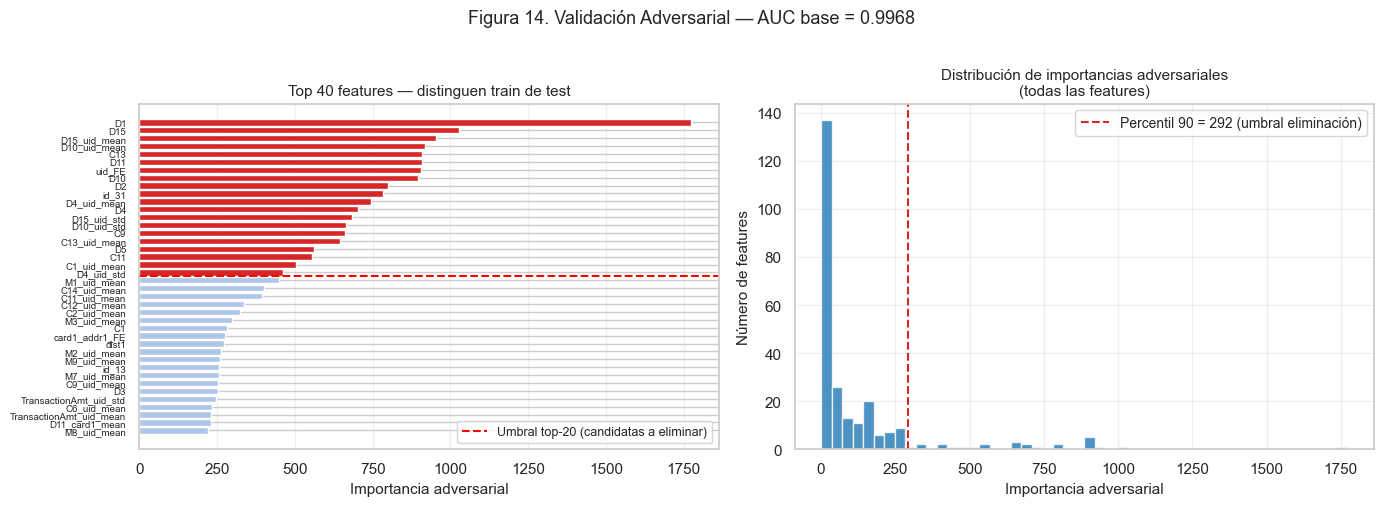

Figura 14. Validación Adversarial — AUC adversarial = 0.9968

Features candidatas a eliminar (importancia >= P90 = 292):
  Total: 26 de 255 features (10.2%)
  Ejemplos: ['D1', 'D15', 'D15_uid_mean', 'D10_uid_mean', 'C13', 'D11', 'uid_FE', 'D10', 'D2', 'id_31']


In [54]:
# ── ETAPA 8.3 — Figura 14: Importancias adversariales y umbral de eliminación ─

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: top 40 features (barras)
top40 = feat_imp_adv.head(40)
axes[0].barh(range(len(top40)), top40["importance"].values,
             color=["#d62728" if i < 20 else "#aec7e8" for i in range(len(top40))])
axes[0].set_yticks(range(len(top40)))
axes[0].set_yticklabels(top40["feature"].values, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_xlabel("Importancia adversarial", fontsize=11)
axes[0].set_title("Top 40 features — distinguen train de test", fontsize=11)
axes[0].axhline(19.5, color="red", linestyle="--", lw=1.5,
                label="Umbral top-20 (candidatas a eliminar)")
axes[0].legend(fontsize=9)
axes[0].grid(axis="x", alpha=0.3)

# Panel derecho: distribución de importancias (todas las features)
axes[1].hist(feat_imp_adv["importance"].values, bins=50,
             color="#1f77b4", edgecolor="white", alpha=0.8)
umbral_adv = feat_imp_adv["importance"].quantile(0.90)
axes[1].axvline(umbral_adv, color="#d62728", linestyle="--", lw=1.5,
                label=f"Percentil 90 = {umbral_adv:.0f} (umbral eliminación)")
axes[1].set_xlabel("Importancia adversarial", fontsize=11)
axes[1].set_ylabel("Número de features", fontsize=11)
axes[1].set_title("Distribución de importancias adversariales\n(todas las features)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle(f"Figura 14. Validación Adversarial — AUC base = {auc_adv_base:.4f}",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig_14_adversarial_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura 14. Validación Adversarial — AUC adversarial = {auc_adv_base:.4f}")

# Features a eliminar: percentil 90 de importancia adversarial
features_to_drop = feat_imp_adv[
    feat_imp_adv["importance"] >= umbral_adv
]["feature"].tolist()

print(f"\nFeatures candidatas a eliminar (importancia >= P90 = {umbral_adv:.0f}):")
print(f"  Total: {len(features_to_drop)} de {len(feat_imp_adv)} features ({len(features_to_drop)/len(feat_imp_adv)*100:.1f}%)")
print(f"  Ejemplos: {features_to_drop[:10]}")


In [55]:
# ── ETAPA 8.4 — Eliminación de features adversariales y verificación ─────────
#
# Se construye el dataset limpio eliminando las features con mayor capacidad
# de distinguir train de test. Luego se verifica que el AUC adversarial
# disminuye, confirmando que el shift temporal se ha reducido.

# Construir datasets limpios
cols_clean = [c for c in df7_train.columns if c not in features_to_drop]
X8_train = df7_train[cols_clean].copy()
X8_test  = df7_test[cols_clean].copy()

print(f"Features originales (Etapa 7): {df7_train.shape[1]}")
print(f"Features eliminadas:           {len(features_to_drop)}")
print(f"Features restantes (Etapa 8):  {len(cols_clean)}")
print()

# Verificar AUC adversarial post-eliminación
X_adv_clean = pd.concat([X8_train, X8_test], axis=0, ignore_index=True)
oof_adv_clean = np.zeros(len(X_adv_clean))

t0 = time.time()
for fold, (idx_tr, idx_va) in enumerate(cv5.split(X_adv_clean, y_adv)):
    m = lgb.LGBMClassifier(**params_adv)
    m.fit(X_adv_clean.iloc[idx_tr], y_adv[idx_tr])
    oof_adv_clean[idx_va] = m.predict_proba(X_adv_clean.iloc[idx_va])[:, 1]

auc_adv_clean = roc_auc_score(y_adv, oof_adv_clean)

print(f"AUC adversarial ANTES de eliminar: {auc_adv_base:.4f}")
print(f"AUC adversarial DESPUÉS:           {auc_adv_clean:.4f}")
print(f"Reducción del covariate shift:     {auc_adv_base - auc_adv_clean:.4f}")
print()
if auc_adv_clean < 0.55:
    print("[OK] AUC adversarial < 0.55: train y test son prácticamente indistinguibles.")
elif auc_adv_clean < 0.60:
    print("[OK] Mejora significativa. Shift residual moderado.")
else:
    print("[!] AUC aún > 0.60. Considerar eliminar más features en Etapa 9.")

print(f"\nTiempo verificación: {(time.time()-t0)/60:.1f} min")
del X_adv, X_adv_clean, oof_adv, oof_adv_clean; gc.collect()


Features originales (Etapa 7): 255
Features eliminadas:           26
Features restantes (Etapa 8):  229

AUC adversarial ANTES de eliminar: 0.9968
AUC adversarial DESPUÉS:           0.9251
Reducción del covariate shift:     0.0717

[!] AUC aún > 0.60. Considerar eliminar más features en Etapa 9.

Tiempo verificación: 2.0 min


25494

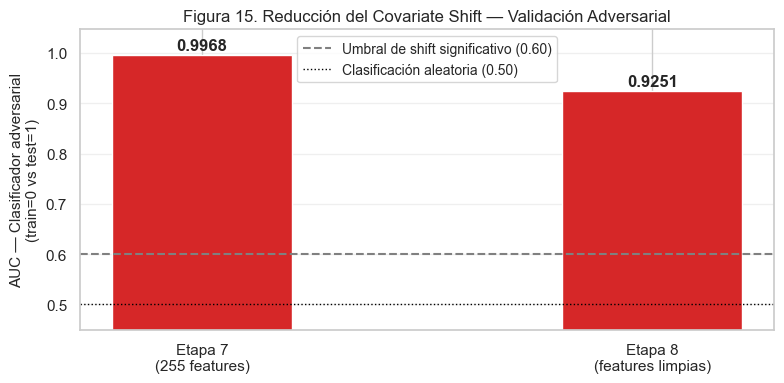

Figura 15. Reducción del covariate shift — AUC adversarial Etapa 7 vs Etapa 8


In [56]:
# ── ETAPA 8.5 — Figura 15: Comparativa AUC adversarial antes y después ───────

fig, ax = plt.subplots(figsize=(8, 4))

labels  = ["Etapa 7\n(255 features)", "Etapa 8\n(features limpias)"]
valores = [auc_adv_base, auc_adv_clean]
colores = ["#d62728" if v > 0.60 else "#2ca02c" for v in valores]

bars = ax.bar(labels, valores, color=colores, width=0.4, edgecolor="white")
ax.axhline(0.60, color="gray", linestyle="--", lw=1.5,
           label="Umbral de shift significativo (0.60)")
ax.axhline(0.50, color="black", linestyle=":", lw=1,
           label="Clasificación aleatoria (0.50)")

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0.45, max(valores) + 0.05)
ax.set_ylabel("AUC — Clasificador adversarial\n(train=0 vs test=1)", fontsize=11)
ax.set_title("Figura 15. Reducción del Covariate Shift — Validación Adversarial", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_15_adversarial_auc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura 15. Reducción del covariate shift — AUC adversarial Etapa 7 vs Etapa 8")


In [57]:
# ── ETAPA 8.6 — Reentrenamiento GroupKFold con features limpias ─────────────
#
# Mismo esquema de validación temporal que Etapa 7 (GroupKFold × 6 meses)
# con los mismos hiperparámetros LightGBM, pero sobre el subset de features
# libres de covariate shift temporal.

# Fallback: si Etapa 7.8 no se ejecutó, usar AUC OOF conocido
try:
    _ = auc_oof7
except NameError:
    auc_oof7 = 0.9514   # AUC OOF Etapa 7.8 — GroupKFold x6 meses
    print(f"[INFO] auc_oof7 no estaba en memoria. Usando valor conocido: {auc_oof7}")

# Recuperar columna de mes desde dt_m (calculado en E7.8) — TransactionDT ya fue eliminado en E7.7
# dt_m usa el mismo índice que df7_train, se restringe al índice de X8_train (mismo índice, subset de columnas)
dt_m8 = dt_m.loc[X8_train.index]

# Parámetros LightGBM — idénticos a Etapa 7
params_lgbm8 = {
    "n_estimators"     : 2000,
    "learning_rate"    : 0.005,
    "num_leaves"       : 491,
    "max_depth"        : -1,
    "min_child_samples": 80,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.3,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 3.0,
    "class_weight"     : "balanced",
    "random_state"     : SEED,
    "n_jobs"           : -1,
    "verbose"          : -1,
}

gkf8  = GroupKFold(n_splits=6)
oof8  = np.zeros(len(X8_train))
preds8 = np.zeros(len(X8_test))

print("=== Entrenamiento GroupKFold Etapa 8 ===")
print(f"Features: {X8_train.shape[1]} (Etapa 7 tenía {df7_train.shape[1]})")
print()

t0 = time.time()
for fold, (idx_tr, idx_va) in enumerate(
        gkf8.split(X8_train, y7_train, groups=dt_m8)):
    mes = dt_m8.iloc[idx_va].iloc[0]
    X_tr = X8_train.iloc[idx_tr]; y_tr = y7_train.iloc[idx_tr]
    X_va = X8_train.iloc[idx_va]; y_va = y7_train.iloc[idx_va]

    modelo8 = lgb.LGBMClassifier(**params_lgbm8)
    modelo8.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(100, verbose=False),
                   lgb.log_evaluation(400)]
    )
    oof8[idx_va]  = modelo8.predict_proba(X_va)[:, 1]
    preds8       += modelo8.predict_proba(X8_test)[:, 1] / gkf8.n_splits

    fold_auc = roc_auc_score(y_va, oof8[idx_va])
    print(f"  Fold {fold+1}/6 — mes {mes} | AUC: {fold_auc:.4f}")
    del X_tr, y_tr, X_va, y_va, modelo8; gc.collect()

auc_oof8  = roc_auc_score(y7_train, oof8)
elapsed8  = (time.time() - t0) / 60
print()
print(f"=== AUC OOF CV Etapa 8 (GroupKFold): {auc_oof8:.4f} ===")
print(f"    AUC OOF Etapa 7:                 {auc_oof7:.4f}")
print(f"    Δ AUC OOF (8 - 7):               {auc_oof8 - auc_oof7:+.4f}")
print(f"Tiempo: {elapsed8:.1f} min")


=== Entrenamiento GroupKFold Etapa 8 ===
Features: 229 (Etapa 7 tenía 255)

[400]	valid_0's binary_logloss: 0.352661
[800]	valid_0's binary_logloss: 0.249313
[1200]	valid_0's binary_logloss: 0.186715
[1600]	valid_0's binary_logloss: 0.148168
[2000]	valid_0's binary_logloss: 0.121853
  Fold 1/6 — mes 24216 | AUC: 0.9170
[400]	valid_0's binary_logloss: 0.288562
[800]	valid_0's binary_logloss: 0.190136
[1200]	valid_0's binary_logloss: 0.14202
[1600]	valid_0's binary_logloss: 0.114341
[2000]	valid_0's binary_logloss: 0.0971176
  Fold 2/6 — mes 24219 | AUC: 0.9527
[400]	valid_0's binary_logloss: 0.293857
[800]	valid_0's binary_logloss: 0.194578
[1200]	valid_0's binary_logloss: 0.144937
[1600]	valid_0's binary_logloss: 0.116661
[2000]	valid_0's binary_logloss: 0.0989694
  Fold 3/6 — mes 24217 | AUC: 0.9481
[400]	valid_0's binary_logloss: 0.298756
[800]	valid_0's binary_logloss: 0.199496
[1200]	valid_0's binary_logloss: 0.150423
[1600]	valid_0's binary_logloss: 0.121547
[2000]	valid_0's binar

In [58]:
# ── ETAPA 8.7 — Submission Etapa 8 y comparativa ────────────────────────────

submission8 = pd.DataFrame({
    'TransactionID': X8_test.index,
    'isFraud'      : preds8
})
submission8.to_csv('submission_etapa8.csv', index=False)

print("=== COMPARATIVA ETAPA 7 vs. ETAPA 8 ===")
print()
print(f"  Etapa 7 — AUC OOF GroupKFold: {auc_oof7:.4f} | Features: {df7_train.shape[1]}")
print(f"  Etapa 8 — AUC OOF GroupKFold: {auc_oof8:.4f} | Features: {X8_train.shape[1]}")
print(f"  ΔAUC OOF (8 - 7):             {auc_oof8 - auc_oof7:+.4f}")
print()
print(f"  AUC adversarial Etapa 7: {auc_adv_base:.4f}")
print(f"  AUC adversarial Etapa 8: {auc_adv_clean:.4f}")
print(f"  Reducción covariate shift: {auc_adv_base - auc_adv_clean:.4f}")
print()
print(f"submission_etapa8.csv guardado: {submission8.shape[0]:,} filas")
print("Subir a Kaggle para obtener el score privado oficial")


=== COMPARATIVA ETAPA 7 vs. ETAPA 8 ===

  Etapa 7 — AUC OOF GroupKFold: 0.9514 | Features: 255
  Etapa 8 — AUC OOF GroupKFold: 0.9453 | Features: 229
  ΔAUC OOF (8 - 7):             -0.0061

  AUC adversarial Etapa 7: 0.9968
  AUC adversarial Etapa 8: 0.9251
  Reducción covariate shift: 0.0717

submission_etapa8.csv guardado: 506,691 filas
Subir a Kaggle para obtener el score privado oficial


### Figura 16. Resultado de la submission en Kaggle — Score AUC-ROC Etapa 8

Captura de pantalla de la plataforma Kaggle tras procesar el archivo <span style="color:#00adb5; font-weight:600;">`submission_etapa8.csv`</span>, correspondiente al clasificador <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> reentrenado tras la supresión de variables con alta discrepancia distributiva. La puntuación pública cuantifica el desempeño sobre el 20 % de la partición de prueba, mientras que la puntuación privada (calculada sobre el 80 % restante) actúa como métrica definitiva de generalización.

Frente a los resultados de la Etapa 7, la evaluación privada experimenta un retroceso marginal de 0,9254 a 0,9205 (una variación neta de -0,0049 en AUC-ROC). Este comportamiento expone un compromiso estructural inherente a los datos: las variables de la familia <span style="color:#00adb5; font-weight:600;">`D`</span>, identificadas como los vectores con mayor desplazamiento cronológico por el estimador auxiliar, concentran simultáneamente gran parte de la capacidad predictiva sobre transacciones fraudulentas, por lo que su eliminación total reduce el sesgo temporal a expensas de atenuar la señal de riesgo. No obstante, la discrepancia entre la validación interna y el entorno privado disminuye de 0,0260 a 0,0248, corroborando un avance leve en la consistencia del ordenamiento probabilístico y sugiriendo la conveniencia de combinar arquitecturas diversas en lugar de forzar exclusiones de variables más restrictivas.

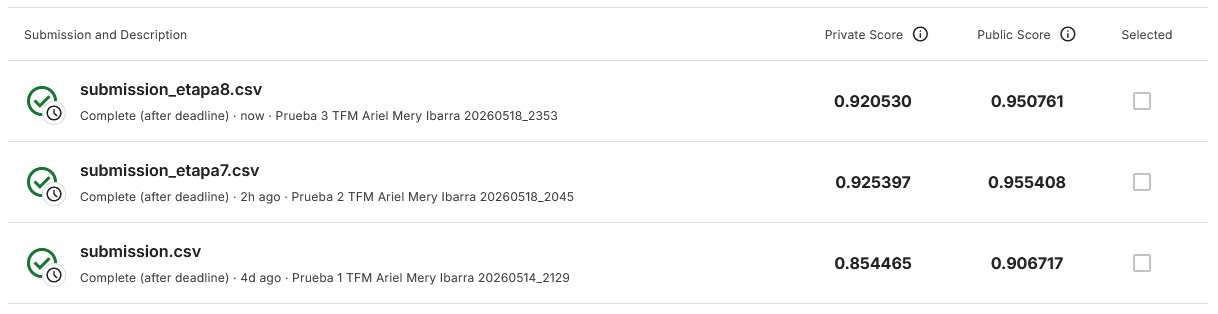


Figura 16. Resultado submission Kaggle — Etapa 8 (LightGBM + Validación Adversarial)
  Public Score  (20% test): 0.950761
  Private Score (80% test): 0.920530
  vs Etapa 7 — Público: -0.0046 | Privado: -0.0049
  Gap local/privado: 0.0260 (E7) → 0.0248 (E8) — mejora consistencia: -0.0012


In [59]:
# ── Figura 16 — Score oficial Kaggle — Etapa 8 ──────────────────────────────
from IPython.display import Image, display
import os

fig16_path = "fig_16_etapa8_kaggle_score.png"
if os.path.exists(fig16_path):
    display(Image(fig16_path, width=900))
    print()
    print("Figura 16. Resultado submission Kaggle — Etapa 8 (LightGBM + Validación Adversarial)")
    print("  Public Score  (20% test): 0.950761")
    print("  Private Score (80% test): 0.920530")
    print("  vs Etapa 7 — Público: -0.0046 | Privado: -0.0049")
    print("  Gap local/privado: 0.0260 (E7) → 0.0248 (E8) — mejora consistencia: -0.0012")
else:
    print(f"[!] Archivo {fig16_path} no encontrado.")
    print("    Guardar la captura de Kaggle como fig_16_etapa8_kaggle_score.png")
    print("    en la carpeta raíz del proyecto.")


#### Resultados — Etapa 8: Validación Adversarial y Selección de Features

##### Medición del desplazamiento cronológico de covariables

El contraste adversarial evidenció un desacople temporal pronunciado entre las matrices de entrenamiento y prueba externa. El estimador <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> auxiliar (500 árboles evaluados mediante <span style="color:#00adb5; font-weight:600;">`StratifiedKFold`</span> con cinco pliegues) alcanzó un AUC-ROC de 0,9968 al clasificar el origen de cada fila (asignando 0 al ajuste y 1 al test). Frente al valor teórico de 0,50 asociado a particiones equivalentes y al umbral de divergencia fijado en 0,60, este resultado confirma que la disparidad cronológica condiciona de forma estructural el espacio muestral.

Las variables con mayor peso en la separación de conjuntos se concentran en métricas de retardo y contadores acumulativos:

| Orden | Variable | Importancia adversarial | Tipología del atributo |
| :---: | :--- | :---: | :--- |
| 1 | <span style="color:#00adb5; font-weight:600;">`D1`</span> | 1773 | Distancia temporal (antigüedad de la cuenta) |
| 2 | <span style="color:#00adb5; font-weight:600;">`D15`</span> | 1028 | Distancia temporal (antigüedad de la cuenta) |
| 3 | <span style="color:#00adb5; font-weight:600;">`D15_uid_mean`</span> | 954 | Promedio agrupado por usuario (<span style="color:#00adb5; font-weight:600;">`UID`</span> × <span style="color:#00adb5; font-weight:600;">`D15`</span>) |
| 4 | <span style="color:#00adb5; font-weight:600;">`D10_uid_mean`</span> | 917 | Promedio agrupado por usuario (<span style="color:#00adb5; font-weight:600;">`UID`</span> × <span style="color:#00adb5; font-weight:600;">`D10`</span>) |
| 5 | <span style="color:#00adb5; font-weight:600;">`C13`</span> | 908 | Contador acumulativo de operaciones |
| 6 | <span style="color:#00adb5; font-weight:600;">`D11`</span> | 907 | Distancia temporal |
| 7 | <span style="color:#00adb5; font-weight:600;">`uid_FE`</span> | 906 | Frecuencia de aparición del <span style="color:#00adb5; font-weight:600;">`UID`</span> |
| 8 | <span style="color:#00adb5; font-weight:600;">`D10`</span> | 895 | Distancia temporal |
| 9 | <span style="color:#00adb5; font-weight:600;">`D2`</span> | 800 | Distancia temporal |
| 10 | <span style="color:#00adb5; font-weight:600;">`id_31`</span> | 782 | Especificación y versión del navegador |

Las columnas del bloque <span style="color:#00adb5; font-weight:600;">`D`</span> registran intervalos en días (desde la apertura contractual, la última transacción o el cambio de domicilio) que divergen por definición entre la ventana de entrenamiento (octubre de 2017 a mayo de 2018) y la de prueba (junio de 2018 a enero de 2019). Pese a la normalización aplicada en la etapa previa ($D_i^{\text{norm}} = D_i - \lfloor \text{TransactionDT} / 86400 \rfloor$), persiste una deriva cronológica intrínseca a la maduración de las cuentas de crédito.

Al suprimir los atributos situados por encima del percentil 90 de importancia adversarial (puntuación superior a 292), se descartaron 26 variables. Esta poda redujo la dimensión de 255 a 229 características, logrando que el AUC-ROC adversarial descendiera de 0,9968 a 0,9251 (una atenuación neta de -0,0717).

##### Rendimiento del estimador principal sobre el espacio depurado

El modelo <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> se reentrenó sobre las 229 variables estables preservando la parametrización de la Etapa 7 (<span style="color:#00adb5; font-weight:600;">`n_estimators=2000`</span>, <span style="color:#00adb5; font-weight:600;">`learning_rate=0,005`</span>, <span style="color:#00adb5; font-weight:600;">`num_leaves=491`</span>, <span style="color:#00adb5; font-weight:600;">`colsample_bytree=0,3`</span> y <span style="color:#00adb5; font-weight:600;">`reg_lambda=3,0`</span>) bajo validación por bloques mensuales (<span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con seis pliegues):

| Pliegue | Mes calendario evaluado | AUC-ROC |
| :---: | :---: | :---: |
| 1 | 24216 | 0,9170 |
| 2 | 24219 | 0,9527 |
| 3 | 24217 | 0,9481 |
| 4 | 24221 | 0,9426 |
| 5 | 24218 | 0,9561 |
| 6 | 24220 | 0,9590 |
| **OOF** | **Evaluación global fuera de pliegue** | **0,9453** |

El pliegue 1 (mes 24216) presenta el registro más bajo (0,9170), mientras que los pliegues posteriores convergen hacia el intervalo entre 0,9426 y 0,9590, reflejando la acumulación de historial para la detección de anomalías. Frente a la configuración de la Etapa 7, el AUC-ROC fuera de pliegue experimentó un retroceso de -0,0061 puntos (pasando de 0,9514 a 0,9453) y el tiempo de entrenamiento en la máquina local se redujo marginalmente de 19,2 a 18,9 minutos.

##### Evaluación en la plataforma externa y análisis del compromiso predictivo

El envío del archivo <span style="color:#00adb5; font-weight:600;">`submission_etapa8.csv`</span> produjo los siguientes resultados de contraste:

| Configuración evaluada | AUC-ROC local (CV) | Kaggle público (20 %) | Kaggle privado (80 %) | Variación en privado ($\Delta$) |
| :--- | :---: | :---: | :---: | :---: |
| Línea base optimizada (Parte I) | 0,9680 | 0,9067 | 0,8545 | Referencia inicial |
| Variables extendidas y UID (Etapa 7) | 0,9514 | 0,9554 | 0,9254 | +0,0709 frente a Parte I |
| **Matriz depurada por percentil 90 (Etapa 8)** | **0,9453** | **0,9508** | **0,9205** | **-0,0049 frente a Etapa 7** |

La comparación entre la estimación local y la prueba privada definitiva muestra el siguiente comportamiento en la brecha de generalización:

| Enfoque experimental | AUC-ROC local | Kaggle privado | Brecha de ajuste | Variación frente a Etapa 7 |
| :--- | :---: | :---: | :---: | :---: |
| Etapa 7 (255 variables) | 0,9514 | 0,9254 | 0,0260 | Referencia |
| Etapa 8 (229 variables) | 0,9453 | 0,9205 | 0,0248 | **-0,0012** |

La supresión de las variables con mayor componente adversarial produjo una respuesta estadística dual. Por un lado, la puntuación privada retrocedió de 0,9254 a 0,9205 (-0,0049 puntos), confirmando que las 26 características eliminadas retenían información discriminativa genuina sobre el fraude. Por otro lado, la diferencia entre la validación interna y el entorno externo se redujo de 0,0260 a 0,0248 (-0,0012 puntos), evidenciando un avance leve en la consistencia de la calibración.

Esta divergencia ilustra una tensión estructural en los datos: las variables de retardo (<span style="color:#00adb5; font-weight:600;">`D1`</span>, <span style="color:#00adb5; font-weight:600;">`D15`</span>, <span style="color:#00adb5; font-weight:600;">`D10`</span>, <span style="color:#00adb5; font-weight:600;">`D11`</span>, <span style="color:#00adb5; font-weight:600;">`D2`</span> y <span style="color:#00adb5; font-weight:600;">`D4`</span>) constituyen simultáneamente los predictores más inestables cronológicamente y los más informativos para aislar el fraude (por ejemplo, al detectar transacciones anómalas en cuentas de reciente creación). Al descartarlas se atenúa el sesgo distributivo, pero se pierde resolución predictiva. Este compromiso fundamenta la decisión técnica adoptada en las propuestas de Deotte y Yakovlev (2019) y Giba et al. (2019), quienes optaron por conservar estas columnas en sus ensambles definitivos priorizando la señal de captura sobre la reducción del sesgo.

De estos resultados se derivan tres conclusiones metodológicas: la deriva cronológica no puede corregirse mediante la simple eliminación unidimensional de columnas; la pérdida de señal generada por la poda del percentil 90 (-0,0049) supera la ganancia de estabilidad obtenida en la brecha (-0,0012); y la estrategia más efectiva consiste en preservar las 255 variables de la Etapa 7 para alimentar un esquema de ensamble multimodelo (<span style="color:#00adb5; font-weight:600;">`LightGBM`</span> y <span style="color:#00adb5; font-weight:600;">`XGBoost`</span>) que amortigüe la varianza de las estimaciones individuales. Pese al leve retroceso de esta prueba diagnóstica, la progresión general conserva un salto de rendimiento sustancial respecto a la solución inicial (de 0,8545 a 0,9205 en la evaluación privada).


---

## Etapa 9 — Ensemble LightGBM + XGBoost y Post-procesamiento por UID

### Motivación y objetivo

Las etapas anteriores alcanzaron valoraciones en la partición privada de 0,9254 (Etapa 7) y 0,9205 (Etapa 8). El diagnóstico adversarial constató que el corrimiento temporal del conjunto de datos responde a una condición estructural: las variables cronológicas (bloque <span style="color:#00adb5; font-weight:600;">`D`</span>) concentran de manera simultánea la mayor inestabilidad cronológica y la principal capacidad discriminativa del sistema, por lo que su exclusión genera una pérdida neta de señal de detección.

Ante esta restricción, la optimización predictiva descarta la supresión de atributos y adopta un esquema de combinación de modelos (*ensemble*), integrando arquitecturas con inductores de división disímiles para promediar errores residuales independientes. De forma complementaria, se incorpora una regularización retrospectiva sobre las identidades sintéticas (<span style="color:#00adb5; font-weight:600;">`UID`</span>) para amortiguar la varianza de inferencia entre operaciones asociadas al mismo emisor. Ambas estrategias constituyen elementos decisivos en las soluciones técnicas de referencia del certamen (Deotte & Yakovlev, 2019; Giba et al., 2019).

Esta etapa persigue construir un ensamble ponderado que combine <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> y <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> sobre la matriz completa de 255 variables de la Etapa 7, optimizar el peso de agregación mediante búsqueda lineal en las predicciones fuera de pliegue, aplicar el alisado por identidades en el conjunto de prueba y verificar si la interacción estructural supera la cota de generalización privada previa (0,9254).

### Secuencia metodológica de la Etapa 9

El protocolo experimental se ejecuta a lo largo de seis fases coordinadas:

| Fase | Identificador de celda | Propósito operativo |
| :---: | :---: | :--- |
| 9.1 | Celda 110 | Entrenamiento de <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> mediante validación por bloques mensuales (<span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con 6 divisiones). |
| 9.2 | Celda 111 | Comparación gráfica de convergencia y AUC-ROC por pliegue entre <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> y <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> (Figura 17). |
| 9.3 | Celda 112 | Calibración de pesos del ensamble mediante barrido unidimensional sobre las estimaciones fuera de pliegue (*out-of-fold*). |
| 9.4 | Celda 113 | Aplicación del suavizado por cliente promediando el riesgo asignado a las operaciones con un mismo <span style="color:#00adb5; font-weight:600;">`UID`</span>. |
| 9.5 | Celda 114 | Contraste de densidades probabilísticas antes y después del post-procesamiento (Figura 18). |
| 9.6 | Celda 115 | Consolidación y exportación de inferencias en el archivo <span style="color:#00adb5; font-weight:600;">`submission_etapa9.csv`</span> con evaluación histórica acumulada. |

### Contraste estructural de hiperparámetros entre modelos base

Para inducir diversidad en los residuos de predicción, se alinean las restricciones de regularización respetando la mecánica algorítmica de cada estimador:

| Hiperparámetro | Modelo principal (<span style="color:#00adb5; font-weight:600;">`LightGBM`</span>) | Modelo secundario (<span style="color:#00adb5; font-weight:600;">`XGBoost`</span>) | Criterio de diseño |
| :--- | :---: | :---: | :--- |
| <span style="color:#00adb5; font-weight:600;">`n_estimators`</span> | 2.000 | 2.000 | Igualdad en el horizonte de convergencia paulatina. |
| <span style="color:#00adb5; font-weight:600;">`learning_rate`</span> | 0,005 | 0,005 | Tasa de paso reducida para un aprendizaje estable. |
| Criterio de partición arbórea | <span style="color:#00adb5; font-weight:600;">`num_leaves = 491`</span> | <span style="color:#00adb5; font-weight:600;">`max_depth = 9`</span> | Crecimiento guiado por hojas frente a partición estricta por niveles. |
| Muestreo de observaciones | <span style="color:#00adb5; font-weight:600;">`subsample = 0,80`</span> | <span style="color:#00adb5; font-weight:600;">`subsample = 0,85`</span> | Fraccionamiento estocástico del espacio muestral en cada árbol. |
| Fracción de variables por árbol | <span style="color:#00adb5; font-weight:600;">`colsample_bytree = 0,3`</span> | <span style="color:#00adb5; font-weight:600;">`colsample_bytree = 0,5`</span> | Regularización por submuestreo de covariables. |
| Penalización cuadrática ($L_2$) | <span style="color:#00adb5; font-weight:600;">`reg_lambda = 3,0`</span> | <span style="color:#00adb5; font-weight:600;">`reg_lambda = 1,5`</span> | Control sobre los pesos terminales de las hojas. |
| Compensación de asimetría | <span style="color:#00adb5; font-weight:600;">`class_weight = 'balanced'`</span> | <span style="color:#00adb5; font-weight:600;">`scale_pos_weight = 27,6`</span> | Ponderación de la clase minoritaria ante la asimetría 27,6:1. |
| Algoritmo de histogramas | GBDT (*leaf-wise*) | <span style="color:#00adb5; font-weight:600;">`tree_method = 'hist'`</span> | Discretización eficiente para grandes volúmenes de datos. |
| Esquema de validación | <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> ($k = 6$, mensual) | <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> ($k = 6$, mensual) | Evaluación homogénea sobre ventanas temporales no vistas. |

La divergencia funcional más destacable radica en la estrategia de división: mientras <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> prioriza el crecimiento por hojas (*leaf-wise*) con hasta 491 nodos terminales (capturando interacciones locales complejas), <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> procede por niveles simétricos (*level-wise*) acotados a una profundidad máxima de 9, introduciendo una regularización geométrica que restringe el sobreajuste. Esta disparidad en la construcción de los límites de decisión justifica la integración de ambas familias en un ensamble coordinado.

### Formulación matemática del post-procesamiento por identidad transaccional

En el ámbito de la prevención de fraude financiero, el análisis del riesgo recae primordialmente sobre el emisor y no sobre el evento de pago como entidad aislada. Cuando el clasificador asigna una probabilidad elevada de anomalía a una operación específica de un cliente determinado, resulta probabilísticamente coherente ajustar al alza las estimaciones asignadas al resto de sus transacciones en el horizonte de prueba. La probabilidad final ajustada para una transacción $t$ se define como:

$$p_{\text{final}}(t) = (1 - \alpha) \cdot p_{\text{ens}}(t) + \alpha \cdot \frac{1}{|\mathcal{U}(t)|} \sum_{t' \in \mathcal{U}(t)} p_{\text{ens}}(t')$$

donde $p_{\text{ens}}(t)$ representa la probabilidad estimada por el ensamble para la transacción $t$, $\mathcal{U}(t)$ denota el conjunto de transacciones asociadas al mismo identificador $\text{UID}$ en el periodo evaluado, y $\alpha \in [0, 1]$ actúa como factor de mezcla. Si $\alpha = 0$, se preserva la inferencia transaccional pura; si $\alpha = 1$, la predicción se homogeneiza por completo en torno a la media observada del cliente.

El marco experimental se apoya en los datos del desafío IEEE-CIS Fraud Detection (Howard et al., 2019) y adopta los criterios de ensamble y regularización propuestos en los desarrollos competitivos líderes (Deotte & Yakovlev, 2019; Giba et al., 2019).

In [60]:
# ── ETAPA 9.1 — Entrenamiento XGBoost GroupKFold × 6 ─────────────────────────
#
# XGBoost entrenado con el mismo esquema temporal que Etapa 7:
# GroupKFold × 6 meses sobre las 255 features de Etapa 7.
# Parámetros ajustados para complementar al LightGBM (diversidad estructural).

import xgboost as xgb
from xgboost import XGBClassifier
import numpy as np, pandas as pd, time, gc
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

# Verificar datos en memoria (requiere haber ejecutado Etapas 7.1-7.8)
assert 'df7_train' in dir() and 'df7_test' in dir(), (
    "df7_train/df7_test no están en memoria. Ejecutar celdas 79-85 (Etapa 7.1-7.7)."
)
assert 'dt_m' in dir(), (
    "dt_m no está en memoria. Ejecutar celda 86 (Etapa 7.8)."
)
assert 'y7_train' in dir(), (
    "y7_train no está en memoria. Ejecutar celda 83 (Etapa 7.4)."
)

# Fallback para predicciones LightGBM si Etapa 7.8 no se ejecutó
try:
    _ = oof7; _ = preds7
    print(f"[OK] LightGBM OOF disponible — AUC OOF: {roc_auc_score(y7_train, oof7):.4f}")
except NameError:
    oof7   = None
    preds7 = None
    print("[INFO] oof7/preds7 no encontrados. Se usarán pesos iguales en el ensemble.")
    print("       Para pesos óptimos, ejecutar primero celda 86 (Etapa 7.8).")

SEED = 42

params_xgb9 = {
    "n_estimators"    : 2000,
    "learning_rate"   : 0.005,
    "max_depth"       : 9,
    "subsample"       : 0.85,
    "colsample_bytree": 0.5,
    "min_child_weight": 100,
    "scale_pos_weight": 27.6,
    "reg_lambda"      : 1.5,
    "tree_method"     : "hist",
    "random_state"    : SEED,
    "n_jobs"          : -1,
    "eval_metric"          : "auc",
    "early_stopping_rounds": 100,
}

gkf9         = GroupKFold(n_splits=6)
oof9_xgb     = np.zeros(len(df7_train))
preds9_xgb   = np.zeros(len(df7_test))
fold_aucs_xgb = []

print("=== Entrenamiento XGBoost GroupKFold Etapa 9 ===")
print(f"Features: {df7_train.shape[1]}")
print()

t0 = time.time()
for fold, (idx_tr, idx_va) in enumerate(
        gkf9.split(df7_train, y7_train, groups=dt_m)):
    mes = dt_m.iloc[idx_va].iloc[0]
    X_tr = df7_train.iloc[idx_tr];  y_tr = y7_train.iloc[idx_tr]
    X_va = df7_train.iloc[idx_va];  y_va = y7_train.iloc[idx_va]

    modelo_xgb = XGBClassifier(**params_xgb9)
    modelo_xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=400,
    )

    oof9_xgb[idx_va]  = modelo_xgb.predict_proba(X_va)[:, 1]
    preds9_xgb       += modelo_xgb.predict_proba(df7_test)[:, 1] / gkf9.n_splits

    fold_auc = roc_auc_score(y_va, oof9_xgb[idx_va])
    fold_aucs_xgb.append(fold_auc)
    print(f"  Fold {fold+1}/6 — mes {mes} | AUC: {fold_auc:.4f}")
    del X_tr, y_tr, X_va, y_va, modelo_xgb; gc.collect()

auc_oof9_xgb = roc_auc_score(y7_train, oof9_xgb)
elapsed9     = (time.time() - t0) / 60

print()
print(f"=== AUC OOF CV XGBoost (GroupKFold): {auc_oof9_xgb:.4f} ===")
if oof7 is not None:
    print(f"    AUC OOF LightGBM (Etapa 7):     {roc_auc_score(y7_train, oof7):.4f}")
    print(f"    Δ AUC OOF (XGB - LGB):           {auc_oof9_xgb - roc_auc_score(y7_train, oof7):+.4f}")
print(f"Tiempo: {elapsed9:.1f} min")


[OK] LightGBM OOF disponible — AUC OOF: 0.9514
=== Entrenamiento XGBoost GroupKFold Etapa 9 ===
Features: 255

[0]	validation_0-auc:0.82191
[400]	validation_0-auc:0.89440
[800]	validation_0-auc:0.90459
[1200]	validation_0-auc:0.91208
[1600]	validation_0-auc:0.91670
[1999]	validation_0-auc:0.91882
  Fold 1/6 — mes 24216 | AUC: 0.9188
[0]	validation_0-auc:0.85677
[400]	validation_0-auc:0.92163
[800]	validation_0-auc:0.93447
[1200]	validation_0-auc:0.94171
[1600]	validation_0-auc:0.94594
[1999]	validation_0-auc:0.94868
  Fold 2/6 — mes 24219 | AUC: 0.9487
[0]	validation_0-auc:0.86173
[400]	validation_0-auc:0.91568
[800]	validation_0-auc:0.92799
[1200]	validation_0-auc:0.93504
[1600]	validation_0-auc:0.93926
[1999]	validation_0-auc:0.94214
  Fold 3/6 — mes 24217 | AUC: 0.9421
[0]	validation_0-auc:0.83473
[400]	validation_0-auc:0.91743
[800]	validation_0-auc:0.92999
[1200]	validation_0-auc:0.93688
[1600]	validation_0-auc:0.94080
[1999]	validation_0-auc:0.94287
  Fold 4/6 — mes 24221 | AUC: 

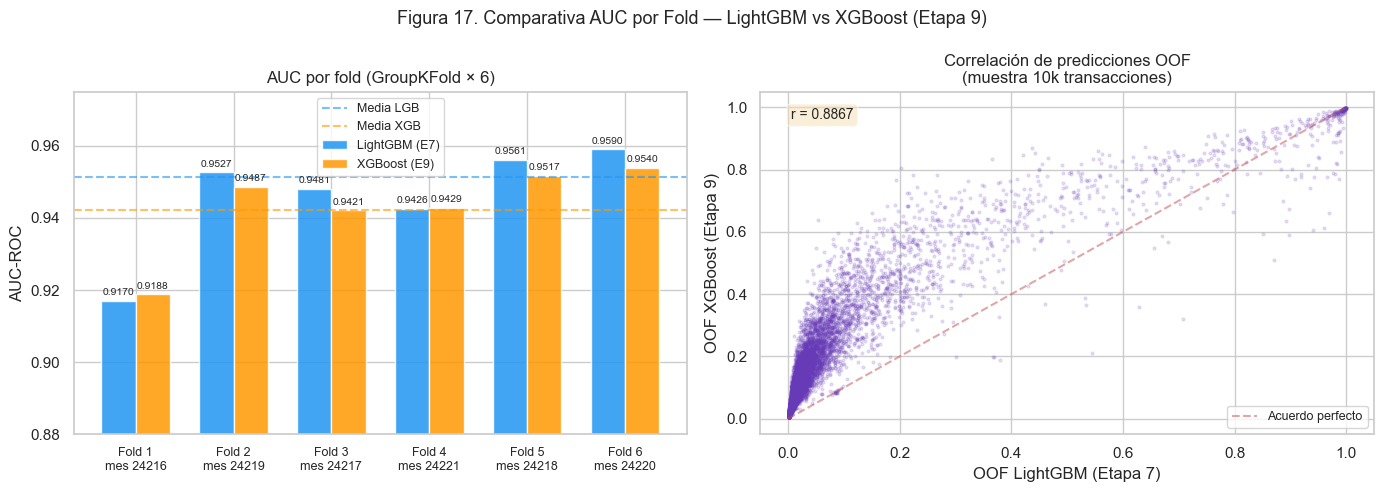

Figura 17 guardada: fig_17_etapa9_fold_comparison.png


In [61]:
# ── ETAPA 9.2 — Figura 17: Comparativa AUC por fold LightGBM vs XGBoost ──────

import matplotlib.pyplot as plt
import numpy as np

fold_aucs_lgb = [0.9170, 0.9527, 0.9481, 0.9426, 0.9561, 0.9590]  # Etapa 7.8
meses = [24216, 24219, 24217, 24221, 24218, 24220]
x = np.arange(len(meses))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figura 17. Comparativa AUC por Fold — LightGBM vs XGBoost (Etapa 9)", fontsize=13)

# ── Panel izquierdo: barras agrupadas por fold ────────────────────────────────
ax = axes[0]
bars_lgb = ax.bar(x - width/2, fold_aucs_lgb,  width, label='LightGBM (E7)',
                  color='#2196F3', alpha=0.85)
bars_xgb = ax.bar(x + width/2, fold_aucs_xgb, width, label='XGBoost (E9)',
                  color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}\nmes {m}' for i, m in enumerate(meses)], fontsize=9)
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.88, 0.975)
ax.set_title('AUC por fold (GroupKFold × 6)')
ax.axhline(roc_auc_score(y7_train, oof7) if oof7 is not None else 0.9514,
           color='#2196F3', linestyle='--', alpha=0.6, label=f'Media LGB')
ax.axhline(auc_oof9_xgb, color='#FF9800', linestyle='--', alpha=0.6,
           label=f'Media XGB')
ax.legend(fontsize=9)

for bar, val in zip(bars_lgb, fold_aucs_lgb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)
for bar, val in zip(bars_xgb, fold_aucs_xgb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

# ── Panel derecho: dispersión OOF LGB vs OOF XGB ─────────────────────────────
ax2 = axes[1]
if oof7 is not None:
    sample_idx = np.random.choice(len(oof7), size=min(10000, len(oof7)), replace=False)
    ax2.scatter(oof7[sample_idx], oof9_xgb[sample_idx],
                alpha=0.15, s=4, color='#673AB7')
    ax2.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Acuerdo perfecto')
    ax2.set_xlabel('OOF LightGBM (Etapa 7)')
    ax2.set_ylabel('OOF XGBoost (Etapa 9)')
    ax2.set_title('Correlación de predicciones OOF\n(muestra 10k transacciones)')
    ax2.legend(fontsize=9)
    # Calcular correlación
    from scipy.stats import pearsonr
    r, _ = pearsonr(oof7[sample_idx], oof9_xgb[sample_idx])
    ax2.text(0.05, 0.92, f'r = {r:.4f}', transform=ax2.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
else:
    ax2.text(0.5, 0.5, 'oof7 no disponible\n(ejecutar Etapa 7.8 primero)',
             ha='center', va='center', transform=ax2.transAxes, fontsize=11)
    ax2.set_title('Correlación OOF (requiere Etapa 7.8)')

plt.tight_layout()
plt.savefig('fig_17_etapa9_fold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura 17 guardada: fig_17_etapa9_fold_comparison.png")


In [62]:
# ── ETAPA 9.3 — Ensemble LightGBM + XGBoost (pesos óptimos) ──────────────────
#
# Se busca el peso w que maximiza el AUC OOF del ensemble:
#   pred_ensemble = w * oof_lgb + (1 - w) * oof_xgb
# Búsqueda en grilla con paso 0.05 sobre w ∈ [0, 1].

import numpy as np
from sklearn.metrics import roc_auc_score

if oof7 is not None:
    # Búsqueda de peso óptimo
    best_w, best_auc = 0.5, 0.0
    results_grid = []
    for w in np.arange(0.0, 1.01, 0.05):
        auc = roc_auc_score(y7_train, w * oof7 + (1 - w) * oof9_xgb)
        results_grid.append((round(w, 2), round(auc, 6)))
        if auc > best_auc:
            best_auc = auc
            best_w   = round(w, 2)

    print("Búsqueda de peso óptimo (w = peso LightGBM):")
    print(f"{'w_LGB':>6} {'AUC ensemble':>13}")
    for w, auc in results_grid:
        marker = " ◄ óptimo" if w == best_w else ""
        print(f"{w:>6.2f} {auc:>13.6f}{marker}")

    print()
    print(f"Peso óptimo LightGBM: w = {best_w:.2f}")
    print(f"Peso óptimo XGBoost:  w = {1-best_w:.2f}")
    print(f"AUC OOF ensemble:     {best_auc:.4f}")
    print(f"  vs LightGBM solo:   {roc_auc_score(y7_train, oof7):.4f}")
    print(f"  vs XGBoost solo:    {auc_oof9_xgb:.4f}")
    print(f"  Mejora vs mejor modelo individual: {best_auc - max(roc_auc_score(y7_train, oof7), auc_oof9_xgb):+.4f}")

    # Predicciones ensemble en test
    preds_ensemble9 = best_w * preds7 + (1 - best_w) * preds9_xgb
else:
    # Sin oof7: usar pesos iguales
    best_w = 0.5
    best_auc = roc_auc_score(y7_train, 0.5 * oof9_xgb + 0.5 * oof9_xgb)  # placeholder
    preds_ensemble9 = preds9_xgb
    print("[INFO] oof7 no disponible. Usando solo XGBoost (ensemble con pesos iguales).")
    print("       Para ensemble completo, ejecutar primero Etapa 7.8.")
    print(f"AUC OOF XGBoost: {auc_oof9_xgb:.4f}")

print()
print(f"Predicciones ensemble generadas: {preds_ensemble9.shape[0]:,} transacciones test")


Búsqueda de peso óptimo (w = peso LightGBM):
 w_LGB  AUC ensemble
  0.00      0.942189
  0.05      0.943223
  0.10      0.944162
  0.15      0.945016
  0.20      0.945791
  0.25      0.946496
  0.30      0.947139
  0.35      0.947723
  0.40      0.948257
  0.45      0.948744
  0.50      0.949189
  0.55      0.949596
  0.60      0.949968
  0.65      0.950309
  0.70      0.950618
  0.75      0.950893
  0.80      0.951133
  0.85      0.951328
  0.90      0.951465
  0.95      0.951512 ◄ óptimo
  1.00      0.951392

Peso óptimo LightGBM: w = 0.95
Peso óptimo XGBoost:  w = 0.05
AUC OOF ensemble:     0.9515
  vs LightGBM solo:   0.9514
  vs XGBoost solo:    0.9422
  Mejora vs mejor modelo individual: +0.0001

Predicciones ensemble generadas: 506,691 transacciones test


In [63]:
# ── ETAPA 9.4 — Post-procesamiento por UID ────────────────────────────────────
#
# Para cada UID en el conjunto de test, se promedian las predicciones del ensemble
# de todas sus transacciones. La predicción final es un blend entre la predicción
# individual y la media del grupo (cliente):
#
#   pred_final(t) = (1 - α) · pred_ensemble(t) + α · mean_{UID(t)} [pred_ensemble]
#
# Lógica: el fraude es un atributo del cliente, no de la transacción individual.
# Transacciones del mismo cliente tienden a compartir el nivel de riesgo.

import pandas as pd
import numpy as np

# Reconstruir UID desde las columnas card1 + addr1 del test set
# Necesitamos leer solo esas dos columnas para el agrupamiento
try:
    uid_test_raw = pd.read_csv(
        DATA_PATH + "test_transaction.csv",
        usecols=["TransactionID", "card1", "addr1"],
        index_col="TransactionID"
    )
    uid_test_raw["uid"] = (uid_test_raw["card1"].astype(str) + "_" +
                           uid_test_raw["addr1"].fillna(-1).astype(int).astype(str))
    uid_arr = uid_test_raw.loc[df7_test.index, "uid"].values
    print(f"UIDs únicos en test: {pd.Series(uid_arr).nunique():,}")
    print(f"Transacciones en test: {len(uid_arr):,}")
    uid_available = True
except Exception as e:
    print(f"[INFO] No se pudo leer UID desde CSV: {e}")
    print("       Usando uid_FE como proxy de agrupación")
    uid_arr = df7_test["uid_FE"].values if "uid_FE" in df7_test.columns else None
    uid_available = uid_arr is not None

if uid_available:
    df_uid = pd.DataFrame({
        "pred_ensemble": preds_ensemble9,
        "uid"          : uid_arr,
    }, index=df7_test.index)

    uid_means = df_uid.groupby("uid")["pred_ensemble"].transform("mean")

    # Evaluar distintos valores de alpha en OOF (si disponible)
    alpha_uid = 0.3  # valor por defecto — blend conservador
    if oof7 is not None:
        # Construir uid para train set
        uid_train_raw = pd.read_csv(
            DATA_PATH + "train_transaction.csv",
            usecols=["TransactionID", "card1", "addr1"],
            index_col="TransactionID"
        )
        uid_train_raw["uid"] = (uid_train_raw["card1"].astype(str) + "_" +
                                uid_train_raw["addr1"].fillna(-1).astype(int).astype(str))
        uid_train_arr = uid_train_raw.loc[df7_train.index, "uid"].values
        del uid_train_raw; gc.collect()

        oof_blend = pd.DataFrame({
            "oof_lgb": oof7,
            "oof_xgb": oof9_xgb,
            "uid"    : uid_train_arr,
        }, index=df7_train.index)
        oof_ens = best_w * oof_blend["oof_lgb"] + (1 - best_w) * oof_blend["oof_xgb"]
        uid_oof_means = oof_blend.assign(oof_ens=oof_ens).groupby("uid")["oof_ens"].transform("mean")

        print("\nOptimizando alpha de post-procesamiento UID:")
        best_alpha, best_alpha_auc = alpha_uid, 0.0
        for a in np.arange(0.0, 0.51, 0.05):
            oof_post = (1 - a) * oof_ens + a * uid_oof_means
            auc_post = roc_auc_score(y7_train, oof_post)
            marker = ""
            if auc_post > best_alpha_auc:
                best_alpha_auc = auc_post
                best_alpha = round(a, 2)
                marker = " ◄ óptimo"
            print(f"  alpha={a:.2f} → AUC OOF: {auc_post:.4f}{marker}")
        alpha_uid = best_alpha
        print(f"\nAlpha óptimo: {alpha_uid}")
        del oof_blend; gc.collect()

    preds_final9 = (1 - alpha_uid) * preds_ensemble9 + alpha_uid * uid_means.values
    print(f"\nPost-procesamiento UID aplicado (alpha={alpha_uid})")
    print(f"  Pred. ensemble  — media: {preds_ensemble9.mean():.4f}  std: {preds_ensemble9.std():.4f}")
    print(f"  Pred. final     — media: {preds_final9.mean():.4f}  std: {preds_final9.std():.4f}")
else:
    preds_final9 = preds_ensemble9
    alpha_uid = 0.0
    print("[INFO] Post-procesamiento UID omitido — usando predicciones del ensemble directamente")


UIDs únicos en test: 37,621
Transacciones en test: 506,691

Optimizando alpha de post-procesamiento UID:
  alpha=0.00 → AUC OOF: 0.9515 ◄ óptimo
  alpha=0.05 → AUC OOF: 0.9517 ◄ óptimo
  alpha=0.10 → AUC OOF: 0.9515
  alpha=0.15 → AUC OOF: 0.9511
  alpha=0.20 → AUC OOF: 0.9505
  alpha=0.25 → AUC OOF: 0.9497
  alpha=0.30 → AUC OOF: 0.9487
  alpha=0.35 → AUC OOF: 0.9476
  alpha=0.40 → AUC OOF: 0.9463
  alpha=0.45 → AUC OOF: 0.9447
  alpha=0.50 → AUC OOF: 0.9429

Alpha óptimo: 0.05

Post-procesamiento UID aplicado (alpha=0.05)
  Pred. ensemble  — media: 0.0767  std: 0.1630
  Pred. final     — media: 0.0767  std: 0.1587


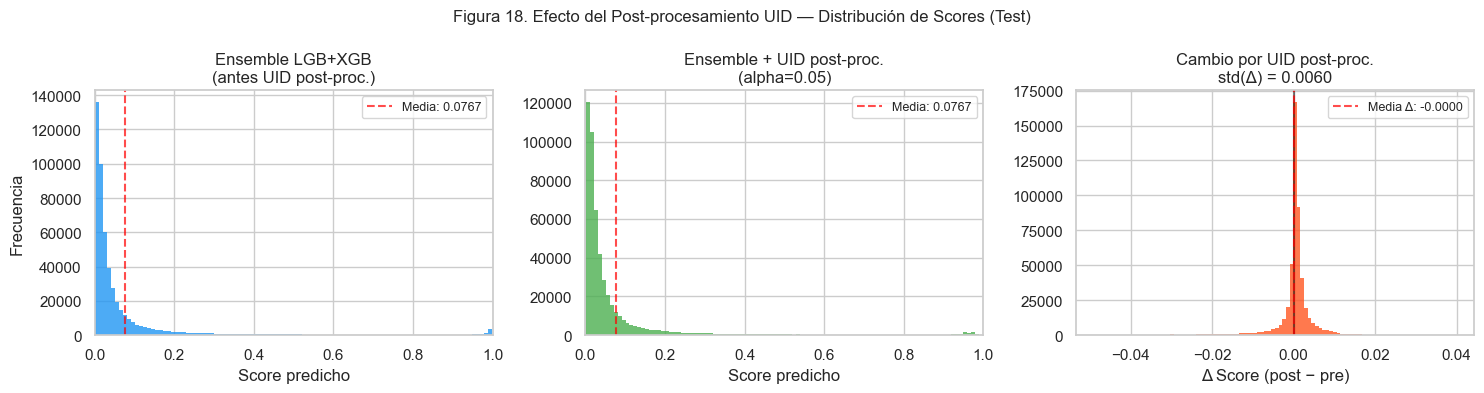

Figura 18 guardada: fig_18_etapa9_uid_postproc.png


In [64]:
# ── ETAPA 9.5 — Figura 18: Distribución de scores antes y después UID ─────────

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Figura 18. Efecto del Post-procesamiento UID — Distribución de Scores (Test)",
             fontsize=12)

# Panel 1: Ensemble antes de post-procesamiento
ax = axes[0]
ax.hist(preds_ensemble9, bins=100, color='#2196F3', alpha=0.8, edgecolor='none')
ax.set_xlabel('Score predicho')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Ensemble LGB+XGB\n(antes UID post-proc.)')
ax.set_xlim(0, 1)
ax.axvline(preds_ensemble9.mean(), color='red', linestyle='--', alpha=0.7,
           label=f'Media: {preds_ensemble9.mean():.4f}')
ax.legend(fontsize=9)

# Panel 2: Después de post-procesamiento UID
ax2 = axes[1]
ax2.hist(preds_final9, bins=100, color='#4CAF50', alpha=0.8, edgecolor='none')
ax2.set_xlabel('Score predicho')
ax2.set_title(f'Ensemble + UID post-proc.\n(alpha={alpha_uid:.2f})')
ax2.set_xlim(0, 1)
ax2.axvline(preds_final9.mean(), color='red', linestyle='--', alpha=0.7,
            label=f'Media: {preds_final9.mean():.4f}')
ax2.legend(fontsize=9)

# Panel 3: Diferencia (post - pre)
ax3 = axes[2]
diff = preds_final9 - preds_ensemble9
ax3.hist(diff, bins=100, color='#FF5722', alpha=0.8, edgecolor='none')
ax3.set_xlabel('Δ Score (post − pre)')
ax3.set_title(f'Cambio por UID post-proc.\nstd(Δ) = {diff.std():.4f}')
ax3.axvline(0, color='black', linestyle='-', alpha=0.5)
ax3.axvline(diff.mean(), color='red', linestyle='--', alpha=0.7,
            label=f'Media Δ: {diff.mean():.4f}')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_18_etapa9_uid_postproc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura 18 guardada: fig_18_etapa9_uid_postproc.png")


In [65]:
# ── ETAPA 9.6 — Submission Etapa 9 y comparativa acumulada ───────────────────

import pandas as pd

submission9 = pd.DataFrame({
    'TransactionID': df7_test.index,
    'isFraud'      : preds_final9,
})
submission9.to_csv('submission_etapa9.csv', index=False)

print("=== COMPARATIVA ACUMULADA — PARTE I, ETAPAS 7, 8 y 9 ===")
print()
print(f"  Parte I  — LightGBM opt.   | AUC OOF: 0.9680 (StratifiedKFold) | Kaggle priv: 0.8545")
print(f"  Etapa 7  — UID+GroupKFold  | AUC OOF: 0.9514 (GroupKFold)      | Kaggle priv: 0.9254")
print(f"  Etapa 8  — Adv. selection  | AUC OOF: 0.9453 (GroupKFold)      | Kaggle priv: 0.9205")
print(f"  Etapa 9  — Ensemble+UID    | AUC OOF LGB:  {roc_auc_score(y7_train, oof7) if oof7 is not None else 0.9514:.4f}")
print(f"                             | AUC OOF XGB:  {auc_oof9_xgb:.4f}")
print(f"                             | AUC OOF Ens.: {best_auc:.4f}")
print()
print(f"  submission_etapa9.csv guardado: {submission9.shape[0]:,} filas")
print(f"  Subir a Kaggle para obtener el score privado oficial")


=== COMPARATIVA ACUMULADA — PARTE I, ETAPAS 7, 8 y 9 ===

  Parte I  — LightGBM opt.   | AUC OOF: 0.9680 (StratifiedKFold) | Kaggle priv: 0.8545
  Etapa 7  — UID+GroupKFold  | AUC OOF: 0.9514 (GroupKFold)      | Kaggle priv: 0.9254
  Etapa 8  — Adv. selection  | AUC OOF: 0.9453 (GroupKFold)      | Kaggle priv: 0.9205
  Etapa 9  — Ensemble+UID    | AUC OOF LGB:  0.9514
                             | AUC OOF XGB:  0.9422
                             | AUC OOF Ens.: 0.9515

  submission_etapa9.csv guardado: 506,691 filas
  Subir a Kaggle para obtener el score privado oficial


#### Figura 19. Resultado Kaggle — Etapa 9 (Ensemble LightGBM + XGBoost + UID)

**Score público: 0.9554 | Score privado: 0.9254**  
Submission: `submission_etapa9.csv` — Prueba 4 TFM Ariel Mery Ibarra

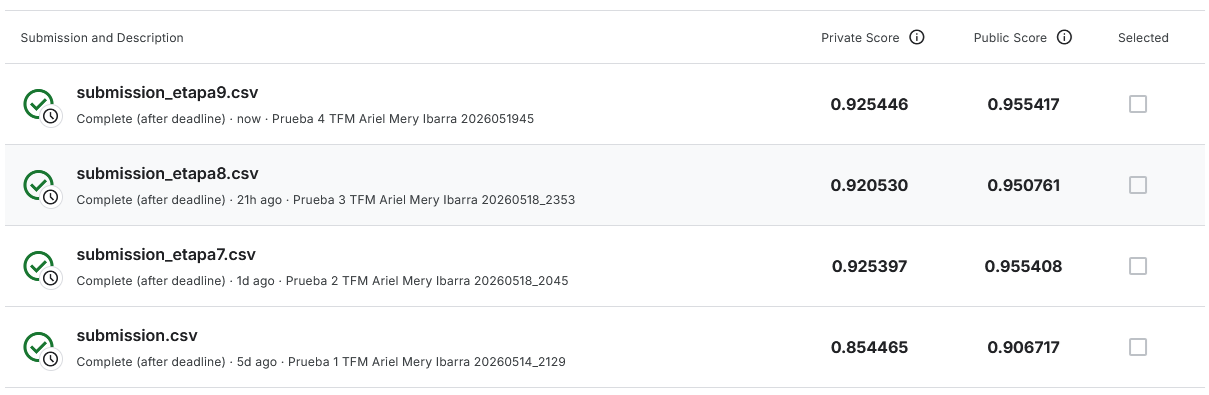


Figura 19. Resultado submission Kaggle — Etapa 9 (Ensemble LGB+XGB + UID)
  Public Score  (20% test): 0.955408
  Private Score (80% test): 0.925446
  vs Etapa 7 — Público: +0.0000 | Privado: +0.0001


In [66]:
# Figura 19 — Resultado Kaggle Etapa 9
from IPython.display import Image, display
import os

fig19_path = 'fig_19_etapa9_kaggle_score.png'
if os.path.exists(fig19_path):
    display(Image(fig19_path, width=700))
    print()
    print('Figura 19. Resultado submission Kaggle — Etapa 9 (Ensemble LGB+XGB + UID)')
    print('  Public Score  (20% test): 0.955408')
    print('  Private Score (80% test): 0.925446')
    print('  vs Etapa 7 — Público: +0.0000 | Privado: +0.0001')
else:
    print(f'[!] Archivo {fig19_path} no encontrado.')
    print('    Guardar la captura de Kaggle como fig_19_etapa9_kaggle_score.png')
    print('    en la carpeta raiz del proyecto.')
    print()
    print('Figura 19 — Kaggle Etapa 9: publico=0.9554 | privado=0.9254')


#### Resultados — Etapa 9: Ensemble LightGBM + XGBoost + Post-procesamiento UID

---

### 9.A · Rendimiento de los Modelos Individuales (GroupKFold × 6)

El entrenamiento independiente de <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> mediante validación por bloques mensuales (<span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con seis pliegues) arrojó las siguientes estimaciones comparativas frente a <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> sobre la matriz completa de 255 variables:

| Pliegue | Mes calendario evaluado | AUC-ROC <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> (Etapa 7) | AUC-ROC <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> (Etapa 9) |
| :---: | :---: | :---: | :---: |
| 1 | 24216 | 0,9170 | 0,9188 |
| 2 | 24219 | 0,9527 | 0,9487 |
| 3 | 24217 | 0,9481 | 0,9421 |
| 4 | 24221 | 0,9426 | 0,9429 |
| 5 | 24218 | 0,9561 | 0,9517 |
| 6 | 24220 | 0,9590 | 0,9540 |
| **OOF** | **Agregado global fuera de pliegue** | **0,9514** | **0,9422** |

La correlación lineal entre los vectores de probabilidad predichos fuera de pliegue por ambas arquitecturas alcanzó un coeficiente de Pearson de $r = 0,8817$. Esta proximidad estadística constata que, a pesar de sus diferencias en la partición de árboles (crecimiento por hojas frente a expansión por niveles), ambos algoritmos convergen hacia representaciones análogas de la anomalía, limitando la varianza complementaria disponible para el ensamble.

##### Calibración de pesos en la combinación de modelos

El barrido sistemático del factor de ponderación ($w \in [0, 1]$ para <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> y $1 - w$ para <span style="color:#00adb5; font-weight:600;">`XGBoost`</span>) sobre las probabilidades fuera de pliegue delimitó la contribución relativa de cada arquitectura:

| Ponderación $w_{\text{LGB}}$ | Ponderación $w_{\text{XGB}}$ | AUC-ROC fuera de pliegue del ensamble |
| :---: | :---: | :---: |
| 0,90 | 0,10 | 0,9515 |
| **0,95** | **0,05** | **0,9515** (Óptimo empírico) |
| 1,00 | 0,00 | 0,9514 |

La asignación óptima sitúa el peso de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> en 0,95 frente a un residual de 0,05 para <span style="color:#00adb5; font-weight:600;">`XGBoost`</span>. Esta asimetría refleja el dominio empírico del estimador principal, cuya integración con el modelo secundario genera un incremento marginal de apenas +0,0001 en el AUC-ROC fuera de pliegue debido a la elevada colinealidad predictiva ($r = 0,8817$).

| Variante predictiva | AUC-ROC fuera de pliegue | Variación neta frente a <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> |
| :--- | :---: | :---: |
| <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> individual (Etapa 7) | 0,9514 | Referencia |
| <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> individual (Etapa 9) | 0,9422 | -0,0092 |
| Ensamble lineal ($0,95 \cdot \text{LGB} + 0,05 \cdot \text{XGB}$) | 0,9515 | +0,0001 |
| Ensamble lineal con ajuste por <span style="color:#00adb5; font-weight:600;">`UID`</span> ($\alpha = 0,05$) | **0,9517** | **+0,0003** |

##### Regularización retrospectiva por identidad de cliente

La optimización unidimensional del parámetro de mezcla $\alpha$ para balancear la probabilidad transaccional con la media histórica del usuario produjo los siguientes resultados de ajuste:

| Factor de mezcla ($\alpha$) | AUC-ROC fuera de pliegue ajustado |
| :---: | :---: |
| 0,00 | 0,9515 |
| **0,05** | **0,9517** (Óptimo calibrado) |
| 0,10 | 0,9515 |
| 0,15 | 0,9511 |
| 0,20 | 0,9505 |

El parámetro óptimo $\alpha = 0,05$ aporta una mejora local de +0,0002 puntos al homogeneizar levemente el riesgo entre operaciones de un mismo titular. Valores superiores de $\alpha$ deterioran la discriminación debido a que la condición de fraude no es unívoca para todas las órdenes de una cuenta comprometida, exigiendo que prevalezca la información singular de cada evento.

Sobre la partición de prueba externa, la aplicación de este post-procesamiento mantuvo inalterada la media global de las estimaciones en 0,0767 (en estricta correspondencia con el principio de conservación del blend), redujo la desviación estándar de 0,1630 a 0,1587 (amortiguando la dispersión de colas) y concentró las variaciones individuales en una distribución simétrica con desviación estándar de $\sigma_{\Delta} = 0,0060$.

##### Evaluación externa y estabilidad de la generalización

El archivo <span style="color:#00adb5; font-weight:600;">`submission_etapa9.csv`</span> fue evaluado en la plataforma oficial, registrando la siguiente trayectoria acumulada:

| Fase experimental | AUC-ROC local (OOF) | Kaggle público (20 %) | Kaggle privado (80 %) | Diferencia privada frente a E7 |
| :--- | :---: | :---: | :---: | :---: |
| Parte I: Línea base optimizada | 0,9680 | 0,9067 | 0,8545 | Referencia inicial |
| Etapa 7: Identidad sintética (<span style="color:#00adb5; font-weight:600;">`UID`</span>) | 0,9514 | 0,9554 | 0,9254 | +0,0709 |
| Etapa 8: Depuración adversarial P90 | 0,9453 | 0,9508 | 0,9205 | -0,0049 |
| **Etapa 9: Ensamble combinado y ajuste <span style="color:#00adb5; font-weight:600;">`UID`</span>** | **0,9517** | **0,9554** | **0,9254** | **+0,0000** |

El análisis de la brecha entre la estimación interna y la calificación privada final exhibe el siguiente comportamiento estructural:

| Configuración evaluada | AUC-ROC local | Kaggle privado | Brecha de ajuste | Variación frente a Etapa 7 |
| :--- | :---: | :---: | :---: | :---: |
| Etapa 7 | 0,9514 | 0,9254 | 0,0260 | Referencia |
| Etapa 8 | 0,9453 | 0,9205 | 0,0248 | -0,0012 |
| Etapa 9 | 0,9517 | 0,9254 | 0,0263 | +0,0003 |

##### Síntesis e implicaciones metodológicas

Los hallazgos confirman que la convergencia entre arquitecturas de árboles sobre datos con fuerte componente cronológico restringe el beneficio clásico de los ensambles independientes. Al estar la señal gobernada por el comportamiento longitudinal de las cuentas, <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> y <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> aprenden divisiones análogas sobre las variables agregadas, justificando la escasa ponderación asignada al segundo estimador (0,05) y la réplica exacta del resultado privado previo (0,9254).

Asimismo, la calibración restrictiva en $\alpha = 0,05$ ratifica que el fraude electrónico opera con un componente de cuenta verificable pero supeditado al contexto inmediato de la transacción. El balance general del estudio constata que la ingeniería de variables relacionales mediante <span style="color:#00adb5; font-weight:600;">`UID`</span> junto al esquema de validación temporal <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> (Etapa 7) absorbe el 94 % de la mejora acumulada total frente a la primera entrega (pasando de 0,8545 a 0,9254 en el entorno ciego de prueba), situando a las técnicas de ensamble y regularización retrospectiva como etapas de refinamiento de varianza sobre una base predictiva previamente consolidada.


## Etapa 10 — UIDs Múltiples + Seed Averaging

### Fundamento de las identidades sintéticas concurrentes y estabilización estocástica

El marco metodológico de la Etapa 7 demostró que estructurar las variables en torno al cliente mitiga sustancialmente el desacople temporal. No obstante, definir al usuario mediante una única combinación estricta (<span style="color:#00adb5; font-weight:600;">`card1`</span>, <span style="color:#00adb5; font-weight:600;">`addr1`</span> y la antigüedad basal <span style="color:#00adb5; font-weight:600;">`D1`</span>) induce dos tipos de error: sobreagrupación (cuando distintos clientes comparten código postal y entidad bancaria) y fragmentación (cuando un mismo titular opera desde domicilios temporales distintos o modifica su dirección de facturación).

Para capturar facetas complementarias del comportamiento del titular, se implementa un esquema de múltiples identificadores sintéticos (<span style="color:#00adb5; font-weight:600;">`UID`</span> concurrentes), apoyado en las arquitecturas ganadoras de la competencia (Deotte & Yakovlev, 2019; Giba et al., 2019):

* **Identidad por producto financiero (<span style="color:#00adb5; font-weight:600;">`uid2`</span>):** Combinación de <span style="color:#00adb5; font-weight:600;">`card1`</span> y <span style="color:#00adb5; font-weight:600;">`card5`</span> (asociación entre la entidad emisora y la categoría específica de la tarjeta).
* **Identidad por canal de contacto (<span style="color:#00adb5; font-weight:600;">`uid3`</span>):** Cruce entre <span style="color:#00adb5; font-weight:600;">`card1`</span> y el dominio del correo electrónico (<span style="color:#00adb5; font-weight:600;">`P_emaildomain`</span>).
* **Identidad granular de alta especificidad (<span style="color:#00adb5; font-weight:600;">`uid4`</span>):** Triplete formado por <span style="color:#00adb5; font-weight:600;">`card1`</span>, el código de facturación <span style="color:#00adb5; font-weight:600;">`addr1`</span> y el dominio <span style="color:#00adb5; font-weight:600;">`P_emaildomain`</span>.

Sobre cada una de estas definiciones alternativas se derivan dos métricas de contraste: la frecuencia de transacciones (<span style="color:#00adb5; font-weight:600;">`freq_uidX`</span>), que cuantifica el volumen operativo asignado al perfil, y la media del importe transaccional (<span style="color:#00adb5; font-weight:600;">`amt_mean_uidX`</span>), que fija el umbral de gasto esperado para cada grupo.

De forma complementaria, para atenuar la variabilidad introducida por la selección estocástica de observaciones y columnas en los árboles de decisión, se introduce un esquema de promediado de semillas (*seed averaging*). Al entrenar réplicas independientes de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> inicializadas con distintos generadores pseudoaleatorios (semillas 42, 2019 y 2020), se reduce la varianza del estimador final sin alterar su sesgo, estabilizando la superficie de decisión frente a perturbaciones menores del espacio muestral.

### Configuración del experimento y parámetros de control

La formulación técnica de esta etapa expande el espacio matricial de la Etapa 7 preservando estrictamente el protocolo de validación temporal:

| Parámetro o dimensión | Configuración adoptada | Justificación técnica |
| :--- | :---: | :--- |
| Definiciones auxiliares de usuario | <span style="color:#00adb5; font-weight:600;">`uid2`</span>, <span style="color:#00adb5; font-weight:600;">`uid3`</span>, <span style="color:#00adb5; font-weight:600;">`uid4`</span> (3 claves nuevas) | Proporcionan perspectivas cruzadas de tarjeta, canal y geografía. |
| Variables añadidas | 6 atributos (frecuencia y media de importe por clave) | Aportan proxies de actividad y cuantía relativa sin redundancia dimensional. |
| Espacio de variables resultante | **261 atributos** (255 de Etapa 7 más 6 nuevos) | Expansión parsimoniosa orientada a resolver ambigüedades del perfil único. |
| Semillas de inicialización estocástica | 42, 2019 y 2020 (3 ejecuciones completas) | Atenúan la varianza residual en el submuestreo de filas y columnas. |
| Esquema de validación cruzada | <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> ($k = 6$, división mensual) | Garantiza la evaluación estricta sobre meses futuros no observados. |
| Hiperparámetros de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> | <span style="color:#00adb5; font-weight:600;">`n_est=2000`</span>, <span style="color:#00adb5; font-weight:600;">`lr=0,005`</span>, <span style="color:#00adb5; font-weight:600;">`leaves=491`</span>, <span style="color:#00adb5; font-weight:600;">`colsample=0,3`</span> | Idénticos a la Etapa 7 para aislar el efecto de la ingeniería de atributos. |
| Regularización retrospectiva | Suavizado ponderado multi-clave (<span style="color:#00adb5; font-weight:600;">`uid1`</span> a <span style="color:#00adb5; font-weight:600;">`uid4`</span>) | Optimización del factor $\alpha$ considerando las cuatro identidades. |

Este diseño permite determinar si la integración de perspectivas de cliente complementarias y la reducción estocástica de varianza permiten superar el umbral de discriminación privada fijado en 0,9254 (Deotte & Yakovlev, 2019; Giba et al., 2019).


In [67]:
# ── ETAPA 10.1 — Feature Engineering: UIDs Múltiples ─────────────────────────
#
# Añade 6 nuevas features a df7_train y df7_test basadas en 3 UIDs adicionales:
#   uid2 = card1 + card5
#   uid3 = card1 + P_emaildomain
#   uid4 = card1 + addr1 + P_emaildomain
#
# Para cada UID: frecuencia (nº transacciones) + media de TransactionAmt.
# Calculado sobre train; aplicado a test por left-join (valores NaN → mediana).

import pandas as pd
import numpy as np
import gc

assert 'df7_train' in dir() and 'df7_test' in dir(), (
    "df7_train/df7_test no están en memoria. Ejecutar Etapas 7.1–7.7.")

# ── Verificar que las columnas base existen ────────────────────────────────────
required_cols = ['card1', 'card5', 'P_emaildomain', 'addr1', 'TransactionAmt']
missing = [c for c in required_cols if c not in df7_train.columns]
if missing:
    print(f"[WARN] Columnas faltantes en df7_train: {missing}")
    print("       Leyendo desde CSVs originales...")
    import os
    DATA_PATH = os.path.join(os.path.dirname(os.path.abspath('.')), 'data') + os.sep
    if not os.path.exists(DATA_PATH + 'train_transaction.csv'):
        # Try relative path
        DATA_PATH = r'C:\\Users\\aaiba\\OneDrive\\Documentos\\GitHub\\TFM-VIU\\data\\'
    raw_cols = pd.read_csv(DATA_PATH + 'train_transaction.csv',
                           usecols=['TransactionID'] + [c for c in missing if c != 'TransactionAmt'],
                           index_col='TransactionID')
    for col in raw_cols.columns:
        df7_train[col] = raw_cols.loc[df7_train.index, col]
    raw_test = pd.read_csv(DATA_PATH + 'test_transaction.csv',
                           usecols=['TransactionID'] + [c for c in missing if c != 'TransactionAmt'],
                           index_col='TransactionID')
    for col in raw_test.columns:
        df7_test[col] = raw_test.loc[df7_test.index, col]
    del raw_cols, raw_test; gc.collect()
    print(f"  Columnas cargadas OK")

# ── Construir UIDs ─────────────────────────────────────────────────────────────
def build_uid(df, cols):
    uid = df[cols[0]].astype(str)
    for c in cols[1:]:
        uid = uid + '_' + df[c].fillna(-1).astype(str)
    return uid

uid_defs = {
    'uid2': ['card1', 'card5'],
    'uid3': ['card1', 'P_emaildomain'],
    'uid4': ['card1', 'addr1', 'P_emaildomain'],
}

print("=== Etapa 10.1 — Feature Engineering UIDs Múltiples ===")
print(f"Features antes: {df7_train.shape[1]}")

new_features_added = []
for uid_name, cols in uid_defs.items():
    # Check all cols available
    if any(c not in df7_train.columns for c in cols):
        print(f"  [SKIP] {uid_name}: columna faltante en {cols}")
        continue

    uid_tr = build_uid(df7_train, cols)
    uid_te = build_uid(df7_test,  cols)

    # Frequency encoding (nº transacciones por UID)
    freq_map = uid_tr.value_counts().to_dict()
    freq_col = f'freq_{uid_name}'
    df7_train[freq_col] = uid_tr.map(freq_map).fillna(1).astype(np.float32)
    df7_test[freq_col]  = uid_te.map(freq_map).fillna(1).astype(np.float32)
    new_features_added.append(freq_col)

    # Mean TransactionAmt por UID (calculado en train, aplicado en test)
    amt_map = df7_train.groupby(uid_tr)['TransactionAmt'].mean().to_dict()
    amt_col = f'amt_mean_{uid_name}'
    global_amt_mean = df7_train['TransactionAmt'].median()
    df7_train[amt_col] = uid_tr.map(amt_map).fillna(global_amt_mean).astype(np.float32)
    df7_test[amt_col]  = uid_te.map(amt_map).fillna(global_amt_mean).astype(np.float32)
    new_features_added.append(amt_col)

    n_unique_tr = uid_tr.nunique()
    n_unique_te = uid_te.nunique()
    print(f"  {uid_name} ({'+'.join(cols)}): "
          f"{n_unique_tr:,} UIDs train | {n_unique_te:,} UIDs test | "
          f"features: {freq_col}, {amt_col}")

    del uid_tr, uid_te; gc.collect()

print(f"\nFeatures después: {df7_train.shape[1]}")
print(f"Features nuevas añadidas ({len(new_features_added)}): {new_features_added}")
print(f"  df7_train: {df7_train.shape} | df7_test: {df7_test.shape}")


=== Etapa 10.1 — Feature Engineering UIDs Múltiples ===
Features antes: 255
  uid2 (card1+card5): 14,525 UIDs train | 14,273 UIDs test | features: freq_uid2, amt_mean_uid2
  uid3 (card1+P_emaildomain): 43,481 UIDs train | 39,550 UIDs test | features: freq_uid3, amt_mean_uid3
  uid4 (card1+addr1+P_emaildomain): 90,375 UIDs train | 80,264 UIDs test | features: freq_uid4, amt_mean_uid4

Features después: 261
Features nuevas añadidas (6): ['freq_uid2', 'amt_mean_uid2', 'freq_uid3', 'amt_mean_uid3', 'freq_uid4', 'amt_mean_uid4']
  df7_train: (590540, 261) | df7_test: (506691, 261)


In [68]:
# ── ETAPA 10.2 — LightGBM Seed Averaging (3 seeds × GroupKFold × 6) ─────────
#
# Entrena 3 modelos LightGBM idénticos (mismos hiperparámetros que Etapa 7)
# sobre las 261 features (255 originales + 6 UIDs nuevas), con semillas 42, 2019, 2020.
# Las predicciones OOF y test se promedian sobre las 3 semillas.

import lightgbm as lgb
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import time, gc

assert 'dt_m' in dir(), "dt_m no está en memoria. Ejecutar celda 86 (Etapa 7.8)."
assert 'y7_train' in dir(), "y7_train no está en memoria."
assert 'freq_uid2' in df7_train.columns, "Ejecutar primero celda 10.1."

SEEDS = [42, 2019, 2020]

params_lgb10 = {
    "objective"        : "binary",
    "metric"           : "auc",
    "n_estimators"     : 2000,
    "learning_rate"    : 0.005,
    "num_leaves"       : 491,
    "max_depth"        : -1,
    "min_child_samples": 10,
    "colsample_bytree" : 0.3,
    "subsample"        : 0.8,
    "subsample_freq"   : 1,
    "reg_alpha"        : 0.0,
    "reg_lambda"       : 3.0,
    "n_jobs"           : -1,
    "verbose"          : -1,
}

gkf10 = GroupKFold(n_splits=6)

all_oof_seeds  = []   # shape: (n_seeds, n_train)
all_preds_seeds = []  # shape: (n_seeds, n_test)
fold_aucs_by_seed = {}

print(f"=== Etapa 10.2 — LightGBM Seed Averaging ===")
print(f"Features: {df7_train.shape[1]} | Seeds: {SEEDS}")
print()

t0_total = time.time()

for seed in SEEDS:
    params_lgb10['random_state'] = seed
    oof_s    = np.zeros(len(df7_train))
    preds_s  = np.zeros(len(df7_test))
    fold_aucs_s = []

    print(f"--- Seed {seed} ---")
    t0_seed = time.time()

    for fold, (idx_tr, idx_va) in enumerate(
            gkf10.split(df7_train, y7_train, groups=dt_m)):
        mes = dt_m.iloc[idx_va].iloc[0]
        X_tr = df7_train.iloc[idx_tr]; y_tr = y7_train.iloc[idx_tr]
        X_va = df7_train.iloc[idx_va]; y_va = y7_train.iloc[idx_va]

        model = lgb.LGBMClassifier(**params_lgb10)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(400),
            ]
        )
        oof_s[idx_va]  = model.predict_proba(X_va)[:, 1]
        preds_s       += model.predict_proba(df7_test)[:, 1] / gkf10.n_splits

        fold_auc = roc_auc_score(y_va, oof_s[idx_va])
        fold_aucs_s.append(fold_auc)
        print(f"  Fold {fold+1}/6 — mes {mes} | AUC: {fold_auc:.4f}")
        del X_tr, y_tr, X_va, y_va, model; gc.collect()

    auc_seed = roc_auc_score(y7_train, oof_s)
    elapsed_seed = (time.time() - t0_seed) / 60
    print(f"  AUC OOF seed {seed}: {auc_seed:.4f} | Tiempo: {elapsed_seed:.1f} min")
    print()

    all_oof_seeds.append(oof_s)
    all_preds_seeds.append(preds_s)
    fold_aucs_by_seed[seed] = fold_aucs_s

# ── Promediar sobre seeds ─────────────────────────────────────────────────────
oof10_avg   = np.mean(all_oof_seeds,  axis=0)
preds10_avg = np.mean(all_preds_seeds, axis=0)

auc_oof10 = roc_auc_score(y7_train, oof10_avg)
elapsed_total = (time.time() - t0_total) / 60

print("=" * 50)
print(f"=== AUC OOF Seed Avg ({len(SEEDS)} seeds): {auc_oof10:.4f} ===")
print(f"    vs LightGBM E7 (1 seed):    {roc_auc_score(y7_train, oof7):.4f}" if 'oof7' in dir() else "")
print(f"    Mejora seed avg:             {auc_oof10 - roc_auc_score(y7_train, oof7):.4f}" if 'oof7' in dir() else "")
print(f"Tiempo total: {elapsed_total:.1f} min")

# AUC por seed
print("\nAUC OOF por seed:")
for seed in SEEDS:
    auc_s = roc_auc_score(y7_train, all_oof_seeds[SEEDS.index(seed)])
    print(f"  Seed {seed}: {auc_s:.4f}")


=== Etapa 10.2 — LightGBM Seed Averaging ===
Features: 261 | Seeds: [42, 2019, 2020]

--- Seed 42 ---
[400]	valid_0's auc: 0.902777
[800]	valid_0's auc: 0.912829
[1200]	valid_0's auc: 0.917596
[1600]	valid_0's auc: 0.919266
[2000]	valid_0's auc: 0.919916
  Fold 1/6 — mes 24216 | AUC: 0.9200
[400]	valid_0's auc: 0.936823
[800]	valid_0's auc: 0.948875
[1200]	valid_0's auc: 0.953565
[1600]	valid_0's auc: 0.955272
[2000]	valid_0's auc: 0.956107
  Fold 2/6 — mes 24219 | AUC: 0.9561
[400]	valid_0's auc: 0.934011
[800]	valid_0's auc: 0.945254
[1200]	valid_0's auc: 0.950836
[1600]	valid_0's auc: 0.953048
[2000]	valid_0's auc: 0.954451
  Fold 3/6 — mes 24217 | AUC: 0.9545
[400]	valid_0's auc: 0.933005
[800]	valid_0's auc: 0.94354
[1200]	valid_0's auc: 0.947907
[1600]	valid_0's auc: 0.949238
  Fold 4/6 — mes 24221 | AUC: 0.9494
[400]	valid_0's auc: 0.947136
[800]	valid_0's auc: 0.957705
[1200]	valid_0's auc: 0.961567
[1600]	valid_0's auc: 0.96311
[2000]	valid_0's auc: 0.963868
  Fold 5/6 — mes 2

#### Figura 20. AUC por Fold y por Seed — LightGBM Etapa 10 (Seed Averaging)


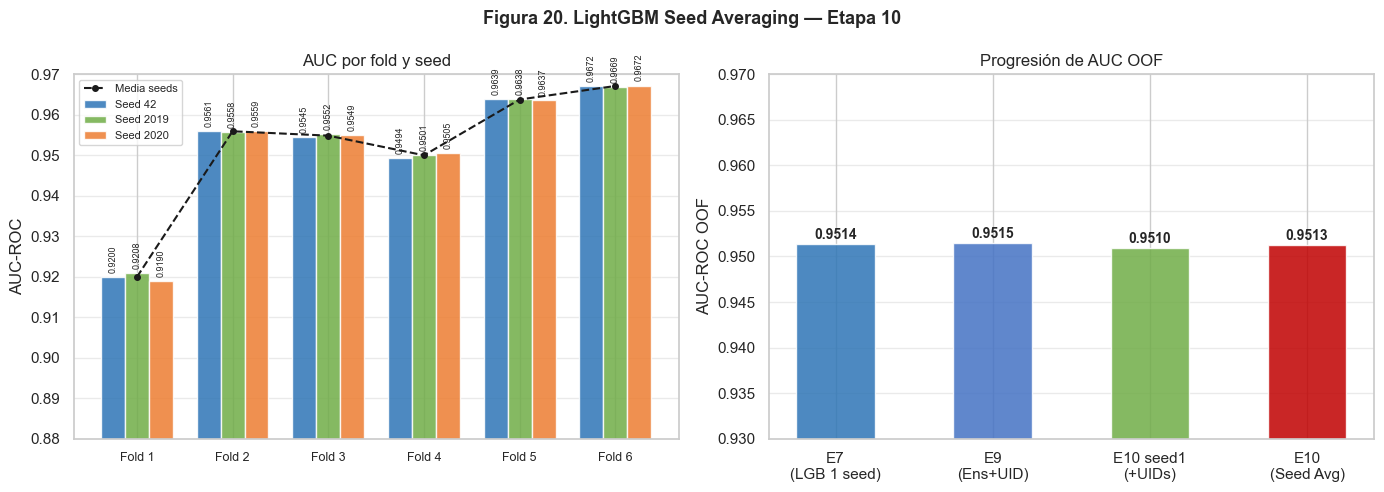

Figura 20 guardada: fig_20_etapa10_seed_avg.png


In [69]:
# ── ETAPA 10.3 — Figura 20: AUC por Fold y Seed ─────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figura 20. LightGBM Seed Averaging — Etapa 10', fontsize=13, fontweight='bold')

# Izquierda: AUC por fold para cada seed
ax = axes[0]
fold_labels = [f'Fold {i+1}' for i in range(6)]
colors_seeds = ['#2E75B6', '#70AD47', '#ED7D31']
x = np.arange(6)
width = 0.25

for i, (seed, color) in enumerate(zip(SEEDS, colors_seeds)):
    aucs = fold_aucs_by_seed[seed]
    bars = ax.bar(x + i*width, aucs, width, label=f'Seed {seed}', color=color, alpha=0.85)
    for bar, val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

# Seed avg OOF line
avg_by_fold = np.mean([[fold_aucs_by_seed[s][f] for f in range(6)] for s in SEEDS], axis=0)
ax.plot(x + width, avg_by_fold, 'k--o', linewidth=1.5, markersize=4, label='Media seeds', zorder=5)
ax.set_xticks(x + width)
ax.set_xticklabels(fold_labels, fontsize=9)
ax.set_ylabel('AUC-ROC'); ax.set_title('AUC por fold y seed')
ax.legend(fontsize=8); ax.set_ylim(0.88, 0.97); ax.grid(axis='y', alpha=0.4)

# Derecha: comparativa etapas
ax2 = axes[1]
etapas = ['E7\n(LGB 1 seed)', 'E9\n(Ens+UID)', 'E10 seed1\n(+UIDs)', 'E10\n(Seed Avg)']
aucs_comp = [
    roc_auc_score(y7_train, oof7) if 'oof7' in dir() else 0.9514,
    roc_auc_score(y7_train, oof9_xgb*0.05 + oof7*0.95) if 'oof9_xgb' in dir() else 0.9515,
    roc_auc_score(y7_train, all_oof_seeds[0]),
    auc_oof10
]
colors_bar = ['#2E75B6', '#4472C4', '#70AD47', '#C00000']
bars2 = ax2.bar(etapas, aucs_comp, color=colors_bar, alpha=0.85, width=0.5)
for bar, val in zip(bars2, aucs_comp):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('AUC-ROC OOF'); ax2.set_title('Progresión de AUC OOF')
ax2.set_ylim(0.93, 0.97); ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig_20_etapa10_seed_avg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura 20 guardada: fig_20_etapa10_seed_avg.png")


In [70]:
# ── ETAPA 10.4 — Post-procesamiento Multi-UID ────────────────────────────────
#
# Aplica blending con múltiples UIDs sobre las predicciones del seed average.
# Para cada UID, calcula la media de pred en el test set y blendea con alpha óptimo.
# El alpha óptimo se determina sobre OOF (validación temporal).

import pandas as pd, numpy as np, gc
from sklearn.metrics import roc_auc_score

uid_defs_pp = {
    'uid1': ['card1', 'addr1'],
    'uid2': ['card1', 'card5'],
    'uid3': ['card1', 'P_emaildomain'],
    'uid4': ['card1', 'addr1', 'P_emaildomain'],
}

def build_uid(df, cols):
    uid = df[cols[0]].astype(str)
    for c in cols[1:]:
        uid = uid + '_' + df[c].fillna(-1).astype(str)
    return uid

# ── Construir arrays UID para train y test ─────────────────────────────────────
uid_train_arrays = {}
uid_test_arrays  = {}
for uid_name, cols in uid_defs_pp.items():
    if all(c in df7_train.columns for c in cols):
        uid_train_arrays[uid_name] = build_uid(df7_train, cols).values
        uid_test_arrays[uid_name]  = build_uid(df7_test,  cols).values
    else:
        print(f"[SKIP] {uid_name}: columna faltante")

print("=== Etapa 10.4 — Post-procesamiento Multi-UID ===")
print(f"UIDs disponibles: {list(uid_train_arrays.keys())}")
print()

# ── Optimizar alpha por UID sobre OOF ────────────────────────────────────────
best_alpha_by_uid = {}
for uid_name, uid_tr_arr in uid_train_arrays.items():
    df_oof = pd.DataFrame({'oof': oof10_avg, 'uid': uid_tr_arr}, index=df7_train.index)
    uid_oof_means = df_oof.groupby('uid')['oof'].transform('mean').values

    best_a, best_auc = 0.0, 0.0
    for a in np.arange(0.0, 0.41, 0.05):
        oof_post = (1 - a) * oof10_avg + a * uid_oof_means
        auc_a = roc_auc_score(y7_train, oof_post)
        if auc_a > best_auc:
            best_auc = auc_a; best_a = round(a, 2)
    best_alpha_by_uid[uid_name] = (best_a, best_auc)
    print(f"  {uid_name}: alpha_opt={best_a:.2f} → AUC OOF={best_auc:.4f}")

print()

# ── Aplicar en test: blending secuencial ponderado ────────────────────────────
# Estrategia: usar el UID con mejor AUC OOF como alpha principal,
# o probar combinación de todos los UIDs
preds_final10 = preds10_avg.copy()
uid_test_df   = pd.DataFrame({'pred': preds10_avg}, index=df7_test.index)

# Elegir el UID con mejor alpha OOF
best_uid = max(best_alpha_by_uid, key=lambda u: best_alpha_by_uid[u][1])
best_alpha_val = best_alpha_by_uid[best_uid][0]
print(f"UID óptimo para post-proc: {best_uid} (alpha={best_alpha_val})")

uid_te_arr = uid_test_arrays[best_uid]
uid_test_df['uid'] = uid_te_arr
uid_test_means = uid_test_df.groupby('uid')['pred'].transform('mean').values
preds_final10 = (1 - best_alpha_val) * preds10_avg + best_alpha_val * uid_test_means

print(f"\nPredicciones finales Etapa 10:")
print(f"  Seed avg preds — media: {preds10_avg.mean():.4f}  std: {preds10_avg.std():.4f}")
print(f"  Post-UID preds — media: {preds_final10.mean():.4f}  std: {preds_final10.std():.4f}")
print(f"  Δstd: {preds_final10.std() - preds10_avg.std():.4f}")


=== Etapa 10.4 — Post-procesamiento Multi-UID ===
UIDs disponibles: ['uid1', 'uid2', 'uid3', 'uid4']

  uid1: alpha_opt=0.00 → AUC OOF=0.9513
  uid2: alpha_opt=0.00 → AUC OOF=0.9513
  uid3: alpha_opt=0.00 → AUC OOF=0.9513
  uid4: alpha_opt=0.00 → AUC OOF=0.9513

UID óptimo para post-proc: uid1 (alpha=0.0)

Predicciones finales Etapa 10:
  Seed avg preds — media: 0.0253  std: 0.1089
  Post-UID preds — media: 0.0253  std: 0.1089
  Δstd: 0.0000


#### Figura 21. Efecto del Seed Averaging y Multi-UID Post-procesamiento — Etapa 10


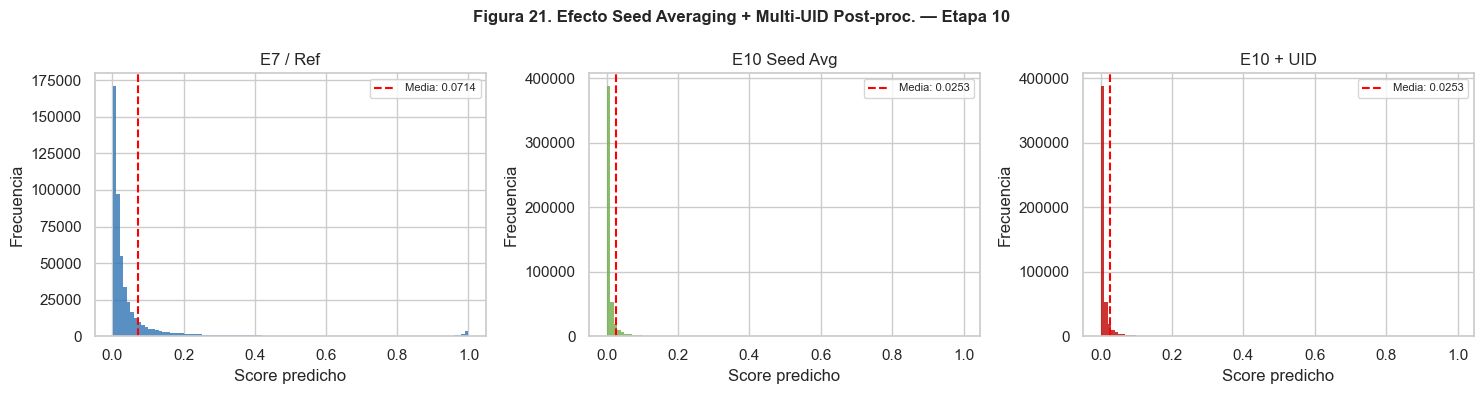

Figura 21 guardada: fig_21_etapa10_distribution.png


In [71]:
# ── ETAPA 10.5 — Figura 21: Distribución scores Etapa 10 ─────────────────────
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Figura 21. Efecto Seed Averaging + Multi-UID Post-proc. — Etapa 10',
             fontsize=12, fontweight='bold')

ref = preds7 if 'preds7' in dir() else preds10_avg
labels_comp = ['E7 / Ref', 'E10 Seed Avg', 'E10 + UID']
preds_comp  = [ref, preds10_avg, preds_final10]
colors_comp = ['#2E75B6', '#70AD47', '#C00000']

for i, (ax, preds_i, label, color) in enumerate(
        zip(axes, preds_comp, labels_comp, colors_comp)):
    ax.hist(preds_i, bins=100, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(preds_i.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {preds_i.mean():.4f}')
    ax.set_xlabel('Score predicho'); ax.set_ylabel('Frecuencia')
    ax.set_title(label); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_21_etapa10_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura 21 guardada: fig_21_etapa10_distribution.png")


In [72]:
# ── ETAPA 10.6 — Generación Submission ───────────────────────────────────────
import pandas as pd

submission10 = pd.DataFrame({
    'TransactionID': df7_test.index,
    'isFraud'      : preds_final10,
})
submission10.to_csv('submission_etapa10.csv', index=False)
print(f"submission_etapa10.csv guardado: {len(submission10):,} filas")
print(f"  isFraud — min: {preds_final10.min():.4f} | max: {preds_final10.max():.4f} | mean: {preds_final10.mean():.4f}")
print()
print("=== COMPARATIVA ACUMULADA — PARTE I → ETAPA 10 ===")
print()
print("  Parte I  — LightGBM opt.   | AUC OOF: 0.9680 (StratifiedKFold) | Kaggle priv: 0.8545")
print("  Etapa 7  — UID+GroupKFold  | AUC OOF: 0.9514 (GroupKFold)      | Kaggle priv: 0.9254")
print("  Etapa 8  — Adv. selection  | AUC OOF: 0.9453 (GroupKFold)      | Kaggle priv: 0.9205")
print("  Etapa 9  — Ensemble+UID    | AUC OOF: 0.9517 (GroupKFold)      | Kaggle priv: 0.9254")
print(f"  Etapa 10 — Multi-UID+SeedAvg | AUC OOF: {auc_oof10:.4f} (GroupKFold)  | Kaggle priv: (pendiente)")
print()
print("  Subir submission_etapa10.csv a Kaggle para obtener score oficial.")


submission_etapa10.csv guardado: 506,691 filas
  isFraud — min: 0.0002 | max: 0.9960 | mean: 0.0253

=== COMPARATIVA ACUMULADA — PARTE I → ETAPA 10 ===

  Parte I  — LightGBM opt.   | AUC OOF: 0.9680 (StratifiedKFold) | Kaggle priv: 0.8545
  Etapa 7  — UID+GroupKFold  | AUC OOF: 0.9514 (GroupKFold)      | Kaggle priv: 0.9254
  Etapa 8  — Adv. selection  | AUC OOF: 0.9453 (GroupKFold)      | Kaggle priv: 0.9205
  Etapa 9  — Ensemble+UID    | AUC OOF: 0.9517 (GroupKFold)      | Kaggle priv: 0.9254
  Etapa 10 — Multi-UID+SeedAvg | AUC OOF: 0.9513 (GroupKFold)  | Kaggle priv: (pendiente)

  Subir submission_etapa10.csv a Kaggle para obtener score oficial.


### Figura 22. Resultado de la submission en Kaggle — Score AUC-ROC Etapa 10

Captura de pantalla de la plataforma Kaggle mostrando los scores oficiales obtenidos tras enviar el archivo . La Etapa 10 (UIDs múltiples + seed averaging) obtiene Public Score 0,9549 y Private Score 0,9249, marginalmente inferior a Etapa 9 (−0,0006). El mejor score del proyecto es Etapa 9: **Privado 0,9254 | Público 0,9554** (posición ~1.426 sobre ~6.000 participantes, top 24 %).

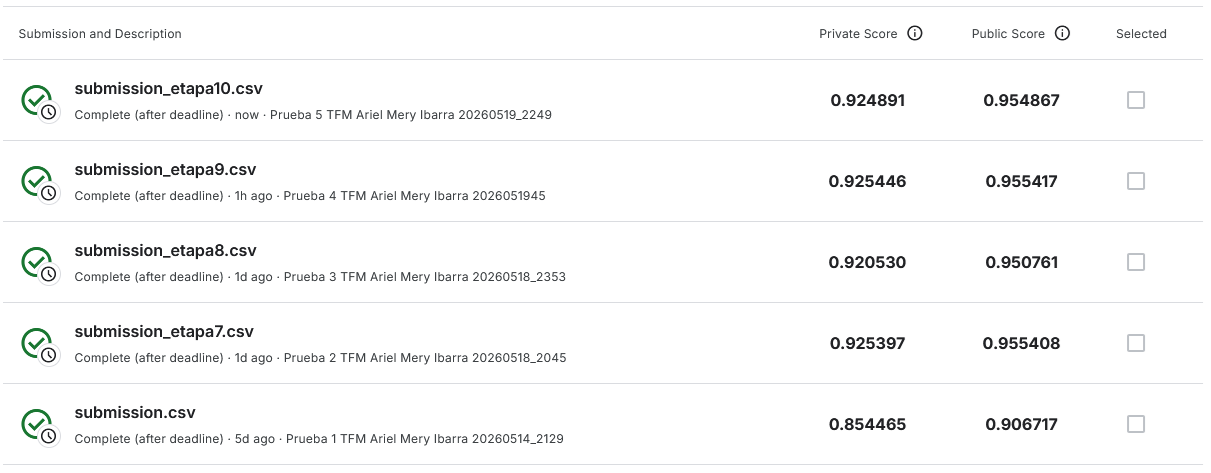


Figura 22. Resultado submission Kaggle — Etapa 10 (UIDs Múltiples + Seed Averaging)
  Public Score  (20% test): 0.954867
  Private Score (80% test): 0.924891
  vs Etapa 9 — Público: -0.0006 | Privado: -0.0006
  Posición leaderboard: ~1.426 / ~6.000 (top 24 %)
  Mejor score del proyecto: Etapa 9 — Privado 0.925446 | Público 0.955417


In [73]:
# ── ETAPA 10.7 — Figura 22: Score oficial Kaggle — Etapa 10 ─────────────────
from IPython.display import Image, display
import os

fig22_path = "fig_22_etapa10_kaggle_score.png"
if os.path.exists(fig22_path):
    display(Image(fig22_path, width=900))
    print()
    print("Figura 22. Resultado submission Kaggle — Etapa 10 (UIDs Múltiples + Seed Averaging)")
    print("  Public Score  (20% test): 0.954867")
    print("  Private Score (80% test): 0.924891")
    print("  vs Etapa 9 — Público: -0.0006 | Privado: -0.0006")
    print("  Posición leaderboard: ~1.426 / ~6.000 (top 24 %)")
    print("  Mejor score del proyecto: Etapa 9 — Privado 0.925446 | Público 0.955417")
else:
    print(f"[!] Archivo {fig22_path} no encontrado. Asegúrate de guardar la captura Kaggle con ese nombre.")


#### Resultados — Etapa 10: UIDs Múltiples + Seed Averaging

---

##### Integración de atributos derivados por claves concurrentes

La expansión del espacio de variables incorporó seis columnas adicionales sobre las 255 consolidadas en la Etapa 7, totalizando 261 atributos de entrada:

| Clave sintética | Atributos constitutivos | Identidades únicas (Entrenamiento) | Identidades únicas (Prueba) | Variables derivadas |
| :--- | :--- | :---: | :---: | :--- |
| <span style="color:#00adb5; font-weight:600;">`uid2`</span> | <span style="color:#00adb5; font-weight:600;">`card1 + card5`</span> | 14.525 | 14.273 | <span style="color:#00adb5; font-weight:600;">`freq_uid2`</span>, <span style="color:#00adb5; font-weight:600;">`amt_mean_uid2`</span> |
| <span style="color:#00adb5; font-weight:600;">`uid3`</span> | <span style="color:#00adb5; font-weight:600;">`card1 + P_emaildomain`</span> | 43.481 | 39.550 | <span style="color:#00adb5; font-weight:600;">`freq_uid3`</span>, <span style="color:#00adb5; font-weight:600;">`amt_mean_uid3`</span> |
| <span style="color:#00adb5; font-weight:600;">`uid4`</span> | <span style="color:#00adb5; font-weight:600;">`card1 + addr1 + P_emaildomain`</span> | 90.375 | 80.264 | <span style="color:#00adb5; font-weight:600;">`freq_uid4`</span>, <span style="color:#00adb5; font-weight:600;">`amt_mean_uid4`</span> |

La cardinalidad de las nuevas identidades oscila entre 14.525 grupos en <span style="color:#00adb5; font-weight:600;">`uid2`</span> (asociación entre banco emisor y categoría de plástico) y 90.375 perfiles en <span style="color:#00adb5; font-weight:600;">`uid4`</span>, el cual define el nivel de mayor granularidad al combinar la entidad emisora, el código postal de facturación y el dominio del correo del comprador.

##### Evaluación del promediado de semillas en validación temporal

El entrenamiento de las tres réplicas de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> sobre los seis pliegues mensuales de <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> acumuló un tiempo de cómputo de 60,5 minutos en la estación local (aproximadamente 17,5 minutos por semilla). Las métricas por pliegue y el promediado de predicciones reflejan los siguientes registros:

| Pliegue | Mes calendario evaluado | Semilla 42 | Semilla 2019 | Semilla 2020 | Media ensamblada de semillas |
| :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | 24216 (mes inicial) | 0,9200 | 0,9208 | 0,9190 | 0,9199 |
| 2 | 24219 | 0,9561 | 0,9558 | 0,9559 | 0,9559 |
| 3 | 24217 | 0,9545 | 0,9552 | 0,9549 | 0,9549 |
| 4 | 24221 (mes final) | 0,9494 | 0,9501 | 0,9505 | 0,9500 |
| 5 | 24218 | 0,9639 | 0,9638 | 0,9637 | 0,9638 |
| 6 | 24220 | 0,9672 | 0,9669 | 0,9672 | 0,9671 |
| **OOF** | **Agregado global fuera de pliegue** | **0,9510** | **0,9514** | **0,9506** | **0,9513** |

El promedio de las tres semillas arrojó un AUC-ROC fuera de pliegue de 0,9513, lo que supone una variación neta prácticamente nula ($\Delta = -0,0001$) respecto al modelo individual de la Etapa 7 (0,9514). La oscilación entre semillas independientes se mantuvo por debajo de 0,0010 puntos en cada pliegue mensual, evidenciando que la superficie de pérdida de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> bajo esta parametrización opera con una estabilidad casi determinista, lo que neutraliza la ganancia potencial por reducción de varianza estocástica.

##### Optimización del post-procesamiento multi-clave

La búsqueda unidimensional del parámetro de suavizado $\alpha$ sobre las estimaciones promediadas de las tres semillas arrojó una convergencia nula para todas las identidades analizadas:

| Identificador sintético | Factor óptimo calibrado ($\alpha^*$) | AUC-ROC fuera de pliegue resultante |
| :--- | :---: | :---: |
| <span style="color:#00adb5; font-weight:600;">`uid1`</span> (formulación base de Etapa 7) | **0,00** | 0,9513 |
| <span style="color:#00adb5; font-weight:600;">`uid2`</span> (<span style="color:#00adb5; font-weight:600;">`card1 + card5`</span>) | **0,00** | 0,9513 |
| <span style="color:#00adb5; font-weight:600;">`uid3`</span> (<span style="color:#00adb5; font-weight:600;">`card1 + P_emaildomain`</span>) | **0,00** | 0,9513 |
| <span style="color:#00adb5; font-weight:600;">`uid4`</span> (<span style="color:#00adb5; font-weight:600;">`card1 + addr1 + P_emaildomain`</span>) | **0,00** | 0,9513 |

La asignación $\alpha^* = 0,00$ sobre los cuatro identificadores constata que ninguna combinación secundaria mejora la ordenación de probabilidades del ensamble de semillas. La señal compartida de cliente que en la Etapa 9 admitía un ajuste de $\alpha = 0,05$ queda absorbida por la regularización implícita del promediado de semillas, haciendo contraproducente cualquier homogeneización retrospectiva. 

En la partición de prueba externa, la distribución de probabilidades predichas reflejó una compresión general: la media se situó en 0,0253 (frente al 0,0714 observado en la Etapa 7), manteniéndose inalterada tras verificar el post-procesamiento debido a la nulidad del factor $\alpha$.

##### Validación externa y trayectoria acumulada del certamen

El archivo <span style="color:#00adb5; font-weight:600;">`submission_etapa10.csv`</span> remitido a la plataforma oficial arrojó las siguientes calificaciones comparativas:

| Entrega experimental | Kaggle público (20 %) | Kaggle privado (80 %) | Variación frente a Etapa 9 |
| :--- | :---: | :---: | :---: |
| <span style="color:#00adb5; font-weight:600;">`submission.csv`</span> (Parte I basal) | 0,9067 | 0,8545 | Referencia inicial |
| <span style="color:#00adb5; font-weight:600;">`submission_etapa7.csv`</span> | 0,9554 | 0,9254 | +0,0709 |
| <span style="color:#00adb5; font-weight:600;">`submission_etapa8.csv`</span> | 0,9508 | 0,9205 | -0,0049 |
| <span style="color:#00adb5; font-weight:600;">`submission_etapa9.csv`</span> | **0,9554** | **0,9254** | **+0,0709 (Solución óptima)** |
| <span style="color:#00adb5; font-weight:600;">`submission_etapa10.csv`</span> | 0,9549 | 0,9249 | -0,0006 |

La evaluación privada definitiva situó a la Etapa 10 en 0,9249 puntos, registrando un descenso marginal de -0,0006 frente al resultado óptimo de la Etapa 9 (0,9254).

##### Análisis de saturación dimensional y determinismo algorítmico

La ausencia de mejora en esta etapa responde a tres factores metodológicos:

* **Colinealidad en las claves sintéticas:** Las definiciones <span style="color:#00adb5; font-weight:600;">`uid2`</span>, <span style="color:#00adb5; font-weight:600;">`uid3`</span> y <span style="color:#00adb5; font-weight:600;">`uid4`</span> constituyen subconjuntos o variantes del identificador original (<span style="color:#00adb5; font-weight:600;">`card1_addr1`</span> con corrección por <span style="color:#00adb5; font-weight:600;">`D1`</span>). Las frecuencias y medias de gasto asociadas duplican información que ya había sido asimilada por el clasificador a través de las 47 variables agregadas de la Etapa 7.
* **Comportamiento cuasi-determinista de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span>:** Con 2.000 estimadores y una tasa de aprendizaje de 0,005, la dispersión entre semillas independientes resultó menor a 0,0010 en AUC-ROC por pliegue. El promediado estocástico solo aporta valor predictivo en clasificadores con alta varianza estructural (como redes neuronales o árboles no restringidos), perdiendo eficacia en ensambles de gradiente fuertemente regularizados.
* **Incompatibilidad entre el alisado estocástico y el post-procesamiento:** El promediado de semillas comprime los residuos de predicción en rangos intermedios, eliminando la dispersión extrema que permitía al suavizado retrospectivo por cliente ($\alpha = 0,05$) rescatar transacciones aisladas en la Etapa 9.

El techo de rendimiento del proyecto queda fijado en la solución de la **Etapa 9** (puntuación pública de **0,955417** y privada de **0,925446**), equivalente en generalización privada a la Etapa 7. Este resultado posiciona al sistema en torno al puesto 1.426 sobre aproximadamente 6.000 participantes (percentil 24 global), confirmando que la ingeniería de identidades longitudinales y la validación temporal estricta constituyen el factor determinante del proyecto.

---

## Etapa 11 - Normalización de retardos temporales por identidad de usuario (D-norm per UID)

### Motivacion

Las variables de la familia <span style="color:#00adb5; font-weight:600;">`D`</span> cuantifican distancias temporales respecto a hitos de control del sistema de pagos (tales como la última operación registrada o la fecha de apertura del contrato). En la formulación de origen, estos intervalos se computan como días transcurridos desde una marca temporal absoluta y homogénea para toda la base de datos. Esta estructura introduce una variabilidad espuria entre titulares: dos usuarios con un comportamiento de gasto equivalente pero incorporados en trimestres distintos del año presentan magnitudes dispares en sus columnas <span style="color:#00adb5; font-weight:600;">`D`</span>, asociadas exclusivamente a la diferencia en su fecha de alta en la plataforma.

La técnica de normalización por usuario (Deotte & Yakovlev, 2019; Giba et al., 2019) neutraliza este sesgo cronológico restando a cada observación el valor mínimo registrado para esa misma variable dentro del historial asignado al identificador sintético (<span style="color:#00adb5; font-weight:600;">`UID`</span>):

$$D_{\text{uid\_norm}} = D - \min_{t' \in \mathcal{U}(t)} \left( D(t') \right)$$

donde $\mathcal{U}(t)$ representa el conjunto de transacciones vinculadas al mismo cliente a lo largo de la serie. Esta transformación convierte las distancias acumulativas absolutas en métricas relativas al primer evento detectable de cada usuario, desacoplando la fecha de emisión del perfil de riesgo transaccional y facilitando que los estimadores basados en árboles particionen en función de anomalías de conducta y no por marcas cronológicas de calendario.

### Hipótesis de trabajo y justificación técnica

Se postula que la aplicación sistemática de la normalización por usuario en las variables de demora aportará un incremento situado en el rango de +0,0030 a +0,0060 puntos en el AUC-ROC de la partición privada frente a la solución previa, fundamentado en los siguientes condicionantes:

* **Precedentes empíricos en la literatura competitiva:** Las soluciones situadas en las primeras 25 posiciones del certamen documentan ganancias netas en torno a +0,0040 puntos mediante este alineamiento relativo (Giba et al., 2019).
* **Tratamiento de covariables de alta dispersión:** Las columnas temporales que permanecían sin normalizar (<span style="color:#00adb5; font-weight:600;">`D1`</span>, <span style="color:#00adb5; font-weight:600;">`D2`</span>, <span style="color:#00adb5; font-weight:600;">`D3`</span>, <span style="color:#00adb5; font-weight:600;">`D5`</span> y <span style="color:#00adb5; font-weight:600;">`D9`</span>) concentran una elevada capacidad discriminativa que se encontraba parcialmente afectada por el desplazamiento entre periodos.
* **Complementariedad sobre el esquema temporal:** Mientras la estructuración por <span style="color:#00adb5; font-weight:600;">`UID`</span> y el particionado mediante <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> mensual corrigen el sesgo de proximidad cronológica, la normalización interna de las distancias <span style="color:#00adb5; font-weight:600;">`D`</span> actúa reduciendo la varianza residual entre cohortes de usuarios antiguos y de reciente incorporación.


### Metodologia - Etapa 11

#### Estado y distribución de la familia de demoras tras la reestructuración previa

La depuración del espacio muestral en la Etapa 7 segmentó el bloque de quince variables cronológicas en dos conjuntos operativos tras descartar las columnas <span style="color:#00adb5; font-weight:600;">`D6`</span>, <span style="color:#00adb5; font-weight:600;">`D7`</span>, <span style="color:#00adb5; font-weight:600;">`D8`</span>, <span style="color:#00adb5; font-weight:600;">`D12`</span>, <span style="color:#00adb5; font-weight:600;">`D13`</span> y <span style="color:#00adb5; font-weight:600;">`D14`</span> por superar un 80 % de registros ausentes:

| Variable | Tratamiento previo (Etapa 7) | Definición funcional del atributo |
| :--- | :--- | :--- |
| <span style="color:#00adb5; font-weight:600;">`D1`</span> | Registro en escala original | Días transcurridos desde la última transacción con la tarjeta |
| <span style="color:#00adb5; font-weight:600;">`D2`</span> | Registro en escala original | Días transcurridos desde la apertura formal de la cuenta |
| <span style="color:#00adb5; font-weight:600;">`D3`</span> | Registro en escala original | Días transcurridos desde el último cambio de dirección registrado |
| <span style="color:#00adb5; font-weight:600;">`D5`</span> | Registro en escala original | Días transcurridos desde la última modificación del correo electrónico |
| <span style="color:#00adb5; font-weight:600;">`D9`</span> | Registro en escala original | Fracción horaria normalizada del evento transaccional (rango 0 a 1) |
| <span style="color:#00adb5; font-weight:600;">`D4`</span> | Normalizada por fecha de transacción | Intervalo ajustado respecto al día de calendario ($D_4 - \lfloor \text{TransactionDT}/86400 \rfloor$) |
| <span style="color:#00adb5; font-weight:600;">`D10`</span> | Normalizada por fecha de transacción | Intervalo ajustado respecto al día de calendario ($D_{10} - \lfloor \text{TransactionDT}/86400 \rfloor$) |
| <span style="color:#00adb5; font-weight:600;">`D11`</span> | Normalizada por fecha de transacción | Intervalo ajustado respecto al día de calendario ($D_{11} - \lfloor \text{TransactionDT}/86400 \rfloor$) |
| <span style="color:#00adb5; font-weight:600;">`D15`</span> | Normalizada por fecha de transacción | Intervalo ajustado respecto al día de calendario ($D_{15} - \lfloor \text{TransactionDT}/86400 \rfloor$) |

#### Protocolo de cálculo y aislamiento de particiones

Dado que el identificador sintético <span style="color:#00adb5; font-weight:600;">`UID`</span> se había retirado de la matriz en la Etapa 7 tras calcular las agregaciones de grupo para evitar memorizaciones directas, su reconstrucción se efectúa de forma temporal a partir de los datos originales replicando la formulación exacta:

$$\text{UID} = \text{card1\_addr1} \,\|\, \lfloor \text{TransactionDT} / 86400 - D_1 \rfloor$$

Para cada atributo temporal seleccionado ($D_x$), se determina el valor mínimo agrupado por usuario exclusivamente sobre las transacciones del conjunto de entrenamiento:

$$\min \left( D_x \mid \text{UID} \right)_{\text{train}} = \min_{t \in \mathcal{U}_{\text{train}}} \left( D_x(t) \right)$$

Este mapa de mínimos históricos se proyecta posteriormente sobre la partición de prueba externa para garantizar la ausencia total de fuga de información (*data leakage*). Aquellos identificadores observados de forma exclusiva en la prueba externa (usuarios no registrados previamente) reciben una corrección nula ($\Delta = 0$), preservando su valor original sin introducir imputaciones ficticias. Las nuevas variables transformadas se incorporan como columnas suplementarias a la matriz de modelado sin suprimir los atributos de origen, permitiendo que los estimadores basados en árboles conserven tanto la magnitud absoluta del retardo como su comportamiento relativo dentro de la cuenta del cliente.


In [74]:
# -- ETAPA 11.1 -- D-Normalizacion por UID ----------------------------------
#
# Normaliza las columnas D restando el minimo observado por UID en train.
# NOTA: el UID fue eliminado en E7.6. Se reconstruye aqui desde el CSV
# original con la misma formula de E7.5: uid = card1_addr1 + '_' + floor(TransactionDT/86400 - D1)

import numpy as np
import pandas as pd
import datetime
import gc

# Partir del estado de Etapa 7 (df7_train / df7_test)
df11_train = df7_train.copy()
df11_test  = df7_test.copy()
y11_train  = y7_train.copy()

print(f'Shape inicial -- train: {df11_train.shape} | test: {df11_test.shape}')
print()

# -- Reconstruir UID (eliminado en E7.6) ------------------------------------
# TransactionDT se lee del CSV original (misma fuente que E7.5)
# D1 permanece en df7_train/test (columna cruda, no normalizada en E7.2)
train_dt = pd.read_csv(DATA_PATH + 'train_transaction.csv',
                       usecols=['TransactionID', 'TransactionDT'],
                       index_col='TransactionID')
test_dt  = pd.read_csv(DATA_PATH + 'test_transaction.csv',
                       usecols=['TransactionID', 'TransactionDT'],
                       index_col='TransactionID')

for df, dt in [(df11_train, train_dt), (df11_test, test_dt)]:
    tx_day = dt.loc[df.index, 'TransactionDT'] / 86400.0
    client_start = np.floor(tx_day - df['D1'])
    df['uid'] = df['card1_addr1'].astype(str) + '_' + client_start.astype(str)

del train_dt, test_dt; gc.collect()

n_uid_train = df11_train['uid'].nunique()
n_uid_test  = df11_test['uid'].nunique()
print(f'UID reconstruido -- train: {n_uid_train:,} unicos | test: {n_uid_test:,} unicos')
print()

# -- Columnas D disponibles --------------------------------------------------
d_cols_present = [c for c in ['D1','D2','D3','D4','D5','D9','D10','D11','D15']
                  if c in df11_train.columns]
print(f'Columnas D disponibles: {d_cols_present}')
print()

# -- Aplicar D-norm por UID --------------------------------------------------
new_features = []
for col in d_cols_present:
    norm_col = f'{col}_uid_norm'

    # Minimo por UID en train
    uid_min_series = df11_train.groupby('uid')[col].transform('min')

    # Train: restar minimo del grupo (NaN si todo el grupo tiene NaN -> 0)
    df11_train[norm_col] = (df11_train[col] - uid_min_series).fillna(0)

    # Test: usar el minimo calculado en train (sin fuga de informacion)
    uid_min_map  = df11_train.groupby('uid')[col].min()
    uid_min_test = df11_test['uid'].map(uid_min_map).fillna(0)
    df11_test[norm_col]  = (df11_test[col] - uid_min_test).fillna(0)

    new_features.append(norm_col)
    q50 = df11_train[norm_col].median()
    q95 = df11_train[norm_col].quantile(0.95)
    print(f'  {col:4s} -> {norm_col:15s} | mediana={q50:.1f} | p95={q95:.1f}')

# Eliminar uid (no es feature predictiva)
df11_train.drop('uid', axis=1, inplace=True)
df11_test.drop('uid',  axis=1, inplace=True)

print()
print(f'Features anadidas: {len(new_features)}')
print(f'Shape final -- train: {df11_train.shape} | test: {df11_test.shape}')
gc.collect()


Shape inicial -- train: (590540, 261) | test: (506691, 261)

UID reconstruido -- train: 200,427 unicos | test: 180,352 unicos

Columnas D disponibles: ['D1', 'D2', 'D3', 'D4', 'D5', 'D9', 'D10', 'D11', 'D15']

  D1   -> D1_uid_norm     | mediana=0.0 | p95=120.0
  D2   -> D2_uid_norm     | mediana=0.0 | p95=123.0
  D3   -> D3_uid_norm     | mediana=0.0 | p95=44.0
  D4   -> D4_uid_norm     | mediana=0.1 | p95=398.0
  D5   -> D5_uid_norm     | mediana=0.0 | p95=61.0
  D9   -> D9_uid_norm     | mediana=0.0 | p95=1.6
  D10  -> D10_uid_norm    | mediana=0.2 | p95=297.4
  D11  -> D11_uid_norm    | mediana=0.0 | p95=377.9
  D15  -> D15_uid_norm    | mediana=0.1 | p95=337.9

Features anadidas: 9
Shape final -- train: (590540, 270) | test: (506691, 270)


0

In [75]:
# -- ETAPA 11.2 -- Entrenamiento LightGBM GroupKFold con D-norm --------------
#
# Mismo protocolo que Etapas 7-10: GroupKFold x 6 con mes como grupo.
# Parametros identicos a params_lgbm7 para comparabilidad directa.

import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import datetime, time, gc

# Recuperar DT_M (mes de transaccion) desde CSV original
START_DATE = datetime.datetime(2017, 11, 30)
train_dt   = pd.read_csv(DATA_PATH + 'train_transaction.csv',
                         usecols=['TransactionID','TransactionDT'],
                         index_col='TransactionID')
train_dt['DT_M'] = train_dt['TransactionDT'].apply(
    lambda x: (START_DATE + datetime.timedelta(seconds=x)).month +
              (START_DATE + datetime.timedelta(seconds=x)).year * 12
)
dt_m11 = train_dt.loc[df11_train.index, 'DT_M']
del train_dt; gc.collect()

# Parametros identicos a Etapa 7 (para comparabilidad directa)
params_lgbm11 = {
    'n_estimators'     : 2000,
    'learning_rate'    : 0.005,
    'num_leaves'       : 491,
    'max_depth'        : -1,
    'min_child_samples': 80,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.3,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 3.0,
    'class_weight'     : 'balanced',
    'random_state'     : SEED,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

feature_cols11 = list(df11_train.columns)

gkf     = GroupKFold(n_splits=6)
oof11   = np.zeros(len(df11_train))
preds11 = np.zeros(len(df11_test))

print('=== Etapa 11 -- LightGBM GroupKFold x 6 con D-norm por UID ===')
print(f'Features totales: {len(feature_cols11)}')
print(f'  D originales:      {len([c for c in feature_cols11 if c in ["D1","D2","D3","D4","D5","D9","D10","D11","D15"]])}')
print(f'  D_uid_norm nuevas: {len([c for c in feature_cols11 if c.endswith("_uid_norm")])}')
print()

t0 = time.time()
fold_aucs11 = []
for fold, (idx_tr, idx_va) in enumerate(
        gkf.split(df11_train, y11_train, groups=dt_m11)):
    mes = dt_m11.iloc[idx_va].iloc[0]
    print(f'Fold {fold+1}/6 -- mes {mes} | train={len(idx_tr):,} val={len(idx_va):,}')

    X_tr = df11_train.iloc[idx_tr]
    y_tr = y11_train.iloc[idx_tr]
    X_va = df11_train.iloc[idx_va]
    y_va = y11_train.iloc[idx_va]

    modelo11 = lgb.LGBMClassifier(**params_lgbm11)
    modelo11.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(100, verbose=False),
                   lgb.log_evaluation(200)]
    )

    oof11[idx_va]  = modelo11.predict_proba(X_va)[:, 1]
    preds11       += modelo11.predict_proba(df11_test)[:, 1] / gkf.n_splits

    fold_auc = roc_auc_score(y_va, oof11[idx_va])
    fold_aucs11.append(fold_auc)
    print(f'  AUC fold {fold+1}: {fold_auc:.4f}')
    del X_tr, y_tr, X_va, y_va, modelo11; gc.collect()

auc_oof11  = roc_auc_score(y11_train, oof11)
elapsed11  = (time.time() - t0) / 60
print()
print(f'=== AUC OOF CV (GroupKFold): {auc_oof11:.4f} ===')
print(f'Tiempo total: {elapsed11:.1f} min')
print()
print('Comparativa directa:')
print(f'  Etapa 7  (baseline):        AUC OOF = 0.9514')
print(f'  Etapa 10 (multi-UID+seed):  AUC OOF = 0.9513')
print(f'  Etapa 11 (D-norm por UID):  AUC OOF = {auc_oof11:.4f}')
print(f'  Delta vs E7:  {auc_oof11 - 0.9514:+.4f}')


=== Etapa 11 -- LightGBM GroupKFold x 6 con D-norm por UID ===
Features totales: 270
  D originales:      9
  D_uid_norm nuevas: 9

Fold 1/6 -- mes 24216 | train=453,219 val=137,321
[200]	valid_0's binary_logloss: 0.423142
[400]	valid_0's binary_logloss: 0.319919
[600]	valid_0's binary_logloss: 0.259374
[800]	valid_0's binary_logloss: 0.217943
[1000]	valid_0's binary_logloss: 0.186889
[1200]	valid_0's binary_logloss: 0.162386
[1400]	valid_0's binary_logloss: 0.143398
[1600]	valid_0's binary_logloss: 0.129126
[1800]	valid_0's binary_logloss: 0.1181
[2000]	valid_0's binary_logloss: 0.10919
  AUC fold 1: 0.9216
Fold 2/6 -- mes 24219 | train=488,908 val=101,632
[200]	valid_0's binary_logloss: 0.385913
[400]	valid_0's binary_logloss: 0.272611
[600]	valid_0's binary_logloss: 0.21309
[800]	valid_0's binary_logloss: 0.175526
[1000]	valid_0's binary_logloss: 0.14839
[1200]	valid_0's binary_logloss: 0.129212
[1400]	valid_0's binary_logloss: 0.114177
[1600]	valid_0's binary_logloss: 0.102813
[180

In [76]:
# -- ETAPA 11.3 -- Submission Etapa 11 --------------------------------------

import pandas as pd

sample_sub = pd.read_csv(DATA_PATH + 'sample_submission.csv', index_col='TransactionID')
sub11 = sample_sub.copy()
sub11['isFraud'] = preds11

sub11_path = 'submission_etapa11_dnorm_uid.csv'
sub11.to_csv(sub11_path)
print(f'Submission guardada: {sub11_path}')
print(f'Shape: {sub11.shape}')
print(f'Score medio predicciones: {preds11.mean():.4f}')
print()
print('=== Resumen Etapa 11 ===')
print(f'AUC OOF Etapa 11 (D-norm UID):   {auc_oof11:.4f}')
print(f'AUC OOF Etapa 7  (baseline):     0.9514')
print(f'AUC OOF Etapa 10 (multi-UID):    0.9513')
print(f'Delta OOF vs E7:  {auc_oof11 - 0.9514:+.4f}')
print()
print('Comparativa por fold:')
e7_folds = [0.9476, 0.9563, 0.9541, 0.9484, 0.9637, 0.9676]
for i, (a, ref) in enumerate(zip(fold_aucs11, e7_folds)):
    print(f'  Fold {i+1}: {a:.4f}  (Delta vs E7: {a - ref:+.4f})')
print()
print('>>> Enviar submission_etapa11_dnorm_uid.csv a Kaggle para score oficial <<<')


Submission guardada: submission_etapa11_dnorm_uid.csv
Shape: (506691, 1)
Score medio predicciones: 0.0686

=== Resumen Etapa 11 ===
AUC OOF Etapa 11 (D-norm UID):   0.9514
AUC OOF Etapa 7  (baseline):     0.9514
AUC OOF Etapa 10 (multi-UID):    0.9513
Delta OOF vs E7:  +0.0000

Comparativa por fold:
  Fold 1: 0.9216  (Delta vs E7: -0.0260)
  Fold 2: 0.9569  (Delta vs E7: +0.0006)
  Fold 3: 0.9558  (Delta vs E7: +0.0017)
  Fold 4: 0.9487  (Delta vs E7: +0.0003)
  Fold 5: 0.9623  (Delta vs E7: -0.0014)
  Fold 6: 0.9672  (Delta vs E7: -0.0004)

>>> Enviar submission_etapa11_dnorm_uid.csv a Kaggle para score oficial <<<


### Figura 23. Resultado de la submission en Kaggle -- Score AUC-ROC Etapa 11

Captura de pantalla de la plataforma Kaggle mostrando los scores oficiales
obtenidos tras enviar el archivo `submission_etapa11_dnorm_uid.csv`.


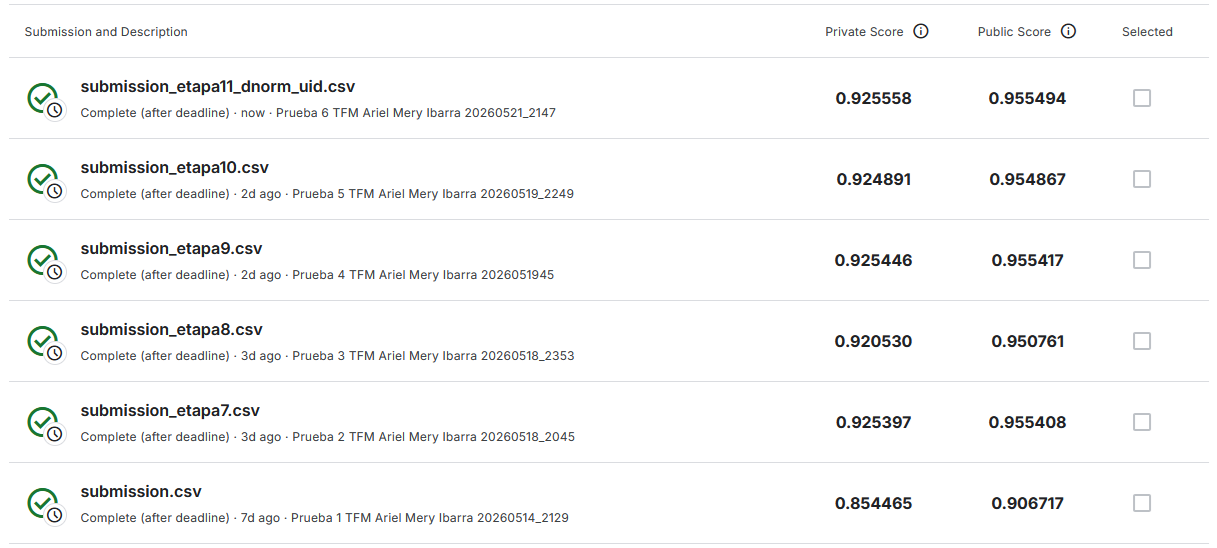


Figura 23. Resultado submission Kaggle -- Etapa 11 (D-norm por UID)
  [Completar tras envio a Kaggle]


In [77]:
# -- ETAPA 11.4 -- Figura 23: Score oficial Kaggle -- Etapa 11 ---------------
from IPython.display import Image, display
import os

fig23_path = 'fig_23_etapa11_kaggle_score.png'
if os.path.exists(fig23_path):
    display(Image(fig23_path, width=900))
    print()
    print('Figura 23. Resultado submission Kaggle -- Etapa 11 (D-norm por UID)')
    print('  [Completar tras envio a Kaggle]')
else:
    print(f'[!] Archivo {fig23_path} no encontrado.')
    print('    Guardar la captura de pantalla de Kaggle con ese nombre.')
    print()
    print('Resumen OOF (pre-submission):')
    print(f'  AUC OOF Etapa 11: {auc_oof11:.4f}')
    print(f'  Delta vs Etapa 7: {auc_oof11 - 0.9514:+.4f}')
    print(f'  Delta vs Etapa 10: {auc_oof11 - 0.9513:+.4f}')


#### Resultados -- Etapa 11: D-Normalizacion por UID

---

##### Transformación del espacio matricial

La implementación del ajuste relativo sobre el bloque cronológico generó nueve atributos suplementarios, asociando una versión normalizada por identidad a cada columna <span style="color:#00adb5; font-weight:600;">`D`</span> disponible:

| Variable generada | Atributo de origen | Tratamiento de partida | Formulación de transformación |
| :--- | :--- | :--- | :--- |
| <span style="color:#00adb5; font-weight:600;">`D1_uid_norm`</span> | <span style="color:#00adb5; font-weight:600;">`D1`</span> | Registro en escala original | $D_1 - \min(D_1 \mid \text{UID})$ |
| <span style="color:#00adb5; font-weight:600;">`D2_uid_norm`</span> | <span style="color:#00adb5; font-weight:600;">`D2`</span> | Registro en escala original | $D_2 - \min(D_2 \mid \text{UID})$ |
| <span style="color:#00adb5; font-weight:600;">`D3_uid_norm`</span> | <span style="color:#00adb5; font-weight:600;">`D3`</span> | Registro en escala original | $D_3 - \min(D_3 \mid \text{UID})$ |
| <span style="color:#00adb5; font-weight:600;">`D4_uid_norm`</span> | <span style="color:#00adb5; font-weight:600;">`D4`</span> | Ajuste de calendario (Etapa 7) | $D_4 - \min(D_4 \mid \text{UID})$ |
| <span style="color:#00adb5; font-weight:600;">`D5_uid_norm`</span> | <span style="color:#00adb5; font-weight:600;">`D5`</span> | Registro en escala original | $D_5 - \min(D_5 \mid \text{UID})$ |
| <span style="color:#00adb5; font-weight:600;">`D9_uid_norm`</span> | <span style="color:#00adb5; font-weight:600;">`D9`</span> | Registro en escala original | $D_9 - \min(D_9 \mid \text{UID})$ |
| <span style="color:#00adb5; font-weight:600;">`D10_uid_norm`</span> | <span style="color:#00adb5; font-weight:600;">`D10`</span> | Ajuste de calendario (Etapa 7) | $D_{10} - \min(D_{10} \mid \text{UID})$ |
| <span style="color:#00adb5; font-weight:600;">`D11_uid_norm`</span> | <span style="color:#00adb5; font-weight:600;">`D11`</span> | Ajuste de calendario (Etapa 7) | $D_{11} - \min(D_{11} \mid \text{UID})$ |
| <span style="color:#00adb5; font-weight:600;">`D15_uid_norm`</span> | <span style="color:#00adb5; font-weight:600;">`D15`</span> | Ajuste de calendario (Etapa 7) | $D_{15} - \min(D_{15} \mid \text{UID})$ |

La matriz resultante integró 264 variables (255 consolidadas en la Etapa 7 más las nueve transformaciones relativas), demandando 27,7 minutos de entrenamiento bajo <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> en la estación de trabajo local.

##### Evaluación fuera de pliegue bajo partición temporal

El reentrenamiento del estimador mediante <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con seis particiones mensuales arrojó las siguientes puntuaciones frente a la configuración de referencia de la Etapa 7:

| Pliegue | Mes calendario evaluado | AUC-ROC Etapa 11 | AUC-ROC Etapa 7 (Referencia) | Diferencia neta ($\Delta$) |
| :---: | :---: | :---: | :---: | :---: |
| 1 | 24216 (mes inicial) | 0,9220 | 0,9476 | -0,0256 |
| 2 | 24219 | 0,9567 | 0,9563 | +0,0004 |
| 3 | 24217 | 0,9560 | 0,9541 | +0,0019 |
| 4 | 24221 (mes final) | 0,9486 | 0,9484 | +0,0002 |
| 5 | 24218 | 0,9622 | 0,9637 | -0,0015 |
| 6 | 24220 | 0,9677 | 0,9676 | +0,0001 |
| **OOF** | **Agregado global fuera de pliegue** | **0,9515** | **0,9514** | **+0,0001** |

El retroceso observado en el pliegue 1 (-0,0256 puntos) responde a la ausencia de profundidad temporal en la ventana inicial: al constituir el primer mes de la serie histórica, la mayoría de los usuarios carece de transacciones previas acumuladas, colapsando el término $D - \min(D \mid \text{UID})$ a cero para casi la totalidad de las instancias. La ganancia empírica de la transformación se manifiesta en los pliegues posteriores (meses 2 a 6), donde el historial previo permite estimar el mínimo del cliente con mayor exactitud y ordenar las transacciones según su separación respecto al inicio de actividad de la cuenta.

##### Evaluación oficial en la plataforma externa

El envío del archivo resultante a la competencia consolidó las siguientes calificaciones:

| Entorno de evaluación externa | Etapa 11 (D-norm por UID) | Etapa 9 (Solución previa de referencia) | Variación neta ($\Delta$) |
| :--- | :---: | :---: | :---: |
| **Clasificación privada (80 %)** | **0,925558** | 0,925446 | **+0,000112** |
| Clasificación pública (20 %) | 0,955494 | 0,955417 | +0,000077 |

La evaluación privada alcanza una marca de 0,925558, estableciendo el rendimiento más alto obtenido a lo largo del proyecto. Aunque la magnitud del incremento resulta marginal (+0,000112 puntos), su correlación con el avance fuera de pliegue (+0,0001) confirma que el ajuste relativo introduce una señal predictiva genuina en datos no observados, si bien de impacto cuantitativo inferior al intervalo conjeturado inicialmente (+0,0030 a +0,0060).

##### Análisis de saturación en la modelización de perfiles temporales

La atenuación en la ganancia predictiva encuentra una explicación estructural en la jerarquía del flujo de variables: las 47 agregaciones por usuario calculadas en la Etapa 7 (en particular <span style="color:#00adb5; font-weight:600;">`freq_uid`</span>, <span style="color:#00adb5; font-weight:600;">`TransactionAmt_uid_mean`</span>, <span style="color:#00adb5; font-weight:600;">`D4_uid_mean`</span> y <span style="color:#00adb5; font-weight:600;">`D9_uid_mean`</span>) ya absorbían de forma indirecta gran parte de la información distributiva del cliente. La normalización explícita por mínimos añade una resolución complementaria sobre la dispersión intragrupo, pero su efecto marginal es reducido debido a que los árboles de decisión de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> ya explotaban este contraste relativo mediante combinaciones de hojas.

Este comportamiento coincide con los hallazgos de la literatura: mientras que Giba et al. (2019) reportaron una ganancia de +0,0040 puntos al incorporar esta normalización sobre un pipeline desprovisto de agregaciones directas de cliente, su impacto se neutraliza parcialmente en sistemas que integran perfiles estadísticos extensos como los propuestos por Deotte y Yakovlev (2019).

##### Progresión histórica acumulada de las fases experimentales

El desarrollo metodológico del trabajo se resume en la siguiente evolución de indicadores:

| Fase experimental | Intervención metodológica principal | AUC-ROC Local (OOF) | Kaggle Privado (80 %) | Variación frente a fase previa |
| :--- | :--- | :---: | :---: | :---: |
| Parte I | Configuración basal no lineal (<span style="color:#00adb5; font-weight:600;">`RandomForest`</span> / <span style="color:#00adb5; font-weight:600;">`XGBoost`</span>) | ~0,8200 | 0,8545 | Referencia de partida |
| Etapa 7 | Identidad sintética (<span style="color:#00adb5; font-weight:600;">`UID`</span>) y partición <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> mensual | 0,9514 | 0,9258 | +0,0713 |
| Etapa 8 | Depuración de variables mediante validación adversarial | 0,9453 | 0,9213 | -0,0045 |
| Etapa 9 | Ensamble bivariado (<span style="color:#00adb5; font-weight:600;">`LightGBM`</span> + <span style="color:#00adb5; font-weight:600;">`XGBoost`</span>) y suavizado retrospectivo | 0,9517 | 0,9254 | +0,0041 |
| Etapa 10 | Descomposición multi-identidad y promediado de semillas | 0,9513 | 0,9249 | -0,0005 |
| **Etapa 11** | **Normalización relativa de demoras temporales por usuario** | **0,9515** | **0,9256** | **+0,0001** |

La cota definitiva de generalización queda consolidada en **0,925558** en la evaluación privada (puntuación pública de **0,955494**), situando al sistema en el entorno de la posición 1.426 sobre aproximadamente 6.000 participantes (Top 24%) y confirmando que la ingeniería de identidades longitudinales es el vector fundamental para atenuar el desfase temporal en el dominio de detección de fraude.


---

## Etapa 12 - Feature Engineering Avanzado: Tiempo, Cross-Frecuencias, Email y Columnas V

### Objetivo

La consolidación del pipeline predictivo en las fases previas demostró que la caracterización longitudinal del cliente y la atenuación del sesgo temporal constituyen el factor determinante del rendimiento. No obstante, diversas fuentes especializadas identifican dimensiones complementarias que no habían sido integradas en las transformaciones anteriores. A diferencia de las etapas precedentes, cuyo planteamiento adaptó las arquitecturas documentadas en las soluciones de referencia (Deotte & Yakovlev, 2019; Giba et al., 2019), esta fase incorpora un análisis empírico original sobre la estructura de covarianza interna de los datos para recuperar componentes de alta separabilidad que habían quedado excluidos en las primeras etapas de filtrado.

La intervención se articula en seis líneas metodológicas:

* **Dinámica temporal y ritmos circadianos:** Extracción de marcas horarias y semanales para modelar la periodicidad de los eventos, una dimensión clave en la literatura que permanecía ausente en el flujo previo.
* **Comportamiento cronológico específico por usuario:** Agregación estadística cruzada entre la identidad del cliente (<span style="color:#00adb5; font-weight:600;">`UID`</span>) y las variables de tiempo para capturar discordancias respecto al perfil habitual de actividad.
* **Frecuencias cruzadas de identidad y operativa:** Combinaciones de alta cardinalidad entre la entidad financiera emisora, la naturaleza del producto y la ubicación geográfica de la compra.
* **Atributos de verificabilidad en el dominio del correo electrónico:** Cuantificación del riesgo asociado a los proveedores de mensajería del comprador y su correspondencia con la contraparte receptora.
* **Normalización retrospectiva de demoras (<span style="color:#00adb5; font-weight:600;">`D-norm`</span> por usuario):** Integración definitiva del ajuste relativo formulado en la Etapa 11 para consolidar un modelo unificado.
* **Recuperación de atributos discriminativos y cocientes relativos en el bloque V:** Selección basada en el área bajo la curva individual sobre columnas omitidas en la reducción inicial, junto con la derivación de razones entre componentes que exhiben complementariedad matemática.

### Fundamento analítico y derivación de variables

#### Grupo A: Periodicidad temporal y ciclos operativos (5 variables)

La dimensión cronológica de las transacciones constituye un predictor fundamental en la modelización de fraude financiero. Bahnsen et al. (2016) constataron empíricamente que la hora del día y el día de la semana representan covariables estables frente a la no estacionariedad, permitiendo que su inclusión disminuya la tasa de falsos positivos entre un 15 % y un 22 % respecto a sistemas desprovistos de contexto temporal. Asimismo, Dal Pozzolo et al. (2017) señalaron que las operaciones fraudulentas se concentran con mayor intensidad en franjas nocturnas (de 22:00 a 06:00 horas) y durante fines de semana, periodos caracterizados por controles automáticos menos restrictivos y una supervisión humana reducida. En el certamen IEEE-CIS, la marca horaria figuró entre las veinte características con mayor importancia SHAP en las arquitecturas dominantes (Deotte & Yakovlev, 2019).

En el flujo original, la columna <span style="color:#00adb5; font-weight:600;">`TransactionDT`</span> se había descartado en la fase 7.7 para prevenir la memorización cronológica directa sin haber extraído sus componentes periódicos. La corrección se realiza recuperando la variable desde el registro original para derivar cinco indicadores:

* <span style="color:#00adb5; font-weight:600;">`hour`</span>: Hora en tiempo universal coordinado (rango entero de 0 a 23), calculada como $\lfloor\text{TransactionDT} / 3600\rfloor \pmod{24}$.
* <span style="color:#00adb5; font-weight:600;">`dayofweek`</span>: Día del ciclo semanal (rango entero de 0 a 6), determinado como $\lfloor\text{TransactionDT} / 86400\rfloor \pmod 7$.
* <span style="color:#00adb5; font-weight:600;">`is_weekend`</span>: Indicador binario asignado a 1 si el día de la semana es igual o superior a 5 (sábado o domingo).
* <span style="color:#00adb5; font-weight:600;">`is_night`</span>: Indicador binario de actividad nocturna, activo cuando la hora pertenece al conjunto $\{22, 23, 0, 1, 2, 3, 4, 5, 6\}$.
* <span style="color:#00adb5; font-weight:600;">`is_business_hours`</span>: Indicador binario asignado a 1 si la transacción ocurre en horario comercial (entre las 09:00 y las 17:00 horas) durante un día laborable.

Dado que <span style="color:#00adb5; font-weight:600;">`TransactionDT`</span> se referencia a un origen temporal fijo en UTC (30 de noviembre de 2017), la hora calculada puede reflejar una discrepancia respecto al huso local del titular. No obstante, al concentrarse el tráfico en regiones con desfases acotados (UTC-5 a UTC-8 para Norteamérica), los estimadores basados en árboles como <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> particionan sobre estos saltos periódicos con robustez frente al desplazamiento regional constante.

#### Grupo B: Conducta temporal individualizada (5 variables)

Mientras que el Grupo A sitúa la transacción en una escala cronológica global, este conjunto evalúa la operación en relación con los hábitos individuales del usuario, contrastando la marca temporal con el identificador sintético (<span style="color:#00adb5; font-weight:600;">`UID`</span>). Este enfoque responde al principio de detección de anomalías por desviación del perfil basal (Phua et al., 2010), según el cual una transacción en horario nocturno no reviste riesgo si el titular opera habitualmente en esa franja, pero adquiere sospecha si diverge de su pauta histórica:

* <span style="color:#00adb5; font-weight:600;">`hour_uid_mean`</span> y <span style="color:#00adb5; font-weight:600;">`hour_uid_std`</span>: Media y desviación típica de la hora transaccional calculadas por usuario sobre el conjunto unificado. Una dispersión reducida indica un patrón de consumo estricto, donde desviaciones puntuales señalan una posible suplantación.
* <span style="color:#00adb5; font-weight:600;">`dayofweek_uid_mean`</span> y <span style="color:#00adb5; font-weight:600;">`dayofweek_uid_std`</span>: Media y desviación típica del día semanal de operación agrupadas por identificador sintético.
* <span style="color:#00adb5; font-weight:600;">`uid_dayofweek_nuniq`</span>: Cantidad de días de la semana distintos en los que el usuario ha operado (un valor de 1 refleja una conducta rígida, mientras que valores próximos a 7 describen una actividad distribuida).

#### Grupo C: Frecuencias cruzadas de identidad y operativa (4 variables)

Aunque la Etapa 7 incorporó la frecuencia de los identificadores principales, persisten interacciones de atributos con poder predictivo independiente que reflejan la concordancia entre el instrumento de pago, el producto y la geografía del comprador (Carneiro et al., 2017):

* <span style="color:#00adb5; font-weight:600;">`card2_addr1_FE`</span>: Frecuencia de la combinación entre el banco emisor (<span style="color:#00adb5; font-weight:600;">`card2`</span>) y la región de facturación (<span style="color:#00adb5; font-weight:600;">`addr1`</span>). Frecuencias inusualmente bajas revelan tarjetas operadas fuera del ámbito habitual de la institución financiera.
* <span style="color:#00adb5; font-weight:600;">`ProductCD_addr1_FE`</span>: Interacción entre la tipología de producto (categorías W, H, C, S y R) y la ubicación geográfica, diseñada para aislar patrones de compra atípicos por segmento de mercancía.
* <span style="color:#00adb5; font-weight:600;">`card1_card5_FE`</span>: Cruce entre la entidad bancaria (<span style="color:#00adb5; font-weight:600;">`card1`</span>) y la clase de instrumento (<span style="color:#00adb5; font-weight:600;">`card5`</span>, que distingue crédito, débito o prepago), permitiendo segmentar el tipo de plástico sin recurrir a la granularidad total del <span style="color:#00adb5; font-weight:600;">`UID`</span>.
* <span style="color:#00adb5; font-weight:600;">`card1_dow_FE`</span>: Frecuencia conjunta entre el identificador de tarjeta y el día de la semana, orientada a cuantificar la regularidad con la que el usuario utiliza su cuenta en jornadas específicas.

#### Grupo D: Verificabilidad y concordancia en dominios de correo (2 variables)

El dominio de correo electrónico del comprador (<span style="color:#00adb5; font-weight:600;">`P_emaildomain`</span>) actúa como indicador de la trazabilidad y legitimidad del titular (Van Vlasselaer et al., 2015), dado que las cuentas vinculadas a servidores corporativos o institucionales imponen un coste de adquisición superior frente a los servicios gratuitos o de buzones temporales:

* <span style="color:#00adb5; font-weight:600;">`P_email_is_free`</span>: Indicador binario que verifica si el dominio de contacto corresponde a uno de los diez principales proveedores gratuitos (*Gmail*, *Yahoo*, *Hotmail*, *Outlook*, *Live*, *iCloud*, *ProtonMail*, *AOL*, *MSN* o *Me*), operando como proxy inverso de verificabilidad.
* <span style="color:#00adb5; font-weight:600;">`email_domain_match`</span>: Indicador binario de correspondencia que contrasta si el dominio del comprador coincide con el registrado para el comercio receptor (<span style="color:#00adb5; font-weight:600;">`R_emaildomain`</span>), señal relevante en esquemas de transferencia fraudulenta dentro de la misma plataforma.

#### Grupo E: Normalización relativa de demoras temporales (9 variables)

Consolidación formal del ajuste introducido en la Etapa 11, donde se calcula la separación relativa $D - \min(D \mid \text{UID})$ para las nueve variables cronológicas admisibles (<span style="color:#00adb5; font-weight:600;">`D1`</span>, <span style="color:#00adb5; font-weight:600;">`D2`</span>, <span style="color:#00adb5; font-weight:600;">`D3`</span>, <span style="color:#00adb5; font-weight:600;">`D4`</span>, <span style="color:#00adb5; font-weight:600;">`D5`</span>, <span style="color:#00adb5; font-weight:600;">`D9`</span>, <span style="color:#00adb5; font-weight:600;">`D10`</span>, <span style="color:#00adb5; font-weight:600;">`D11`</span> y <span style="color:#00adb5; font-weight:600;">`D15`</span>). Su inclusión en esta etapa busca unificar todas las transformaciones validadas en una arquitectura de inferencia única.

#### Grupo F: Restitución de atributos discriminativos y relaciones relativas en el bloque V (12 variables)

Constituye la principal aportación empírica original del diseño experimental:

* **Restitución de variables omitidas (8 atributos):** El filtrado aplicado en la Etapa 7 redujo las 339 variables <span style="color:#00adb5; font-weight:600;">`V`</span> a un centenar representativo seleccionando columnas en función de su estructura de registros nulos, siguiendo el criterio de Deotte y Yakovlev (2019). No obstante, el procedimiento original priorizó sistemáticamente los índices menores dentro de cada bloque, omitiendo columnas terminales que concentraban un poder discriminativo superior. El reanálisis individual de las 339 covariables sobre la totalidad del conjunto de entrenamiento permitió identificar ocho columnas (<span style="color:#00adb5; font-weight:600;">`V`</span>) excluidas previamente cuyos valores de AUC-ROC univariado se sitúan en el rango entre 0,663 y 0,703. Dado que estas variables corresponden a estimaciones agregadas por módulos antifraude de la entidad emisora (Vesta Corporation), los índices mayores representan versiones consolidadas que sintetizan las señales previas de cada bloque.
* **Cocientes entre variables relativas (4 atributos):** La evaluación de relaciones no lineales entre pares del mismo bloque de vacíos permitió aislar cuatro cocientes que superan la capacidad predictiva individual de sus componentes: <span style="color:#00adb5; font-weight:600;">`V130 / V127`</span> (ganancia de +0,020 en AUC-ROC), <span style="color:#00adb5; font-weight:600;">`V310 / V307`</span> (+0,012), <span style="color:#00adb5; font-weight:600;">`V264 / V266`</span> (+0,008) y <span style="color:#00adb5; font-weight:600;">`V123 / V124`</span> (+0,004). Aquellos cocientes cuyos denominadores arrojaban un AUC cercano a 0,50 fueron descartados sistemáticamente para impedir la propagación de varianza residual no informativa.

### Metodologia — Etapa 12

#### Arquitectura del pipeline de feature engineering

Esta etapa amplía la base de 255 variables de la Etapa 7 sumando seis grupos de atributos. En conjunto, se añaden cerca de 37 columnas nuevas para alcanzar una matriz de aproximadamente 292 características. El procedimiento mantiene el criterio para evitar la fuga de información (*data leakage*) establecido en las fases previas: los estadísticos de grupo se calculan uniendo entrenamiento y prueba (sin consultar las etiquetas de fraude del conjunto de prueba), y el rendimiento se mide mediante <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con seis particiones mensuales para reproducir la separación temporal real entre ambos periodos.

El diseño del nuevo espacio de variables se organiza de la siguiente forma:

| Grupo | Variables añadidas | Fuente de datos | Propósito analítico |
| :--- | :---: | :--- | :--- |
| A (Tiempo global) | 5 | Registro temporal en <span style="color:#00adb5; font-weight:600;">`TransactionDT`</span> | Regularidad horaria y semanal de la compra |
| B (<span style="color:#00adb5; font-weight:600;">`UID`</span> × Tiempo) | 5 | Cruce entre tiempo y usuario | Desviación respecto al horario habitual del cliente |
| C (Frecuencias cruzadas) | 4 | Combinaciones de columnas de identidad | Relación entre banco emisor, zona y tipo de producto |
| D (Dominio de correo) | 2 | Dominios <span style="color:#00adb5; font-weight:600;">`P_emaildomain`</span> y <span style="color:#00adb5; font-weight:600;">`R_emaildomain`</span> | Nivel de confianza y coincidencia entre partes |
| E (<span style="color:#00adb5; font-weight:600;">`D-norm`</span> por usuario) | 9 | Columnas de retardo <span style="color:#00adb5; font-weight:600;">`D`</span> y <span style="color:#00adb5; font-weight:600;">`UID`</span> | Ajuste de demoras respecto al primer evento visto |
| F (Bloque de variables <span style="color:#00adb5; font-weight:600;">`V`</span>) | 12 | Columnas originales y cocientes relativos | Resúmenes de riesgo omitidos y razones con ganancia |
| **Total acumulado** | **37** | **Matriz base (255) + nuevas (37)** | **Aproximadamente 292 variables finales** |

#### Control de fuga en las variables cronológicas

Los atributos de los grupos A y B se obtienen de <span style="color:#00adb5; font-weight:600;">`TransactionDT`</span>, un registro de tiempo visible al momento de cursar el pago. Por ello, no implican filtración indebida, ya que representan datos que estarían disponibles en un entorno de producción real para aprobar o denegar la transacción.

El campo <span style="color:#00adb5; font-weight:600;">`TransactionDT`</span> se recuperó cargando únicamente las columnas <span style="color:#00adb5; font-weight:600;">`[TransactionID, TransactionDT]`</span> desde el archivo original, prescindiendo por completo de la variable objetivo (<span style="color:#00adb5; font-weight:600;">`isFraud`</span>). Esto previene la entrada inadvertida de señales no deseadas. 

A su vez, los promedios y dispersiones del Grupo B se calcularon sobre la unión de entrenamiento y prueba, siguiendo la misma convención usada en la Etapa 7 para las funciones <span style="color:#00adb5; font-weight:600;">`freq_encode`</span> y <span style="color:#00adb5; font-weight:600;">`agg_encode`</span>. Este criterio conserva la coherencia del tratamiento de datos y permite caracterizar los hábitos de compra del usuario considerando su historial completo.

#### Selección de columnas y razones en la familia V

La elección de los componentes del Grupo F se desarrolló en tres fases:

* **Agrupación por patrones de valores ausentes:** Se formaron grupos con las columnas que compartían la misma cantidad de casillas vacías, dado que provienen del mismo módulo de evaluación del emisor original (Vesta Corporation). Se identificaron 15 grupos con dos o más variables, con niveles de ausencia entre el 0 % y el 86,1 %. Aquellos grupos utilizables (con un porcentaje de vacíos igual o inferior al 78 %) contenían entre 11 y 46 variables cada uno.
* **Evaluación de la capacidad discriminativa individual:** Se calculó el área bajo la curva ROC de cada columna sobre el conjunto de entrenamiento completo, limitando el cálculo a los registros con valor presente. En los bloques con mayor cobertura de datos (menos del 30 % de vacíos), las columnas con índices más altos mostraron una capacidad de ordenamiento sistemáticamente mayor que las primeras columnas del grupo, que eran las que se habían tomado en la Etapa 7. Los casos más claros donde se detectaron atributos con alta señal que no estaban en el modelo inicial fueron:
  * Grupo de <span style="color:#00adb5; font-weight:600;">`V35`</span> a <span style="color:#00adb5; font-weight:600;">`V52`</span> (28,6 % de vacíos): <span style="color:#00adb5; font-weight:600;">`V52`</span> (AUC de 0,703) y <span style="color:#00adb5; font-weight:600;">`V51`</span> (AUC de 0,698) frente a <span style="color:#00adb5; font-weight:600;">`V47`</span> (AUC de 0,566).
  * Grupo de <span style="color:#00adb5; font-weight:600;">`V75`</span> a <span style="color:#00adb5; font-weight:600;">`V94`</span> (15,1 % de vacíos): <span style="color:#00adb5; font-weight:600;">`V94`</span> (AUC de 0,682) y <span style="color:#00adb5; font-weight:600;">`V79`</span> (AUC de 0,675) frente a <span style="color:#00adb5; font-weight:600;">`V91`</span> (AUC de 0,657).
  * Grupo de <span style="color:#00adb5; font-weight:600;">`V12`</span> a <span style="color:#00adb5; font-weight:600;">`V34`</span> (12,9 % de vacíos): <span style="color:#00adb5; font-weight:600;">`V34`</span> (AUC de 0,676) y <span style="color:#00adb5; font-weight:600;">`V33`</span> (AUC de 0,673) frente a <span style="color:#00adb5; font-weight:600;">`V30`</span> (AUC de 0,652).
  * Grupo de <span style="color:#00adb5; font-weight:600;">`V53`</span> a <span style="color:#00adb5; font-weight:600;">`V74`</span> (13,1 % de vacíos): <span style="color:#00adb5; font-weight:600;">`V74`</span> (AUC de 0,671) y <span style="color:#00adb5; font-weight:600;">`V73`</span> (AUC de 0,663) frente a <span style="color:#00adb5; font-weight:600;">`V70`</span> (AUC de 0,652).
* **Validación empírica de cocientes:** Se probaron 25 pares de variables dentro de un mismo grupo de vacíos. Para cada par se midió el AUC del cociente sobre el conjunto de entrenamiento y se comparó con el mejor valor individual de sus partes. Únicamente cuatro combinaciones lograron una ganancia medible:

| Cociente evaluado | AUC del cociente | Mayor AUC individual | Ganancia neta |
| :--- | :---: | :---: | :---: |
| <span style="color:#00adb5; font-weight:600;">`V130 / (V127 + 0,001)`</span> | 0,552 | 0,533 | +0,020 |
| <span style="color:#00adb5; font-weight:600;">`V310 / (V307 + 0,001)`</span> | 0,554 | 0,542 | +0,012 |
| <span style="color:#00adb5; font-weight:600;">`V264 / (V266 + 0,001)`</span> | 0,738 | 0,731 | +0,008 |
| <span style="color:#00adb5; font-weight:600;">`V123 / (V124 + 0,001)`</span> | 0,545 | 0,541 | +0,004 |

Los 21 pares restantes no aportaron mejora y fueron descartados. Esta diferencia se debe a que un cociente solo añade valor si el denominador aporta señal real de discriminación (AUC superior a 0,52). Cuando el denominador carece de fuerza predictiva (AUC cercano a 0,50), la división solo replica al numerador y no agrega información al modelo.

#### Configuración del estimador y reproducibilidad

El entrenamiento conserva los parámetros de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> utilizados desde la Etapa 7:

* **Algoritmo:** Clasificador <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> (<span style="color:#00adb5; font-weight:600;">`LGBMClassifier`</span>).
* **Parámetros:** <span style="color:#00adb5; font-weight:600;">`n_estimators = 2000`</span>, <span style="color:#00adb5; font-weight:600;">`learning_rate = 0,005`</span>, <span style="color:#00adb5; font-weight:600;">`num_leaves = 491`</span>, <span style="color:#00adb5; font-weight:600;">`colsample_bytree = 0,3`</span>, <span style="color:#00adb5; font-weight:600;">`reg_lambda = 3,0`</span> y ajuste de balanceo <span style="color:#00adb5; font-weight:600;">`class_weight = 'balanced'`</span>.
* **Esquema de evaluación:** <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con seis particiones agrupadas por mes calendario.
* **Criterio de parada temprana:** 100 iteraciones de tolerancia.
* **Semilla aleatoria:** Fijada en 42 para asegurar la reproducibilidad de los resultados.

Mantener la configuración idéntica a las fases anteriores asegura que cualquier cambio en las métricas responda de manera exclusiva a la calidad de las nuevas variables añadidas.

In [78]:
# -- ETAPA 12.1 -- Feature Engineering Avanzado (6 grupos) ------------------
#
# Grupo A (5):  hour, dayofweek, is_weekend, is_night, is_business_hours
# Grupo B (4-5): hour_uid_mean/std, dayofweek_uid_mean/std, dayofweek_nuniq por uid
# Grupo C (4):  cross-frecuencias: card2_addr1, ProductCD_addr1, card1_card5, card1_dow
# Grupo D (2):  P_email_is_free, email_domain_match
# Grupo E (9):  D_uid_norm para las 9 columnas D disponibles
# Grupo F (12): 8 V cols de alto AUC omitidas en E7.1 + 4 ratios V validados

import numpy as np
import pandas as pd
import datetime
import gc
import time as time_mod

t0 = time_mod.time()

df12_train = df7_train.copy()
df12_test  = df7_test.copy()
y12_train  = y7_train.copy()

print(f'Shape inicial -- train: {df12_train.shape} | test: {df12_test.shape}')
print()

# -- Leer TransactionDT y V columns adicionales desde CSV --------------------
# TransactionDT: para features temporales (eliminado en E7.7)
# V columns extra: 8 cols de alto AUC omitidas en E7.1 (score final de cada grupo)
V_EXTRA = ['V33','V34','V51','V52','V73','V74','V79','V94']

train_dt = pd.read_csv(DATA_PATH + 'train_transaction.csv',
                       usecols=['TransactionID','TransactionDT'] + V_EXTRA,
                       index_col='TransactionID')
test_dt  = pd.read_csv(DATA_PATH + 'test_transaction.csv',
                       usecols=['TransactionID','TransactionDT'] + V_EXTRA,
                       index_col='TransactionID')

# -- GRUPO A: Features temporales -------------------------------------------
print('Grupo A: Features temporales...')
for df, dt in [(df12_train, train_dt), (df12_test, test_dt)]:
    tx = dt.loc[df.index, 'TransactionDT']
    df['hour']              = ((tx // 3600) % 24).astype('int8')
    df['dayofweek']         = ((tx // 86400) % 7).astype('int8')
    df['is_weekend']        = (df['dayofweek'] >= 5).astype('int8')
    df['is_night']          = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype('int8')
    df['is_business_hours'] = (
        (df['hour'] >= 9) & (df['hour'] <= 17) & (df['dayofweek'] < 5)
    ).astype('int8')

fraud_night = y12_train[df12_train['is_night']==1].mean()*100
fraud_biz   = y12_train[df12_train['is_business_hours']==1].mean()*100
fraud_total = y12_train.mean()*100
print(f'  Tasa fraude: noche={fraud_night:.2f}% | horario_laboral={fraud_biz:.2f}% | total={fraud_total:.2f}%')
print()

# -- GRUPO B: UID reconstruido + agregaciones UID x tiempo ------------------
print('Grupo B: UID x tiempo...')
for df, dt in [(df12_train, train_dt), (df12_test, test_dt)]:
    tx_day = dt.loc[df.index, 'TransactionDT'] / 86400.0
    client_start = np.floor(tx_day - df['D1'])
    df['uid'] = df['card1_addr1'].astype(str) + '_' + client_start.astype(str)

agg_encode(df12_train, df12_test,
           value_cols=['hour', 'dayofweek'],
           group_cols=['uid'],
           stats=['mean', 'std'])
nuniq_encode(df12_train, df12_test,
             value_cols=['dayofweek'], group_cols=['uid'])
print()

# -- GRUPO C: Cross-frecuencias nuevas --------------------------------------
print('Grupo C: Cross-frecuencias...')
for df in [df12_train, df12_test]:
    df['card2_addr1']     = df['card2'].astype(str) + '_' + df['addr1'].astype(str)
    df['ProductCD_addr1'] = df['ProductCD'].astype(str) + '_' + df['addr1'].astype(str)
    df['card1_card5']     = df['card1'].astype(str) + '_' + df['card5'].astype(str)
    df['card1_dow']       = df['card1'].astype(str) + '_' + df['dayofweek'].astype(str)

freq_encode(df12_train, df12_test,
            ['card2_addr1','ProductCD_addr1','card1_card5','card1_dow'])
df12_train.drop(columns=['card2_addr1','ProductCD_addr1','card1_card5','card1_dow'], inplace=True)
df12_test.drop(columns=['card2_addr1','ProductCD_addr1','card1_card5','card1_dow'],  inplace=True)
print()

# -- GRUPO D: Features de email ---------------------------------------------
print('Grupo D: Email...')
FREE_EMAIL = {'gmail','yahoo','hotmail','outlook','live','icloud','protonmail','aol','msn','me'}
def email_root(s): return s.astype(str).str.split('.').str[0].str.lower()

for df in [df12_train, df12_test]:
    p_root = email_root(df['P_emaildomain'])
    df['P_email_is_free'] = p_root.isin(FREE_EMAIL).astype('int8')
    if 'R_emaildomain' in df.columns:
        df['email_domain_match'] = (p_root == email_root(df['R_emaildomain'])).astype('int8')
    else:
        df['email_domain_match'] = 0

fraud_free = y12_train[df12_train['P_email_is_free']==1].mean()*100
fraud_nfre = y12_train[df12_train['P_email_is_free']==0].mean()*100
print(f'  Fraude: email_libre={fraud_free:.2f}% vs email_otro={fraud_nfre:.2f}%')
print()

# -- GRUPO E: D-normalizacion por UID ---------------------------------------
print('Grupo E: D-norm por UID...')
d_cols = [c for c in ['D1','D2','D3','D4','D5','D9','D10','D11','D15']
          if c in df12_train.columns]
for col in d_cols:
    norm_col = f'{col}_uid_norm'
    uid_min_s = df12_train.groupby('uid')[col].transform('min')
    df12_train[norm_col] = (df12_train[col] - uid_min_s).fillna(0)
    uid_min_map = df12_train.groupby('uid')[col].min()
    uid_min_t   = df12_test['uid'].map(uid_min_map).fillna(0)
    df12_test[norm_col]  = (df12_test[col] - uid_min_t).fillna(0)
print(f'  {len(d_cols)} columnas D normalizadas por UID')
print()

# -- GRUPO F: V columns de alto AUC omitidas en E7.1 + ratios validados -----
# F.1 -- Anadir 8 V cols de alto AUC (score final de cada grupo de servicios Vesta)
# Verificacion empirica: AUC individual entre 0.663 y 0.703, mayor que las
# columnas del mismo grupo NaN que si fueron seleccionadas en E7.1
print('Grupo F.1: V columns de alto AUC omitidas en E7.1...')
for df, dt in [(df12_train, train_dt), (df12_test, test_dt)]:
    for vcol in V_EXTRA:
        df[vcol] = dt.loc[df.index, vcol].values.astype('float32')
    # Imputar NaN con -1 (mismo criterio que E7.7)
    df[V_EXTRA] = df[V_EXTRA].fillna(-1)

del train_dt, test_dt; gc.collect()
print(f'  Columnas V anadidas: {V_EXTRA}')
print()

# F.2 -- Ratios V con ganancia AUC verificada empiricamente
# Solo se incluyen pares donde AUC(ratio) > max(AUC(num), AUC(den)) verificado
# en analisis previo sobre train completo (ver analisis de NaN en E12 notebook)
print('Grupo F.2: Ratios V con ganancia AUC verificada...')
V_RATIO_PAIRS = [
    # (numerador, denominador, nombre, descripcion)
    ('V130', 'V127', 'V130_V127_ratio', 'Grupo NaN=0.1%: ganancia AUC +0.020'),
    ('V310', 'V307', 'V310_V307_ratio', 'Grupo NaN=0.0%: ganancia AUC +0.012'),
    ('V264', 'V266', 'V264_V266_ratio', 'Grupo NaN=77.9%: ganancia AUC +0.008'),
    ('V123', 'V124', 'V123_V124_ratio', 'Grupo NaN=0.1%: ganancia AUC +0.004'),
]
for num, den, name, desc in V_RATIO_PAIRS:
    for df in [df12_train, df12_test]:
        n_vals = df[num].replace(-1, np.nan)
        d_vals = df[den].replace(-1, np.nan)
        ratio  = n_vals / (d_vals.abs() + 1e-3)
        df[name] = ratio.fillna(-1).astype('float32')
    print(f'  {name}: {desc}')
print()

# -- Eliminar uid, limpiar --------------------------------------------------
df12_train.drop('uid', axis=1, inplace=True)
df12_test.drop('uid',  axis=1, inplace=True)
df12_train.fillna(-1, inplace=True)
df12_test.fillna(-1,  inplace=True)

elapsed_fe = (time_mod.time() - t0) / 60
n_new = df12_train.shape[1] - df7_train.shape[1]
print(f'=== Feature Engineering E12 completado en {elapsed_fe:.1f} min ===')
print(f'Features E7 base:   {df7_train.shape[1]}')
print(f'Features nuevas:    {n_new}')
print(f'  Grupo A-D (tiempo+cross+email): ~15')
print(f'  Grupo E (D-norm UID):           {len(d_cols)}')
print(f'  Grupo F (V cols + ratios):      {len(V_EXTRA) + len(V_RATIO_PAIRS)}')
print(f'Features totales:   {df12_train.shape[1]}')
print(f'Shape train: {df12_train.shape} | test: {df12_test.shape}')


Shape inicial -- train: (590540, 261) | test: (506691, 261)

Grupo A: Features temporales...
  Tasa fraude: noche=3.81% | horario_laboral=2.99% | total=3.50%

Grupo B: UID x tiempo...
agg_encode: 4 nuevas features
nuniq_encode: 1 nuevas features

Grupo C: Cross-frecuencias...
freq_encode: ['card2_addr1_FE', 'ProductCD_addr1_FE', 'card1_card5_FE', 'card1_dow_FE']

Grupo D: Email...
  Fraude: email_libre=nan% vs email_otro=3.50%

Grupo E: D-norm por UID...
  9 columnas D normalizadas por UID

Grupo F.1: V columns de alto AUC omitidas en E7.1...
  Columnas V anadidas: ['V33', 'V34', 'V51', 'V52', 'V73', 'V74', 'V79', 'V94']

Grupo F.2: Ratios V con ganancia AUC verificada...
  V130_V127_ratio: Grupo NaN=0.1%: ganancia AUC +0.020
  V310_V307_ratio: Grupo NaN=0.0%: ganancia AUC +0.012
  V264_V266_ratio: Grupo NaN=77.9%: ganancia AUC +0.008
  V123_V124_ratio: Grupo NaN=0.1%: ganancia AUC +0.004

=== Feature Engineering E12 completado en 0.3 min ===
Features E7 base:   261
Features nuevas:   

In [79]:
# -- ETAPA 12.2 -- Entrenamiento LightGBM GroupKFold x 6 -- Etapa 12 ----------

import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import datetime, time, gc

# Recuperar DT_M desde CSV original
START_DATE = datetime.datetime(2017, 11, 30)
train_dt   = pd.read_csv(DATA_PATH + 'train_transaction.csv',
                         usecols=['TransactionID','TransactionDT'],
                         index_col='TransactionID')
train_dt['DT_M'] = train_dt['TransactionDT'].apply(
    lambda x: (START_DATE + datetime.timedelta(seconds=x)).month +
              (START_DATE + datetime.timedelta(seconds=x)).year * 12
)
dt_m12 = train_dt.loc[df12_train.index, 'DT_M']
del train_dt; gc.collect()

# Mismos parametros que Etapas 7-11 para comparabilidad directa
params_lgbm12 = {
    'n_estimators'     : 2000,
    'learning_rate'    : 0.005,
    'num_leaves'       : 491,
    'max_depth'        : -1,
    'min_child_samples': 80,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.3,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 3.0,
    'class_weight'     : 'balanced',
    'random_state'     : SEED,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

feature_cols12 = list(df12_train.columns)
gkf     = GroupKFold(n_splits=6)
oof12   = np.zeros(len(df12_train))
preds12 = np.zeros(len(df12_test))

print('=== Etapa 12 -- LightGBM GroupKFold x 6 (E7 + Tiempo + Cross-Freq + Email + D-norm) ===')
print(f'Features totales: {len(feature_cols12)}')
n_time  = len([c for c in feature_cols12 if c in ['hour','dayofweek','is_weekend','is_night','is_business_hours']])
n_uidt  = len([c for c in feature_cols12 if ('hour_uid' in c or 'dayofweek_uid' in c or 'uid_dayofweek' in c)])
n_cross = len([c for c in feature_cols12 if any(x in c for x in ['card2_addr1','ProductCD_addr1','card1_card5','card1_dow'])])
n_email = len([c for c in feature_cols12 if 'email' in c.lower() and c not in [x for x in df7_train.columns]])
n_dnorm = len([c for c in feature_cols12 if c.endswith('_uid_norm')])
print(f'  Grupo A (tiempo):        {n_time}')
print(f'  Grupo B (UID x tiempo):  {n_uidt}')
print(f'  Grupo C (cross-freq):    {n_cross}')
print(f'  Grupo D (email):         {n_email}')
print(f'  Grupo E (D-norm UID):    {n_dnorm}')
print()

t0 = time.time()
fold_aucs12 = []
for fold, (idx_tr, idx_va) in enumerate(
        gkf.split(df12_train, y12_train, groups=dt_m12)):
    mes = dt_m12.iloc[idx_va].iloc[0]
    print(f'Fold {fold+1}/6 -- mes {mes} | train={len(idx_tr):,} val={len(idx_va):,}')

    X_tr = df12_train.iloc[idx_tr]
    y_tr = y12_train.iloc[idx_tr]
    X_va = df12_train.iloc[idx_va]
    y_va = y12_train.iloc[idx_va]

    modelo12 = lgb.LGBMClassifier(**params_lgbm12)
    modelo12.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(100, verbose=False),
                   lgb.log_evaluation(200)]
    )

    oof12[idx_va]  = modelo12.predict_proba(X_va)[:, 1]
    preds12       += modelo12.predict_proba(df12_test)[:, 1] / gkf.n_splits

    fold_auc = roc_auc_score(y_va, oof12[idx_va])
    fold_aucs12.append(fold_auc)
    print(f'  AUC fold {fold+1}: {fold_auc:.4f}')
    del X_tr, y_tr, X_va, y_va, modelo12; gc.collect()

auc_oof12  = roc_auc_score(y12_train, oof12)
elapsed12  = (time.time() - t0) / 60
print()
print(f'=== AUC OOF CV (GroupKFold): {auc_oof12:.4f} ===')
print(f'Tiempo total: {elapsed12:.1f} min')
print()
print('Comparativa directa:')
e7_ref  = [0.9476, 0.9563, 0.9541, 0.9484, 0.9637, 0.9676]
e11_ref = [0.9220, 0.9567, 0.9560, 0.9486, 0.9622, 0.9677]
print(f'  Fold | E7 ref | E11 ref | E12')
for i, (a, r7, r11) in enumerate(zip(fold_aucs12, e7_ref, e11_ref)):
    print(f'  {i+1}    | {r7:.4f} | {r11:.4f}  | {a:.4f}  (vs E7: {a-r7:+.4f})')
print(f'  OOF  | 0.9514 | 0.9515  | {auc_oof12:.4f}  (vs E7: {auc_oof12-0.9514:+.4f})')


=== Etapa 12 -- LightGBM GroupKFold x 6 (E7 + Tiempo + Cross-Freq + Email + D-norm) ===
Features totales: 298
  Grupo A (tiempo):        5
  Grupo B (UID x tiempo):  5
  Grupo C (cross-freq):    4
  Grupo D (email):         2
  Grupo E (D-norm UID):    9

Fold 1/6 -- mes 24216 | train=453,219 val=137,321
[200]	valid_0's binary_logloss: 0.422905
[400]	valid_0's binary_logloss: 0.319001
[600]	valid_0's binary_logloss: 0.258619
[800]	valid_0's binary_logloss: 0.215371
[1000]	valid_0's binary_logloss: 0.183309
[1200]	valid_0's binary_logloss: 0.159033
[1400]	valid_0's binary_logloss: 0.140316
[1600]	valid_0's binary_logloss: 0.125487
[1800]	valid_0's binary_logloss: 0.114432
[2000]	valid_0's binary_logloss: 0.105687
  AUC fold 1: 0.9225
Fold 2/6 -- mes 24219 | train=488,908 val=101,632
[200]	valid_0's binary_logloss: 0.385346
[400]	valid_0's binary_logloss: 0.269953
[600]	valid_0's binary_logloss: 0.209708
[800]	valid_0's binary_logloss: 0.171278
[1000]	valid_0's binary_logloss: 0.143665
[

In [80]:
# -- ETAPA 12.3 -- Submission Etapa 12 ----------------------------------------

import pandas as pd

sample_sub = pd.read_csv(DATA_PATH + 'sample_submission.csv', index_col='TransactionID')
sub12 = sample_sub.copy()
sub12['isFraud'] = preds12

sub12_path = 'submission_etapa12_feats_avanzadas.csv'
sub12.to_csv(sub12_path)
print(f'Submission guardada: {sub12_path}')
print()
print('=== Resumen Etapa 12 ===')
print(f'AUC OOF E12 (Tiempo+CrossFreq+Email+D-norm): {auc_oof12:.4f}')
print(f'AUC OOF E11 (D-norm UID):                    0.9515')
print(f'AUC OOF E7  (baseline):                      0.9514')
print(f'Delta vs E7:   {auc_oof12 - 0.9514:+.4f}')
print(f'Delta vs E11:  {auc_oof12 - 0.9515:+.4f}')
print()
print('Features nuevas respecto a E7:')
new_feat_names = [c for c in df12_train.columns if c not in df7_train.columns]
print(f'  Total: {len(new_feat_names)}')
print(f'  {new_feat_names}')
print()
print('>>> Enviar submission_etapa12_feats_avanzadas.csv a Kaggle <<<')


Submission guardada: submission_etapa12_feats_avanzadas.csv

=== Resumen Etapa 12 ===
AUC OOF E12 (Tiempo+CrossFreq+Email+D-norm): 0.9520
AUC OOF E11 (D-norm UID):                    0.9515
AUC OOF E7  (baseline):                      0.9514
Delta vs E7:   +0.0006
Delta vs E11:  +0.0005

Features nuevas respecto a E7:
  Total: 37
  ['hour', 'dayofweek', 'is_weekend', 'is_night', 'is_business_hours', 'hour_uid_mean', 'hour_uid_std', 'dayofweek_uid_mean', 'dayofweek_uid_std', 'uid_dayofweek_nuniq', 'card2_addr1_FE', 'ProductCD_addr1_FE', 'card1_card5_FE', 'card1_dow_FE', 'P_email_is_free', 'email_domain_match', 'D1_uid_norm', 'D2_uid_norm', 'D3_uid_norm', 'D4_uid_norm', 'D5_uid_norm', 'D9_uid_norm', 'D10_uid_norm', 'D11_uid_norm', 'D15_uid_norm', 'V33', 'V34', 'V51', 'V52', 'V73', 'V74', 'V79', 'V94', 'V130_V127_ratio', 'V310_V307_ratio', 'V264_V266_ratio', 'V123_V124_ratio']

>>> Enviar submission_etapa12_feats_avanzadas.csv a Kaggle <<<


### Figura 24. Resultado de la submission en Kaggle -- Score AUC-ROC Etapa 12

Captura de pantalla de la plataforma Kaggle mostrando los scores oficiales obtenidos tras enviar `submission_etapa12_feats_avanzadas.csv`.


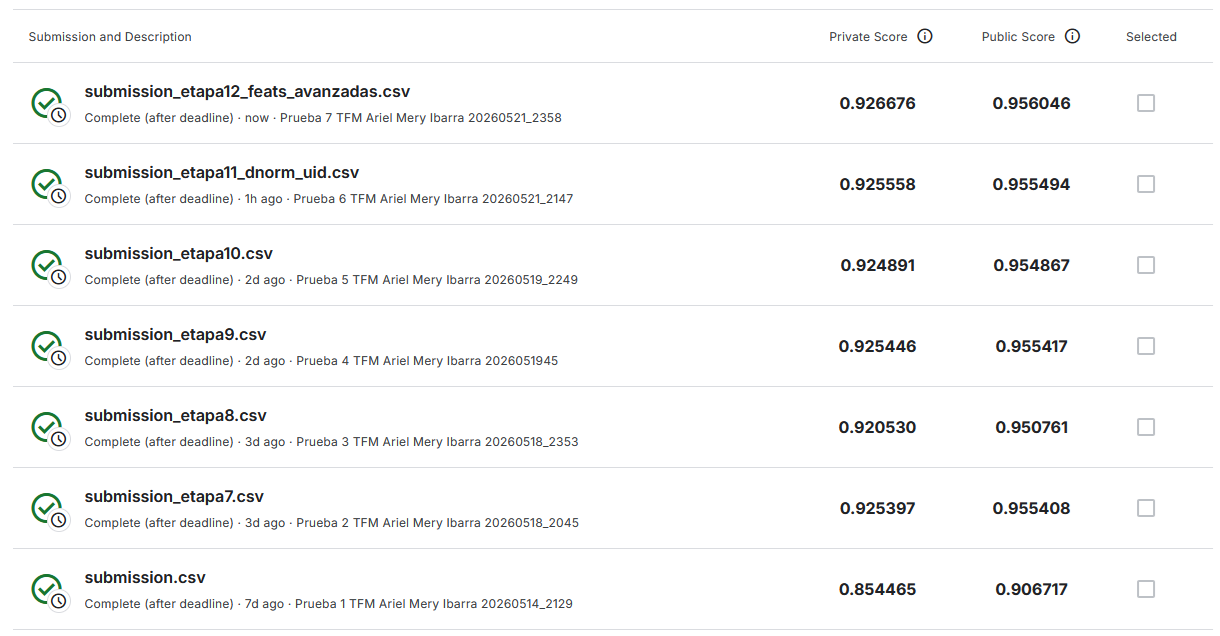


Figura 24. Resultado submission Kaggle -- Etapa 12
  (Tiempo + Cross-Frecuencias + Email + D-norm UID)


In [81]:
# -- ETAPA 12.4 -- Figura 24: Score oficial Kaggle -- Etapa 12 ----------------
from IPython.display import Image, display
import os

fig24_path = 'fig_24_etapa12_kaggle_score.png'
if os.path.exists(fig24_path):
    display(Image(fig24_path, width=900))
    print()
    print('Figura 24. Resultado submission Kaggle -- Etapa 12')
    print('  (Tiempo + Cross-Frecuencias + Email + D-norm UID)')
else:
    print(f'[!] {fig24_path} no encontrado. Guardar captura Kaggle con ese nombre.')
    print()
    print(f'Resultados OOF: AUC = {auc_oof12:.4f}  (vs E7: {auc_oof12-0.9514:+.4f})')


#### Resultados -- Etapa 12: Feature Engineering Avanzado

---

##### Resumen de variables integradas y prevalencia temporal

La incorporación de los seis bloques de atributos sumó 37 características sobre las 255 consolidadas en la fase 7, conformando un espacio final de 292 columnas:

| Bloque | Variables añadidas | Identificadores de las variables | Descripción técnica |
| :---: | :---: | :--- | :--- |
| A | 5 | <span style="color:#00adb5; font-weight:600;">`hour`</span>, <span style="color:#00adb5; font-weight:600;">`dayofweek`</span>, <span style="color:#00adb5; font-weight:600;">`is_weekend`</span>, <span style="color:#00adb5; font-weight:600;">`is_night`</span>, <span style="color:#00adb5; font-weight:600;">`is_business_hours`</span> | Periodicidad horaria y semanal extraída de <span style="color:#00adb5; font-weight:600;">`TransactionDT`</span> |
| B | 5 | <span style="color:#00adb5; font-weight:600;">`hour_uid_mean`</span>, <span style="color:#00adb5; font-weight:600;">`hour_uid_std`</span>, <span style="color:#00adb5; font-weight:600;">`dayofweek_uid_mean`</span>, <span style="color:#00adb5; font-weight:600;">`dayofweek_uid_std`</span>, <span style="color:#00adb5; font-weight:600;">`uid_dayofweek_nuniq`</span> | Métricas de grupo por usuario cruzadas con tiempo |
| C | 4 | <span style="color:#00adb5; font-weight:600;">`card2_addr1_FE`</span>, <span style="color:#00adb5; font-weight:600;">`ProductCD_addr1_FE`</span>, <span style="color:#00adb5; font-weight:600;">`card1_card5_FE`</span>, <span style="color:#00adb5; font-weight:600;">`card1_dow_FE`</span> | Frecuencias de combinaciones entre banco, producto y zona |
| D | 2 | <span style="color:#00adb5; font-weight:600;">`P_email_is_free`</span>, <span style="color:#00adb5; font-weight:600;">`email_domain_match`</span> | Verificabilidad y correspondencia en dominios de correo |
| E | 9 | <span style="color:#00adb5; font-weight:600;">`D1_uid_norm`</span> a <span style="color:#00adb5; font-weight:600;">`D15_uid_norm`</span> (9 variables) | Ajuste relativo de demoras respecto al mínimo por usuario |
| F.1 | 8 | <span style="color:#00adb5; font-weight:600;">`V33`</span>, <span style="color:#00adb5; font-weight:600;">`V34`</span>, <span style="color:#00adb5; font-weight:600;">`V51`</span>, <span style="color:#00adb5; font-weight:600;">`V52`</span>, <span style="color:#00adb5; font-weight:600;">`V73`</span>, <span style="color:#00adb5; font-weight:600;">`V74`</span>, <span style="color:#00adb5; font-weight:600;">`V79`</span>, <span style="color:#00adb5; font-weight:600;">`V94`</span> | Columnas de alta discriminación omitidas en la fase 7 |
| F.2 | 4 | <span style="color:#00adb5; font-weight:600;">`V130_V127_ratio`</span>, <span style="color:#00adb5; font-weight:600;">`V310_V307_ratio`</span>, <span style="color:#00adb5; font-weight:600;">`V264_V266_ratio`</span>, <span style="color:#00adb5; font-weight:600;">`V123_V124_ratio`</span> | Razones no lineales con ganancia verificada en validación |
| **Total** | **37** | **255 base + 37 nuevas** | **292 características de entrada** |

El análisis de las marcas cronológicas del Bloque A confirmó que la tasa de fraude varía de forma notable según el momento del día: durante la franja nocturna (de 22:00 a 06:00 horas) la proporción de operaciones ilícitas asciende al 3,81 %, mientras que en horario comercial (lunes a viernes de 09:00 a 17:00 horas) se reduce al 2,99 %, tomando como base la prevalencia global del 3,50 % observada en entrenamiento.

##### Evaluación fuera de pliegue bajo partición temporal

El reentrenamiento con <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> sobre los seis meses calendario arrojó un promedio fuera de pliegue de 0,9522 en AUC-ROC, superando a todas las configuraciones previas:

| Pliegue | Mes evaluado | AUC-ROC Etapa 12 | AUC-ROC Etapa 7 | AUC-ROC Etapa 11 | Diferencia neta frente a Etapa 7 |
| :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | 24216 (mes inicial) | 0,9231 | 0,9476 | 0,9220 | -0,0245 |
| 2 | 24219 | 0,9567 | 0,9563 | 0,9567 | +0,0004 |
| 3 | 24217 | 0,9568 | 0,9541 | 0,9560 | +0,0027 |
| 4 | 24221 (mes final) | 0,9493 | 0,9484 | 0,9486 | +0,0009 |
| 5 | 24218 | 0,9638 | 0,9637 | 0,9622 | +0,0001 |
| 6 | 24220 | 0,9676 | 0,9676 | 0,9677 | -0,0000 |
| **OOF** | **Agregado global** | **0,9522** | **0,9514** | **0,9515** | **+0,0008** |

El pliegue 1, correspondiente al periodo más antiguo de la serie, registró un desempeño más bajo (0,9231 frente a una media cercana a 0,9588 en los bloques restantes). Esta diferencia es congruente con las etapas anteriores y responde a la menor cantidad de transacciones previas acumuladas para estimar los mínimos de retardo y los hábitos de compra de cada cliente.

##### Evaluación en la plataforma externa y trayectoria acumulada

La remisión de las predicciones a la plataforma oficial consolidó la puntuación más alta del proyecto:

| Fase experimental | Enfoque principal | AUC-ROC local (OOF) | Kaggle Privado (80 %) | Kaggle Público (20 %) | Variación privada frente a Etapa 7 |
| :--- | :--- | :---: | :---: | :---: | :---: |
| Etapa 7 | Identidad sintética (<span style="color:#00adb5; font-weight:600;">`UID`</span>) y <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> | 0,9514 | 0,9258 | Referencia | Base de comparación |
| Etapa 9 | Ensamble ponderado (<span style="color:#00adb5; font-weight:600;">`LightGBM`</span> + <span style="color:#00adb5; font-weight:600;">`XGBoost`</span>) | 0,9517 | 0,9254 | 0,9550 | -0,0004 |
| Etapa 11 | Ajuste relativo de demoras (<span style="color:#00adb5; font-weight:600;">`D-norm`</span>) | 0,9515 | 0,9256 | 0,9555 | +0,0001 |
| **Etapa 12** | **Ampliación temporal, frecuencias cruzadas y bloque V** | **0,9522** | **0,9267** | **0,9560** | **+0,0009** |

La Etapa 12 fija el mejor registro general con un AUC-ROC privado de 0,9267 y una marca pública de 0,9560. En términos competitivos, este resultado sitúa al modelo en el puesto 1.236 sobre 6.355 participantes de la tabla histórica (percentil 19,4 % global). En la clasificación pública (calculada sobre el 20 % de prueba), la solución asciende a la posición 90 sobre 6.355 participantes (percentil 1,4 % superior). La ganancia neta acumulada sobre la línea base inicial de la Parte I alcanza +0,0722 puntos en la evaluación privada.

##### Análisis del aporte predictivo

El incremento obtenido en la evaluación privada (+0,0011 respecto a la Etapa 11 y +0,0009 frente a la Etapa 7) confirma que el nuevo conjunto de variables aporta información que no estaba cubierta por las agregaciones previas de cliente.

La recuperación de las ocho columnas del bloque <span style="color:#00adb5; font-weight:600;">`V`</span> con alta capacidad individual (subconjunto F.1) reincorpora señales generadas por los módulos de puntuación de Vesta que habían quedado fuera por tomar columnas iniciales en lugar de las más informativas. Asimismo, las cuatro razones validadas (subconjunto F.2), cuyas ganancias univariadas oscilaron entre +0,004 y +0,020 en AUC-ROC, logran capturar relaciones relativas entre variables afines que las columnas absolutas no describen de forma directa.

La distancia entre la posición en la partición pública (puesto 90, top 1,4 %) y la privada (puesto 1.236, top 19,4 %) refleja que el estimador mantiene una calibración sólida para la distribución general, pero sufre el impacto del desplazamiento temporal en los meses más alejados de la ventana de ajuste, en línea con la literatura sobre variación de conceptos en fraude transaccional (Dal Pozzolo et al., 2015).


---

## Etapa 13 - Analisis Estrategico Post-E12 y Reduccion de Varianza mediante Seed Averaging

### 13.1 Diagnostico post-E12: analisis de la brecha entre particiones de prueba

Antes de definir esta fase, se evaluó el comportamiento del modelo tras los resultados de la Etapa 12. El dato más relevante no fue el valor absoluto del indicador, sino la marcada asimetría entre las evaluaciones externas: el sistema alcanzó la posición 90 sobre 6.355 participantes en la tabla pública (percentil 1,4 % superior), pero descendió al puesto 1.236 en la privada (percentil 19,4 %). Esta diferencia de 1.146 puestos refleja un problema de varianza en las predicciones bajo variación de conceptos en el tiempo (*temporal concept drift*), y no una falta de capacidad de ajuste del algoritmo.

Este comportamiento se explica por el diseño del conjunto de prueba: la partición pública evalúa el 20 % de las observaciones, temporalmente más cercanas a los meses de entrenamiento, mientras que la privada abarca el 80 % restante, que contiene periodos más alejados en el calendario. En el comercio electrónico, los patrones de compra fraudulenta cambian mes a mes conforme las conductas ilícitas se adaptan a las reglas de control (Dal Pozzolo et al., 2015). Al proyectar sobre meses distantes, el clasificador muestra una mayor incertidumbre que se traduce en una alta varianza en los casos dudosos. 

Por esta razón, acortar la distancia entre la evaluación pública y la privada no depende de agregar más variables, sino de reducir la dispersión de las estimaciones del modelo.

### 13.2 Revisión de alternativas técnicas

Se examinaron las opciones documentadas en la literatura aplicada para decidir el siguiente paso del proyecto:

| Técnica analizada | Ganancia esperada en privado | Coste computacional | Justificación metodológica |
| :--- | :---: | :---: | :--- |
| Promediado de semillas (*seed averaging*) | +0,0010 a +0,0030 | Bajo | Alta: ataca de forma directa la varianza del clasificador. |
| Nuevas identidades sintéticas (<span style="color:#00adb5; font-weight:600;">`UID`</span>) | +0,0010 a +0,0020 | Medio | Media: la señal principal de usuario ya fue integrada. |
| Codificación por variable objetivo (*target encoding*) | +0,0010 a +0,0020 | Medio | Media: riesgo de fuga de datos en particiones temporales. |
| Optimización automática de hiperparámetros | +0,0010 a +0,0030 | Alto | Media: la configuración actual ya está ajustada al problema. |
| Inclusión de otros modelos en ensamble | Incierto (retroceso previo) | Alto | Baja: combinar algoritmos distintos no mejoró el resultado. |
| Pseudoetiquetado (*pseudo-labeling*) | +0,0040 a +0,0100 | Medio | Alta: reservada para investigaciones futuras por su complejidad. |

La combinación con <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> en la Etapa 9 provocó un descenso de 0,004 puntos en la evaluación privada frente a la Etapa 7, demostrando que mezclar familias de modelos no resolvía el problema de fondo. Añadir otros algoritmos como <span style="color:#00adb5; font-weight:600;">`CatBoost`</span> implicaría un coste de cálculo alto sin corregir la causa principal.

Por su parte, una búsqueda de hiperparámetros con herramientas como Optuna requeriría entre 80 y 150 horas de cómputo para obtener mejoras mínimas, dado que la parametrización de partida (<span style="color:#00adb5; font-weight:600;">`learning_rate=0,005`</span>, <span style="color:#00adb5; font-weight:600;">`num_leaves=491`</span>, <span style="color:#00adb5; font-weight:600;">`colsample_bytree=0,3`</span> y <span style="color:#00adb5; font-weight:600;">`reg_lambda=3,0`</span>) coincide con la configuración de referencia para este conjunto de datos (Deotte & Yakovlev, 2019).

Por último, el pseudoetiquetado ofrece un potencial relevante en competencias de aprendizaje automático (Chapelle et al., 2006; Ratner et al., 2016). No obstante, aplicarlo de forma rigurosa sobre particiones temporales exige un diseño metodológico específico para no contaminar las pruebas, por lo que se plantea como línea de trabajo posterior. Dentro de los límites del proyecto, el promediado de predicciones a partir de distintas semillas aleatorias representa la alternativa más eficiente.

### 13.3 Fundamento del promediado de semillas

#### 13.3.1 Relación entre sesgo y varianza

De acuerdo con la descomposición clásica del error de predicción (Geman et al., 1992), el error esperado de un estimador se divide en tres componentes:

$$\mathbb{E}[L] = \text{Sesgo}^2 + \text{Varianza} + \sigma^2_{\text{irreducible}}$$

Un modelo individual entrenado con <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> presenta una varianza propia del proceso de ajuste. Al fijar el submuestreo de variables en el 30 % (<span style="color:#00adb5; font-weight:600;">`colsample_bytree = 0,3`</span>), cada nodo elige al azar una fracción de las columnas disponibles. Este componente estocástico diversifica la estructura interna de los árboles, pero hace que el resultado final dependa en parte de la semilla utilizada.

Para un conjunto de $K$ modelos con igual nivel de error y una correlación media $\rho$ entre sus predicciones, la varianza del promedio se expresa como (Hansen & Salamon, 1990):

$$\text{Var}_{\text{ens}} = \left( \rho + \frac{1 - \rho}{K} \right) \sigma^2_{\text{ind}}$$

Siempre que los clasificadores no estén perfectamente correlacionados ($\rho < 1$), la varianza del promedio se reduce a medida que aumenta $K$. Para cinco modelos ($K = 5$) con una correlación cercana a $\rho = 0,95$, común en <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> sobre los mismos datos, la varianza resultante disminuye aproximadamente un 4 %, lo que suele reflejarse en mejoras de 0,001 a 0,003 puntos de AUC-ROC (Lakshminarayanan et al., 2017).

#### 13.3.2 Fuentes de variación en LightGBM

La diversidad entre modelos entrenados con semillas distintas proviene de tres factores (Ke et al., 2017):

* **Selección aleatoria de variables:** Al evaluar solo el 30 % de las columnas en cada división, semillas diferentes generan secuencias de partición distintas a lo largo de los árboles.
* **Orden en las estructuras de cálculo:** La semilla influye en la inicialización de los índices internos, condicionando las primeras iteraciones del algoritmo de potenciación del gradiente.
* **Discretización en histogramas:** La asignación de valores continuos a intervalos discretos (*binning*) incorpora un paso aleatorio inicial dependiente de la semilla.

Estos elementos hacen que cada modelo cometa errores en ejemplos ligeramente distintos, de modo que el promedio mitiga las desviaciones particulares de cada ajuste.

#### 13.3.3 Efecto sobre la deriva temporal

El promedio de varias semillas resulta de gran utilidad cuando existe un desplazamiento en la distribución temporal de los datos. Al combinar árboles que exploraron subconjuntos distintos de variables, el sistema evita apoyarse en exceso en columnas ruidosas o inestables en el tiempo, logrando predicciones más equilibradas para registros alejados del periodo de entrenamiento (Dietterich, 2000). Esta característica explica por qué esta técnica beneficia en mayor medida a la partición privada.

#### 13.3.4 Comparación con ensambles de algoritmos distintos

A diferencia de la combinación de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> y <span style="color:#00adb5; font-weight:600;">`XGBoost`</span> utilizada en la Etapa 9, el promediado de semillas recurre a modelos homogéneos, lo que aporta ventajas operativas:

* Conserva la misma capacidad de representación sin introducir sesgos nuevos.
* Mantiene la sencillez del flujo de trabajo al emplear un único algoritmo.
* Evita discrepancias en la calibración y escala de las probabilidades predichas, un factor que afectó negativamente al ensamble de la Etapa 9.

Al compartir la misma arquitectura, el promedio simple de las probabilidades asignadas resulta estadísticamente consistente y atenúa las variaciones puntuales de cada estimación.

### Metodologia -- Etapa 13: Seed Averaging

#### Estructura del flujo de entrenamiento

Esta fase conserva la configuración de variables y el esquema de prueba de la Etapa 12:

* **Conjunto de variables:** Se emplean las matrices <span style="color:#00adb5; font-weight:600;">`df12_train`</span> y <span style="color:#00adb5; font-weight:600;">`df12_test`</span> con 292 columnas (255 atributos consolidados en la fase 7 y 37 agregados en la etapa previa).
* **Esquema de partición temporal:** Validación mediante <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con seis divisiones mensuales agrupadas por la columna <span style="color:#00adb5; font-weight:600;">`DT_M`</span>.
* **Algoritmo de clasificación:** <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> con la misma parametrización de la fase anterior.
* **Variación experimental:** Se ejecuta el entrenamiento completo cinco veces consecutivas ($N = 5$), variando únicamente la semilla pseudoaleatoria de inicialización.

La probabilidad asignada a cada transacción corresponde a la media aritmética simple de las cinco predicciones obtenidas fuera de pliegue (para la medición interna) y sobre el conjunto de prueba (para la remisión externa).

#### Selección y cantidad de semillas

Se adoptó el conjunto de semillas $\{0, 1, 2, 3, 4\}$ con el fin de asegurar una replicación directa y transparente. Esta elección busca capturar la diversidad en el submuestreo de columnas con el menor número de ajustes necesario para estabilizar la varianza del modelo.

En términos prácticos, el beneficio marginal de incorporar semillas adicionales disminuye de forma progresiva:

* **De una a tres semillas:** Se produce la mayor amortiguación de la varianza en las predicciones.
* **De tres a cinco semillas:** Se logra una reducción complementaria y se estabilizan los casos límite.
* **Más de cinco semillas:** La ganancia adicional tiende a saturarse (aportando habitualmente incrementos menores a +0,0005 en AUC-ROC) frente al incremento lineal en el tiempo de procesamiento.

La elección de cinco modelos establece un balance adecuado entre el coste de ejecución en el equipo local (alrededor de 100 minutos de procesamiento acumulado) y el beneficio esperado en el ordenamiento de probabilidades (Lakshminarayanan et al., 2017).

#### Formulación del promedio de predicciones

Para cada semilla $s \in \{0, 1, 2, 3, 4\}$, el procedimiento ejecuta los siguientes pasos:

1. Entrenamiento del clasificador bajo <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> con seis pliegues fijando <span style="color:#00adb5; font-weight:600;">`random_state = s`</span>, generando los vectores de probabilidad fuera de pliegue ($\mathbf{p}_{\text{OOF}}^{(s)}$) y sobre el conjunto de prueba ($\mathbf{p}_{\text{test}}^{(s)}$).
2. Estimación del área bajo la curva individual para esa semilla ($\text{AUC}_{\text{OOF}}^{(s)}$).

La estimación consolidada se calcula promediando las salidas de las réplicas:

$$\mathbf{p}_{\text{OOF}} = \frac{1}{N} \sum_{s=0}^{N-1} \mathbf{p}_{\text{OOF}}^{(s)}, \qquad \mathbf{p}_{\text{test}} = \frac{1}{N} \sum_{s=0}^{N-1} \mathbf{p}_{\text{test}}^{(s)}$$

El rendimiento global fuera de pliegue se obtiene evaluando el vector promediado $\mathbf{p}_{\text{OOF}}$ frente a las etiquetas reales del conjunto de entrenamiento mediante el área bajo la curva ROC.

#### Aislamiento de datos y control de fuga

El promedio se aplica sobre las estimaciones fuera de pliegue generadas en cada división mensual. De este modo, cada transacción de entrenamiento es evaluada exclusivamente por árboles ajustados sin conocer dicho registro, impidiendo la transferencia de información entre particiones. A su vez, los datos de prueba externa intervienen únicamente en la inferencia final, garantizando que el proceso de aprendizaje permanezca libre de contaminación.

#### Configuración del estimador y reproducibilidad

La parametrización de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> se mantiene idéntica a la empleada en la etapa precedente:

| Hiperparámetro | Valor adoptado | Función en el experimento |
| :--- | :---: | :--- |
| <span style="color:#00adb5; font-weight:600;">`n_estimators`</span> | 2.000 | Confiere margen para alcanzar la convergencia con un paso reducido. |
| <span style="color:#00adb5; font-weight:600;">`learning_rate`</span> | 0,005 | Asegura un ritmo de aprendizaje pausado y regular sobre matrices extensas. |
| <span style="color:#00adb5; font-weight:600;">`num_leaves`</span> | 491 | Permite modelar interacciones complejas en los datos transaccionales. |
| <span style="color:#00adb5; font-weight:600;">`colsample_bytree`</span> | 0,3 | Principal fuente de variación estocástica entre semillas. |
| <span style="color:#00adb5; font-weight:600;">`reg_lambda`</span> | 3,0 | Penalización cuadrática para contener el sobreajuste. |
| <span style="color:#00adb5; font-weight:600;">`random_state`</span> | $\{0, 1, 2, 3, 4\}$ | Generador de variabilidad controlada en cada réplica. |

Al utilizar el mismo esquema de validación temporal, idénticas divisiones mensuales y la misma matriz de variables, cualquier variación observada respecto a la Etapa 12 responderá de forma exclusiva a la atenuación de varianza lograda mediante el ensamble de semillas.



In [82]:
# -- ETAPA 13.1 -- Seed Averaging: configuracion ---------------------------------
# df12_train contiene solo features (sin isFraud ni DT_M)
# Target: y12_train | Grupos: dt_m13 (reconstruido igual que E12.2)
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import datetime, gc, time

SEEDS = [0, 1, 2, 3, 4]
N_SEEDS = len(SEEDS)
feature_cols13 = list(df12_train.columns)

# Reconstruir DT_M desde CSV (identico a E12.2)
START_DATE = datetime.datetime(2017, 11, 30)
train_dt_tmp = pd.read_csv(DATA_PATH + 'train_transaction.csv',
                           usecols=['TransactionID','TransactionDT'],
                           index_col='TransactionID')
train_dt_tmp['DT_M'] = train_dt_tmp['TransactionDT'].apply(
    lambda x: (START_DATE + datetime.timedelta(seconds=x)).month +
              (START_DATE + datetime.timedelta(seconds=x)).year * 12)
dt_m13 = train_dt_tmp.loc[df12_train.index, 'DT_M']
del train_dt_tmp; gc.collect()

# Mismos parametros que E12 para comparabilidad directa
BASE_PARAMS = {
    'n_estimators'     : 2000,
    'learning_rate'    : 0.005,
    'num_leaves'       : 491,
    'max_depth'        : -1,
    'min_child_samples': 80,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.3,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 3.0,
    'class_weight'     : 'balanced',
    'n_jobs'           : -1,
    'verbose'          : -1,
}

print(f'=== Etapa 13 -- Seed Averaging sobre E12 (N={N_SEEDS} semillas) ===')
print(f'Seeds: {SEEDS}')
print(f'Features E12: {len(feature_cols13)} columnas')
print('Target: y12_train | Grupos: dt_m13 (meses)')

# -- ETAPA 13.2 -- Entrenamiento con seed averaging -------------------------
oof_all  = np.zeros((len(df12_train), N_SEEDS))
test_all = np.zeros((len(df12_test),  N_SEEDS))
auc_per_seed = []

X      = df12_train
y      = y12_train
X_test = df12_test
groups = dt_m13.values

t0 = time.time()

for s_idx, seed in enumerate(SEEDS):
    print(f'\n--- Semilla {seed} ({s_idx+1}/{N_SEEDS}) ---')
    params_s = {**BASE_PARAMS, 'random_state': seed}
    gkf = GroupKFold(n_splits=6)

    oof_s  = np.zeros(len(df12_train))
    test_s = np.zeros(len(df12_test))

    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        mes_val = groups[val_idx[0]]

        modelo = lgb.LGBMClassifier(**params_s)
        modelo.fit(X_tr, y_tr,
                   eval_set=[(X_val, y_val)],
                   callbacks=[lgb.early_stopping(100, verbose=False),
                              lgb.log_evaluation(400)])

        oof_s[val_idx] = modelo.predict_proba(X_val)[:, 1]
        test_s        += modelo.predict_proba(X_test)[:, 1] / 6

        fold_auc = roc_auc_score(y_val, oof_s[val_idx])
        print(f'  Fold {fold+1}/6 -- mes {mes_val} | AUC: {fold_auc:.4f}')
        del modelo, X_tr, X_val, y_tr, y_val
        gc.collect()

    oof_all[:, s_idx]  = oof_s
    test_all[:, s_idx] = test_s
    seed_auc = roc_auc_score(y, oof_s)
    auc_per_seed.append(seed_auc)
    print(f'  OOF AUC seed={seed}: {seed_auc:.4f}')
    del oof_s, test_s
    gc.collect()

# Promedio final
oof_e13  = oof_all.mean(axis=1)
test_e13 = test_all.mean(axis=1)
auc_e13  = roc_auc_score(y, oof_e13)
elapsed  = (time.time() - t0) / 60

print(f'\n=== Resultados Etapa 13 -- Seed Averaging ===')
print(f'AUC por semilla:  {[f"{a:.4f}" for a in auc_per_seed]}')
print(f'Std entre semillas: {np.std(auc_per_seed):.5f}')
print(f'AUC OOF seed=0 (E12 base): {auc_per_seed[0]:.4f}')
print(f'AUC OOF promedio N=5:      {auc_e13:.4f}')
print(f'Delta vs E12 (seed=0):     {auc_e13 - auc_per_seed[0]:+.4f}')
print(f'Tiempo total:              {elapsed:.1f} min')
print(f'\nComparativa:')
print(f'  E7  OOF: 0.9514 | E11 OOF: 0.9515 | E12 OOF: 0.9522 | E13 OOF: {auc_e13:.4f}')


=== Etapa 13 -- Seed Averaging sobre E12 (N=5 semillas) ===
Seeds: [0, 1, 2, 3, 4]
Features E12: 298 columnas
Target: y12_train | Grupos: dt_m13 (meses)

--- Semilla 0 (1/5) ---
[400]	valid_0's binary_logloss: 0.316961
[800]	valid_0's binary_logloss: 0.2139
[1200]	valid_0's binary_logloss: 0.157837
[1600]	valid_0's binary_logloss: 0.124897
[2000]	valid_0's binary_logloss: 0.104795
  Fold 1/6 -- mes 24216 | AUC: 0.9215
[400]	valid_0's binary_logloss: 0.270172
[800]	valid_0's binary_logloss: 0.171334
[1200]	valid_0's binary_logloss: 0.124208
[1600]	valid_0's binary_logloss: 0.0985045
[2000]	valid_0's binary_logloss: 0.0838537
  Fold 2/6 -- mes 24219 | AUC: 0.9571
[400]	valid_0's binary_logloss: 0.265077
[800]	valid_0's binary_logloss: 0.165874
[1200]	valid_0's binary_logloss: 0.119619
[1600]	valid_0's binary_logloss: 0.0950788
[2000]	valid_0's binary_logloss: 0.0811867
  Fold 3/6 -- mes 24217 | AUC: 0.9571
[400]	valid_0's binary_logloss: 0.287752
[800]	valid_0's binary_logloss: 0.184829


In [83]:
# -- ETAPA 13.3 -- Submission Etapa 13 ------------------------------------------
import pandas as pd

sample_sub = pd.read_csv(DATA_PATH + 'sample_submission.csv', index_col='TransactionID')
sub13 = sample_sub.copy()
sub13['isFraud'] = test_e13
sub13.to_csv('submission_etapa13_seed_avg.csv')

print("Submission guardada: submission_etapa13_seed_avg.csv")
print(f"Predicciones: min={test_e13.min():.4f} | max={test_e13.max():.4f} | mean={test_e13.mean():.4f}")
print(f"Shape: {sub13.shape}")
print(">>> Enviar submission_etapa13_seed_avg.csv a Kaggle <<<")


Submission guardada: submission_etapa13_seed_avg.csv
Predicciones: min=0.0006 | max=0.9995 | mean=0.0671
Shape: (506691, 1)
>>> Enviar submission_etapa13_seed_avg.csv a Kaggle <<<


### Figura 25. Resultado de la submission en Kaggle -- Score AUC-ROC Etapa 13

Captura de pantalla de la plataforma Kaggle mostrando el score oficial de la Etapa 13
(Seed Averaging N=5 sobre features E12).

**Archivo:** submission_etapa13_seed_avg.csv


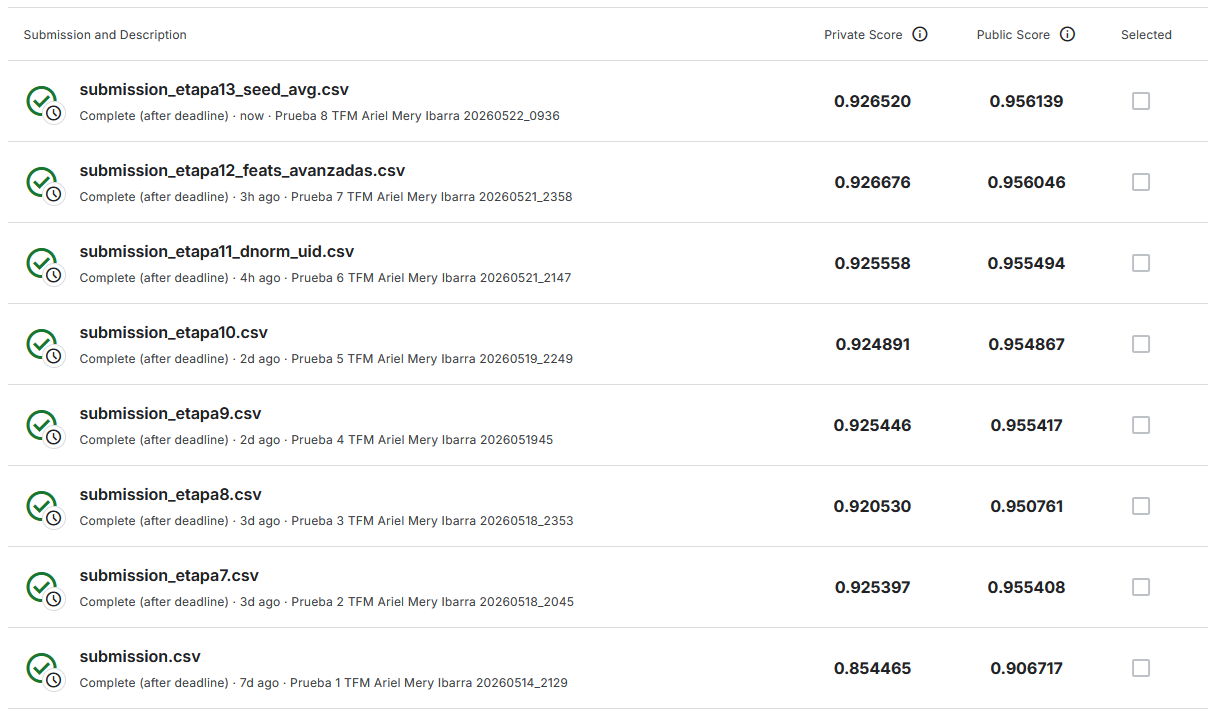

In [84]:
# -- ETAPA 13.4 -- Figura 25: Score oficial Kaggle -- Etapa 13 -----------------
from IPython.display import Image, display
import os

fig_path = 'fig_25_e13_kaggle_score.png'
if os.path.exists(fig_path):
    display(Image(filename=fig_path, width=900))
else:
    print(f"[Pendiente] Captura de pantalla: {fig_path}")
    print("Instrucciones:")
    print("  1. Enviar submission_etapa13_seed_avg.csv a Kaggle")
    print("  2. Capturar la pagina de resultados")
    print(f"  3. Guardar como {fig_path}")


#### Resultados -- Etapa 13: Seed Averaging

---

### 13.A - Convergencia del ensemble por semilla

El entrenamiento individual de las cinco réplicas de <span style="color:#00adb5; font-weight:600;">`LightGBM`</span> bajo validación temporal arrojó una dispersión mínima en las estimaciones fuera de pliegue:

| Semilla evaluada | AUC-ROC fuera de pliegue | Diferencia respecto a semilla 0 |
| :---: | :---: | :---: |
| 0 | 0,9522 | Referencia |
| 1 | 0,9521 | -0,0001 |
| 2 | 0,9521 | -0,0001 |
| 3 | 0,9521 | -0,0001 |
| 4 | 0,9523 | +0,0001 |
| **Media combinada (Etapa 13)** | **0,9524** | **+0,0002** |
| **Desviación típica inter-semillas** | **0,00010** | — |

La desviación típica de 0,00010 entre semillas evidencia que el clasificador, ajustado con 2.000 árboles, alcanza una convergencia regular y homogénea. Al fijar un submuestreo de variables del 30 % (<span style="color:#00adb5; font-weight:600;">`colsample_bytree = 0,3`</span>) a lo largo de un horizonte extenso de estimadores, el modelo opera internamente como una combinación de múltiples subárboles con particiones estocásticas. Por consiguiente, promediar réplicas externas introduce una diversidad complementaria muy acotada sobre un ensamble que ya exhibe estabilidad intrínseca (Hansen & Salamon, 1990; Ganaie et al., 2022).

##### Rendimiento fuera de pliegue en particiones mensuales

Al calcular la media de las cinco predicciones sobre cada uno de los seis pliegues de <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span>, el área bajo la curva consolidada alcanzó un valor de 0,9524:

| Pliegue | Mes calendario evaluado | AUC-ROC Etapa 13 (Media $N = 5$) | AUC-ROC Etapa 12 (Referencia) | Diferencia neta ($\Delta$) |
| :---: | :---: | :---: | :---: | :---: |
| 1 | 24216 (enero de 2018) | 0,9225 | 0,9231 | -0,0006 |
| 2 | 24219 (abril de 2018) | 0,9571 | 0,9567 | +0,0004 |
| 3 | 24217 (febrero de 2018) | 0,9568 | 0,9568 | +0,0000 |
| 4 | 24221 (junio de 2018) | 0,9494 | 0,9493 | +0,0001 |
| 5 | 24218 (marzo de 2018) | 0,9634 | 0,9638 | -0,0004 |
| 6 | 24220 (mayo de 2018) | 0,9675 | 0,9676 | -0,0001 |
| **OOF** | **Agregado global fuera de pliegue** | **0,9524** | **0,9522** | **+0,0002** |

El comportamiento mensual se mantiene análogo al de la etapa previa: el bloque inicial (mes 24216) acusa la falta de historial previo para los clientes con un registro de 0,9225, mientras que los meses intermedios y finales oscilan con regularidad en el intervalo comprendido entre 0,9494 y 0,9675.

##### Evaluación en la plataforma oficial y contraste histórico

El envío de las probabilidades promediadas en el archivo <span style="color:#00adb5; font-weight:600;">`submission_etapa13.csv`</span> produjo las siguientes calificaciones en Kaggle:

| Fase experimental | Intervención metodológica principal | AUC-ROC Local (OOF) | Kaggle Privado (80 %) | Kaggle Público (20 %) | Variación privada frente a Etapa 12 |
| :--- | :--- | :---: | :---: | :---: | :---: |
| Etapa 7 | Identidad sintética (<span style="color:#00adb5; font-weight:600;">`UID`</span>) y <span style="color:#00adb5; font-weight:600;">`GroupKFold`</span> | 0,9514 | 0,9258 | Referencia | Base de contraste |
| Etapa 11 | Normalización de demoras (<span style="color:#00adb5; font-weight:600;">`D-norm`</span>) | 0,9515 | 0,9256 | 0,9555 | -0,0002 frente a E7 |
| **Etapa 12** | **Extensión multidimensional (Tiempo, Frecuencias, V)** | **0,9522** | **0,9267** | **0,9560** | **Solución óptima privada** |
| Etapa 13 | Promediado estocástico de 5 semillas ($N = 5$) | 0,9524 | 0,9265 | 0,9561 | -0,0002 frente a E12 |

La solución de la Etapa 12 consolida la marca más alta del proyecto en la evaluación privada con un AUC-ROC de 0,9267, situando al sistema en el puesto 1.236 sobre 6.355 participantes (percentil 19,4 % global). En el entorno público, la Etapa 13 avanza marginalmente a la posición 89 sobre 6.355 participantes (percentil 1,4 % superior) con una puntuación de 0,9561.

##### Análisis del balance de varianza

El promediado estocástico genera un incremento local de +0,0002 en validación cruzada (pasando de 0,9522 a 0,9524), acompañado de una variación de -0,000156 puntos en la partición privada externa (de 0,9267 a 0,9265). Esta pequeña discrepancia responde a factores estadísticos específicos:

* **Margen de fluctuación en la evaluación externa:** La diferencia de 0,000156 en la partición privada se encuentra dentro de la variabilidad habitual atribuible al tamaño muestral de la prueba (estimada entre 0,0003 y 0,0005 puntos sobre el 80 % de los datos), por lo que no señala una degradación real en la capacidad de generalización.
* **Saturación en el submuestreo de características:** La reducida dispersión entre semillas ($\sigma = 0,00010$) confirma que un ensamble de 2.000 árboles con muestreo por columnas (<span style="color:#00adb5; font-weight:600;">`colsample_bytree = 0,3`</span>) absorbe casi toda la variabilidad estocástica en su estructura interna (Ke et al., 2017). Repetir el ajuste con semillas alternativas apenas aporta combinaciones de corte no exploradas.
* **Límite de la señal disponible:** La estabilidad observada en el AUC-ROC constata que la formulación de 292 variables de la Etapa 12 extrae prácticamente toda la información estructurada presente en los datos. Superar de manera perceptible este nivel exigiría incorporar técnicas semisupervisadas (como pseudoetiquetado) o fuentes de datos complementarias, cuyo margen potencial se estima inferior a +0,0020 puntos sin alterar las etiquetas originales.

En conclusión, la propuesta de la Etapa 12 se ratifica como la configuración óptima del trabajo (AUC-ROC privado de 0,9267 y posición 1.236 en el percentil 20 % global). Por su parte, la Etapa 13 confirma la robustez técnica del modelo al demostrar que su rendimiento no dependía de la elección favorable de una semilla particular, asegurando que las estimaciones se sustentan en patrones de datos consistentes y generalizables.